# 0️⃣ InteractivePipelineLoadFromPickle (Independent Load-only Visualization Notebook) - Imports

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.context_dependent import GenericDecoderDictDecodedEpochsDictResult
%config IPCompleter.use_jedi = False
# %xmode Verbose
# %xmode context
%pdb off
%load_ext autoreload
%autoreload 3

# ==================================================================================================================================================================================================================================================================================== #
# PyQtInspect:                                                                                                                                                                                                                                                                         #
# ==================================================================================================================================================================================================================================================================================== #
# 1. Launch `pqi-server` in a new terminal BEFORE running this notebook cell. Be sure to click 'Serve' button in the GUI that appears so this notebook can connect.

# # IMPORTANT: Call settrace BEFORE importing PyQt5
# import PyQtInspect.pqi as pqi

# # Connect to the server (default: localhost:19394)
# # Make sure the server is already running!
# pqi.settrace(
#     host='127.0.0.1',
#     port=19394,  # Default port, or use the port shown in the server GUI
#     qt_support='pyqt5',  # or 'auto' for auto-detection
#     patch_multiprocessing=False
# )

# # # !pip install viztracer
# %load_ext viztracer
# from viztracer import VizTracer

# %load_ext memory_profiler

import objgraph

import sys
from pathlib import Path

# required to enable non-blocking interaction:
%gui qt5

import importlib
from copy import deepcopy
from numba import jit
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
# pd.options.mode.dtype_backend = 'pyarrow' # use new pyarrow backend instead of numpy
from attrs import define, field, fields, Factory, make_class
import tables as tb
from datetime import datetime, timedelta

# Pho's Formatting Preferences
import builtins

import IPython
from IPython.core.formatters import PlainTextFormatter
from IPython import get_ipython
from pyphocorehelpers.gui.Jupyter.AsyncExecutionHelper import run_async

from pyphocorehelpers.preferences_helpers import set_pho_preferences, set_pho_preferences_concise, set_pho_preferences_verbose
set_pho_preferences_concise()
# Jupyter-lab enable printing for any line on its own (instead of just the last one in the cell)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# BEGIN PPRINT CUSTOMIZATION ___________________________________________________________________________________________ #

## IPython pprint
from pyphocorehelpers.pprint import wide_pprint, wide_pprint_ipython, wide_pprint_jupyter, MAX_LINE_LENGTH
# Override default pprint
builtins.pprint = wide_pprint

ip = get_ipython()

from pyphocorehelpers.ipython_helpers import CustomFormatterMagics

# Register the magic
ip.register_magics(CustomFormatterMagics) # %%ndarray_preview height=500, width=None, include_plaintext_repr=False, include_shape=False, horizontal_layout=True


text_formatter: PlainTextFormatter = ip.display_formatter.formatters['text/plain']
text_formatter.max_width = MAX_LINE_LENGTH
text_formatter.for_type(object, wide_pprint_jupyter)


from pyphocorehelpers.pho_jupyter_preview_widget.ipython_helpers import PreviewWidgetMagics

ip.register_magics(PreviewWidgetMagics)


# END PPRINT CUSTOMIZATION ___________________________________________________________________________________________ #

from pyphocorehelpers.print_helpers import get_now_time_str, get_now_day_str
from pyphocorehelpers.indexing_helpers import get_dict_subset

## Pho's Custom Libraries:
from pyphocorehelpers.Filesystem.path_helpers import find_first_extant_path, file_uri_from_path
from pyphocorehelpers.Filesystem.open_in_system_file_manager import reveal_in_system_file_manager
import pyphocorehelpers.programming_helpers as programming_helpers
from pyphocorehelpers.print_helpers import render_scrollable_colored_table_from_dataframe, render_scrollable_colored_table

# NeuroPy (Diba Lab Python Repo) Loading
# from neuropy import core
from typing import Dict, List, Tuple, Optional, Callable, Union, Any
from typing_extensions import TypeAlias

import nptyping as ND
from nptyping import NDArray

from neuropy.utils.indexing_helpers import PandasHelpers, NumpyHelpers
from neuropy.utils.indexing_helpers import flatten
from neuropy.analyses.placefields import PlacefieldComputationParameters
from neuropy.core.epoch import NamedTimerange, Epoch, EpochsAccessor, ensure_dataframe, ensure_Epoch
from neuropy.core.ratemap import Ratemap
from neuropy.core.session.Formats.BaseDataSessionFormats import DataSessionFormatRegistryHolder, DataSessionFormatBaseRegisteredClass
from neuropy.core.session.Formats.Specific.BapunDataSessionFormat import BapunDataSessionFormatRegisteredClass

from neuropy.utils.matplotlib_helpers import matplotlib_file_only, matplotlib_configuration, matplotlib_configuration_update
from neuropy.core.neuron_identities import NeuronIdentityTable, neuronTypesList, neuronTypesEnum
from neuropy.utils.mixins.AttrsClassHelpers import AttrsBasedClassHelperMixin, serialized_field, serialized_attribute_field, non_serialized_field, custom_define
from neuropy.utils.mixins.HDF5_representable import HDF_DeserializationMixin, post_deserialize, HDF_SerializationMixin, HDFMixin, HDF_Converter

## For computation parameters:
from neuropy.analyses.placefields import PlacefieldComputationParameters
from neuropy.utils.dynamic_container import DynamicContainer
from neuropy.utils.result_context import IdentifyingContext
from neuropy.core.session.Formats.BaseDataSessionFormats import find_local_session_paths
from neuropy.core.user_annotations import UserAnnotationsManager

from pyphocorehelpers.print_helpers import print_object_memory_usage, print_dataframe_memory_usage, print_value_overview_only, DocumentationFilePrinter, print_keys_if_possible, generate_html_string, document_active_variables
from pyphocorehelpers.programming_helpers import metadata_attributes
from pyphocorehelpers.function_helpers import function_attributes
## Pho Programming Helpers:
from pyphocorehelpers.print_helpers import DocumentationFilePrinter, TypePrintMode, print_keys_if_possible, debug_dump_object_member_shapes, print_value_overview_only, document_active_variables
from pyphocorehelpers.programming_helpers import IPythonHelpers, PythonDictionaryDefinitionFormat, MemoryManagement, inspect_callable_arguments, get_arguments_as_optional_dict, GeneratedClassDefinitionType, CodeConversion
from pyphocorehelpers.gui.Qt.TopLevelWindowHelper import TopLevelWindowHelper, print_widget_hierarchy
from pyphocorehelpers.indexing_helpers import reorder_columns, reorder_columns_relative, dict_to_full_array
from pyphocorehelpers.DataStructure.RenderPlots.MatplotLibRenderPlots import MatplotlibRenderPlots

doc_output_parent_folder: Path = Path('../EXTERNAL/DEVELOPER_NOTES/DataStructureDocumentation').resolve() # ../.
print(f"doc_output_parent_folder: {doc_output_parent_folder}")
assert doc_output_parent_folder.exists()

from pyphocorehelpers.notebook_helpers import NotebookCellExecutionLogger, NotebookProcessor

_notebook_path:Path = Path(IPythonHelpers.try_find_notebook_filepath(IPython.extract_module_locals())).resolve() # Finds the path of THIS notebook
_notebook_execution_logger: NotebookCellExecutionLogger = NotebookCellExecutionLogger(notebook_path=_notebook_path, enable_logging_to_file=False) # Builds a logger that records info about this notebook
_notebook_processor: NotebookProcessor = NotebookProcessor(path=_notebook_path)

# pyPhoPlaceCellAnalysis:
from pyphoplacecellanalysis.General.Pipeline.NeuropyPipeline import NeuropyPipeline # get_neuron_identities
from pyphoplacecellanalysis.General.Mixins.ExportHelpers import export_pyqtgraph_plot
from pyphoplacecellanalysis.General.Batch.NonInteractiveProcessing import batch_load_session, batch_extended_computations, batch_evaluate_required_computations
from pyphoplacecellanalysis.General.Pipeline.NeuropyPipeline import PipelineSavingScheme # used in perform_pipeline_save
from pyphoplacecellanalysis.GUI.IPyWidgets.pipeline_ipywidgets import PipelineJupyterHelpers, CustomProcessingPhases
from pyphocorehelpers.assertion_helpers import Assert
import pyphoplacecellanalysis.General.type_aliases as types # import neuropy.utils.type_aliases as types


import pyphoplacecellanalysis.External.pyqtgraph as pg

from pyphocorehelpers.exception_helpers import ExceptionPrintingContext, CapturedException
from pyphoplacecellanalysis.General.Batch.NonInteractiveProcessing import batch_perform_all_plots
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.LongShortTrackComputations import JonathanFiringRateAnalysisResult
from pyphoplacecellanalysis.General.Mixins.CrossComputationComparisonHelpers import _find_any_context_neurons
from pyphoplacecellanalysis.General.Batch.runBatch import BatchSessionCompletionHandler # for `post_compute_validate(...)`
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BasePositionDecoder
from pyphoplacecellanalysis.SpecificResults.AcrossSessionResults import AcrossSessionsResults
from pyphoplacecellanalysis.General.Mixins.CrossComputationComparisonHelpers import SplitPartitionMembership
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalPlacefieldGlobalComputationFunctions, DirectionalLapsResult, TrackTemplates, DecoderDecodedEpochsResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import TrackTemplates
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.ComputationFunctionRegistryHolder import ComputationFunctionRegistryHolder, computation_precidence_specifying_function, global_function
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.SequenceBasedComputations import WCorrShuffle, SequenceBasedComputationsContainer
from neuropy.utils.mixins.binning_helpers import transition_matrix
from pyphoplacecellanalysis.Analysis.Decoder.transition_matrix import TransitionMatrixComputations
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import TrackTemplates, get_proper_global_spikes_df
from pyphocorehelpers.Filesystem.path_helpers import set_posix_windows
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BasePositionDecoder, DecodedFilterEpochsResult, SingleEpochDecodedResult
from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters

from pyphocorehelpers.assertion_helpers import Assert

# Plotting
# import pylustrator # customization of figures
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
_bak_rcParams = mpl.rcParams.copy()

matplotlib.use('Qt5Agg')
# %matplotlib inline
# %matplotlib auto

# _restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')
_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

import seaborn as sns

# import pylustrator # call `pylustrator.start()` before creating your first figure in code.
from pyphoplacecellanalysis.Pho2D.matplotlib.visualize_heatmap import visualize_heatmap, visualize_heatmap_pyqtgraph # used in `plot_kourosh_activity_style_figure`
from pyphoplacecellanalysis.General.Pipeline.Stages.DisplayFunctions.SpikeRasters import plot_multiple_raster_plot, plot_raster_plot
from pyphoplacecellanalysis.General.Mixins.DataSeriesColorHelpers import UnitColoringMode, DataSeriesColorHelpers
from pyphoplacecellanalysis.General.Pipeline.Stages.DisplayFunctions.SpikeRasters import _build_default_tick, build_scatter_plot_kwargs
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.Mixins.Render2DScrollWindowPlot import Render2DScrollWindowPlotMixin, ScatterItemData
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.SpikeAnalysis import SpikeRateTrends
from pyphoplacecellanalysis.General.Mixins.SpikesRenderingBaseMixin import SpikeEmphasisState
from pyphoplacecellanalysis.General.Model.SpecificComputationParameterTypes import ComputationKWargParameters
from pyphoplacecellanalysis.SpecificResults.PhoDiba2023Paper import PAPER_FIGURE_figure_1_add_replay_epoch_rasters, PAPER_FIGURE_figure_1_full, PAPER_FIGURE_figure_3, main_complete_figure_generations
# from pyphoplacecellanalysis.SpecificResults.fourthYearPresentation import *

# Jupyter Widget Interactive
import ipywidgets as widgets
from IPython.display import display, HTML
from pyphocorehelpers.Filesystem.open_in_system_file_manager import reveal_in_system_file_manager
from pyphoplacecellanalysis.GUI.IPyWidgets.pipeline_ipywidgets import interactive_pipeline_widget, interactive_pipeline_files
from pyphocorehelpers.gui.Jupyter.simple_widgets import fullwidth_path_widget, render_colors

from datetime import datetime, date, timedelta
from pyphocorehelpers.print_helpers import get_now_day_str, get_now_rounded_time_str

from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters

known_data_session_type_properties_dict = DataSessionFormatRegistryHolder.get_registry_known_data_session_type_dict()
active_data_session_types_registered_classes_dict = DataSessionFormatRegistryHolder.get_registry_data_session_type_class_name_dict()

DAY_DATE_STR: str = date.today().strftime("%Y-%m-%d")
DAY_DATE_TO_USE = f'{DAY_DATE_STR}' # used for filenames throught the notebook
print(f'DAY_DATE_STR: {DAY_DATE_STR}, DAY_DATE_TO_USE: {DAY_DATE_TO_USE}')

NOW_DATETIME: str = get_now_rounded_time_str()
NOW_DATETIME_TO_USE = f'{NOW_DATETIME}' # used for filenames throught the notebook
print(f'NOW_DATETIME: {NOW_DATETIME}, NOW_DATETIME_TO_USE: {NOW_DATETIME_TO_USE}')

def get_global_variable(var_name):
    """ used by `PipelineJupyterHelpers._build_pipeline_custom_processing_mode_selector_widget(...)` to update the notebook's variables """
    return globals()[var_name]
    
def update_global_variable(var_name, value):
    """ used by `PipelineJupyterHelpers._build_pipeline_custom_processing_mode_selector_widget(...)` to update the notebook's variables """
    globals()[var_name] = value

from pyphocorehelpers.gui.Jupyter.simple_widgets import build_global_data_root_parent_path_selection_widget
all_paths = [Path(r'/home/halechr/FastData'), Path('/Volumes/SwapSSD/Data'), Path('/Users/pho/data'), Path(r'/media/halechr/MAX/Data'), Path(r'W:\Data'), Path(r'H:\Data'), Path(r'/home/halechr/cloud/turbo/Data'), Path(r'/Volumes/MoverNew/data'), Path(r'/home/halechr/turbo/Data'), Path(r'/Users/pho/cloud/turbo/Data')] # Path('/Volumes/FedoraSSD/FastData'), 
global_data_root_parent_path = None
def on_user_update_path_selection(new_path: Path):
    global global_data_root_parent_path
    new_global_data_root_parent_path = new_path.resolve()
    global_data_root_parent_path = new_global_data_root_parent_path
    print(f'global_data_root_parent_path changed to {global_data_root_parent_path}')
    assert global_data_root_parent_path.exists(), f"global_data_root_parent_path: {global_data_root_parent_path} does not exist! Is the right computer's config commented out above?"
            
global_data_root_parent_path_widget = build_global_data_root_parent_path_selection_widget(all_paths, on_user_update_path_selection)
global_data_root_parent_path_widget

# 0️⃣ Load Pipeline

In [ ]:
# ==================================================================================================================== #
# Load Data                                                                                                            #
# ==================================================================================================================== #

# ==================================================================================================================== #
# BAPUN data format                                                                                                    #
# ==================================================================================================================== #
active_data_mode_name = 'bapun'
local_session_root_parent_context = IdentifyingContext(format_name=active_data_mode_name) # , animal_name='', configuration_name='one', session_name=a_sess.session_name
local_session_root_parent_path = global_data_root_parent_path.joinpath('Bapun')

# [*] - indicates bad or session with a problem
# 0, 1, 2, 3, 4, 5, 6, 7, [8], [9], 10, 11, [12], 13, 14, [15], [16], 17, 
# curr_context = IdentifyingContext(format_name='bapun', animal='RatU', session_name='RatUDay5OpenfieldSD') # NEW 2025-12-15 -- working but the epochs are a little weird, I had to manually rename them and they still don't seem right
curr_context = IdentifyingContext(format_name='bapun',animal='RatN', session_name='Day4OpenField') # ,exper_name='one' -- This is the one with the 2 behaviors ('roam', 'sprinkle') in the same open field box
# curr_context = IdentifyingContext(format_name='bapun',animal='RatK', session_name='Day4Openfield') # DOESN"T WORK, NO NEU{RONS OR SOMETHING.


# Create a dictionary with the parameters to override
override_parameters = {
    'preprocessing.laps.use_direction_dependent_laps': False,
    # 'preprocessing.laps.use_direction_dependent_laps': False
}

local_session_parent_path: Path = local_session_root_parent_path.joinpath(curr_context.animal) # 'gor01', 'one' - probably not needed anymore
basedir: Path = local_session_parent_path.joinpath(curr_context.session_name) #.resolve()

# basedir: Path = Path('/media/halechr/MAX/Data/Rachel/cho/cho_241117_2_merged') # DO NOT `.resolve()``
# basedir: Path = Path(r'H:\Data\Bapun\RatS\Day5TwoNovel')
print(f'basedir: {str(basedir)}')
Assert.path_exists(basedir)

epoch_name_includelist = None
active_computation_functions_name_includelist = ['pf_computation', 'pfdt_computation', 'position_decoding']

# Read if possible:
saving_mode = PipelineSavingScheme.SKIP_SAVING
force_reload = False

# # # Force write:
# saving_mode = PipelineSavingScheme.TEMP_THEN_OVERWRITE
# # saving_mode = PipelineSavingScheme.OVERWRITE_IN_PLACE
# force_reload = True

selector, on_value_change = PipelineJupyterHelpers._build_pipeline_custom_processing_mode_selector_widget(update_global_variable_fn=update_global_variable, debug_print=False, enable_full_view=True)
# selector.value = 'clean_run'
selector.value = 'continued_run'
# selector.value = 'final_run'
on_value_change(dict(new=selector.value)) ## do update manually so the workspace variables reflect the set values
## TODO: if loading is not possible, we need to change the `saving_mode` so that the new results are properly saved.
print(f"saving_mode: {saving_mode}, force_reload: {force_reload}")

In [ ]:
try:
    NotebookProcessor.get_running_notebook_path()
except Exception as e:
    print(f'failed to get notebook path with error {e}. Skipping.')
    # raise e


# Resume

In [ ]:
from pyphoplacecellanalysis.GUI.IPyWidgets.pipeline_ipywidgets import PipelineJupyterHelpers, CustomProcessingPhases, PipelinePickleFileSelectorWidget

# ## INPUTS: basedir
# active_session_pickle_file_widget = PipelinePickleFileSelectorWidget(directory=basedir)

extended_computations_include_includelist_phase_dict: Dict[str, CustomProcessingPhases] = CustomProcessingPhases.get_extended_computations_include_includelist_phase_dict()

current_phase: CustomProcessingPhases = CustomProcessingPhases[selector.value]  # Assuming selector.value is an instance of CustomProcessingPhases
extended_computations_include_includelist: List[str] = [key for key, value in extended_computations_include_includelist_phase_dict.items() if value <= current_phase]
display(extended_computations_include_includelist)
force_recompute_override_computations_includelist = None
# force_recompute_override_computations_includelist = ['split_to_directional_laps', 'merged_directional_placefields', 'rank_order_shuffle_analysis', 'directional_decoders_decode_continuous'] # 

# ## INPUTS: basedir
active_session_pickle_file_widget = PipelinePickleFileSelectorWidget(directory=basedir, on_update_global_variable_callback=update_global_variable, on_get_global_variable_callback=get_global_variable)

_subfn_load, _subfn_save, _subfn_compute, _subfn_compute_new = active_session_pickle_file_widget._build_load_save_callbacks(global_data_root_parent_path=global_data_root_parent_path, active_data_mode_name=active_data_mode_name, basedir=basedir, saving_mode=saving_mode, force_reload=force_reload,
                                                             extended_computations_include_includelist=extended_computations_include_includelist, force_recompute_override_computations_includelist=force_recompute_override_computations_includelist)


# Display the widget
display(active_session_pickle_file_widget.servable())
# active_session_pickle_file_widget.local_file_browser_widget.servable()
# active_session_pickle_file_widget.global_file_browser_widget.servable()
# display(active_session_pickle_file_widget.local_file_browser_widget.servable())
# display(active_session_pickle_file_widget.global_file_browser_widget.servable())

# OUTPUTS: active_session_pickle_file_widget, widget.active_local_pkl, widget.active_global_pkl

if selector.value == 'clean_run':
    ## handle a clean run specially, this will create the pkls and not load them
    print(f'clean run!')
    default_selected_local_file_name: str = 'loadedSessPickle.pkl'
    default_selected_global_file_name: str = 'global_computation_results.pkl'
    # active_session_pickle_file_widget.is_compute_button_disabled = False # enable the compute button always during a clean run
    # active_session_pickle_file_widget.is_load_button_disabled = True
    
    new_default_local_pkl_file: Path = active_session_pickle_file_widget.directory.joinpath(default_selected_local_file_name).resolve()
    print(f'new_default_local_pkl_file: {new_default_local_pkl_file}')

    active_session_pickle_file_widget.selected_local_pkl_files = [new_default_local_pkl_file]
    active_session_pickle_file_widget.selected_global_pkl_files = []
    active_session_pickle_file_widget._update_load_save_button_disabled_state()
    print(f'active_session_pickle_file_widget.is_load_button_disabled: {active_session_pickle_file_widget.is_load_button_disabled}')
    print(f'active_session_pickle_file_widget.is_compute_button_disabled: {active_session_pickle_file_widget.is_compute_button_disabled}')
    print(f'active_local_pkl: "{active_session_pickle_file_widget.active_local_pkl}"')
    print(f'active_global_pkl: "{active_session_pickle_file_widget.active_global_pkl}"')
    active_session_pickle_file_widget.load_button.disabled = False
    active_session_pickle_file_widget.compute_button.disabled = False
else:
    # not `clean_run` mode, continuing processing which might include loading from pickles
    ## try selecting the first
    did_find_valid_selection: bool = active_session_pickle_file_widget.try_select_first_valid_files()

    ## Set default local comp pkl:
    default_selected_local_file_name: str = 'loadedSessPickle.pkl'
    if not active_session_pickle_file_widget.is_local_file_names_list_empty:
        default_local_section_indicies = [active_session_pickle_file_widget.local_file_browser_widget._data['File Name'].tolist().index(default_selected_local_file_name)]
        active_session_pickle_file_widget.local_file_browser_widget.selection = default_local_section_indicies

    ## Set default global computation pkl:
    default_selected_global_file_name: str = 'global_computation_results.pkl'
    if not active_session_pickle_file_widget.is_global_file_names_list_empty:
        default_global_section_indicies = [active_session_pickle_file_widget.global_file_browser_widget._data['File Name'].tolist().index(default_selected_global_file_name)]
        active_session_pickle_file_widget.global_file_browser_widget.selection = default_global_section_indicies



In [ ]:
did_find_valid_selection: bool = active_session_pickle_file_widget.try_select_first_valid_files()
did_find_valid_selection


In [ ]:
# if did_find_valid_selection:
#     _subfn_load()
    
did_find_valid_selection = True

In [ ]:
if did_find_valid_selection:
    curr_active_pipeline, custom_suffix, proposed_load_pkl_path = active_session_pickle_file_widget.on_load_local(global_data_root_parent_path=global_data_root_parent_path, active_data_mode_name=active_data_mode_name, basedir=basedir, saving_mode=saving_mode, force_reload=force_reload)
    print(f'on_load_local(...) complete. workspace variables updated: curr_active_pipeline, custom_suffix, proposed_load_pkl_path')
    

In [ ]:
if did_find_valid_selection:
    try:
        skip_global_load = False
        curr_active_pipeline = active_session_pickle_file_widget.on_load_global(curr_active_pipeline=curr_active_pipeline, basedir=basedir, extended_computations_include_includelist=extended_computations_include_includelist, force_recompute_override_computations_includelist=force_recompute_override_computations_includelist,
                                    skip_global_load=skip_global_load, force_reload=False, override_global_computation_results_pickle_path=active_session_pickle_file_widget.active_global_pkl)
        # Update the global variable after loading global
        print(f'on_load_global(...) complete. workspace variables updated: curr_active_pipeline, custom_suffix, proposed_load_pkl_path')
    except Exception as e:
        print(f'encountered exception loading global e: {e}.')
        pass
        # raise e



## From `test_non_interactive_crash.py`

In [ ]:
### Bapun Open-Field Experiment (2022-08-09 Analysis)
from neuropy.core.session.SessionSelectionAndFiltering import build_custom_epochs_filters # used particularly to build Bapun-style filters

active_data_mode_name = 'bapun'
# active_data_mode_name = 'rachel'
print(f'active_data_session_types_registered_classes_dict: {active_data_session_types_registered_classes_dict}')
active_data_mode_registered_class = active_data_session_types_registered_classes_dict[active_data_mode_name]
active_data_mode_type_properties = known_data_session_type_properties_dict[active_data_mode_name]

# basedir = Path('/media/halechr/MAX/Data/Rachel/Cho_241117_Session2').resolve()
## INPUTS: basedir 
override_parameters = {'rank_order_shuffle_analysis.minimum_inclusion_fr_Hz': 1.0}
force_reload = force_reload #True
print(f'force_reload: {force_reload}')
curr_active_pipeline = NeuropyPipeline.try_init_from_saved_pickle_or_reload_if_needed(active_data_mode_name, active_data_mode_type_properties, override_basepath=Path(basedir), force_reload=force_reload) # , override_parameters_flat_keypaths_dict=override_parameters

# _test_session = RachelDataSessionFormat.build_session(Path(r'R:\data\Rachel\merged_M1_20211123_raw_phy'))
# _test_session, loaded_file_record_list = RachelDataSessionFormat.load_session(_test_session)
# _test_session

## ~20m

##### Old not needed anymore manual comps

In [ ]:
curr_epoch_names: List[str] = curr_active_pipeline.sess.epochs.to_dataframe()['label'].to_list()
print(f'curr_epoch_names: {curr_epoch_names}')

In [ ]:
from neuropy.core.session.SessionSelectionAndFiltering import build_custom_epochs_filters

# epoch_name_includelist = ['pre', 'maze1', 'post1', 'maze2', 'post2']
# epoch_name_includelist = ['pre', 'roam', 'sprinkle', 'post']
# epoch_name_includelist = ['roam', 'sprinkle']

# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['pre', 'maze1', 'post1', 'maze2', 'post2']) ## ALL possible epochs

# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['maze1', 'maze2', 'maze_GLOBAL']) ## ALL possible epochs
active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['maze1', 'maze2', 'maze_GLOBAL']) ## ALL possible epochs

# active_session_filter_configurations = active_data_mode_registered_class.build_default_filter_functions(sess=curr_active_pipeline.sess)
# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['pre', 'roam', 'maze', 'sprinkle', 'post']) ## ALL possible epochs
# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['pre', 'roam', 'sprinkle', 'post']) ## ALL possible epochs

# active_session_filter_configurations = active_data_mode_registered_class.build_default_filter_functions(sess=curr_active_pipeline.sess, epoch_name_includelist=epoch_name_includelist) # build_filters_pyramidal_epochs(sess=curr_kdiba_pipeline.sess)
# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['maze','sprinkle'])
# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['maze', 'sprinkle'])
# active_session_filter_configurations = build_custom_epochs_filters(curr_active_pipeline.sess, epoch_name_includelist=['roam', 'sprinkle']) # , 'maze'

# active_session_filter_configurations = active_data_mode_registered_class.build_filters_pyramidal_epochs(curr_active_pipeline.sess, epoch_name_includelist=['maze','sprinkle'])
# active_session_filter_configurations


In [ ]:
curr_active_pipeline.filter_sessions(active_session_filter_configurations)


In [ ]:
active_session_computation_configs = active_data_mode_registered_class.build_active_computation_configs(sess=curr_active_pipeline.sess, time_bin_size=0.5)
active_session_computation_configs

In [ ]:
active_session_computation_configs[0].pf_params.computation_epochs

In [ ]:
# grid_bin_bounds=(((-83.33747881216672, 110.15967332926644), (-94.89955475226206, 97.07387994733473)))


bapun_open_field_grid_bin_bounds = (((-120.0, 120.0), (-120.0, 120.0)))
curr_active_pipeline.get_all_parameters()
# curr_active_pipeline.update_parameters(grid_bin_bounds = (((-120.0, 120.0), (-120.0, 120.0))))
curr_active_pipeline.sess.config.grid_bin_bounds = (((-120.0, 120.0), (-120.0, 120.0)))


# override_parameters_flat_keypaths_dict = {'grid_bin_bounds': (((-120.0, 120.0), (-120.0, 120.0))), # 'rank_order_shuffle_analysis.minimum_inclusion_fr_Hz': minimum_inclusion_fr_Hz,
# 										#   'sess.config.preprocessing_parameters.laps.use_direction_dependent_laps': False, # lap_estimation_parameters
#                                         }

# curr_active_pipeline.update_parameters(override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict) # should already be updated, but try it again anyway.


In [ ]:
curr_active_pipeline.get_all_parameters()

In [ ]:
minimum_inclusion_fr_Hz = 1.0
override_parameters_flat_keypaths_dict = {
                            # 'grid_bin_bounds': (((-120.0, 120.0), (-120.0, 120.0))), # 
                            'rank_order_shuffle_analysis.minimum_inclusion_fr_Hz': minimum_inclusion_fr_Hz,
                        #   'sess.config.preprocessing_parameters.laps.use_direction_dependent_laps': False, # lap_estimation_parameters
                        }

curr_active_pipeline.update_parameters(override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict) # should already be updated, but try it again anyway.

In [ ]:
from neuropy.core.epoch import Epoch, EpochsAccessor, ensure_dataframe, ensure_Epoch


# ==================================================================================================================================================================================================================================================================================== #
# Update computation_epochs to be only the maze ones                                                                                                                                                                                                                                   #
# ==================================================================================================================================================================================================================================================================================== #

## activity_only_epochs_df:
epochs_df = ensure_dataframe(deepcopy(curr_active_pipeline.sess.epochs))
# activity_only_epochs_df: pd.DataFrame = epochs_df[epochs_df['label'].isin(['maze1', 'maze2', 'maze_GLOBAL'])]

activity_only_epochs_df: pd.DataFrame = epochs_df[epochs_df['label'].isin(['maze1', 'maze2'])].epochs.get_non_overlapping_df()
activity_only_epochs: Epoch = ensure_Epoch(activity_only_epochs_df, metadata=curr_active_pipeline.sess.epochs.metadata)

## GLobal only ('maze_GLOBAL')
epochs_df = ensure_dataframe(deepcopy(curr_active_pipeline.sess.epochs))
global_activity_only_epochs_df: pd.DataFrame = epochs_df[epochs_df['label'].isin(['maze_GLOBAL'])].epochs.get_non_overlapping_df()
global_activity_only_epoch: Epoch = ensure_Epoch(global_activity_only_epochs_df, metadata=curr_active_pipeline.sess.epochs.metadata)

## OUTPUTS: activity_only_epochs, global_activity_only_epoch

## OUTPUTS: activity_only_epoch


# active_session_computation_configs[0].pf_params.computation_epochs = deepcopy(curr_active_pipeline.filtered_sessions['maze'].epochs)
# active_session_computation_configs[0].pf_params.computation_epochs = deepcopy(curr_active_pipeline.sess.epochs)
# active_session_computation_configs[0].pf_params.computation_epochs = deepcopy(curr_active_pipeline.sess.epochs) ## prev
active_session_computation_configs[0].pf_params.computation_epochs = deepcopy(activity_only_epochs)

global_only_sess_comp_config = deepcopy(active_session_computation_configs[0])
global_only_sess_comp_config.pf_params.computation_epochs = deepcopy(global_activity_only_epoch)
if len(active_session_computation_configs) < 2:
    active_session_computation_configs.append(global_only_sess_comp_config)
else:
    active_session_computation_configs[1] = global_only_sess_comp_config

# active_session_computation_configs[0].pf_params.computation_epochs = deepcopy(bapun_epochs)
# active_session_computation_configs[1].pf_params.computation_epochs = deepcopy(curr_active_pipeline.filtered_sessions['maze'].epochs.to_dataframe())
active_session_computation_configs
# active_session_computation_configs[0].pf_params.computation_epochs

#    start   stop     label  duration
# 0      0   7407       pre      7407
# 1   7423  11483      maze      4060
# 3  10186  11483  sprinkle      1297
# 2  11497  25987      post     14490

# [4 rows x 4 columns]

## UPDATES: active_session_computation_configs


In [ ]:
activity_only_epochs_df: pd.DataFrame = epochs_df[epochs_df['label'].isin(hardcoded_params.non_global_activity_session_names)]
activity_only_epochs_df

activity_only_epochs_df.loc[1, 'stop'] = activity_only_epochs_df.loc[2, 'start'] - 0.001
activity_only_epochs_df.loc[1, 'label'] = 'roam' 
activity_only_epochs_df['duration'] = activity_only_epochs_df['stop'] -  activity_only_epochs_df['start']
activity_only_epochs_df

hardcoded_params.non_global_activity_session_names = ['roam', 'sprinkle']


1   7125.0  11745.0         maze    4620.0
2   9591.0  11745.0     sprinkle    2154.0

In [ ]:
active_session_computation_configs[0].pf_params.linearization_method = "umap"

for an_epoch_name, a_sess in curr_active_pipeline.filtered_sessions.items():
    ## forcibly compute the linearized position so it doesn't fallback to "isomap" method which eats all the memory
    a_pos_df: pd.DataFrame = a_sess.position.compute_linearized_position(method='umap')
    


In [ ]:
# activity_only_epoch_names: List[str] = ['maze1', 'maze2', 'maze_GLOBAL']
# active_computation_functions_name_includelist
activity_only_epoch_names: List[str] = active_session_computation_configs[0].pf_params.computation_epochs.labels.tolist() ## should be same as config
activity_only_epoch_names

# # Create non-overlapping version
# non_overlapping_epochs = ensure_Epoch(active_session_computation_configs[0].pf_params.computation_epochs.epochs.get_non_overlapping_df())
# active_session_computation_configs[0].pf_params.computation_epochs = non_overlapping_epochs


In [ ]:
curr_active_pipeline.computation_results

In [ ]:
active_session_computation_configs = curr_active_pipeline.

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.NeuropyPipeline import NeuropyPipeline
from pyphoplacecellanalysis.General.Batch.NonInteractiveProcessing import batch_extended_computations

curr_active_pipeline.reload_default_computation_functions()
    
active_computation_functions_name_includelist = ['pf_computation',
                                                'pfdt_computation',
                                                'position_decoding',
                                                #  'position_decoding_two_step',
                                                #  'extended_pf_peak_information',
                                                ] # 'ratemap_peaks_prominence2d'


## Loops through all configs
for t_idx, a_config in enumerate(active_session_computation_configs):
    active_epoch_names: List[str] = a_config.pf_params.computation_epochs.labels.tolist() ## should be same as config
    print(f'i: {t_idx}, active_epoch_names: {active_epoch_names}') # (activity_only_epoch_names)

    # curr_active_pipeline.perform_computations(active_session_computation_configs[0], computation_functions_name_excludelist=['_perform_spike_burst_detection_computation', '_perform_velocity_vs_pf_density_computation', '_perform_velocity_vs_pf_simplified_count_density_computation']) # SpikeAnalysisComputations._perform_spike_burst_detection_computation
    # curr_active_pipeline.perform_computations(active_session_computation_configs[0], computation_functions_name_includelist=active_computation_functions_name_includelist, enabled_filter_names=activity_only_epoch_names, overwrite_extant_results=True, fail_on_exception=False, debug_print=True) # SpikeAnalysisComputations._perform_spike_burst_detection_computation
    curr_active_pipeline.perform_computations(a_config, computation_functions_name_includelist=active_computation_functions_name_includelist, enabled_filter_names=active_epoch_names, overwrite_extant_results=False, fail_on_exception=False, debug_print=True) # SpikeAnalysisComputations._perform_spike_burst_detection_computation



In [ ]:
curr_active_pipeline.sess.epochs.to_dataframe()

In [ ]:
curr_active_pipeline.active_completed_computation_result_names

In [ ]:
# curr_active_pipeline.perform_computations(active_session_computation_configs[0], computation_functions_name_includelist=active_computation_functions_name_includelist, enabled_filter_names=['maze1', 'maze2'], overwrite_extant_results=False, fail_on_exception=False, debug_print=True)

In [ ]:
# curr_active_pipeline.computation_results['maze'].accumulated_errors
curr_active_pipeline.clear_all_failed_computations()

In [ ]:
curr_active_pipeline.prepare_for_display(root_output_dir=r'Output', should_smooth_maze=True) # TODO: pass a display config
# curr_active_pipeline.prepare_for_display(root_output_dir=r'W:\Data\Output', should_smooth_maze=True) # TODO: pass a display config

In [ ]:
curr_active_pipeline.pickle_path
curr_active_pipeline.global_computation_results_pickle_path
curr_active_pipeline.get_output_path()

In [ ]:
# _out = curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE)
_out = curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.OVERWRITE_IN_PLACE)
# _out = curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, active_pickle_filename='loadedSessPickle_2025-02-26.pkl')


In [ ]:
_out = curr_active_pipeline.save_global_computation_results()#save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, active_pickle_filename='loadedSessPickle_2025-02-27.pkl')

In [ ]:
# include_includelist = ['pre', 'maze1', 'post1', 'maze2', 'post2', 'maze',]
include_includelist = ['roam', 'sprinkle']
# include_includelist = curr_active_pipeline.filtered_session_names
include_includelist

In [ ]:
curr_active_pipeline.filtered_session_names

In [ ]:
include_includelist = curr_active_pipeline.filtered_session_names
print(f'include_includelist: {include_includelist}')

In [ ]:
## Setup Computation Functions to be executed:
# includelist Mode:
computation_functions_name_includelist=['_perform_baseline_placefield_computation', '_perform_time_dependent_placefield_computation', '_perform_extended_statistics_computation',
                                '_perform_position_decoding_computation', 
                                '_perform_firing_rate_trends_computation',
                                '_perform_pf_find_ratemap_peaks_computation',
                                # '_perform_time_dependent_pf_sequential_surprise_computation'
                                '_perform_two_step_position_decoding_computation',
                                # '_perform_recursive_latent_placefield_decoding'
                            ]  # '_perform_pf_find_ratemap_peaks_peak_prominence2d_computation'
computation_functions_name_excludelist=None

batch_extended_computations(curr_active_pipeline, included_computation_filter_names=computation_functions_name_includelist, include_includelist=include_includelist,
                            include_global_functions=True, fail_on_exception=False, progress_print=True, debug_print=False)


In [ ]:
## Firing rate filter seems too high (5.0Hz, maybe should be lower at like 1.0Hz)?
curr_active_pipeline.sess.config



## NEW BATCH COMPUTE ALL

In [ ]:
from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters
from neuropy.core.session.Formats.BaseDataSessionFormats import DataSessionFormatRegistryHolder, DataSessionFormatBaseRegisteredClass
from neuropy.core.session.Formats.Specific.BapunDataSessionFormat import BapunDataSessionFormatRegisteredClass
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import final_process_bapun_all_comps

# try:
# time_bin_size: float = 0.010 # 10ms bins
time_bin_size: float = 0.020 # 20ms bins
curr_active_pipeline = final_process_bapun_all_comps(curr_active_pipeline=curr_active_pipeline, posthoc_save=False, time_bin_size=time_bin_size)
# curr_active_pipeline = final_process_bapun_all_comps(curr_active_pipeline=curr_active_pipeline, posthoc_save=True)
# except Exception as e:
#     print(f'exception: {e}')
#     # raise e
#     pass    

## 9m


In [ ]:
force_recompute_override_computations_includelist = ['split_to_directional_laps', 'merged_directional_placefields', 'directional_decoders_decode_continuous'] 
# curr_active_pipeline.perform_drop_computed_result(computed_data_keys_to_drop=['DirectionalDecodersDecoded'])

# curr_active_pipeline.perform_specific_computation(active_computation_params={}, compute )
curr_active_pipeline.perform_specific_computation(computation_functions_name_includelist=force_recompute_override_computations_includelist, fail_on_exception=True, debug_print=False)



In [ ]:
# desired_time_bin_size = 0.010 # 10ms
desired_time_bin_size = 0.250 # 250ms
curr_active_pipeline.perform_specific_computation(computation_functions_name_includelist=['directional_decoders_decode_continuous'], computation_kwargs_list=[{'time_bin_size': desired_time_bin_size, 'should_disable_cache': False}], enabled_filter_names=None, fail_on_exception=True, debug_print=False)


# 💾 Save Export Pipeline


In [ ]:
curr_active_pipeline.get_complete_session_context()
custom_save_filepaths, custom_save_filenames, custom_suffix = curr_active_pipeline.get_custom_pipeline_filenames_from_parameters()
custom_save_filenames

In [ ]:
custom_save_filenames['pipeline_pkl']
custom_save_filenames['global_computation_pkl']

pickle_path = 'loadedSessPickle_withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0_2025-01-20.pkl'
global_computation_pkl = 'global_computation_results_withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0_2025-01-20.pkl'

In [ ]:
## indicate that it was loaded with a custom suffix
curr_active_pipeline.pickle_path ## correct
curr_active_pipeline.global_computation_results_pickle_path ## correct

# curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, override_pickle_path=curr_active_pipeline.pickle_path, active_pickle_filename=curr_active_pipeline.pickle_path.name) #active_pickle_filename=
# curr_active_pipeline.save_global_computation_results(override_global_pickle_path=curr_active_pipeline.global_computation_results_pickle_path)

In [ ]:
## indicate that it was loaded with a custom suffix
curr_active_pipeline.pickle_path ## correct
curr_active_pipeline.global_computation_results_pickle_path ## correct

if curr_active_pipeline.pickle_path is None:
    active_pickle_filename = 'loadedSessPickle.pkl'
else:
    active_pickle_filename = curr_active_pipeline.pickle_path.name
    
print(f'active_pickle_filename: {active_pickle_filename}')
curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, override_pickle_path=curr_active_pipeline.pickle_path, active_pickle_filename=active_pickle_filename) #active_pickle_filename=


In [ ]:
curr_active_pipeline.save_global_computation_results(override_global_pickle_path=curr_active_pipeline.global_computation_results_pickle_path)

#### Manual Pickling

In [ ]:
# curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, override_pickle_path=curr_active_pipeline.pickle_path, active_pickle_filename='loadedSessPickle_withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0_2025-01-20.pkl') #active_pickle_filename=
curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, active_pickle_filename='loadedSessPickle_withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0_2025-01-20.pkl') #active_pickle_filename=

In [ ]:
curr_active_pipeline.save_global_computation_results(override_global_pickle_filename='global_computation_results_withNormalComputedReplays-qclu_[1, 2, 4, 6, 7, 9]-frateThresh_5.0_2025-01-20.pkl')

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.Loading import PipelineWithInputStage, PipelineWithLoadableStage, loadData, saveData

## Custom Save
curr_sess_pkl_path = basedir.joinpath('loadedSessPickle_2025-09-08.pkl')
print(f'saving out to modern pickle: "{curr_sess_pkl_path}"')
saveData(curr_sess_pkl_path, db=curr_active_pipeline, safe_save=True) # (v_dict, str(curr_item_type.__module__), str(curr_item_type.__name__)))


### 2024-06-25 - Load from saved custom

In [ ]:
from pyphocorehelpers.Filesystem.path_helpers import set_posix_windows

# Loads custom pipeline pickles that were saved out via `custom_save_filepaths['pipeline_pkl'] = curr_active_pipeline.save_pipeline(saving_mode=PipelineSavingScheme.TEMP_THEN_OVERWRITE, active_pickle_filename=custom_save_filenames['pipeline_pkl'])`

## INPUTS: global_data_root_parent_path, active_data_mode_name, basedir, saving_mode, force_reload, custom_save_filenames
# custom_suffix: str = '_withNewKamranExportedReplays'

# custom_suffix: str = '_withNewComputedReplays'
# custom_suffix: str = '_withNewComputedReplays-qclu_[1, 2]-frateThresh_5.0'

# custom_save_filenames = {
#     'pipeline_pkl':f'loadedSessPickle{custom_suffix}.pkl',
#     'global_computation_pkl':f"global_computation_results{custom_suffix}.pkl",
#     'pipeline_h5':f'pipeline{custom_suffix}.h5',
# }
# print(f'custom_save_filenames: {custom_save_filenames}')
# custom_save_filepaths = {k:v for k, v in custom_save_filenames.items()}

# # ==================================================================================================================== #
# # PIPELINE LOADING                                                                                                     #
# # ==================================================================================================================== #
# # load the custom saved outputs
# active_pickle_filename = custom_save_filenames['pipeline_pkl'] # 'loadedSessPickle_withParameters.pkl'
# print(f'active_pickle_filename: "{active_pickle_filename}"')
# # assert active_pickle_filename.exists()
# active_session_h5_filename = custom_save_filenames['pipeline_h5'] # 'pipeline_withParameters.h5'
# print(f'active_session_h5_filename: "{active_session_h5_filename}"')

# ==================================================================================================================== #
# Load Pipeline                                                                                                        #
# ==================================================================================================================== #
## DO NOT allow recompute if the file doesn't exist!!
# Computing loaded session pickle file results : "W:/Data/KDIBA/gor01/two/2006-6-07_16-40-19/loadedSessPickle_withNewComputedReplays.pkl"... done.
# Failure loading W:\Data\KDIBA\gor01\two\2006-6-07_16-40-19\loadedSessPickle_withNewComputedReplays.pkl.
# proposed_load_pkl_path = basedir.joinpath(active_pickle_filename).resolve()

## INPUTS: widget.active_global_pkl, widget.active_global_pkl

if active_session_pickle_file_widget.active_global_pkl is None:
    skip_global_load: bool = True
    override_global_computation_results_pickle_path = None
    print(f'skip_global_load: {skip_global_load}')
else:
    skip_global_load: bool = False
    override_global_computation_results_pickle_path = active_session_pickle_file_widget.active_global_pkl.resolve()
    Assert.path_exists(override_global_computation_results_pickle_path)
    print(f'override_global_computation_results_pickle_path: "{override_global_computation_results_pickle_path}"')

proposed_load_pkl_path = active_session_pickle_file_widget.active_local_pkl.resolve()
Assert.path_exists(proposed_load_pkl_path)
proposed_load_pkl_path

custom_suffix: str = active_session_pickle_file_widget.try_extract_custom_suffix()
print(f'custom_suffix: "{custom_suffix}"')

## OUTPUTS: custom_suffix, proposed_load_pkl_path, (override_global_computation_results_pickle_path, skip_global_load)

In [ ]:
epoch_name_includelist

In [ ]:

## INPUTS: proposed_load_pkl_path
# assert proposed_load_pkl_path.exists(), f"for a saved custom the file must exist, but proposed_load_pkl_path: '{proposed_load_pkl_path}' does not!"

epoch_name_includelist=None
# active_computation_functions_name_includelist=['lap_direction_determination', 'pf_computation','firing_rate_trends', 'position_decoding']
active_computation_functions_name_includelist=[]

with set_posix_windows():
    curr_active_pipeline: NeuropyPipeline = batch_load_session(global_data_root_parent_path, active_data_mode_name, basedir, epoch_name_includelist=epoch_name_includelist,
                                            computation_functions_name_includelist=active_computation_functions_name_includelist,
                                            saving_mode=saving_mode, force_reload=force_reload,
                                            skip_extended_batch_computations=True, debug_print=False, fail_on_exception=False, active_pickle_filename=proposed_load_pkl_path, 
                                            override_parameters_flat_keypaths_dict=override_parameters) # , active_pickle_filename = 'loadedSessPickle_withParameters.pkl'

## Post Compute Validate 2023-05-16:
was_updated = BatchSessionCompletionHandler.post_compute_validate(curr_active_pipeline) ## TODO: need to potentially re-save if was_updated. This will fail because constained versions not ran yet.
print(f'Pipeline loaded from custom pickle!!')
## OUTPUT: curr_active_pipeline


In [ ]:
curr_active_pipeline.get_session_context()


In [ ]:
active_data_mode_name = 'bapun'

# curr_active_pipeline.get_session_additional_parameters_context()
# curr_active_pipeline.session_data_type

DataSessionFormatRegistryHolder.get_registry_known_data_session_type_dict()[active_data_mode_name]
DataSessionFormatRegistryHolder.get_registry_data_session_type_class_name_dict()[active_data_mode_name]




In [ ]:
from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters
from neuropy.core.session.Formats.Specific.BapunDataSessionFormat import BapunDataSessionFormatRegisteredClass

hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
hardcoded_params

hardcoded_params.decoder_building_session_names
hardcoded_params.non_global_activity_session_names

In [ ]:
reward_zones_dict: Dict[str, Polygon] = hardcoded_params.lap_estimation_parameters['reward_zones'](curr_active_pipeline.sess)
reward_zones_dict

In [ ]:
from shapely import Polygon
from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters
from neuropy.core.session.Formats.Specific.BapunDataSessionFormat import BapunDataSessionFormatRegisteredClass

hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
hardcoded_params


# a_zone: Polygon = reward_zones_dict['zone1']
# a_zone

.plot_reward_zones_as_extruded_prisms(reward_zones=reward_zones_dict)


In [ ]:

@define(slots=False, eq=False, repr=False)
class position_decoding_Parameters(HDF_SerializationMixin, AttrsBasedClassHelperMixin, BaseGlobalComputationParameters):
    """ Docstring for position_decoding_Parameters. 
    """
    override_decoding_time_bin_size: Optional[float] = serialized_attribute_field(default=None)
    ## PARAMS - these are class properties
    override_decoding_time_bin_size_PARAM = param.Number(default=None, doc='override_decoding_time_bin_size param', label='override_decoding_time_bin_size')
    # HDFMixin Conformances ______________________________________________________________________________________________ #
    def to_hdf(self, file_path, key: str, **kwargs):
        """ Saves the object to key in the hdf5 file specified by file_path"""
        super().to_hdf(file_path, key=key, **kwargs)
        



session_specific_parameters: Dict[IdentifyingContext, HardcodedProcessingParameters] = {

    IdentifyingContext(format_name= 'bapun', animal= 'RatN', session_name= 'Day4OpenField'): HardcodedProcessingParameters(decoder_building_session_names=['roam', 'sprinkle', 'maze_GLOBAL'],
                                                                                                                           ),
                                                                                                                        
    IdentifyingContext(format_name= 'bapun', animal= 'RatN', session_name= 'Day5TwoNovel'): HardcodedProcessingParameters(decoder_building_session_names=['maze1', 'maze2', 'maze_GLOBAL'],
                                                                                                                           ),
                                                                                                                    
}


In [ ]:
from pyphoplacecellanalysis.General.PipelineParameterClassTemplating import GlobalComputationParametersAttrsClassTemplating

registered_merged_computation_function_default_kwargs_dict, code_str, nested_classes_dict, (imports_dict, imports_list, imports_string) = GlobalComputationParametersAttrsClassTemplating.main_generate_params_classes(curr_active_pipeline=curr_active_pipeline)

code_str

## from `batch_load_session`

In [ ]:
## From `pyphoplacecellanalysis.General.Batch.NonInteractiveProcessing.batch_load_session` 2025-02-26 09:09 
kwargs = {}
epoch_name_includelist=None
# active_computation_functions_name_includelist=['lap_direction_determination', 'pf_computation','firing_rate_trends', 'position_decoding']
active_computation_functions_name_includelist=[]
override_parameters_flat_keypaths_dict = override_parameters
active_pickle_filename = proposed_load_pkl_path
active_session_computation_configs = None
fail_on_exception: bool = False

saving_mode = PipelineSavingScheme.init(saving_mode)
epoch_name_includelist = kwargs.get('epoch_name_includelist', ['maze1','maze2','maze'])
# epoch_name_includelist = ['maze', 'sprinkle']
# epoch_name_includelist = ['pre', 'maze', 'sprinkle', 'post']


debug_print = kwargs.get('debug_print', False)
assert 'skip_save' not in kwargs, f"use saving_mode=PipelineSavingScheme.SKIP_SAVING instead"
# skip_save = kwargs.get('skip_save', False)
# active_pickle_filename = kwargs.get('active_pickle_filename', 'loadedSessPickle.pkl')

# active_session_computation_configs = kwargs.get('active_session_computation_configs', None)
# computation_functions_name_includelist = kwargs.get('computation_functions_name_includelist', None)

known_data_session_type_properties_dict = DataSessionFormatRegistryHolder.get_registry_known_data_session_type_dict(override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict)
active_data_session_types_registered_classes_dict = DataSessionFormatRegistryHolder.get_registry_data_session_type_class_name_dict()

active_data_mode_registered_class = active_data_session_types_registered_classes_dict[active_data_mode_name]
active_data_mode_type_properties = known_data_session_type_properties_dict[active_data_mode_name]

## Begin main run of the pipeline (load or execute):
curr_active_pipeline = NeuropyPipeline.try_init_from_saved_pickle_or_reload_if_needed(active_data_mode_name, active_data_mode_type_properties,
    override_basepath=Path(basedir), force_reload=force_reload, active_pickle_filename=active_pickle_filename, skip_save_on_initial_load=True, override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict)

curr_active_pipeline.update_parameters(override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict) # should already be updated, but try it again anyway.

was_loaded_from_file: bool =  curr_active_pipeline.has_associated_pickle # True if pipeline was loaded from an existing file, False if it was created fresh

# Get the previous configs:
# curr_active_pipeline.filtered_sessions
# ['filtered_session_names', 'filtered_contexts', 'filtered_epochs', 'filtered_sessions']
# loaded_session_filter_configurations = {k:v.filter_config['filter_function'] for k,v in curr_active_pipeline.active_configs.items()}
# loaded_pipeline_computation_configs = {k:v.computation_config for k,v in curr_active_pipeline.active_configs.items()}


## Build updated ones from the current configs:
active_session_filter_configurations = active_data_mode_registered_class.build_default_filter_functions(sess=curr_active_pipeline.sess, epoch_name_includelist=epoch_name_includelist) # build_filters_pyramidal_epochs(sess=curr_kdiba_pipeline.sess)
if debug_print:
    print(f'active_session_filter_configurations: {active_session_filter_configurations}')

## Skip the filtering, it used to be performed bere but NOT NOW

## TODO 2023-05-16 - set `curr_active_pipeline.active_configs[a_name].computation_config.pf_params.computation_epochs = curr_laps_obj` equivalent
## TODO 2023-05-16 - determine appropriate binning from `compute_short_long_constrained_decoders` so it's automatically from the long


In [ ]:
curr_active_pipeline.filtered_session_names

In [ ]:
# epoch_name_includelist = kwargs.get('epoch_name_includelist', ['maze1','maze2','maze'])
# epoch_name_includelist = ['roam', 'sprinkle']
epoch_name_includelist = ['pre', 'roam', 'sprinkle', 'post']
active_session_filter_configurations = active_data_mode_registered_class.build_default_filter_functions(sess=curr_active_pipeline.sess, epoch_name_includelist=epoch_name_includelist) # build_filters_pyramidal_epochs(sess=curr_kdiba_pipeline.sess)


In [ ]:
fail_on_exception: bool = False

In [ ]:
try:
    curr_active_pipeline.save_pipeline(saving_mode=saving_mode, active_pickle_filename=active_pickle_filename, override_pickle_path=kwargs.get('override_pickle_path', None))
except Exception as e:
    exception_info = sys.exc_info()
    an_error = CapturedException(e, exception_info, curr_active_pipeline)
    print(f'WARNING: Failed to save pipeline via `curr_active_pipeline.save_pipeline(...)` with error: {an_error}')
    if fail_on_exception:
        raise

In [ ]:

if active_session_computation_configs is None:
    """
    If there are is provided computation config, get the default:
    """
    # ## Compute shared grid_bin_bounds for all epochs from the global positions:
    # global_unfiltered_session = curr_active_pipeline.sess
    # # ((22.736279243974774, 261.696733348342), (49.989466271998936, 151.2870218547401))
    # first_filtered_session = curr_active_pipeline.filtered_sessions[curr_active_pipeline.filtered_session_names[0]]
    # # ((22.736279243974774, 261.696733348342), (125.5644705153173, 151.21507349463707))
    # second_filtered_session = curr_active_pipeline.filtered_sessions[curr_active_pipeline.filtered_session_names[1]]
    # # ((71.67666779621361, 224.37820920766043), (110.51617463644946, 151.2870218547401))

    # grid_bin_bounding_session = first_filtered_session
    # grid_bin_bounds = PlacefieldComputationParameters.compute_grid_bin_bounds(grid_bin_bounding_session.position.x, grid_bin_bounding_session.position.y)

    ## OR use no grid_bin_bounds meaning they will be determined dynamically for each epoch:
    # grid_bin_bounds = None
    # time_bin_size = 0.03333 #1.0/30.0 # decode at 30fps to match the position sampling frequency
    # time_bin_size = 0.1 # 10 fps
    time_bin_size = kwargs.get('time_bin_size', 0.03333) # 0.03333 = 1.0/30.0 # decode at 30fps to match the position sampling frequency
    # time_bin_size = kwargs.get('time_bin_size', 0.1) # 10 fps

    # lap_estimation_parameters = curr_active_pipeline.sess.config.preprocessing_parameters.epoch_estimation_parameters.laps
    # assert lap_estimation_parameters is not None
    active_session_computation_configs: List[DynamicContainer] = active_data_mode_registered_class.build_active_computation_configs(sess=curr_active_pipeline.sess, time_bin_size=time_bin_size, override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict) # , grid_bin_bounds=grid_bin_bounds

else:
    # Use the provided `active_session_computation_configs`:
    assert 'time_bin_size' not in kwargs, f"time_bin_size kwarg provided but will not be used because a custom active_session_computation_configs was provided as well."

active_session_computation_configs


In [ ]:
# computation_functions_name_includelist = []
computation_functions_name_includelist = ['pf_computation','firing_rate_trends', 'position_decoding']

In [ ]:

## Setup Computation Functions to be executed:
if computation_functions_name_includelist is None:
    # includelist Mode:
    computation_functions_name_includelist=['_perform_baseline_placefield_computation', '_perform_time_dependent_placefield_computation', '_perform_extended_statistics_computation',
                                        '_perform_position_decoding_computation', 
                                        '_perform_firing_rate_trends_computation',
                                        '_perform_pf_find_ratemap_peaks_computation',
                                        # '_perform_time_dependent_pf_sequential_surprise_computation'
                                        # '_perform_two_step_position_decoding_computation',
                                        # '_perform_recursive_latent_placefield_decoding'
                                    ]  # '_perform_pf_find_ratemap_peaks_peak_prominence2d_computation'
    computation_functions_name_excludelist=None
else:
    print(f'using provided computation_functions_name_includelist: {computation_functions_name_includelist}')
    computation_functions_name_excludelist=None

## For every computation config we build a fake (duplicate) filter config).
# OVERRIDE WITH TRUE:
# curr_active_pipeline.sess.config.preprocessing_parameters.epoch_estimation_parameters.laps['use_direction_dependent_laps'] = True # override with True
lap_estimation_parameters = curr_active_pipeline.sess.config.preprocessing_parameters.epoch_estimation_parameters.laps
assert lap_estimation_parameters is not None
use_direction_dependent_laps: bool = lap_estimation_parameters.get('use_direction_dependent_laps', False) # whether to split the laps into left and right directions
# use_direction_dependent_laps: bool = lap_estimation_parameters.get('use_direction_dependent_laps', True) # whether to split the laps into left and right directions

if (use_direction_dependent_laps or (len(active_session_computation_configs) > 3)):
    lap_direction_suffix_list = ['_odd', '_even', '_any'] # ['maze1_odd', 'maze1_even', 'maze1_any', 'maze2_odd', 'maze2_even', 'maze2_any', 'maze_odd', 'maze_even', 'maze_any']
    # lap_direction_suffix_list = ['_odd', '_even', ''] # no '_any' prefix, instead reuses the existing names
    # assert len(lap_direction_suffix_list) == len(active_session_computation_configs), f"len(lap_direction_suffix_list): {len(lap_direction_suffix_list)}, len(active_session_computation_configs): {len(active_session_computation_configs)}, "
else:
    print(f'not using direction-dependent laps.')
    lap_direction_suffix_list = ['']

# active_session_computation_configs: this should contain three configs, one for each Epoch    
active_session_computation_configs = [deepcopy(a_config) for a_config in active_session_computation_configs]

#TODO 2024-10-30 13:22: - [ ] This is where we should override the params using `override_parameters_flat_keypaths_dict`
# if override_parameters_flat_keypaths_dict is not None:
# 	for a_config in active_session_computation_configs:
# 		for k, v in override_parameters_flat_keypaths_dict.items():
# 			try:
# 				a_config.set_by_keypath(k, deepcopy(v))
# 			except Exception as e:
# 				# raise e
# 				print(f'cannot set_by_keypath: {k} -- error: {e}. Skipping for now.')

assert len(lap_direction_suffix_list) == len(active_session_computation_configs)
updated_active_session_pseudo_filter_configs = {} # empty list, woot!


for a_computation_suffix_name, a_computation_config in zip(lap_direction_suffix_list, active_session_computation_configs): # these should NOT be the same length: lap_direction_suffix_list: ['_odd', '_even', '_any']
    # We need to filter and then compute with the appropriate config iteratively.
    for a_filter_config_name, a_filter_config_fn in active_session_filter_configurations.items():
        # TODO: Build a context:
        a_combined_name: str = f'{a_filter_config_name}{a_computation_suffix_name}'
        # if a_computation_suffix_name != '':
        updated_active_session_pseudo_filter_configs[a_combined_name] = deepcopy(a_filter_config_fn) # this copy is just so that the values are recomputed with the appropriate config. This is a HACK
    # end for filter_configs

    ## Actually do the filtering now. We have 
    curr_active_pipeline.filter_sessions(updated_active_session_pseudo_filter_configs, changed_filters_ignore_list=['maze1','maze2','maze'], debug_print=False)

    ## TODO 2023-01-15 - perform_computations for all configs!!
    #TODO 2024-10-30 13:22: - [ ] This is where we should override the params
    # if override_parameters_flat_keypaths_dict is not None:
    # 	for k, v in override_parameters_flat_keypaths_dict.items():
    # 		a_filter_config_fn.set_by_keypath(k, deepcopy(v))

    # if override_parameters_flat_keypaths_dict is not None:
    # 	curr_active_pipeline.update_parameters(override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict) 


    #TODO 2023-10-31 14:58: - [ ] This is where the computations are being done multiple times!
    #TODO 2023-11-13 14:23: - [ ] With this approach, we can't actually properly filter the computation_configs for the relevant sessions ahead of time because they are calculated for a single computation config but across all sessions at once.
    curr_active_pipeline.perform_computations(a_computation_config, computation_functions_name_includelist=computation_functions_name_includelist, computation_functions_name_excludelist=computation_functions_name_excludelist, fail_on_exception=fail_on_exception, debug_print=debug_print) #, overwrite_extant_results=False  ], fail_on_exception=True, debug_print=False)

    if override_parameters_flat_keypaths_dict is not None:
        curr_active_pipeline.update_parameters(override_parameters_flat_keypaths_dict=override_parameters_flat_keypaths_dict) 




In [ ]:
skip_extended_batch_computations = False
fail_on_exception = True
if not skip_extended_batch_computations:
    batch_extended_computations(curr_active_pipeline, include_global_functions=False, fail_on_exception=fail_on_exception, progress_print=True, debug_print=False)
# curr_active_pipeline.perform_computations(active_session_computation_configs[0], computation_functions_name_excludelist=['_perform_spike_burst_detection_computation'], debug_print=False, fail_on_exception=False) # includelist: ['_perform_baseline_placefield_computation']


try:
    curr_active_pipeline.prepare_for_display(root_output_dir=global_data_root_parent_path.joinpath('Output'), should_smooth_maze=True) # TODO: pass a display config
except Exception as e:
    exception_info = sys.exc_info()
    an_error = CapturedException(e, exception_info, curr_active_pipeline)
    print(f'WARNING: Failed to do `curr_active_pipeline.prepare_for_display(...)` with error: {an_error}')
    if fail_on_exception:
        raise

try:
    curr_active_pipeline.save_pipeline(saving_mode=saving_mode, active_pickle_filename=active_pickle_filename, override_pickle_path=kwargs.get('override_pickle_path', None))
except Exception as e:
    exception_info = sys.exc_info()
    an_error = CapturedException(e, exception_info, curr_active_pipeline)
    print(f'WARNING: Failed to save pipeline via `curr_active_pipeline.save_pipeline(...)` with error: {an_error}')
    if fail_on_exception:
        raise

if not saving_mode.shouldSave:
    print(f'saving_mode.shouldSave == False, so not saving at the end of batch_load_session')

## Load pickled global computations:
# If previously pickled global results were saved, they will typically no longer be relevent if the pipeline was recomputed. We need a system of invalidating/versioning the global results when the other computations they depend on change.
# Maybe move into `batch_extended_computations(...)` or integrate with that somehow
# curr_active_pipeline.load_pickled_global_computation_results()


In [ ]:
from pyphoplacecellanalysis.General.Batch.NonInteractiveProcessing import batch_evaluate_required_computations

skip_global_load = True

In [ ]:
# ==================================================================================================================== #
# Global computations loading:                                                                                            #
# ==================================================================================================================== #
# Loads saved global computations that were saved out via: `custom_save_filepaths['global_computation_pkl'] = curr_active_pipeline.save_global_computation_results(override_global_pickle_filename=custom_save_filenames['global_computation_pkl'])`
## INPUTS: custom_save_filenames
## INPUTS: curr_active_pipeline, (override_global_computation_results_pickle_path, skip_global_load), extended_computations_include_includelist

if skip_global_load:
    override_global_computation_results_pickle_path = None
    print(f'skipping global load because skip_global_load==True')
else:
    # override_global_computation_results_pickle_path = custom_save_filenames['global_computation_pkl']
    print(f'override_global_computation_results_pickle_path: "{override_global_computation_results_pickle_path}"')

# Pre-load ___________________________________________________________________________________________________________ #
force_recompute_global = force_reload
needs_computation_output_dict, valid_computed_results_output_list, remaining_include_function_names = batch_evaluate_required_computations(curr_active_pipeline, include_includelist=extended_computations_include_includelist, include_global_functions=True, fail_on_exception=False, progress_print=True,
                                                    force_recompute=force_recompute_global, force_recompute_override_computations_includelist=force_recompute_override_computations_includelist, debug_print=False)
print(f'Pre-load global computations: needs_computation_output_dict: {[k for k,v in needs_computation_output_dict.items() if (v is not None)]}')
# valid_computed_results_output_list

# Try Unpickling Global Computations to update pipeline ______________________________________________________________ #
if (not force_reload) and (not skip_global_load): # not just force_reload, needs to recompute whenever the computation fails.
    try:
        # INPUTS: override_global_computation_results_pickle_path
        with set_posix_windows():
            sucessfully_updated_keys, successfully_loaded_keys = curr_active_pipeline.load_pickled_global_computation_results(override_global_computation_results_pickle_path=override_global_computation_results_pickle_path,
                                                                                            allow_overwrite_existing=True, allow_overwrite_existing_allow_keys=extended_computations_include_includelist, ) # is new
            print(f'sucessfully_updated_keys: {sucessfully_updated_keys}\nsuccessfully_loaded_keys: {successfully_loaded_keys}')
            did_any_paths_change: bool = curr_active_pipeline.post_load_fixup_sess_basedirs(updated_session_basepath=deepcopy(basedir)) ## use INPUT: basedir
            
    except FileNotFoundError as e:
        exception_info = sys.exc_info()
        e = CapturedException(e, exception_info)
        print(f'cannot load global results because pickle file does not exist! Maybe it has never been created? {e}')
    except Exception as e:
        exception_info = sys.exc_info()
        e = CapturedException(e, exception_info)
        print(f'Unhandled exception: cannot load global results: {e}')
        raise



In [ ]:
print(f'force_reload: {force_reload}, saving_mode: {saving_mode}')
force_reload
saving_mode

In [ ]:
## INPUTS: curr_active_pipeline.global_computation_results_pickle_path, skip_global_load
## indicate that it was loaded with a custom suffix
curr_active_pipeline.pickle_path ## correct
curr_active_pipeline.global_computation_results_pickle_path ## correct

print(f'override_pickle_path = "{curr_active_pipeline.pickle_path}",\nactive_pickle_filename = "{curr_active_pipeline.pickle_path.name}"')
print(f'override_global_pickle_path = "{curr_active_pipeline.global_computation_results_pickle_path}")')

## OUTPUTS: `curr_active_pipeline`  0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣ 0️⃣0️⃣ RESUME Normal Pipeline Load

## 0️⃣ Shared Post-Pipeline load stuff

In [ ]:
# BATCH_DATE_TO_USE: str = f'{DAY_DATE_TO_USE}_GL'
# BATCH_DATE_TO_USE: str = f'{DAY_DATE_TO_USE}_rMBP' # TODO: Change this as needed, templating isn't actually doing anything rn.
# BATCH_DATE_TO_USE: str = f'{DAY_DATE_TO_USE}_Apogee'
BATCH_DATE_TO_USE: str = f'{DAY_DATE_TO_USE}_Lab'
 
try:
    if custom_suffix is not None:
        BATCH_DATE_TO_USE = f'{BATCH_DATE_TO_USE}{custom_suffix}'
        print(f'Adding custom suffix: "{custom_suffix}" - BATCH_DATE_TO_USE: "{BATCH_DATE_TO_USE}"')
except NameError as err:
    custom_suffix = None
    print(f'NO CUSTOM SUFFIX.')

known_collected_output_paths = [Path(v).resolve() for v in ['/nfs/turbo/umms-kdiba/Data/Output/collected_outputs', '/home/halechr/FastData/collected_outputs/',
                                                           '/home/halechr/cloud/turbo/Data/Output/collected_outputs',
                                                           r'C:\Users\pho\repos\Spike3DWorkEnv\Spike3D\output\collected_outputs',
                                                           r"K:\scratch\collected_outputs",
                                                           '/Users/pho/data/collected_outputs',
                                                          'output/gen_scripts/']]
collected_outputs_path = find_first_extant_path(known_collected_output_paths)
assert collected_outputs_path.exists(), f"collected_outputs_path: {collected_outputs_path} does not exist! Is the right computer's config commented out above?"
# fullwidth_path_widget(scripts_output_path, file_name_label='Scripts Output Path:')
print(f'collected_outputs_path: {collected_outputs_path}')
# collected_outputs_path.mkdir(exist_ok=True)
# assert collected_outputs_path.exists()

## Build the output prefix from the session context:
active_context = curr_active_pipeline.get_session_context()
curr_session_name: str = curr_active_pipeline.session_name # '2006-6-08_14-26-15'
CURR_BATCH_OUTPUT_PREFIX: str = f"{BATCH_DATE_TO_USE}-{curr_session_name}"
print(f'CURR_BATCH_OUTPUT_PREFIX: "{CURR_BATCH_OUTPUT_PREFIX}"')

# 0️⃣ Pho Interactive Pipeline Jupyter Widget

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from pyphocorehelpers.Filesystem.open_in_system_file_manager import reveal_in_system_file_manager
from pyphoplacecellanalysis.GUI.IPyWidgets.pipeline_ipywidgets import interactive_pipeline_widget, interactive_pipeline_files

_pipeline_jupyter_widget = interactive_pipeline_widget(curr_active_pipeline=curr_active_pipeline)
# display(_pipeline_jupyter_widget)
_pipeline_jupyter_widget

# / 🛑 End Run Section 🛑
-------

# 🎨 2024-02-06 - Other Plotting

In [ ]:
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.TimeSynchronizedPlacefieldsPlotter import TimeSynchronizedPlacefieldsPlotter

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

#  Create a new `SpikeRaster2D` instance using `_display_spike_raster_pyqtplot_2D` and capture its outputs:
curr_active_pipeline.reload_default_display_functions()
curr_active_pipeline.prepare_for_display()

## `LauncherWidget`: GUI

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.Display import DisplayFunctionItem
from pyphocorehelpers.gui.Qt.tree_helpers import find_tree_item_by_text
from pyphoplacecellanalysis.GUI.Qt.MainApplicationWindows.LauncherWidget.LauncherWidget import LauncherWidget

widget = LauncherWidget()
treeWidget = widget.mainTreeWidget # QTreeWidget
widget.build_for_pipeline(curr_active_pipeline=curr_active_pipeline)
widget.show()

In [ ]:
widget.show()

In [ ]:
session_id_str: str = curr_active_pipeline.get_complete_session_identifier_string()
widget.setWindowTitle(f'Spike3D Launcher: {session_id_str}')
treeWidget.root
# curr_active_pipeline.get_session_additional_parameters_context()
# curr_active_pipeline.get_complete_session_context()

# 3D Behavior Plotting

In [ ]:
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.InteractiveDataExplorerBase import InteractiveDataExplorerBase
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.InteractivePlaceCellDataExplorer import InteractivePlaceCellDataExplorer

curr_active_pipeline.reload_default_display_functions()
_out = dict()
_out['_display_3d_interactive_spike_and_behavior_browser'] = curr_active_pipeline.display(
    display_function='_display_3d_interactive_spike_and_behavior_browser',
    active_session_configuration_context=IdentifyingContext(format_name='bapun', animal='RatN', session_name='Day4OpenField', filter_name='roam'),
    params_kwargs=dict(enable_historical_spikes=False, enable_recent_spikes=False),
)


## 2026-04-28 - Manual Momentum results again

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult

## Build the new dock track:
## Get the needed data:
directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict
continuously_decoded_result_cache_dict = directional_decoders_decode_result.continuously_decoded_result_cache_dict
previously_decoded_keys: List[float] = list(continuously_decoded_result_cache_dict.keys()) # [0.03333]
print(F'previously_decoded time_bin_sizes: {previously_decoded_keys}')

time_bin_size: float = directional_decoders_decode_result.most_recent_decoding_time_bin_size
print(f'time_bin_size: {time_bin_size}')
continuously_decoded_dict: Dict[str, DecodedFilterEpochsResult] = directional_decoders_decode_result.most_recent_continuously_decoded_dict
all_directional_continuously_decoded_dict: Dict[types.DecoderName, DecodedFilterEpochsResult] = {k:v for k, v in (continuously_decoded_dict or {}).items() if k in TrackTemplates.get_decoder_names()} ## what is plotted in the `f'{a_decoder_name}_ContinuousDecode'` rows by `AddNewDirectionalDecodedEpochs_MatplotlibPlotCommand`
## OUT: all_directional_continuously_decoded_dict
## Draw the position meas/decoded on the plot widget
## INPUT: fig, ax_list, all_directional_continuously_decoded_dict, track_templates
maze_names = ['roam', 'sprinkle']

In [ ]:
from neuropy.core.epoch import ensure_dataframe
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BasePositionDecoder, DecodedFilterEpochsResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult

directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict

time_bins_size: float = 0.025
across_all_time_bin_p_x_given_n_dict = {}
pbe_decoded_result_cache_dict = {}

## use keys that exist in all_directional_pf1D_Decoder_dict
decoder_names = maze_names  # e.g. ['maze1', 'maze2'] if those are the decoder keys

for a_decoder_name in decoder_names:
    pbes_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].pbe)
    a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]

    decoded_PBEs_result: DecodedFilterEpochsResult = pbe_decoded_result_cache_dict.get(a_decoder_name, None)
    if decoded_PBEs_result is None:
        decoded_PBEs_result = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=pbes_df, decoding_time_bin_size=time_bins_size)
        pbe_decoded_result_cache_dict[a_decoder_name] = decoded_PBEs_result

    n_timebins, flat_time_bin_containers, timebins_p_x_given_n = decoded_PBEs_result.flatten()
    cumm_flattened_p_x_given_n = np.nansum(timebins_p_x_given_n, axis=-1)
    cumm_flattened_p_x_given_n = cumm_flattened_p_x_given_n / float(n_timebins)
    across_all_time_bin_p_x_given_n_dict[a_decoder_name] = cumm_flattened_p_x_given_n

    an_item = pg.image(cumm_flattened_p_x_given_n, title=f"decoded PBE occupancy {a_decoder_name}")
    an_item.show()

across_all_time_bin_p_x_given_n_dict
a_decoder.pf.probability_normalized_occupancy

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import MomentumHelpers

## INPUTS: maze_names = ['roam', 'sprinkle']
MomentumHelpers.main_behavior_momentum_analysis(curr_active_pipeline=curr_active_pipeline, maze_names=maze_names)

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import MomentumHelpers

pos_df = curr_active_pipeline.sess.position.to_dataframe()

directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict

# a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]
# pos_df = pos_df.position.adding_binned_position_columns(a_decoder.xbin, a_decoder.ybin) # active_computation_config=curr_active_pipeline.active_configs['roam'].computation_config)  # 
# pos_df, extra_dict = MomentumHelpers.add_momentum_related_computed_columns(pos_df)
# pos_df

decoder_pos_dfs = {}
decoder_extra_dicts = {}
decoder_output_dict_dicts = {}

for a_decoder_name in decoder_names:
    pos_df = curr_active_pipeline.filtered_sessions[a_decoder_name].position.to_dataframe()
    a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]
    pos_df = pos_df.position.adding_binned_position_columns(a_decoder.xbin, a_decoder.ybin) # active_computation_config=curr_active_pipeline.active_configs['roam'].computation_config)  # 
    pos_df, decoder_extra_dicts[a_decoder_name] = MomentumHelpers.add_momentum_related_computed_columns(pos_df)
    decoder_output_dict_dicts[a_decoder_name] = MomentumHelpers.plot_momentum_turning_radius_comparison_figures(extra_dict=decoder_extra_dicts[a_decoder_name], figure_name=a_decoder_name)
    decoder_pos_dfs[a_decoder_name] = pos_df
    
    # out_csv_path = curr_active_pipeline.get_output_path().joinpath(f'2026-05-04_pos_df_{a_decoder_name}.csv').resolve()
    # print(f'out_csv_path: {out_csv_path.as_posix()}')
    # pos_df.to_csv(out_csv_path)

decoder_output_dict_dicts

In [ ]:


# (decoder_output_dict_dicts[a_decoder_name]['continuous']['x_values'], decoder_output_dict_dicts[a_decoder_name]['continuous']['y_values'])


In [ ]:
## Check for position-like-only PBEs:
masked_container

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import MomentumHelpers

_out = MomentumHelpers.plot_momentum_turning_radius_comparison_figures(extra_dict=extra_dict, figure_name='GENERIC')

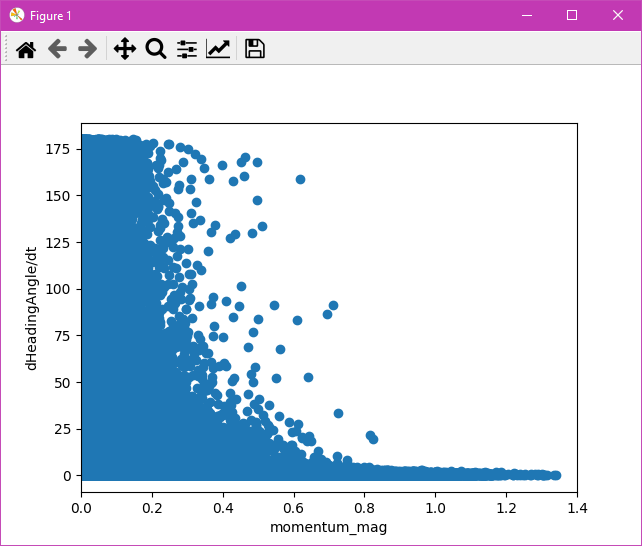

In [ ]:
pos_df['speed_xy'].min()
pos_df['speed_xy'].max()

# Define the bounds for the 90% range (5th to 95th percentile)
lower_bound = pos_df['speed_xy'].quantile(0.05)
upper_bound = pos_df['speed_xy'].quantile(0.95)

# Apply normalization and clip values outside the [0, 1] range
pos_df['speed_xy_normalized'] = (pos_df['speed_xy'] - lower_bound) / (upper_bound - lower_bound).clip(0, 1)

heading_unit_xy = pos_df['heading_unit_xy']
momentum_vector_xy = np.array(heading_unit_xy) * pos_df['speed_xy_normalized'] / 20.0


In [ ]:
## Subsampling question of momentum -- does subsampling in time, so there are larger jumps between successive time points, result in notably different momentum vectors?



In [ ]:
import pandas as pd
import numpy as np
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import MomentumHelpers


a_decoder_name = 'roam'
## INPUTS: decoder_pos_dfs, decoder_extra_dicts
# df: pd.DataFrame = deepcopy(pos_df)
df: pd.DataFrame = deepcopy(decoder_pos_dfs[a_decoder_name])

## Add in `extra_dict`
extra_dict = decoder_extra_dicts[a_decoder_name] # decoder_output_dict_dicts[a_decoder_name]['continuous']
# extra_dict
c_optimal = decoder_output_dict_dicts[a_decoder_name]['continuous']['c_optimal']
F_max = decoder_output_dict_dicts[a_decoder_name]['continuous']['F_max'] # c_optimal * (np.pi / 180.0)
F_max

# df['momentum_mag'] ## drop the first entry
df = df.iloc[1:]
df['momentum_mag'] = extra_dict['momentum_mag'] ## drop the first entry
df['dtheta'] = extra_dict['dtheta'] ## drop the first entry
df['dTheta_dt'] = extra_dict['dTheta_dt'] ## drop the first entry

## ['momentum_mag', 'dTheta_dt', 'dtheta']
df = MomentumHelpers.compute_momentum_limited_change_df(df=df, F_max=F_max)
df


In [ ]:

# extra_dict = dict(momentum_mag=momentum_mag[1:], dTheta_dt=dTheta_dt, dtheta=dtheta)

# Assuming your dataframe is named 'df'
t = df['t'].values
x = df['x_smooth'].values
y = df['y_smooth'].values

# 1. Compute Velocity Components (First Derivative)
# np.gradient(array, time_steps) computes dx/dt
vx = np.gradient(x, t)
vy = np.gradient(y, t)

# Compute Scalar Speed
v = np.sqrt(vx**2 + vy**2)

# 2. Compute Acceleration Components (Second Derivative)
ax = np.gradient(vx, t)
ay = np.gradient(vy, t)

# Compute Scalar Acceleration
a = np.sqrt(ax**2 + ay**2)

# 3. Compute Curvature (Kappa)
# We add a tiny epsilon to the denominator to prevent division by zero 
# when the animal is perfectly stationary (speed = 0).
epsilon = 1e-8 
kappa_numerator = np.abs(vx * ay - vy * ax)
kappa_denominator = (v**3) + epsilon
kappa = kappa_numerator / kappa_denominator

# 4. Assign the computations back to the DataFrame
df['v_x'] = vx
df['v_y'] = vy
df['speed'] = v
df['a_x'] = ax
df['a_y'] = ay
df['acceleration'] = a
df['curvature'] = kappa

mass_m = 1.0
c_optimal = decoder_output_dict_dicts[a_decoder_name]['continuous']['c_optimal']
F_max = decoder_output_dict_dicts[a_decoder_name]['continuous']['F_max'] # c_optimal * (np.pi / 180.0)
F_max

## derive curvature_max
df['curvature_max'] = F_max / (mass_m * (df['speed']**2))
df['omega_max'] = F_max / (mass_m * df['speed'])

## OUTPUTS: F_max, ['curvature_max', 'omega_max']

df = df.dropna(subset=['curvature', 'momentum_mag'], how='any', inplace=False)
df

In [ ]:
## determine a_max emperically
# df['acceleration'] ## 360 seems like  a good cutoff

# np.nanmax(np.abs(df['acceleration'].to_numpy())) ## 360 seems like  a good cutoff

# 95 * np.nanmax(np.abs(df['acceleration'].to_numpy())) ## 360 seems like  a good cutoff

# Define the biological limit (example: 15.0 m/s^2)
a_max: float = 303.0 ## 95% value inclusion emperically
print(f'a_max: {a_max}')
n_total: int = len(df['acceleration'].to_numpy())
n_exceeding_max: int = np.sum(df['acceleration'] <= a_max)
percent_emperical_values_included_with_cutoff: float = float(n_exceeding_max)/float(n_total)
print(f'percent_emperical_values_included_with_cutoff: {percent_emperical_values_included_with_cutoff}')

# ['approx_head_dir_degrees', 'dTheta_dt']



In [ ]:
## compute the limited columns:


In [ ]:
# Define the biological limit (example: 15.0 m/s^2)
# a_max = 15.0 
print(f'a_max: {a_max}')

# 1. Flag where the total force required exceeds the limit
df['exceeds_force_limit'] = df['acceleration'] > a_max

# 2. Calculate the theoretical MAXIMUM allowed curvature at each point in time
# based on the animal's instantaneous speed: kappa_max = a_max / v^2
df['max_allowed_curvature'] = a_max / (df['speed']**2 + epsilon)

# 3. Flag where the animal's actual turn was "too sharp" for its current speed
df['exceeds_turn_limit'] = df['curvature'] > df['max_allowed_curvature']

df

In [ ]:
['momentum_x_smooth', 'momentum_y_smooth']

['t', 'dt']
['speed_xy']
['x_smooth', 'y_smooth']
['velocity_x_smooth', 'velocity_y_smooth']
['acceleration_x_smooth', 'acceleration_y_smooth']

In [ ]:
# 1. Calculate dynamic time steps (Delta t)
# This handles uneven frame rates gracefully
dt = np.gradient(df['t'].values)

## INPUTS: a_max

# --- CONCEPT 1: COUPLED ACCELERATION BOUNDS ---
# We use np.maximum(0, ...) to prevent taking the square root of a negative 
# number in case noisy data pushed the animal slightly over a_max.
df['ax_upper_bound'] = np.sqrt(np.maximum(0, a_max**2 - df['a_y']**2))
df['ax_lower_bound'] = -df['ax_upper_bound']

df['ay_upper_bound'] = np.sqrt(np.maximum(0, a_max**2 - df['a_x']**2))
df['ay_lower_bound'] = -df['ay_upper_bound']


# --- CONCEPT 2: PREDICTIVE POSITION BOUNDS ---
# These columns calculate the maximum physical bounds for where the animal 
# could possibly be on the NEXT row (t + dt).
df['x_next_upper'] = df['x_smooth'] + (df['v_x'] * dt) + (0.5 * a_max * dt**2)
df['x_next_lower'] = df['x_smooth'] + (df['v_x'] * dt) - (0.5 * a_max * dt**2)

df['y_next_upper'] = df['y_smooth'] + (df['v_y'] * dt) + (0.5 * a_max * dt**2)
df['y_next_lower'] = df['y_smooth'] + (df['v_y'] * dt) - (0.5 * a_max * dt**2)

# To compare these bounds against reality, you can shift the next actual position backwards
df['actual_x_next'] = df['x_smooth'].shift(-1)
df['actual_y_next'] = df['y_smooth'].shift(-1)

# Check if the next point violated the physics envelope
df['x_envelope_violation'] = (df['actual_x_next'] > df['x_next_upper']) | (df['actual_x_next'] < df['x_next_lower'])

df

In [ ]:
## add a new dock
	
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import SynchronizedPlotMode

track_name: str = 'CustomMomentumCurvePlot'
# track_ts_widget, track_fig, track_ax_list, dDisplayItem = spike_raster_plt_2d.add_new_matplotlib_render_plot_widget(name=track_name)
a_time_sync_pyqtgraph_widget, track_root_graphics_layout_widget, track_plot_item, dDisplayItem = active_2d_plot.add_new_embedded_pyqtgraph_render_plot_widget(name=track_name, dockSize=(500, 100), sync_mode=SynchronizedPlotMode.TO_WINDOW)
track_plot_item


In [ ]:
curves_dict = MomentumHelpers.plot_momentum_pyqtgraph_line_plot(df=df, track_root_graphics_layout_widget=track_root_graphics_layout_widget)

In [ ]:
active_2d_plot.sync_matplotlib_render_plot_widget(identifier=track_name, sync_mode=SynchronizedPlotMode.TO_WINDOW) ## set sync mode

In [ ]:
xy_plot_item = track_root_graphics_layout_widget.addPlot(row=0, col=0)
legend = pg.LegendItem((80,60), offset=(70,20))
legend.setParentItem(xy_plot_item.graphicsItem())
xy_plot_item

In [ ]:
momentum_plot_item = track_root_graphics_layout_widget.addPlot(row=1, col=0)
momentum_plot_item

In [ ]:
from qtpy import QtCore

curves_dict = {}
curve_kwargs = {'x': dict(pen=pg.mkPen(pg.mkColor(255, 0, 0, 200), width=0.5)), 'y': dict(pen=pg.mkPen(pg.mkColor(0, 255, 0, 200), width=0.5))}
# curve_kwargs = dict(pen='r', symbol='t', symbolPen='r', symbolBrush='g')
curves_dict['x_smooth'] = xy_plot_item.plot(x=df['t'].to_numpy(), y=df['x_smooth'].to_numpy(), name='x_smooth', **curve_kwargs['x'])
curves_dict['y_smooth'] = xy_plot_item.plot(x=df['t'].to_numpy(), y=df['y_smooth'].to_numpy(), name='y_smooth', **curve_kwargs['y'])
legend.addItem(curves_dict['x_smooth'], 'x_smooth')
legend.addItem(curves_dict['y_smooth'], 'y_smooth')


# Add lower/upper bounds curves ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #


# bounds_curve_kwargs = {'x': dict(pen=pg.mkPen(pg.mkColor(255, 0, 0, 100), width=0.5)), 'y': dict(pen=pg.mkPen(pg.mkColor(0, 255, 0, 100), width=0.5))} # dict(pen='r', symbol='t', symbolPen='r', symbolBrush='g')
# bounds_curve_kwargs = {'x': dict(pen=pg.mkPen(None)), 'y': dict(pen=pg.mkPen(None))} # dict(pen='r', symbol='t', symbolPen='r', symbolBrush='g')
bounds_curve_kwargs = {'x': dict(pen=pg.mkPen((144, 0, 0, 100), width=1, style=QtCore.Qt.DashLine)), 'y': dict(pen=pg.mkPen((0, 144, 0, 100), width=1, style=QtCore.Qt.DashLine))} # dict(pen='r', symbol='t', symbolPen='r', symbolBrush='g')
# bounds_curve_brush_kwargs = {'x': dict(pen=pg.mkPen(pg.mkColor(255, 0, 0, 100), width=1), brush=pg.mkBrush(255, 0, 0, 200)), 'y': dict(pen=pg.mkPen(pg.mkColor(0, 255, 0, 100), width=1), brush=pg.mkBrush(0, 255, 0, 200))} # dict(pen='r', symbol='t', symbolPen='r', symbolBrush='g')
# bounds_curve_brush_kwargs = {'x': dict(pen=pg.mkPen(None), brush=pg.mkBrush(255, 0, 0, 200)), 'y': dict(pen=pg.mkPen(None), brush=pg.mkBrush(0, 255, 0, 200))}
bounds_curve_brush_kwargs = {'x': dict(pen=None, brush=pg.mkBrush(255, 0, 0, 200)), 'y': dict(pen=None, brush=pg.mkBrush(0, 255, 0, 200))}
 ## Make a dashed yellow line 2px wide

bounds_curve_names = [('x_next_upper', 'x_next_lower'), ('y_next_upper', 'y_next_lower')]
for (upper_bound_name, lower_bound_name) in bounds_curve_names:
    fill_between_item_name: str = lower_bound_name.removesuffix('_lower') ## "x_next", "y_next"
    x_or_y_name: str = fill_between_item_name.removesuffix('_next') ## "x_next", "y_next"
    curves_dict[lower_bound_name] = xy_plot_item.plot(x=df['t'].to_numpy(), y=df[lower_bound_name].to_numpy(), name=lower_bound_name, **bounds_curve_kwargs[x_or_y_name])
    curves_dict[upper_bound_name] = xy_plot_item.plot(x=df['t'].to_numpy(), y=df[upper_bound_name].to_numpy(), name=upper_bound_name, **bounds_curve_kwargs[x_or_y_name])
    legend.addItem(curves_dict[lower_bound_name], lower_bound_name)
    legend.addItem(curves_dict[upper_bound_name], upper_bound_name)
    
    # fill_between_item_name: str = lower_bound_name.removesuffix('_lower') ## "x_next", "y_next"
    fill_between_item_name = f"{fill_between_item_name}_bounds"
    curves_dict[fill_between_item_name] = pg.FillBetweenItem(curves_dict[lower_bound_name], curves_dict[upper_bound_name], **bounds_curve_brush_kwargs[x_or_y_name]) # , name=fill_between_item_name
    # legend.addItem(curves_dict[fill_between_item_name], fill_between_item_name)


# df['x_next_upper']
# df['x_next_lower']

# df['y_next_upper']
# df['y_next_lower']

In [ ]:
curves_dict['y_smooth'] = track_root_graphics_layout_widget.addPlot(x=df['t'].to_numpy(), y=df['y_smooth'].to_numpy(), name='y_smooth')

In [ ]:
# curve
c1 = win.plot([np.random.randint(0,8) for i in range(10)], pen='r', symbol='t', symbolPen='r', symbolBrush='g', name='curve1')
c2 = win.plot([2,1,4,3,1,3,2,4,3,2], pen='g', fillLevel=0, fillBrush=(255,255,255,30), name='curve2')

# scatter plot
s1 = pg.ScatterPlotItem(size=10, pen=pg.mkPen(None), brush=pg.mkBrush(255, 255, 255, 120), name='scatter')
spots = [{'pos': [i, np.random.randint(-3, 3)], 'data': 1} for i in range(10)]
s1.addPoints(spots)
win.addItem(s1)

# # option2: generic method------------------------------------------------
legend = pg.LegendItem((80,60), offset=(70,20))
legend.setParentItem(win.graphicsItem())
legend.addItem(bg1, 'bar')
legend.addItem(c1, 'curve1')
legend.addItem(c2, 'curve2')
legend.addItem(s1, 'scatter')


In [ ]:
a_time_sync_pyqtgraph_widget.getRootPlotItem().setXRange(active_2d_plot.total_data_start_time, active_2d_plot.total_data_end_time, padding=0) ## global frame
# widget.getRootPlotItem().set_xlim(active_2d_plot.total_data_start_time, active_2d_plot.total_data_end_time)
# widget.update(None)
# widget.draw()
a_time_sync_pyqtgraph_widget.getRootPlotItem().update()

In [ ]:
import pyphoplacecellanalysis.External.pyqtgraph as pg

win = pg.plot()
win

## 3D Tuning curves

In [ ]:
_out = dict()
_out['_display_3d_interactive_tuning_curves_plotter'] = curr_active_pipeline.display(display_function='_display_3d_interactive_tuning_curves_plotter', active_session_configuration_context=IdentifyingContext(format_name='bapun',animal='RatN',session_name='Day4OpenField',filter_name='roam')) # _display_3d_interactive_tuning_curves_plotter


In [ ]:
_out['_display_3d_interactive_tuning_curves_plotter_sprinkle'] = curr_active_pipeline.display(display_function='_display_3d_interactive_tuning_curves_plotter', active_session_configuration_context=IdentifyingContext(format_name='bapun',animal='RatN',session_name='Day4OpenField',filter_name='sprinkle')) # _display_3d_interactive_tuning_curves_plotter


In [ ]:
display_output = _out['_display_3d_interactive_tuning_curves_plotter']
# a_pf_pyvista_plotter = display_output['ipcDataExplorer']
display_output['plotter']

 

In [ ]:
# Check if auto_update is available and enable it
if hasattr(display_output['plotter'], 'auto_update'):
    display_output['plotter'].auto_update = True

In [ ]:
from pyphoplacecellanalysis.Pho3D.PyVista.peak_prominences import render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter

display_output = {}
active_config_name = 'roam'
print(f'active_config_name: {active_config_name}')
active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)
pActiveTuningCurvesPlotter = None
display_output = display_output | curr_active_pipeline.display('_display_3d_interactive_tuning_curves_plotter', active_config_name, extant_plotter=display_output.get('pActiveTuningCurvesPlotter', None), panel_controls_mode='Qt', should_nan_non_visited_elements=False, zScalingFactor=2000.0) # Works now!




In [ ]:
curr_active_pipeline.reload_default_computation_functions()

In [ ]:
## INPUTS: curr_active_pipeline, active_config_name
active_config_name = 'roam'
active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)
if active_peak_prominence_2d_results is None:
    curr_active_pipeline.perform_specific_computation(computation_functions_name_includelist=['ratemap_peaks_prominence2d'], enabled_filter_names=[active_config_name], fail_on_exception=True, debug_print=True)
    # curr_active_pipeline.perform_specific_computation(computation_functions_name_includelist=['ratemap_peaks_prominence2d'], enabled_filter_names=[short_LR_name, short_RL_name, long_any_name, short_any_name], fail_on_exception=False, debug_print=False) # or at least
    active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)
    assert active_peak_prominence_2d_results is not None, f"bad even after computation"

# active_peak_prominence_2d_results

In [ ]:
active_peak_prominence_2d_results

In [ ]:
from pyphoplacecellanalysis.Pho3D.PyVista.peak_prominences import render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter

ipcDataExplorer = display_output['ipcDataExplorer']
if 'pActiveTuningCurvesPlotter' not in display_output:
    display_output['pActiveTuningCurvesPlotter'] = display_output.pop('plotter') # rename the key from the generic "plotter" to "pActiveSpikesBehaviorPlotter" to avoid collisions with others
pActiveTuningCurvesPlotter = display_output['pActiveTuningCurvesPlotter']
root_dockAreaWindow, placefieldControlsContainerWidget, pf_widgets = display_output['pane'] # for Qt mode

active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)
render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter(ipcDataExplorer, active_peak_prominence_2d_results, debug_print=True, 
    include_contour_bounding_box=True,
    include_text_labels=True,
    )

In [ ]:
from pyphoplacecellanalysis.Pho3D.PyVista.peak_prominences import render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter

display_output = {}
active_config_name = long_LR_name
print(f'active_config_name: {active_config_name}')
active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)
pActiveTuningCurvesPlotter = None
display_output = display_output | curr_active_pipeline.display('_display_3d_interactive_tuning_curves_plotter', active_config_name, extant_plotter=display_output.get('pActiveTuningCurvesPlotter', None), panel_controls_mode='Qt', should_nan_non_visited_elements=False, zScalingFactor=2000.0) # Works now!
ipcDataExplorer = display_output['ipcDataExplorer']
display_output['pActiveTuningCurvesPlotter'] = display_output.pop('plotter') # rename the key from the generic "plotter" to "pActiveSpikesBehaviorPlotter" to avoid collisions with others
pActiveTuningCurvesPlotter = display_output['pActiveTuningCurvesPlotter']
root_dockAreaWindow, placefieldControlsContainerWidget, pf_widgets = display_output['pane'] # for Qt mode

active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)
render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter(ipcDataExplorer, active_peak_prominence_2d_results)

In [ ]:
# Now you can toggle them
neuron_id = 4
peaks = ipcDataExplorer.plots['tuningCurvePlotActors'][neuron_id].peaks
peaks.contours.SetVisibility(1)  # Show contours
peaks.boxes.SetVisibility(1)
peaks.text.SetVisibility(1)
peaks.peak_points.SetVisibility(1)
ipcDataExplorer.p.render()

In [ ]:
# Access peaks for a specific neuron
neuron_id = 9
peaks = ipcDataExplorer.plots['tuningCurvePlotActors'][neuron_id].peaks

# # Toggle individual categories
# peaks.contours.SetVisibility(1)  # Show contours
# peaks.boxes.SetVisibility(1)     # Hide bounding boxes
# peaks.text.SetVisibility(1)       # Hide text labels
# peaks.peak_points.SetVisibility(1) # Show peak points

# Or toggle all at once
peaks.SetVisibility(1)  # Show everything
# peaks.SetVisibility(0)   # Hide everything

# Update the display
ipcDataExplorer.p.render()

In [ ]:
# type(ipcDataExplorer.plots['tuningCurvePlotActors'])
dict(ipcDataExplorer.plots['tuningCurvePlotActors'])


In [ ]:
for neuron_id, a_neuron_impl in dict(ipcDataExplorer.plots['tuningCurvePlotActors']).items():
    if a_neuron_impl is not None:
        print(neuron_id)
        print(a_neuron_impl)

        peaks = a_neuron_impl.peaks
        # peaks.SetVisibility(0)   # Hide everything
        peaks.contours.SetVisibility(1)  # Show contours
        # peaks.boxes.SetVisibility(1)     # Hide bounding boxes
        # peaks.text.SetVisibility(1)       # Hide text labels
        # peaks.peak_points.SetVisibility(1) # Show peak points


In [ ]:
active_peak_prominence_2d_results.filtered_flat_peaks_df

In [ ]:
active_peak_prominence_2d_results.flat_peaks_df

In [ ]:
from pyphoplacecellanalysis.Pho3D.PyVista.peak_prominences import render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter

display_output = _out['_display_3d_interactive_tuning_curves_plotter']
ipcDataExplorer = display_output['ipcDataExplorer']
if 'pActiveTuningCurvesPlotter' not in display_output:
    display_output['pActiveTuningCurvesPlotter'] = display_output.pop('plotter') # rename the key from the generic "plotter" to "pActiveSpikesBehaviorPlotter" to avoid collisions with others
pActiveTuningCurvesPlotter = display_output['pActiveTuningCurvesPlotter']
root_dockAreaWindow, placefieldControlsContainerWidget, pf_widgets = display_output['pane'] # for Qt mode

# slab_results_dict: Dict[Tuple, SlabResult] = {k:SlabResult(**a_slab_result_dict) for k, a_slab_result_dict in simplified_obj.results.items()}

# active_peak_prominence_2d_results = curr_active_pipeline.computation_results[active_config_name].computed_data.get('RatemapPeaksAnalysis', {}).get('PeakProminence2D', None)

active_peak_prominence_2d_results = simplified_obj # slab_results_dict: Dict[Tuple, SlabResult] = {k:SlabResult(**a_slab_result_dict) for k, a_slab_result_dict in simplified_obj.results.items()}
render_all_neuron_peak_prominence_2d_results_on_pyvista_plotter(ipcDataExplorer, active_peak_prominence_2d_results)

## ✅ 2025-09-19 - Clean programmmatic figure outputs 

In [ ]:
from pyphocorehelpers.plotting.figure_management import PhoActiveFigureManager2D, capture_new_figures_decorator
fig_man = PhoActiveFigureManager2D(name=f'fig_man') # Initialize a new figure manager
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.DockAreaWrapper import DockAreaWrapper
from pyphoplacecellanalysis.General.Mixins.ExportHelpers import programmatic_render_to_file, programmatic_display_to_PDF, extract_figures_from_display_function_output

# fig_man.close_all()

# subset_includelist = ['maze1', 'maze2', 'maze_GLOBAL'] # Day5TwoNovel
# subset_includelist = ['roam', 'sprinkle'] # Day4

subset_includelist = hardcoded_params.decoder_building_session_names
print(f'subset_includelist: {subset_includelist}')

In [ ]:
# display_fn_kwargs = dict(subplots=(None, 9))
display_fn_kwargs = dict(subplots=(None, 7))

# _out = dict()
# _out['_display_2d_placefield_result_plot_ratemaps_2D'] = curr_active_pipeline.display(display_function='_display_2d_placefield_result_plot_ratemaps_2D', active_session_configuration_context=IdentifyingContext(format_name='bapun',animal='RatS',session_name='Day5TwoNovel',filter_name='maze1'), **display_fn_kwargs) # _display_2d_placefield_result_plot_ratemaps_2D
# _out['_display_2d_placefield_result_plot_ratemaps_2D'] = curr_active_pipeline.display(display_function='_display_2d_placefield_result_plot_ratemaps_2D', active_session_configuration_context=IdentifyingContext(format_name='bapun',animal='RatS',session_name='Day5TwoNovel',filter_name='maze2'), **display_fn_kwargs) # _display_2d_placefield_result_plot_ratemaps_2D


In [ ]:
_out_list = programmatic_render_to_file(curr_active_pipeline=curr_active_pipeline, curr_display_function_name='_display_2d_placefield_result_plot_ratemaps_2D', subset_includelist=subset_includelist, 
                                        write_vector_format=True, write_png=True, debug_print=True, **display_fn_kwargs)


In [ ]:
_out_list = programmatic_render_to_file(curr_active_pipeline=curr_active_pipeline, curr_display_function_name='_display_2d_placefield_occupancy', subset_includelist=subset_includelist, 
                                        write_vector_format=True, write_png=True, debug_print=True)


## `Spike3DRasterWindowWidget` Cell

In [ ]:
from neuropy.utils.mixins.time_slicing import TimeColumnAliasesProtocol
from neuropy.core.flattened_spiketrains import SpikesAccessor
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import Spike2DRaster
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.helpers import ScrollableRasterViewOwnerMixin
from pyphoplacecellanalysis.GUI.Qt.SpikeRasterWindows.Spike3DRasterWindowWidget import Spike3DRasterWindowWidget
# from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import _setup_spike_raster_window_for_debugging
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.Mixins.Render2DScrollWindowPlot import ScatterItemData # used in `NewSimpleRaster`

active_spikes_df = deepcopy(curr_active_pipeline.sess.spikes_df)

# INLINEING `build_spikes_data_values_from_df`: ______________________________________________________________________ #
# curr_spike_x, curr_spike_y, curr_spike_pens, all_scatterplot_tooltips_kwargs, all_spots, curr_n = cls.build_spikes_data_values_from_df(spikes_df, config_fragile_linear_neuron_IDX_map, is_spike_included=is_spike_included, should_return_data_tooltips_kwargs=should_return_data_tooltips_kwargs, **kwargs)
# All units at once approach:
active_time_variable_name = active_spikes_df.spikes.time_variable_name
print(f'active_time_variable_name: {active_time_variable_name}')
if active_time_variable_name != 't': 
    active_spikes_df = TimeColumnAliasesProtocol.renaming_synonym_columns_if_needed(active_spikes_df, required_columns_synonym_dict={"t":{active_time_variable_name,'t_rel_seconds', 't_seconds'}})
    active_spikes_df = active_spikes_df.drop(columns=[active_time_variable_name], inplace=False) ## drop the old column    
    active_time_variable_name = 't' ## get the new one
    active_spikes_df.spikes.set_time_variable_name('t')
    # default_datapoint_column_names = [active_spikes_df.spikes.time_variable_name, 'aclu', 'fragile_linear_neuron_IDX']
    # active_datapoint_column_names = default_datapoint_column_names
    active_spikes_df
    
# active_spikes_df.spikes.time_variable_name
# active_spikes_df

# Gets the existing SpikeRasterWindow or creates a new one if one doesn't already exist:
# spike_raster_window, (active_2d_plot, active_3d_plot, main_graphics_layout_widget, main_plot_widget, background_static_scroll_plot_widget) = Spike3DRasterWindowWidget.find_or_create_if_needed(curr_active_pipeline, force_create_new=True, allow_replace_hardcoded_main_plots_with_tracks=True)
# spike_raster_window, (active_2d_plot, active_3d_plot, main_graphics_layout_widget, main_plot_widget, background_static_scroll_plot_widget) = Spike3DRasterWindowWidget.find_or_create_if_needed(curr_active_pipeline, force_create_new=False, allow_replace_hardcoded_main_plots_with_tracks=True)
# spike_raster_window, (active_2d_plot, active_3d_plot, *_all_outputs_dict) = Spike3DRasterWindowWidget.find_or_create_if_needed(curr_active_pipeline, force_create_new=False, allow_replace_hardcoded_main_plots_with_tracks=True)
# spike_raster_window, (active_2d_plot, active_3d_plot, *_all_outputs_dict) = Spike3DRasterWindowWidget.find_or_create_if_needed(curr_active_pipeline, force_create_new=True, allow_replace_hardcoded_main_plots_with_tracks=True, active_session_configuration_context='maze_GLOBAL')
spike_raster_window, (active_2d_plot, active_3d_plot, *_all_outputs_dict) = Spike3DRasterWindowWidget.find_or_create_if_needed(curr_active_pipeline, force_create_new=True, allow_replace_hardcoded_main_plots_with_tracks=True, active_session_configuration_context='maze_GLOBAL')

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_proper_epoch_intervals, build_bapun_all_epochs_df

a_rect_item, an_interval_ds = build_proper_epoch_intervals(curr_active_pipeline=curr_active_pipeline, active_2d_plot=active_2d_plot)


In [ ]:
an_interval_ds

In [ ]:
active_2d_plot.update_epochs_from_configs_widget()
# update_rendered_intervals_visualization_properties

In [ ]:
# Epoch Display Configs Update Dictionary
epoch_display_configs_update_dict = {
    'SessionEpochs': dict(y_location=-1.0, height=0.9, pen_color='#490000', pen_opacity=1.0, brush_color='#f51616', brush_opacity=1.0),
    'custom_paradigm': [
        dict(y_location=0.0, height=1.0, pen_color='#ffffff', pen_opacity=1.0, brush_color='#1f77b4', brush_opacity=1.0),
        dict(y_location=0.0, height=1.0, pen_color='#ffffff', pen_opacity=1.0, brush_color='#d62728', brush_opacity=1.0),
        dict(y_location=0.0, height=1.0, pen_color='#ffffff', pen_opacity=1.0, brush_color='#f7b6d2', brush_opacity=1.0),
        dict(y_location=0.0, height=1.0, pen_color='#ffffff', pen_opacity=1.0, brush_color='#9edae5', brush_opacity=1.0),
    ],
    'Laps': dict(y_location=-2.0, height=0.9, pen_color='#ff0000', pen_opacity=1.0, brush_color='#ff0000', brush_opacity=1.0),
    'PBEs': dict(y_location=-3.0, height=0.9, pen_color='#ffffff', pen_opacity=1.0, brush_color='#808080', brush_opacity=1.0),
}

In [ ]:
# Epoch Display Configs Update Dictionary
epoch_display_configs_update_dict = {
    'epoch_1': dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
    'epoch_2': dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
    'epoch_3': [
        dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
        dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
        dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
        dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
    ],
    'epoch_4': dict(y_location=-12.0, height=7.5, pen_color='#00ffff', pen_opacity=0.8, brush_color='#00ffff', brush_opacity=0.5),
}

In [ ]:
# preview_overview_scatter_plot: pg.ScatterPlotItem  = active_2d_plot.plots.preview_overview_scatter_plot # ScatterPlotItem 
# preview_overview_scatter_plot.setDownsampling(auto=True, method='subsample', dsRate=10)
# main_graphics_layout_widget: pg.GraphicsLayoutWidget = active_2d_plot.ui.main_graphics_layout_widget
wrapper_layout: pg.QtWidgets.QVBoxLayout = active_2d_plot.ui.wrapper_layout
# main_content_splitter = active_2d_plot.ui.main_content_splitter # QSplitter
layout = active_2d_plot.ui.layout
background_static_scroll_window_plot = active_2d_plot.plots.background_static_scroll_window_plot # PlotItem
main_plot_widget = active_2d_plot.plots.main_plot_widget # PlotItem
# active_window_container_layout = active_2d_plot.ui.active_window_container_layout # GraphicsLayout, first item of `main_graphics_layout_widget` -- just the active raster window I think, there is a strange black space above it

In [ ]:
a_menu = active_2d_plot._menuContextAddRenderable
a_menu

In [ ]:
print_keys_if_possible('active_2d_plot', active_2d_plot, max_depth=1)

In [ ]:
active_2d_plot.get_leaf_only_flat_dock_identifiers_list()


In [ ]:

identifer_str: str = 'intervals'
# identifer_str: str = 'new_curves_separate_plot'
# identifer_str: str = 'newDockedWidget'
a_dock, widget = active_2d_plot.find_dock_item_tuple(identifer_str)

In [ ]:
widget

In [ ]:
root_graphics_layout_widget = widget.getRootGraphicsLayoutWidget()
root_graphics_layout_widget
plot_item = widget.getRootPlotItem()
plot_item

In [ ]:
active_parent_menu = widget.menu
active_parent_menu

In [ ]:
active_2d_plot._menuContextAddRenderable

In [ ]:
from PyQt5.QtWidgets import QMenu, QAction
from pyphoplacecellanalysis.GUI.Qt.Menus.LocalMenus_AddRenderable.LocalMenus_AddRenderable import LocalMenus_AddRenderable


# Create your custom menu
custom_menu = QMenu("My Custom Menu")
action1 = QAction("Action 1", custom_menu)
action1.triggered.connect(lambda: print("Action 1 clicked"))
custom_menu.addAction(action1)

action2 = QAction("Action 2", custom_menu)
action2.triggered.connect(lambda: print("Action 2 clicked"))
custom_menu.addAction(action2)

action3 = QAction("Action 3", custom_menu)
action3.triggered.connect(lambda: print("Action 3 clicked"))
custom_menu.addAction(action3)

action4 = QAction("Action 4", custom_menu)
action4.triggered.connect(lambda: print("Action 4 clicked"))
custom_menu.addAction(action4)


# LocalMenus_AddRenderable._helper_append_custom_menu_to_widget_context_menu_universal(parent_widget=new_curves_separate_plot, additional_menu=self._menuContextAddRenderable)
parent_widget = widget # works for MatplotlibTimeSynchronizedWidget 

LocalMenus_AddRenderable._helper_append_custom_menu_to_widget_context_menu_universal(parent_widget=widget, additional_menu=custom_menu, debug_print=True)



In [ ]:

# For a PlotItem
# plot_item = pg.PlotItem()
## INPUTS: plot_item
# Option A: Ensure menu is enabled (if it was disabled)
if hasattr(plot_item, 'vb'):
    plot_item.vb.setMenuEnabled(True)  # This will create the menu if it doesn't exist
    
    # Now check if menu exists
    if plot_item.vb.menu is not None:
        plot_item.vb.menu.addSeparator()
        plot_item.vb.menu.addMenu(custom_menu)
    else:
        print("Warning: Menu is still None after enabling")


In [ ]:

# For a ViewBox directly
# viewbox = pg.ViewBox()
viewbox = plot_item.vb
if hasattr(viewbox, 'menu'):
    viewbox.menu.addSeparator()
    viewbox.menu.addAction(action1)
    

In [ ]:

# For a ViewBox directly
viewbox = pg.ViewBox()
if hasattr(viewbox, 'menu'):
    viewbox.menu.addSeparator()
    viewbox.menu.addAction(action1)

In [ ]:
import PyQtInspect as pyqtinsp

pyqtinsp.pqi.set_widget_highlight(widget=active_2d_plot, highlight=True)


In [ ]:
type(active_2d_plot)

In [ ]:
active_2d_plot.ui


In [ ]:
print_keys_if_possible('active_2d_plot.ui', active_2d_plot.ui, max_depth=2)

In [ ]:
type(spike_raster_window)

In [ ]:
spike_raster_window.ui.wrapper

In [ ]:
active_2d_plot.add_docked_marginal_track(curr_active_pipeline.sess.epochs)
    

In [ ]:
# active_2d_plot.list_all_rendered_intervals()
active_2d_plot.add_laps_intervals(curr_active_pipeline.sess)

active_2d_plot.add_rendered_intervals()



In [ ]:
# curr_active_pipeline.sess.epochs




In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.Mixins.RenderTimeEpochs.Specific2DRenderTimeEpochs import SessionEpochs2DRenderTimeEpochs
from neuropy.core.epoch import ensure_dataframe, ensure_Epoch, Epoch, EpochsAccessor
# SessionEpochs2DRenderTimeEpochs.add_render_time_epochs(curr_sess=curr_active_pipeline.sess.epochs, destination_plot=active_2d_plot)

active_ds = ensure_dataframe(curr_active_pipeline.sess.epochs)
active_ds

_out = active_2d_plot.add_rendered_intervals(active_ds, 'SessionEpochs')

# num_epochs = len(curr_active_pipeline.sess.epochs)

# pen_colors = {'pre': pg.mkColor('purple'), 'roam': pg.mkColor('red'), 'sprinkle': pg.mkColor('red'), 'post': pg.mkColor('purple')}
# brush_colors = {'pre': pg.mkColor('purple'), 'roam': pg.mkColor('red'), 'sprinkle': pg.mkColor('red'), 'post': pg.mkColor('purple')}

# pen_color = list(pen_colors.values())
# brush_color = list(brush_colors.values())
# for a_pen_color in pen_color:
#     a_pen_color.setAlphaF(0.8)

# for a_brush_color in brush_color:
#     a_brush_color.setAlphaF(0.5)


# active_df = cls._update_df_visualization_columns(active_df, y_location, height, pen_color, brush_color, **kwargs)


In [ ]:
active_2d_plot.rendered_epochs


In [ ]:
active_ds = ensure_dataframe(curr_active_pipeline.sess.epochs)
global_epoch_only = ensure_Epoch(active_ds[active_ds['label'] == 'maze_GLOBAL'])
global_epoch_only

curr_active_pipeline.sess
sess.position

## 2025-09-19 - Add Session Paradigm Epochs with a different color for each session

In [ ]:
## 2025-09-19 - Add Session Paradigm Epochs with a different color for each session
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_proper_epoch_intervals, build_bapun_all_epochs_df

a_rect_item, an_interval_ds = build_proper_epoch_intervals(curr_active_pipeline=curr_active_pipeline, active_2d_plot=active_2d_plot)


In [ ]:
a_rect_item

In [ ]:
active_2d_plot: Spike2DRaster = active_2d_plot

In [ ]:
# active_2d_plot.perform_remove_epoch_intervals('SessionEpochs') ## not correct


In [ ]:
active_2d_plot.remove_rendered_intervals('SessionEpochs')


In [ ]:
# curr_x_min, curr_x_max, curr_y_min, curr_y_max = active_2d_plot.get_render_intervals_plot_range()
# (curr_x_min, curr_x_max, curr_y_min, curr_y_max) # (0.14663333333333334, 25986.969433333332, -5.0, 41.0)

In [ ]:
all_series_positioning_dfs, all_series_compressed_positioning_dfs, all_series_compressed_positioning_update_dicts = active_2d_plot.recover_interval_datasources_update_dict_properties()
# all_series_positioning_dfs
all_series_compressed_positioning_dfs # ERROR: series_compressed_positioning_update_dict is None for custom_paradigm. it will not be represented in the output dict.

In [ ]:
out_configs_df = active_2d_plot.extract_interval_display_config_df()
out_configs_df

In [ ]:
from pyphoplacecellanalysis.General.Model.Datasources.IntervalDatasource import IntervalsDatasource
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.epochs_plotting_mixins import EpochDisplayConfig
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.helpers import RectangleRenderTupleHelpers
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.Mixins.RenderTimeEpochs.Render2DEventRectanglesHelper import Render2DEventRectanglesHelper
from pyphocorehelpers.gui.Qt.color_helpers import ColorDataframeColumnHelpers, ColorFormatConverter, QColorColumnsAccessor

custom_paradigm_ds: IntervalsDatasource = active_2d_plot.interval_datasources.custom_paradigm
custom_paradigm_ds


In [ ]:
out_configs_df = active_2d_plot.extract_interval_display_config_df()
out_configs_df
added_col_names_map = out_configs_df.qcolor.convert_QColor_columns_to_hexcolor_columns()
# added_col_names_map
out_configs_df

In [ ]:
out_configs_dict = active_2d_plot.extract_interval_display_config_lists()
out_configs_dict

In [ ]:
custom_paradigm_ds_df = deepcopy(custom_paradigm_ds._df)  # [''
custom_paradigm_ds_df

# ['lap_color', 'lap_accent_color'] ## str (hex-color), str (hex-color)
# ['pen_color', 'brush_color'] ## QColor, QColor
# ['pen', 'brush'] # QPen, QBrush


In [ ]:

custom_paradigm_ds_df.qcolor.find_valid_hex_columns()


In [ ]:

added_col_names_map = custom_paradigm_ds_df.qcolor.convert_QColor_columns_to_hexcolor_columns()
added_col_names_map
# initial_labels: List[str] = deepcopy(list(custom_paradigm_ds_df.columns))

# def is_valid_hex_label(a_label: str) -> bool:
# 	if a_label.startswith('#')
    
# ColorFormatConverter.is_valid_hexstring(

# extant_hex_color_labels = [k for k in initial_labels if k.endswith('_hex')]

# extant_hex_color_labels


In [ ]:
custom_paradigm_ds_df

In [ ]:
custom_paradigm_ds_df['pen'] = 

In [ ]:
series_viz_df = deepcopy(custom_paradigm_ds_df)
series_viz_df['pen_color_hex'] = series_viz_df['pen'].map(lambda x: "#" + ColorDataframeColumnHelpers.QPen_to_dict(x)['color']).str.upper()
series_viz_df['pen_width'] = series_viz_df['pen'].map(lambda x: ColorDataframeColumnHelpers.QPen_to_dict(x)['width'])
series_viz_df['brush_color_hex'] = series_viz_df['brush'].map(lambda x: "#" + ColorDataframeColumnHelpers.QBrush_to_dict(x)['color']).str.upper()
# series_viz_df['brush_color_hex'] = series_viz_df['brush_color_hex'].str.upper()
series_viz_df

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.Mixins.RenderTimeEpochs.Render2DEventRectanglesHelper import Render2DEventRectanglesHelper
from pyphoplacecellanalysis.GUI.Qt.Widgets.EpochRenderConfigWidget.EpochRenderConfigWidget import EpochRenderConfigsListWidget, EpochRenderConfigWidget

an_epochs_display_list_widget: EpochRenderConfigsListWidget = active_2d_plot.ui.get('epochs_render_configs_widget', None)
if an_epochs_display_list_widget is None:
    # create a new one:    
    raise NotImplementedError

update_dict = an_epochs_display_list_widget.config_dicts_from_states()
update_dict


In [ ]:
# brush_colors = [v['brush_color'] for v in update_dict['custom_paradigm']]
# pen_colors = [v['pen_color'] for v in update_dict['custom_paradigm']]

brush_colors_hex = [ColorFormatConverter.qColor_to_hexstring(v['brush_color'], include_alpha=True, use_HexArgb_instead_of_HexRGBA=False) for v in update_dict['custom_paradigm']]
pen_colors_hex = [ColorFormatConverter.qColor_to_hexstring(v['pen_color'], include_alpha=True, use_HexArgb_instead_of_HexRGBA=False) for v in update_dict['custom_paradigm']]



pen_colors_hex
brush_colors_hex

# pen_colors
# brush_colors


In [ ]:
from neuropy.utils.misc import split_list_of_dicts
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.GraphicsObjects.IntervalRectsItem import IntervalRectsItem, IntervalRectsItemData
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.Mixins.RenderTimeEpochs.Specific2DRenderTimeEpochs import General2DRenderTimeEpochs


def _fixed_for_multi_update_df_visualization_columns(active_df: pd.DataFrame, y_location=None, height=None, pen_color=None, brush_color=None, **kwargs) -> pd.DataFrame:
        """ updates the columns of the provided active_df given the values specified. If values aren't provided, they aren't changed. 
        
        active_df['series_vertical_offset', 'series_height', 'pen', 'brush']
        
        """        
        # Update only the provided columns while leaving the others intact
        if y_location is not None:
            ## y_location:
            if isinstance(y_location, (list, tuple)):
                active_df['series_vertical_offset'] = kwargs.setdefault('series_vertical_offset', [a_y_location for a_y_location in y_location])
            else:
                # Scalar value assignment:
                active_df['series_vertical_offset'] = kwargs.setdefault('series_vertical_offset', y_location)
                
        if height is not None:
            ## series_height:
            if isinstance(height, (list, tuple)):
                active_df['series_height'] = kwargs.setdefault('series_height', [a_height for a_height in height])
            else:
                # Scalar value assignment:
                active_df['series_height'] = kwargs.setdefault('series_height', height)

        if pen_color is not None:
            ## pen_color:
            if isinstance(pen_color, (list, tuple)):
                active_df['pen'] = kwargs.setdefault('pen', [pg.mkPen(a_pen_color) for a_pen_color in pen_color])
            else:
                # Scalar value assignment:
                active_df['pen'] = kwargs.setdefault('pen', pg.mkPen(pen_color)) 
            
        if brush_color is not None:
            ## brush_color:
            if isinstance(brush_color, (list, tuple)):
                active_df['brush'] = kwargs.setdefault('brush', [pg.mkBrush(a_color) for a_color in brush_color])  
            else:
                # Scalar value assignment:
                active_df['brush'] = kwargs.setdefault('brush', pg.mkBrush(brush_color))
        
        return active_df #, kwargs


        

interval_key: str = 'custom_paradigm'
# custom_paradigm_update_dict = 
interval_update_kwargs = update_dict[interval_key]
# Extract visibility settings before updating datasource (handle both single dict and list of dicts)
visibility_settings = None
if isinstance(interval_update_kwargs, (list, tuple)):
    ## list of update dicts - each item can have its own isVisible property
    a_list_interval_update_kwargs = []
    visibility_settings = []
    for a_sub_interval_update_kwargs in interval_update_kwargs:
        if not isinstance(a_sub_interval_update_kwargs, dict):
            a_sub_interval_update_kwargs = a_sub_interval_update_kwargs.to_dict() # deal with EpochDisplayConfig 
        a_list_interval_update_kwargs.append(a_sub_interval_update_kwargs)
        # Extract visibility from each item (can be None if not specified)
        visibility_settings.append(a_sub_interval_update_kwargs.get('isVisible', None))
        # self.interval_datasources[interval_key].update_visualization_properties(lambda active_df, **kwargs: General2DRenderTimeEpochs._update_df_visualization_columns(active_df, **(a_sub_interval_update_kwargs | kwargs))) ## Fully inline
    ## END for a_sub_interval_update_kwargs in interval_update_kwargs...
    
    ## Update with list
    # a_list_interval_update_kwargs = [a_sub_interval_update_kwargs for a_sub_interval_update_kwargs in interval_update_kwargs]
    print(f'a_sub_interval_update_kwargs: {a_sub_interval_update_kwargs}')
    print(f'a_list_interval_update_kwargs: {a_list_interval_update_kwargs}')
    # active_2d_plot.interval_datasources[interval_key].update_visualization_properties(lambda active_df, **kwargs: General2DRenderTimeEpochs._update_df_visualization_columns(active_df, **(a_sub_interval_update_kwargs | kwargs))) ## Fully inline
    active_2d_plot.interval_datasources[interval_key].update_visualization_properties(lambda active_df, **kwargs: General2DRenderTimeEpochs._update_df_visualization_columns(active_df, **(split_list_of_dicts(a_list_interval_update_kwargs) | kwargs))) ##  Fixed for multiple lists
    ## #TODO 2026-02-02 13:13: - [ ] `visibility_settings` is never used.

else:
    ## single update item dict
    if not isinstance(interval_update_kwargs, dict):
        interval_update_kwargs = interval_update_kwargs.to_dict() # deal with EpochDisplayConfig 
    visibility_settings = interval_update_kwargs.get('isVisible', None)
    print(f'interval_update_kwargs: {interval_update_kwargs}')
    active_2d_plot.interval_datasources[interval_key].update_visualization_properties(lambda active_df, **kwargs: General2DRenderTimeEpochs._update_df_visualization_columns(active_df, **(interval_update_kwargs | kwargs))) ## Fully inline


In [ ]:
visibility_settings

In [ ]:
a_list_interval_update_kwargs ## convert from a list of dict to a dict-of-lists
split_list_of_dicts(a_list_interval_update_kwargs)

In [ ]:
interval_update_kwargs

In [ ]:

# Apply visibility setting to rendered items if provided
# For list configs: only apply if all items have the same visibility (or all None)
# For single configs: apply directly
if visibility_settings is not None and interval_key in active_2d_plot.rendered_epochs:
    if isinstance(visibility_settings, list):
        # List case: check if all non-None values are the same
        non_none_visibilities = [v for v in visibility_settings if v is not None]
        if len(non_none_visibilities) > 0:
            # If all non-None values are the same, apply that visibility
            if len(set(non_none_visibilities)) == 1:
                is_visible = non_none_visibilities[0]
                container = active_2d_plot.rendered_epochs[interval_key]
                for a_plot, rect_item in container.items():
                    if not isinstance(a_plot, str) and isinstance(rect_item, IntervalRectsItem):
                        rect_item.setVisible(is_visible)
            # If they differ, we can't set per-rectangle visibility, so skip
            # (IntervalRectsItem is a single graphics item that renders all rectangles)
    else:
        # Single config case: apply directly
        container = active_2d_plot.rendered_epochs[interval_key]
        for a_plot, rect_item in container.items():
            if not isinstance(a_plot, str) and isinstance(rect_item, IntervalRectsItem):
                rect_item.setVisible(visibility_settings)

In [ ]:

# [RectangleRenderTupleHelpers.QColor_to_simple_columns_dict(v)['hexColor'] for v in brush_colors]
# [RectangleRenderTupleHelpers.QColor_to_simple_columns_dict(v)['alpha'] for v in brush_colors]

[ColorFormatConverter.qColor_to_hexstring(v, include_alpha=True) for v in brush_colors]





In [ ]:
# Determine interval_keys that are missing from update_dict but exist in self.interval_datasources
removed_interval_keys = [k for k in active_2d_plot.rendered_epoch_series_names if k not in update_dict] # need to use this and not `self.interval_datasources.keys()` directly because it has non-attribute members like 'name'


In [ ]:
series_viz_df['pen_color'] == custom_paradigm_ds_df['pen_color']

In [ ]:
a_serializable_df = custom_paradigm_ds.get_serialized_data(drop_duplicates=False)
a_serializable_df


In [ ]:
all_series_positioning_dfs, all_series_compressed_positioning_dfs, all_series_compressed_positioning_update_dicts = active_2d_plot.recover_interval_datasources_update_dict_properties()
# all_series_positioning_dfs
all_series_compressed_positioning_dfs # ERROR: series_compressed_positioning_update_dict is None for custom_paradigm. it will not be represented in the output dict.

In [ ]:
out_configs_df = active_2d_plot.extract_interval_display_config_df()
out_configs_df

In [ ]:
bottom_y_min, top_y_max = active_2d_plot.get_interval_y_extrema_locations()
curr_x_min, curr_x_max, curr_y_min, curr_y_max = active_2d_plot.get_render_intervals_plot_range()
new_y_min = min(curr_y_min, bottom_y_min)
new_y_max = max(curr_y_max, top_y_max)
for a_plot in active_2d_plot.interval_rendering_plots:
    a_plot.setYRange(new_y_min, new_y_max, padding=0)



In [ ]:
# active_2d_plot.get_render_intervals_plot_range(debug_print=True)
curr_x_min, curr_x_max, curr_y_min, curr_y_max = active_2d_plot.get_render_intervals_plot_range(debug_print=True)

# active_2d_plot.update_rendered_interval_heights(41.0)

In [ ]:
for a_plot_item in active_2d_plot.interval_rendering_plots:
    # a_plot_item: pg.PlotItem = active_2d_plot.interval_rendering_plots[0]
    a_plot_item.setYRange(curr_y_min, curr_y_max)
    # a_plot_item.update()

In [ ]:
# active_2d_plot.build_epoch_intervals_visual_configs_widget()
spike_raster_window.build_epoch_intervals_visual_configs_widget()


In [ ]:
active_2d_plot.build_or_update_epoch_render_configs_widget()

In [ ]:
# Create a label formatting function that accesses the dataframe
def create_label_format_fn(datasource):
    """Creates a closure that captures the datasource's label column"""
    label_column = datasource.df['label'].tolist()  # or whatever column has the names
    
    def _format_label_for_rect_data(rect_index: int, rect_data_tuple: Tuple) -> str:
        """Returns the label text for this interval. Captures: label_column
        """
        start_t, series_vertical_offset, duration_t, series_height, pen, brush = rect_data_tuple
        end_t = start_t + duration_t
        item_label: str = f"{datasource.custom_datasource_name}[{rect_index}]"
        if rect_index < len(label_column):
            item_label = str(label_column[rect_index])

        label_text = f"{item_label}\nStart: {start_t:.3f}\nEnd: {end_t:.3f}\nDuration: {duration_t:.3f}" # The tooltip is set generically here to 'PBEs', 'Replays' or whatever the dataseries name is
        return label_text        

    return _format_label_for_rect_data


def create_tooltip_format_fn(datasource):
    """Creates a closure that captures the datasource's label column"""
    label_column = datasource.df['label'].tolist()  # or whatever column has the names
    
    def _custom_format_tooltip_for_rect_data(rect_index: int, rect_data_tuple: Tuple) -> str:
        """ Captures: label_column"""
        start_t, series_vertical_offset, duration_t, series_height, pen, brush = rect_data_tuple
        end_t = start_t + duration_t
        item_label: str = f"{datasource.custom_datasource_name}[{rect_index}]"
        if rect_index < len(label_column):
            item_label = str(label_column[rect_index])
            print(f'\tgot specific label: "{item_label}"')
            
        tooltip_text = f"{item_label}\nStart: {start_t:.3f}\nEnd: {end_t:.3f}\nDuration: {duration_t:.3f}" # The tooltip is set generically here to 'PBEs', 'Replays' or whatever the dataseries name is
        return tooltip_text


    return _custom_format_tooltip_for_rect_data



## INPUTS: an_interval_ds, an_interval_rects_item

# Create the label formatter
label_format_fn = create_label_format_fn(an_interval_ds)
tooltip_format_fn = create_tooltip_format_fn(an_interval_ds)

# Update the rendered intervals with labels
# an_interval_rects_item.item_label_format_fn = deepcopy(label_format_fn)
# an_interval_rects_item._current_hovered_item_tooltip_format_fn = deepcopy(tooltip_format_fn)

for plot_name, rect_item_dict in active_2d_plot.get_all_rendered_intervals_dict().items():
    if plot_name == 'custom_paradigm':
        print(f'updating "custom_paradigm" intervals for plot_name: "{plot_name}"...')
        rect_item: IntervalRectsItem = rect_item_dict['RootPlot']
        rect_item.format_item_tooltip_fn = deepcopy(tooltip_format_fn)
        rect_item.item_label_format_fn = deepcopy(label_format_fn)
        # rect_item._current_hovered_item_tooltip_format_fn = deepcopy(tooltip_format_fn)
        # Need to regenerate the labels - this requires recreating the item OR you can manually add labels
        print(f'\tdone.')
        
    else:
        print('WARN: "custom_paradigm" intervals not found!')

In [ ]:
# active_2d_plot.get_all_rendered_intervals_dict()
# active_2d_plot.update() ## crashes the kernel

In [ ]:
# a_final_interval_df
active_2d_plot.build_or_update_epoch_render_configs_widget()

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.GraphicsObjects.IntervalRectsItem import IntervalRectsItem

def _custom_format_tooltip_for_rect_data(rect_index: int, rect_data_tuple: Tuple) -> str:
    start_t, series_vertical_offset, duration_t, series_height, pen, brush = rect_data_tuple
    end_t = start_t + duration_t
    tooltip_text = f"{name}[{rect_index}]\nStart: {start_t:.3f}\nEnd: {end_t:.3f}\nDuration: {duration_t:.3f}" # The tooltip is set generically here to 'PBEs', 'Replays' or whatever the dataseries name is
    return tooltip_text


# active_2d_plot.interval_datasources

_out_rendered_intervals = active_2d_plot.get_all_rendered_intervals_dict()
an_interval_rects_item: IntervalRectsItem = _out_rendered_intervals['custom_paradigm']['RootPlot']
an_interval_rects_item._current_hovered_item_tooltip_format_fn = deepcopy(_custom_format_tooltip_for_rect_data)
an_interval_rects_item

In [ ]:
an_interval_ds.custom_datasource_name

In [ ]:
rect_item

In [ ]:
active_2d_plot.add_rendered_intervals(an_interval_ds, name=f'custom_paradigm', debug_print=False)

In [ ]:
an_interval_rects_item.data

In [ ]:
active_2d_plot.remove_rendered_intervals(

In [ ]:


train_test_split_laps_epochs_formatting_dict = {
    'LapsAll':dict(y_location=-10.0, height=7.5, pen_color=inline_mkColor('white', 0.8), brush_color=inline_mkColor('white', 0.5)),
    'LapsTrain':dict(y_location=-2.0, height=1.5, pen_color=inline_mkColor('purple', 0.8), brush_color=inline_mkColor('purple', 0.5)),
    'LapsTest':dict(y_location=-12.0, height=1.5, pen_color=inline_mkColor('green', 0.8), brush_color=inline_mkColor('green', 0.5)),
}

In [ ]:
curr_active_pipeline.get_output_path()

In [ ]:
# curr_paradigm_df: pd.DataFrame = ensure_dataframe(sess.paradigm)
# curr_paradigm_df: pd.DataFrame = ensure_dataframe(sess.epochs_bak)


curr_paradigm_df: pd.DataFrame = np.load(f"W:/Data/Bapun/RatU/RatUDay5OpenfieldSD/RatU_Day5OpenfieldSD_2021-08-04_08-44-31.paradigm.npy", allow_pickle=True).tolist()['epochs']
curr_paradigm_df['duration'] = curr_paradigm_df['stop'] - curr_paradigm_df['start']
curr_paradigm_df

# curr_paradigm_df

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.GraphicsWidgets.EpochsEditorItem import EpochsEditor # perform_plot_laps_diagnoser
import matplotlib.pyplot as plt
from pyphocorehelpers.gui.Qt.color_helpers import ColormapHelpers, ColorFormatConverter
from neuropy.core.epoch import Epoch, EpochsAccessor, ensure_dataframe, ensure_Epoch, EpochHelpers

def generate_colors(n_epoch):
    cmap = plt.get_cmap('tab20', n_epoch)
    return [plt.matplotlib.colors.rgb2hex(cmap(i)) for i in range(n_epoch)]


sess = curr_active_pipeline.sess # global_session

# pos_df = sess.compute_position_laps() # ensures the laps are computed if they need to be:
position_obj = deepcopy(sess.position)
position_obj.compute_higher_order_derivatives()
pos_df = position_obj.compute_smoothed_position_info(N=20) ## Smooth the velocity curve to apply meaningful logic to it
pos_df = position_obj.to_dataframe()
# Drop rows with missing data in columns: 't', 'velocity_x_smooth' and 2 other columns. This occurs from smoothing
pos_df = pos_df.dropna(subset=['t', 'x_smooth', 'velocity_x_smooth', 'acceleration_x_smooth']).reset_index(drop=True)
# curr_laps_df = sess.laps.to_dataframe()

# curr_paradigm_df = ensure_dataframe(sess.paradigm)

curr_paradigm_df = ensure_dataframe(curr_paradigm_df)
curr_paradigm_df = curr_paradigm_df[np.logical_not(np.isin(curr_paradigm_df['label'], ['maze_GLOBAL', 'maze']))] ## exclude the global epoch
curr_paradigm_df = EpochHelpers.assign_overlap_y_offset(curr_paradigm_df, start_col='start', stop_col='stop', out_col='overlap_y_offset') 
n_epochs: int = len(curr_paradigm_df)
# epoch_color_strs: List[str] = generate_colors(n_epochs)
epoch_color_strs: List[str] = [ColorFormatConverter.qColor_to_hexstring(v, include_alpha=False) for v in ColormapHelpers.mpl_to_pg_colormap(mpl_cmap_name='tab20', resolution=n_epochs).getColors(mode='qcolor')]
curr_paradigm_df['lap_color'] = "#10FF44"
curr_paradigm_df['lap_color'] = epoch_color_strs
curr_paradigm_df['lap_accent_color'] = '#FFFFFF'
curr_paradigm_df
## Create a new window:
custom_epoch_label_kwargs = dict(epoch_label_position=0.05, epoch_label_rotateAxis=(0,0), epoch_label_anchor=(0.0, 1.0))
epochs_editor = EpochsEditor.init_laps_diagnoser(pos_df, curr_paradigm_df, include_velocity=False, include_accel=False, span=(0.05, 0.95), movable=False, **custom_epoch_label_kwargs)

In [ ]:
epochs_editor.plots
# epochs_editor.rebuild_epoch_regions()



In [ ]:
active_2d_plot.plots.main_plot_widget

main_plot_widget = active_2d_plot.plots.main_plot_widget # PlotItem
main_plot_widget.setMinimumHeight(20.0)


In [ ]:
# active_window_container_layout
# main_graphics_layout_widget.ci # GraphicsLayout
main_graphics_layout_widget.ci.childItems()
# main_graphics_layout_widget.setHidden(True) ## hides too much
main_graphics_layout_widget.setHidden(False)

# main_graphics_layout_widget

active_window_container_layout.setBorder(pg.mkPen('yellow', width=4.5))

In [ ]:
# active_window_container_layout.allChildItems()
active_window_container_layout.setPreferredHeight(200.0)
active_window_container_layout.setMaximumHeight(800.0)
active_window_container_layout.setSpacing(0)

In [ ]:
# Set stretch factors to control priority
main_graphics_layout_widget.ci.layout.setRowStretchFactor(0, 400)  # Plot1: lowest priority
main_graphics_layout_widget.ci.layout.setRowStretchFactor(1, 2)  # Plot2: mid priority
main_graphics_layout_widget.ci.layout.setRowStretchFactor(2, 2)  # Plot3: highest priority


In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ParameterTreeWidget import create_parameter_tree_widget
# win, param_tree = create_pipeline_filter_parameter_tree()
win, param_tree = create_parameter_tree_widget(curr_active_pipeline.get_all_parameters())
win.show()

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import SynchronizedPlotMode
from pyphoplacecellanalysis.General.Pipeline.Stages.DisplayFunctions.DecoderPredictionError import plot_1D_most_likely_position_comparsions
from pyphoplacecellanalysis.General.Model.Configs.LongShortDisplayConfig import DecoderIdentityColors
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import _perform_plot_multi_decoder_meas_pred_position_track
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import DecodedFilterEpochsResult

## Build the new dock track:
dock_identifier: str = 'Continuous Decoding Performance'
ts_widget, fig, ax_list, dDisplayItem = active_2d_plot.add_new_matplotlib_render_plot_widget(name=dock_identifier)
## Get the needed data:
directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict
continuously_decoded_result_cache_dict = directional_decoders_decode_result.continuously_decoded_result_cache_dict
previously_decoded_keys: List[float] = list(continuously_decoded_result_cache_dict.keys()) # [0.03333]
print(F'previously_decoded time_bin_sizes: {previously_decoded_keys}')

time_bin_size: float = directional_decoders_decode_result.most_recent_decoding_time_bin_size
print(f'time_bin_size: {time_bin_size}')
continuously_decoded_dict: Dict[str, DecodedFilterEpochsResult] = directional_decoders_decode_result.most_recent_continuously_decoded_dict
all_directional_continuously_decoded_dict: Dict[types.DecoderName, DecodedFilterEpochsResult] = {k:v for k, v in (continuously_decoded_dict or {}).items() if k in TrackTemplates.get_decoder_names()} ## what is plotted in the `f'{a_decoder_name}_ContinuousDecode'` rows by `AddNewDirectionalDecodedEpochs_MatplotlibPlotCommand`
## OUT: all_directional_continuously_decoded_dict
## Draw the position meas/decoded on the plot widget
## INPUT: fig, ax_list, all_directional_continuously_decoded_dict, track_templates


In [ ]:
directional_decoders_decode_result

In [ ]:

_out_artists =  _perform_plot_multi_decoder_meas_pred_position_track(curr_active_pipeline, fig, ax_list, desired_time_bin_size=0.058, enable_flat_line_drawing=True)

## sync up the widgets
active_2d_plot.sync_matplotlib_render_plot_widget(dock_identifier, sync_mode=SynchronizedPlotMode.TO_WINDOW)

In [ ]:
## split into two dfs for each decoder -- the supported and the unsupported
partition

PandasHelpers.safe_pandas_get_group

In [ ]:
pos_df.dropna(axis='index', subset=['lap', 'truth_decoder_name'], inplace=False)

In [ ]:
laps_df: pd.DataFrame = global_laps_obj.to_dataframe()

In [ ]:
from neuropy.core.epoch import EpochHelpers

## INPUTS: global_laps
_out_split_pseudo2D_posteriors_dict = {}
_out_split_pseudo2D_out_dict = {}
pre_filtered_col_names = ['pre_filtered_most_likely_position_indicies', 'pre_filtered_most_likely_position'] # 'pre_filtered_time_bin_containers', 'pre_filtered_p_x_given_n', 
post_filtered_col_names = [a_col_name.removeprefix('pre_filtered_') for a_col_name in pre_filtered_col_names] # ['time_bin_containers', 'most_likely_position_indicies', 'most_likely_position']
print(post_filtered_col_names)
for a_time_bin_size, pseudo2D_decoder_continuously_decoded_result in continuously_decoded_pseudo2D_decoder_dict.items():
    print(f'a_time_bin_size: {a_time_bin_size}')
    _out_split_pseudo2D_out_dict[a_time_bin_size] = {'pre_filtered_p_x_given_n': None, 'pre_filtered_time_bin_containers': None, 'pre_filtered_most_likely_position_indicies': None, 'pre_filtered_most_likely_position': None, 
                                                     'is_timebin_included': None, 'p_x_given_n': None} # , 'time_window_centers': None
    # pseudo2D_decoder_continuously_decoded_result: DecodedFilterEpochsResult = continuously_decoded_dict.get('pseudo2D', None)
    assert len(pseudo2D_decoder_continuously_decoded_result.p_x_given_n_list) == 1
    p_x_given_n = pseudo2D_decoder_continuously_decoded_result.p_x_given_n_list[0]
    # p_x_given_n = pseudo2D_decoder_continuously_decoded_result.p_x_given_n_list[0]['p_x_given_n']
    time_bin_containers = pseudo2D_decoder_continuously_decoded_result.time_bin_containers[0]
    # time_window_centers = time_bin_containers.centers
    _out_split_pseudo2D_out_dict[a_time_bin_size]['pre_filtered_most_likely_position_indicies'] = deepcopy(pseudo2D_decoder_continuously_decoded_result.most_likely_position_indicies_list[0])
    _out_split_pseudo2D_out_dict[a_time_bin_size]['pre_filtered_most_likely_position'] = deepcopy(pseudo2D_decoder_continuously_decoded_result.most_likely_positions_list[0])
    ## INPUTS: time_bin_containers, global_laps
    left_edges = deepcopy(time_bin_containers.left_edges)
    right_edges = deepcopy(time_bin_containers.right_edges)
    continuous_time_binned_computation_epochs_df: pd.DataFrame = pd.DataFrame({'start': left_edges, 'stop': right_edges, 'label': np.arange(len(left_edges))})
    is_timebin_included: NDArray = EpochHelpers.find_epochs_overlapping_other_epochs(epochs_df=continuous_time_binned_computation_epochs_df, epochs_df_required_to_overlap=deepcopy(global_laps))
    _out_split_pseudo2D_out_dict[a_time_bin_size]['pre_filtered_p_x_given_n'] = p_x_given_n
    _out_split_pseudo2D_out_dict[a_time_bin_size]['pre_filtered_time_bin_containers'] = time_bin_containers
    _out_split_pseudo2D_out_dict[a_time_bin_size]['is_timebin_included'] = is_timebin_included
    # continuous_time_binned_computation_epochs_df['is_in_laps'] = is_timebin_included
    ## filter by whether it's included or not:
    p_x_given_n = p_x_given_n[:, :, is_timebin_included]
    # time_window_centers = 
    _out_split_pseudo2D_out_dict[a_time_bin_size]['p_x_given_n'] = p_x_given_n
    # _out_split_pseudo2D_out_dict[a_time_bin_size]['time_window_centers'] = time_window_centers[is_timebin_included]
    # p_x_given_n.shape # (62, 4, 209389)

    ## Split across the 2nd axis to make 1D posteriors that can be displayed in separate dock rows:
    assert p_x_given_n.shape[1] == 4, f"expected the 4 pseudo-y bins for the decoder in p_x_given_n.shape[1]. but found p_x_given_n.shape: {p_x_given_n.shape}"
    # split_pseudo2D_posteriors_dict = {k:np.squeeze(p_x_given_n[:, i, :]) for i, k in enumerate(('long_LR', 'long_RL', 'short_LR', 'short_RL'))}
    _out_split_pseudo2D_posteriors_dict[a_time_bin_size] = deepcopy(p_x_given_n)
    
    # for a_col_name in pre_filtered_col_names:
    #     filtered_col_name = a_col_name.removeprefix('pre_filtered_')
    #     print(f'a_col_name: {a_col_name}, filtered_col_name: {filtered_col_name}, shape: {np.shape(_out_split_pseudo2D_out_dict[a_time_bin_size][a_col_name])}')
    #     _out_split_pseudo2D_out_dict[a_time_bin_size][filtered_col_name] = _out_split_pseudo2D_out_dict[a_time_bin_size][a_col_name][is_timebin_included, :]
        
    _out_split_pseudo2D_out_dict[a_time_bin_size]['most_likely_position_indicies'] = _out_split_pseudo2D_out_dict[a_time_bin_size]['pre_filtered_most_likely_position_indicies'][:, is_timebin_included]
    _out_split_pseudo2D_out_dict[a_time_bin_size]['most_likely_position'] = _out_split_pseudo2D_out_dict[a_time_bin_size]['pre_filtered_most_likely_position'][is_timebin_included, :]
    

p_x_given_n.shape # (n_position_bins, n_decoding_models, n_time_bins) - (57, 4, 29951)

## OUTPUTS: _out_split_pseudo2D_posteriors_dict, _out_split_pseudo2D_out_dict

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.DisplayFunctions.DecoderPredictionError import plot_most_likely_position_comparsions

# fig, axs = plot_most_likely_position_comparsions(pho_custom_decoder, axs=ax, sess.position.to_dataframe())
fig, axs = plot_most_likely_position_comparsions(computation_result.computed_data['pf2D_Decoder'], computation_result.sess.position.to_dataframe(), **overriding_dict_with(lhs_dict={'show_posterior':True, 'show_one_step_most_likely_positions_plots':True}, **kwargs))


# 🖼️⚓❎ Time Synchronized Plotting with position

In [ ]:
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.Mixins.AnimalTrajectoryPlottingMixin import AnimalTrajectoryPlottingMixin
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.TimeSynchronizedPositionDecoderPlotter import TimeSynchronizedPositionDecoderPlotter
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericPyQtGraphContainer
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_combined_time_synchronized_Bapun_decoders_window
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import Spike2DRaster, SynchronizedPlotMode
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.DockAreaWrapper import PhoDockAreaContainingWindow
from pyphoplacecellanalysis.GUI.PyQtPlot.DockingWidgets.SpecificDockWidgetManipulatingMixin import SpecificDockWidgetManipulatingMixin
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_contextual_pf2D_decoder, decode_using_contextual_pf2D_decoder


hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
# hardcoded_params.decoder_building_session_names
# hardcoded_params.non_global_activity_session_names


# pg.setConfigOptions(useOpenGL=True)  # do this BEFORE creating plots/widgets
# force_recompute: bool = False
force_recompute: bool = True

## Uses the `global_computation_results.computed_data['DirectionalDecodersDecoded']`
directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']

if (directional_decoders_decode_result is None) or force_recompute:
    if force_recompute:
        print(f'force_recompute is True, so `directional_decoders_decode_result` will be recomputed...')
    else:
        print(f'directional_decoders_decode_result is missing, recomputing....')

    # active_laps_decoding_time_bin_size = 0.75
    # active_laps_decoding_time_bin_size = 0.025 # 25ms
    # active_laps_decoding_time_bin_size = 0.100 # 100ms
    active_laps_decoding_time_bin_size = 0.250 # 250ms
    epochs_to_create_global_from_names = ['roam', 'sprinkle']
    
    ## Build the merged decoder `contextual_pf2D`
    contextual_pf2D_dict, contextual_pf2D, contextual_pf2D_Decoder = build_contextual_pf2D_decoder(curr_active_pipeline, epochs_to_create_global_from_names = epochs_to_create_global_from_names)
    ## Use `contextual_pf2D` to decode specific epochs:
    all_context_filter_epochs_decoder_result, global_only_epoch = decode_using_contextual_pf2D_decoder(curr_active_pipeline, contextual_pf2D_Decoder=contextual_pf2D_Decoder,
                                                                                                        active_laps_decoding_time_bin_size=active_laps_decoding_time_bin_size, epochs_to_merge_as_global_epoch_names=epochs_to_create_global_from_names)

    ## Build global result object

    global_spikes_df: pd.DataFrame = deepcopy(curr_active_pipeline.sess.spikes_df)
    directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = DirectionalDecodersContinuouslyDecodedResult(pf1D_Decoder_dict=contextual_pf2D_dict, pseudo2D_decoder=contextual_pf2D_Decoder, spikes_df=global_spikes_df,
                                                                                                                                     continuously_decoded_result_cache_dict={active_laps_decoding_time_bin_size:{'pseudo2D': all_context_filter_epochs_decoder_result}})
    curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded'] = directional_decoders_decode_result
    print(f'\tdone recomputing.')


In [ ]:
a_decoder = contextual_pf2D_Decoder
# all_context_filter_epochs_decoder_result
# ## Mask by valid number of spikes:
a_masked_all_context_filter_epochs_decoder_result, mask_index_tuple = DecodedFilterEpochsResult.init_from_single_epoch_result(all_context_filter_epochs_decoder_result, decoding_time_bin_size=active_laps_decoding_time_bin_size).mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=global_spikes_df, #a_decoder.spikes_df,
																																										 masked_bin_fill_mode='last_valid')

a_masked_all_context_filter_epochs_decoder_result

In [ ]:
_laps_only_decoded_result = contextual_pf2D_Decoder.decode_specific_epochs(spikes_df=global_spikes_df, filter_epochs=curr_active_pipeline.filtered_sessions['roam'].laps.to_dataframe(), decoding_time_bin_size=active_laps_decoding_time_bin_size)


In [ ]:
_laps_only_decoded_result_masked, mask_index_tuple = _laps_only_decoded_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=global_spikes_df, #a_decoder.spikes_df,
																																										 masked_bin_fill_mode='last_valid')

In [ ]:
_laps_only_marginal_zs = [(np.nansum(p_x_given_n, axis=(0, 1)) / np.sum(np.nansum(p_x_given_n, axis=(0, 1)), axis=0, keepdims=True)) for p_x_given_n in _laps_only_decoded_result.p_x_given_n_list]
# _laps_only_marginal_zs
# [np.shape(a_marginal_z) for a_marginal_z in _laps_only_marginal_zs]
_per_lap_marginal_z = [(np.nansum(a_marginal_z, axis=1) / np.shape(a_marginal_z)[1]) for a_marginal_z in _laps_only_marginal_zs]
# _per_lap_marginal_z


laps_df: pd.DataFrame = curr_active_pipeline.filtered_sessions['roam'].laps.to_dataframe()
laps_df[['P_roam', 'P_sprinkle']] = _per_lap_marginal_z
laps_df

In [ ]:
laps_df['is_correct_entire'] = (laps_df['P_roam'] > laps_df['P_sprinkle'])
laps_df

np.sum(laps_df['is_correct_entire'].to_numpy()) / len(laps_df)

In [ ]:
percent_bins_correct_laps_roam = np.sum(laps_df['P_roam'].to_numpy()) / len(laps_df)
percent_bins_correct_laps_roam

In [ ]:
## INPUTS: a_masked_all_context_filter_epochs_decoder_result

if hasattr(a_masked_all_context_filter_epochs_decoder_result, 'get_result_for_epoch'): # not isinstance(all_context_filter_epochs_decoder_result, SingleEpochDecodedResult):                
    a_masked_all_context_filter_epochs_decoder_result = a_masked_all_context_filter_epochs_decoder_result.get_result_for_epoch(0)
    
a_masked_all_context_filter_epochs_decoder_result

In [ ]:
# all_context_filter_epochs_decoder_result.marginal_z

p_x_given_n = deepcopy(all_context_filter_epochs_decoder_result.p_x_given_n)
marginal_z = np.nansum(p_x_given_n, axis=(0, 1)) 
marginal_z = marginal_z / np.sum(marginal_z, axis=0, keepdims=True) # sum over all directions for each time_bin (so there's a normalized distribution at each timestep)
marginal_z

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_combined_time_synchronized_Bapun_decoders_window

# _out_container: GenericPyQtGraphContainer = build_combined_time_synchronized_Bapun_decoders_window(curr_active_pipeline, included_filter_names=hardcoded_params.non_global_activity_session_names, fixed_window_duration = 3.0)
_out_container_new: GenericPyQtGraphContainer = build_combined_time_synchronized_Bapun_decoders_window(curr_active_pipeline, included_filter_names=hardcoded_params.non_global_activity_session_names, fixed_window_duration = active_laps_decoding_time_bin_size, #1.0,
    directional_decoders_decode_result=directional_decoders_decode_result,
	# directional_decoders_decode_result=a_masked_all_context_filter_epochs_decoder_result,
    controlling_widget=active_2d_plot, create_new_controlling_widget=False, 
	enable_masked_bin_fill_mode = 'last_valid',
)

active_2d_plot: Spike2DRaster = _out_container_new.ui.controlling_widget
sync_plotters: Dict[str, TimeSynchronizedPositionDecoderPlotter] = _out_container_new.ui.sync_plotters
window_sync_raster_widget: Optional[Spike2DRaster] = _out_container_new.ui.window_sync_raster
win: PhoDockAreaContainingWindow = _out_container_new.ui.root_dockAreaWindow
# a_sync_plotter: TimeSynchronizedPositionDecoderPlotter = sync_plotters['roam']
# a_sync_plotter.curr_position

# ## Disable debug print to speed up animation
# for a_plotter_name, a_plotter in sync_plotters.items():
#     a_plotter.params.debug_print = False


## INPUTS: _out_container, active_2d_plot, _out_container, sync_plotters, 


In [ ]:
from PyQt5.QtWidgets import QApplication

## works for full-window export (including OpenGL subbiews)
screen = QApplication.primaryScreen()
pixmap = screen.grabWindow(win.winId())
pixmap.save("screenshot.png", "PNG")


In [ ]:
for an_epoch_name, a_plotter in sync_plotters.items():
    # display(a_plotter.params.debug_print)
    # a_plotter.params.debug_print = True
    # display(a_plotter.params.debug_print)
    # a_plotter
    a_plotter.ui.root_plot.setTitle(f'PositionDecoder -  t = {a_plotter.last_window_time}')    


# a_plotter.ui.root_plot.setTitle(f'PositionDecoder -  t = {a_plotter.last_window_time}')

# a_plotter.params
    
epochs_df: pd.DataFrame = curr_active_pipeline.sess.epochs.to_dataframe()
curr_epoch_info = epochs_df[epochs_df['label'] == 'roam'].iloc[0]
curr_epoch_info['start']
curr_epoch_info['stop']

# curr_active_pipeline.sess.active_

In [ ]:
# ==================================================================================================================================================================================================================================================================================== #
# Output videos, single plotter, old:                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #
## INPUTS: sync_plotters
export_video_paths = {}

export_video_parent_folder = curr_active_pipeline.get_output_path().joinpath('videos').resolve()
export_video_parent_folder.mkdir(exist_ok=True)
export_video_parent_folder

an_epoch_name: str = 'roam'
# an_export_video_path = export_video_parent_folder.joinpath(f'2026-02-24_decoder_{an_epoch_name}.avi')
an_export_video_path = export_video_parent_folder.joinpath(f'2026-03-30_decoder_{an_epoch_name}.avi')
epochs_df: pd.DataFrame = curr_active_pipeline.sess.epochs.to_dataframe()
curr_epoch_info = epochs_df[epochs_df['label'] == 'roam'].iloc[0]
start_t: float = curr_epoch_info['start']
end_t: float = curr_epoch_info['stop']

print(f'exporting to "{an_export_video_path}" for start_t: {start_t}, end_t: {end_t}...')
a_plotter = sync_plotters[an_epoch_name]
video_path = a_plotter.export_video(an_export_video_path, start_t=start_t, end_t=end_t, fps=30.0, debug_print=False,
									    # spike_raster_plt_2d=spike_raster_window.spike_raster_plt_2d, capture_widget=win,  # PhoDockAreaContainingWindow (or whatever holds roam + sprinkle + spikes)
									)

print(f'\texport to video_path: "{video_path.resolve().as_posix()}" complete.')
export_video_paths[an_epoch_name] = video_path


### Export All widgets to video


In [ ]:
## All widgets:

@function_attributes(short_name=None, tags=['video', 'export', 'mp4', 'avi', 'gif', 'output'], input_requires=[], output_provides=[], uses=[], used_by=[], creation_date='2026-04-01 06:51', related_items=[])
def export_video(_out_container_new: GenericPyQtGraphContainer, output_path: str, start_t: Optional[float] = None, end_t: Optional[float] = None, fps: float = 30.0, width: Optional[int] = None, height: Optional[int] = None, progress_print: bool = True, debug_print: bool = False):
    """Efficiently export a video or animated GIF from the TimeSynchronizedPositionDecoderPlotter instance (faster than real-time playback)
    
    Export format is determined automatically from output_path extension: .avi, .mp4, .mov for video (OpenCV);
    .gif for animated GIF (imageio).
    
    This method iterates through time points, updates the plotter, captures frames using
    pyqtgraph's ImageExporter, and saves them as video (OpenCV) or animated GIF (imageio).
    
    Args:
        output_path: Path to save the output file. Extension selects format: .avi/.mp4/.mov (video) or .gif (animated GIF).
        start_t: Start time for export. If None, uses the first available time window center.
        end_t: End time for export. If None, uses the last available time window center.
        fps: Frames per second for the output (default: 30.0)
        width: Width of exported frames in pixels. If None, uses current widget width.
        height: Height of exported frames in pixels. If None, uses current widget height.
        progress_print: Whether to print progress messages (default: True)
        debug_print: Whether to print debug information (default: False)
        
    Returns:
        Path: Path to the saved file
        
    Uses:
    
        _out_container_new.combined_update_window_t(start_t=7465.5)
        
    Usage:
        plotter = TimeSynchronizedPositionDecoderPlotter(...)
        plotter.export_video('output/videos/decoder.avi', start_t=100.0, end_t=200.0, fps=30.0)
        plotter.export_video('output/videos/decoder.gif', start_t=100.0, end_t=200.0, fps=10.0)
    """
    from qtpy import QtCore, QtWidgets
    from PyQt5.QtWidgets import QApplication
    from pyphoplacecellanalysis.External.pyqtgraph.exporters.ImageExporter import ImageExporter
    from pyphoplacecellanalysis.External.pyqtgraph_extensions.export_helpers import ExportHelpers
    from pathlib import Path
    import sys
    import imageio
    

    def _subfn_setup_sync_plotter(a_plotter: TimeSynchronizedPositionDecoderPlotter):
        """ captures: width, height 
        """
        # Disable debug printing during export for performance
        original_debug_print: bool = a_plotter.params.debug_print
        desired_debug_print: bool = debug_print
        a_plotter.params.debug_print = desired_debug_print
        ## update any additional image layers in the stack
        for (a_stack_item_key, a_stack_item) in a_plotter.ui.plot_stack.items():
            if desired_debug_print:
                print(f'Update: a_stack_item_key: "{a_stack_item_key}", a_stack_item: {a_stack_item}')
            try:
                if (hasattr(a_stack_item, 'is_layer') and getattr(a_stack_item, 'is_layer', False)):
                    a_stack_item.params.debug_print = desired_debug_print
                    if desired_debug_print:
                        print(f'\tupdate successful.')
                else:
                    if desired_debug_print:
                        print(f'\tskipped!')
            except (KeyError, AttributeError) as e:
                print(f'\t encountered error "{e}" while trying to update item. Skipping.')
            except Exception as e:
                raise
        ## END for (a_stack_item_key, a_stack_item) in self.ui.plot_stack.items()...
        time_window_centers = a_plotter.time_window_centers
        
        _settings_dict = {'time_window_centers': time_window_centers, 'original_debug_print': original_debug_print}        
        
        # # Get widget dimensions
        # if width is None or height is None:
        #     widget_size = self.ui.root_graphics_layout_widget.size()
        #     if width is None:
        #         width = widget_size.width()
        #     if height is None:
        #         height = widget_size.height()
                
        # _settings_dict.update(**{'widget_size': (width, height)})
        
        return _settings_dict
    


    # active_2d_plot: Spike2DRaster = _out_container_new.ui.controlling_widget
    sync_plotters: Dict[str, TimeSynchronizedPositionDecoderPlotter] = _out_container_new.ui.sync_plotters
    window_sync_raster_widget: Optional[Spike2DRaster] = _out_container_new.ui.window_sync_raster
    window: PhoDockAreaContainingWindow = _out_container_new.ui.root_dockAreaWindow
    time_window_centers = None

    _temp_sync_plotter_settings = {}
    for an_epoch_name, a_plotter in sync_plotters.items():
        _temp_sync_plotter_settings[an_epoch_name] = _subfn_setup_sync_plotter(a_plotter=a_plotter)
        if time_window_centers is None:
            time_window_centers = _temp_sync_plotter_settings[an_epoch_name]['time_window_centers']


    video_filepath: Path = Path(output_path).resolve()
    suffix = video_filepath.suffix.lower()
    VIDEO_EXTENSIONS = {'.avi', '.mp4', '.mov'}
    GIF_EXTENSIONS = {'.gif'}
    if suffix in GIF_EXTENSIONS:
        export_format = 'gif'
    elif suffix in VIDEO_EXTENSIONS:
        export_format = 'video'
    else:
        raise ValueError(f"Unsupported output extension '{suffix}'. Supported: video {VIDEO_EXTENSIONS}, animated GIF {GIF_EXTENSIONS}.")
    
    if export_format == 'video':
        import cv2
    
    # Get time window centers
    # time_window_centers = self.time_window_centers
    if len(time_window_centers) == 0:
        raise ValueError("No time window centers available for video export")
    
    # Determine time range
    if start_t is None:
        start_t = float(time_window_centers[0])
    if end_t is None:
        end_t = float(time_window_centers[-1])
    
    # Find valid time indices
    start_idx = np.searchsorted(time_window_centers, start_t, side='left')
    end_idx = np.searchsorted(time_window_centers, end_t, side='right')
    
    if start_idx >= end_idx:
        raise ValueError(f"Invalid time range: start_t={start_t}, end_t={end_t}. No valid frames found.")
    
    # Subsample frame indices based on fps to reduce processing
    # Calculate desired time step between frames (in seconds)
    desired_time_step: float = 1.0 / fps if fps > 0 else float('inf')
    
    # Get all candidate frame indices
    all_frame_indices = np.arange(start_idx, end_idx)
    all_frame_times = time_window_centers[all_frame_indices]
    
    # Subsample frames based on desired time step
    if (desired_time_step < float('inf')) and (len(all_frame_indices) > 1):
        # Start with the first frame
        subsampled_indices = [all_frame_indices[0]]
        last_selected_time = all_frame_times[0]
        
        # Select frames that are at least desired_time_step apart
        for i in range(1, len(all_frame_indices)):
            current_time = all_frame_times[i]
            time_since_last = current_time - last_selected_time
            
            if time_since_last >= desired_time_step:
                subsampled_indices.append(all_frame_indices[i])
                last_selected_time = current_time
        
        frame_indices = np.array(subsampled_indices)
    else:
        # If fps is 0 or invalid, use all frames
        frame_indices = all_frame_indices
    
    n_frames: int = len(frame_indices)
    if n_frames == 0:
        raise ValueError(f"No frames to export after subsampling at {fps} fps")
    
    if progress_print:
        total_available_frames: int = len(all_frame_indices)
        kind = 'animated GIF' if export_format == 'gif' else 'video'
        print(f'Exporting {kind}: {n_frames} frames (from {total_available_frames} available) from t={time_window_centers[start_idx]:.2f} to t={time_window_centers[end_idx-1]:.2f} at {fps} fps')
    



    out = None  # Initialize to None for proper cleanup
    try:
        screen = QApplication.primaryScreen()
                        
        # # Create ImageExporter for the root plot
        # exporter: ImageExporter = ImageExporter(self.ui.root_plot)
        # exporter.parameters()['width'] = width
        # exporter.parameters()['height'] = height
        # exporter.parameters()['antialias'] = True
        
        # Process events to ensure widget is rendered
        QtWidgets.QApplication.processEvents()
        
        # Capture first frame to get actual output dimensions (may differ from requested)
        first_frame_idx: int = frame_indices[0]
        # self.update(time_window_centers[first_frame_idx], defer_render=False)
        _out_container_new.combined_update_window_t(start_t=time_window_centers[first_frame_idx])
        
        QtWidgets.QApplication.processEvents()
        ## works for full-window export (including OpenGL subbiews)
        first_qimage = screen.grabWindow(window.winId()).toImage() # QImage
        # first_qimage = exporter.export(toBytes=True)
        if export_format == 'gif':
            first_frame = ExportHelpers.qimage_to_rgb(first_qimage)
        else:
            first_bgr = ExportHelpers.qimage_to_bgr(first_qimage)
            first_frame = first_bgr
        actual_height, actual_width = first_frame.shape[:2]
        del first_qimage  # Free memory
        
        # Set up output path and directory
        video_parent_path: Path = video_filepath.parent
        if not video_parent_path.exists():
            if progress_print:
                print(f'Creating output directory: {video_parent_path}')
            video_parent_path.mkdir(parents=True, exist_ok=True)
        
        if export_format == 'gif':
            frames_list = [first_frame]
            progress_print_every_n_frames = max(1, n_frames // 20)
            
            # Main export loop ___________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
            for i, frame_idx in enumerate(frame_indices):
                if i == 0:
                    if progress_print:
                        print(f'Processing frame {i+1}/{n_frames} (t={time_window_centers[frame_idx]:.2f})')
                    continue
                if progress_print and (i % progress_print_every_n_frames == 0 or i == n_frames - 1):
                    print(f'Processing frame {i+1}/{n_frames} (t={time_window_centers[frame_idx]:.2f})')
                t = time_window_centers[frame_idx]
                # self.update(t, defer_render=False) ## Update call
                _out_container_new.combined_update_window_t(start_t=t) ## Update call
                QtWidgets.QApplication.processEvents()
                
                ## works for full-window export (including OpenGL subbiews)
                pixmap = screen.grabWindow(window.winId()) # QPixmap
                qimage = pixmap.toImage() # QImage
                frames_list.append(ExportHelpers.qimage_to_rgb(qimage))
            ## END: for i, frame_idx in enumerate(frame_indices)


            duration_sec = 1.0 / fps if fps > 0 else 0.1
            imageio.mimsave(str(video_filepath), frames_list, format='GIF', duration=duration_sec, loop=0)
        else:
            # Initialize video writer with actual frame dimensions
            fourcc = cv2.VideoWriter_fourcc('M','J','P','G')
            out = cv2.VideoWriter(str(video_filepath), fourcc, fps, (actual_width, actual_height), isColor=True)
            if not out.isOpened():
                raise RuntimeError(f"Failed to open video writer for {video_filepath}")
            out.write(first_bgr)
            del first_bgr  # Free memory
            progress_print_every_n_frames = max(1, n_frames // 20)
            
            # Main export loop ___________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
            for i, frame_idx in enumerate(frame_indices):
                if i == 0:
                    if progress_print:
                        print(f'Processing frame {i+1}/{n_frames} (t={time_window_centers[frame_idx]:.2f})')
                    continue
                if progress_print and (i % progress_print_every_n_frames == 0 or i == n_frames - 1):
                    print(f'Processing frame {i+1}/{n_frames} (t={time_window_centers[frame_idx]:.2f})')
                t = time_window_centers[frame_idx]
                # self.update(t, defer_render=False) ## Update call
                _out_container_new.combined_update_window_t(start_t=t) ## Update call
                QtWidgets.QApplication.processEvents()
                
                ## works for full-window export (including OpenGL subbiews)
                pixmap = screen.grabWindow(window.winId()) # QPixmap
                qimage = pixmap.toImage() # QImage
                bgr_array = ExportHelpers.qimage_to_bgr(qimage)
                out.write(bgr_array)
            ## END: for i, frame_idx in enumerate(frame_indices)


    finally:
        # Always close video writer (if opened) and restore debug print setting
        if out is not None:
            out.release()
            
        ## restore settings
        for an_epoch_name, a_plotter in sync_plotters.items():
            time_window_centers, original_debug_print = _temp_sync_plotter_settings[an_epoch_name]
            a_plotter.params.debug_print = original_debug_print
        
    
    if progress_print:
        kind = 'Animated GIF' if export_format == 'gif' else 'Video'
        print(f'{kind} exported successfully to: {video_filepath}')
    
    return video_filepath




## Output videos:
## INPUTS: sync_plotters
export_video_paths = {}

export_video_parent_folder = curr_active_pipeline.get_output_path().joinpath('videos').resolve()
export_video_parent_folder.mkdir(exist_ok=True)
export_video_parent_folder

an_epoch_name: str = 'maze_GLOBAL'
an_export_video_path = export_video_parent_folder.joinpath(f'2026-03-31_decoders_all.avi')
epochs_df: pd.DataFrame = curr_active_pipeline.sess.epochs.to_dataframe()
curr_epoch_info = epochs_df[epochs_df['label'] == an_epoch_name].iloc[0]
start_t: float = curr_epoch_info['start']
end_t: float = curr_epoch_info['stop']

# end_t = start_t + 60 ## 1 minute of decoding

print(f'exporting to "{an_export_video_path}" for start_t: {start_t}, end_t: {end_t}...')
# a_plotter = sync_plotters[an_epoch_name]
# video_path = a_plotter.export_video(an_export_video_path, start_t=start_t, end_t=end_t, fps=30.0, debug_print=False,
# 									    # spike_raster_plt_2d=spike_raster_window.spike_raster_plt_2d, capture_widget=win,  # PhoDockAreaContainingWindow (or whatever holds roam + sprinkle + spikes)
# 									)
video_path = export_video(_out_container_new=_out_container_new, output_path=an_export_video_path, start_t=start_t, end_t=end_t, debug_print=False,
                                    )

print(f'\texport to video_path: "{video_path.resolve().as_posix()}" complete.')
export_video_paths[an_epoch_name] = video_path





In [ ]:
epochs_df: pd.DataFrame = curr_active_pipeline.sess.epochs.to_dataframe()
epochs_df

In [ ]:
_out_pbe_tracks, _out_pbe_overview_tracks = _out_container_new.add_pbes_full_result_marginals(pbes_full_result=pbes_full_result)

# grouped_dock_items_dict = _out_container_new.build_overview_and_windowed_dockgroups() ## Not quite ready

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import _add_context_marginal_to_timeline

_out = _add_context_marginal_to_timeline(active_2d_plot, a_filter_epochs_decoded_result=all_context_filter_epochs_decoder_result, name='global context')

In [ ]:
np.shape(marginal_z)

## Reorder the dock items

In [ ]:
list(active_2d_plot.dock_manager_widget.dynamic_display_dict.keys())
# original_identifier_order = ['interval_overview', 'intervals', 'rasters[raster_overview]', 'rasters[raster_window]', 'global context', 'global context (overview)', 'pbe[0.06]', 'pbe[0.06] (Overview)']
desired_identifier_order = ['interval_overview', 'rasters[raster_overview]', 'global context (overview)', 'pbe[0.06] (Overview)', 'rasters[raster_window]', 'intervals', 'global context', 'pbe[0.06]'] ## #TODO 2025-09-21 15:41: - [ ] Enforce this order programmatically?!


In [ ]:
active_2d_plot.dock_manager_widget

In [ ]:

## INPUTS: active_2d_plot
grouped_dock_items_dict = active_2d_plot.ui.dynamic_docked_widget_container.get_dockGroup_dock_dict()
nested_dock_items = {}
nested_dynamic_docked_widget_container_widgets = {}
for dock_group_name, flat_group_dockitems_list in grouped_dock_items_dict.items():
    dDisplayItem, nested_dynamic_docked_widget_container = active_2d_plot.ui.dynamic_docked_widget_container.build_wrapping_nested_dock_area(flat_group_dockitems_list, dock_group_name=dock_group_name)
    nested_dock_items[dock_group_name] = dDisplayItem
    nested_dynamic_docked_widget_container_widgets[dock_group_name] = nested_dynamic_docked_widget_container

## OUTPUTS: nested_dock_items, nested_dynamic_docked_widget_container_widgets

In [ ]:
grouped_dock_items_dict = active_2d_plot.ui.dynamic_docked_widget_container.get_dockGroup_dock_dict()
grouped_dock_items_dict

In [ ]:



grouped_dock_items_dict = build_overview_and_windowed_dockgroups(active_2d_plot)
grouped_dock_items_dict


In [ ]:
_out = active_2d_plot.dock_manager_widget.layout_dockGroups()


### 📈🔃❎ Exporting as video

In [ ]:
from PyQt5 import QtWidgets, QtGui, QtCore
import pyphoplacecellanalysis.External.pyqtgraph as pg
from pyqtgraph.exporters import ImageExporter
from PIL import Image
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.GraphicsWidgets.CustomGraphicsLayoutWidget import CustomGraphicsLayoutWidget

## "playback" refers to output video:
desired_playback_duration: float = 8 * 60.0 # 8m

# "session" refers to the actual recording session:
desired_session_time_range_duration: float = (16.0 * 60.0) # 1m
# session_start_t: float = 23170.37047485091 #20740.63578640229 # 11631.186907154472 # 11451.186907154472 # 11391.186907154472 # 7665.232126354053 # active_2d_plot.total_data_start_time + 4.0 * 60.0 # 4 minutes into start of recording ## Day 5
# session_start_t: float = 11023.018433333335 # 10843.018433333334 # active_2d_plot.total_data_start_time + 4.0 * 60.0 # 4 minutes into start of recording
# session_start_t: float = 23170.37047485091 #20740.63578640229 # 11631.186907154472 # 11451.186907154472 # 11391.186907154472 # active_2d_plot.total_data_start_time + 4.0 * 60.0 # 4 minutes into start of recording ## day 4

session_start_t: float = active_2d_plot.total_data_start_time + 20.0 * 60.0 # 4 minutes into start of recording ## day 4

desired_session_time_range: Tuple[float, float] = (session_start_t, (session_start_t + desired_session_time_range_duration))

playback_speed_factor: float = (desired_playback_duration / desired_session_time_range_duration)

print(f'playback_speed_factor: {playback_speed_factor}')
time_window_duration: float = active_2d_plot.active_window_duration
print(f'time_window_duration: {time_window_duration}')

## INPUTS: _out_container, active_2d_plot, _out_container, sync_plotters, 
desired_framerate: float = 2.0
desired_frame_duration_sec: float = 1.0/desired_framerate
print(f'desired_frame_duration_sec: {desired_frame_duration_sec}')

# ## All Frames from entire recording (too long)
# total_duration: float = active_2d_plot.total_data_duration
# desired_num_total_frames: int = int(np.ceil((total_duration * desired_framerate)))
# frame_start_indicies = np.linspace(active_2d_plot.total_data_start_time,  active_2d_plot.total_data_end_time, num=desired_num_total_frames)

## Plot only for the range of interest:
desired_num_total_frames: int = int(np.ceil((desired_session_time_range_duration * desired_framerate)))
frame_start_indicies = np.linspace(desired_session_time_range[0], desired_session_time_range[1], num=desired_num_total_frames)
frame_end_indices = frame_start_indicies + desired_frame_duration_sec

print(f'desired_num_total_frames: {desired_num_total_frames}')


In [ ]:
# ## Disable debug print to speed up animation
for a_plotter_name, a_plotter in sync_plotters.items():
    a_plotter.params.debug_print = False
    a_plotter.enable_debug_print = False
    

In [ ]:
active_2d_plot.active_window_start_time

In [ ]:
# next_end_timestamp = next_start_timestamp + self.animation_active_time_window.window_duration

def _frame_update(frame_start_t, frame_end_t):
    active_2d_plot.update_scroll_window_region(frame_start_t, frame_end_t, block_signals=True)
    active_2d_plot.window_scrolled.emit(frame_start_t, frame_end_t)
    QtWidgets.QApplication.processEvents()
    win.repaint()


_frame_update(desired_session_time_range[0], (desired_session_time_range[0]+time_window_duration))


timestep_delta_sec: float = 0.5 # half second step


In [ ]:
## Step one frame:
frame_start_t: float = active_2d_plot.active_window_start_time + timestep_delta_sec ## current time plus delta
_frame_update(frame_start_t, (frame_start_t + time_window_duration))

In [ ]:
for t_idx, (frame_start_t, frame_end_t) in enumerate(zip(frame_start_indicies, frame_end_indices)):
    print(f'frame[{t_idx}]: ({frame_start_t}, {frame_end_t}):')
    # active_2d_plot.on_window_changed(frame_start_t, frame_end_t)
    # active_2d_plot.update_scroll_window_region(frame_start_t, frame_end_t, block_signals=True)
    # active_2d_plot.window_scrolled.emit(frame_start_t, frame_end_t)
    # pg.SignalProxy(driver.window_scrolled, delay=0.2, rateLimit=60, slot=drivable.on_window_changed_rate_limited)
    # QtWidgets.QApplication.processEvents()
    # win.repaint()
    # _frame_update(frame_start_t, frame_end_t)
    _frame_update(frame_start_t, (frame_start_t + time_window_duration))


### Build Marginals over track context and plot them on the timeline

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import DecodedFilterEpochsResult, SingleEpochDecodedResult
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import _add_context_marginal_to_timeline, _add_context_decoded_epoch_marginals_to_timeline


In [ ]:

# decoded_epochs_track_name: str = f'{epochs_name}[{decoding_time_bin_size}]'


_out = _add_context_marginal_to_timeline(active_2d_plot, a_filter_epochs_decoded_result=all_context_filter_epochs_decoder_result, name='global context')
_out_pbe_tracks = _add_context_decoded_epoch_marginals_to_timeline(active_2d_plot=active_2d_plot, decoded_epochs_result=pbe_decoder_result, name=f"pbe[{decoding_time_bin_size}]")


In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import SynchronizedPlotMode

_out_new = _add_context_marginal_to_timeline(active_2d_plot, a_filter_epochs_decoded_result=all_context_filter_epochs_decoder_result, name='global context (overview)')
_out_new

identifier_name, widget, matplotlib_fig, matplotlib_fig_axes, dock_item = _out_new

## 2025-10-21 - Plot Laps in 3D

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import plot_lap_trajectories_2d, plot_lap_trajectories_3d
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import _plot_helper_add_arrow
from neuropy.utils.matplotlib_helpers import perform_update_title_subtitle

from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.DockAreaWrapper import DockAreaWrapper
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericPyQtGraphContainer

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

# pseudo3D_decoder
# INPUTS: _lap_burst_detection_results
max_num_subplots: int = 25

# active_container = _container_container.container
active_container = _container_container.masked_container


_fig_out_dict = {}

epoch_names = ['sprinkle', 'roam']
widget_out_dict = {}
for an_epoch_name in epoch_names:
    # k = 'roam'
    # k = 'sprinkle'
    # k = 'maze_GLOBAL'

    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]
    pos_df = a_sess.position.to_dataframe()
    pos_df['speed_xy'] = np.sqrt(np.power(pos_df['velocity_x_smooth'], 2) +  np.power(pos_df['velocity_y_smooth'], 2))

    laps_df: pd.DataFrame = ensure_dataframe(a_sess.laps)
    # for k, a_sess in curr_active_pipeline.filtered_sessions.items():
    #     pos_df = a_sess.position.to_dataframe()
    spikes_df = a_sess.spikes_df.spikes.adding_lap_identity_column(laps_epoch_df=a_sess.laps.to_dataframe(), epoch_id_key_name='lap')
    # spikes_df

    lap_only_pos_df: pd.DataFrame = pos_df.dropna(subset=['lap'], inplace=False)
    lap_only_pos_df['lap'] = lap_only_pos_df['lap'].astype(int)
    lap_pos_df_dict = lap_only_pos_df.pho.partition_df_dict('lap')
    # lap_pos_df_dict
    lap_only_pos_df


    a_decoder = active_container.pf1D_Decoder_dict[an_epoch_name]
    # a_result2D: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
    a_new_global_decoder2D = active_container.pf1D_Decoder_dict[an_epoch_name]
    # a_result2D = results2D.a_result2D
    # a_new_global_decoder2D = results2D.a_new_global_decoder2D
    ## INPUTS: directional_laps_results, decoder_ripple_filter_epochs_decoder_result_dict
    xbin = deepcopy(a_new_global_decoder2D.xbin)
    xbin_centers = deepcopy(a_new_global_decoder2D.xbin_centers)
    ybin_centers = deepcopy(a_new_global_decoder2D.ybin_centers)
    ybin = deepcopy(a_new_global_decoder2D.ybin)

    plotter_kwargs = dict(xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers)
    

    # PLOT _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    # arrow_concentration_kwargs = dict(
    #     arrow_skip = 50, time_cmap='viridis',
    #     mutation_scale_multiplier = 20, mutation_scale_constant = 1,
    # 	arrow_length_multiplier = 0.2, arrow_length_constant = 0.05,
    # 	arrow_lw = 0.5,
    # )

    arrow_concentration_kwargs = dict(
        arrow_skip = 50, time_cmap='viridis',
        mutation_scale_multiplier = 20, mutation_scale_constant = 1,
        arrow_length_multiplier = 0.05, arrow_length_constant = 0.01,
        arrow_lw = 0.5,
    )

    plot_lap_trajectories_2d_kwargs = dict(
        curr_num_subplots=(6*5), active_page_index=0, fixed_columns = 6,
    )

    out3: GenericMatplotlibContainer = plot_lap_trajectories_2d(a_sess, **plot_lap_trajectories_2d_kwargs, use_time_gradient_line=True, arrow_concentration_kwargs=arrow_concentration_kwargs,
                                                                fig_size_inches=None)
    
    # out3: GenericMatplotlibContainer = plot_lap_trajectories_3d(a_sess, **plot_lap_trajectories_2d_kwargs, 
    #                                                             single_combined_plot = True,
    #                                                             # use_time_gradient_line=True, arrow_concentration_kwargs=arrow_concentration_kwargs,
    #                                                             # fig_size_inches=None,
    #                                                             )
    
    _fig_out_dict[an_epoch_name] = out3
    p3, axs, laps_pages3 = out3.fig, out3.axes, out3.plots_data.laps_pages
    perform_update_title_subtitle(fig=out3.fig, ax=None, title_string=f"{an_epoch_name} - 2d runs", subtitle_string=f"{an_epoch_name}")
    

    widget_out_dict[an_epoch_name] = p3.canvas.parent()
    # _fig_out_dict[k] = plot_lap_trajectories_3d_napari(a_sess, lap_id_dependent_z_offset=4.0)
    # viewer, layer, lap_ids = _fig_out_dict[k]
    # viewer will be shown if show=True

    # p3
    
laps_merged_out: GenericPyQtGraphContainer = DockAreaWrapper.wrap_horizontally_with_dockAreaWindow(title='Laps 2D', **widget_out_dict)
laps_merged_out

In [ ]:
import traja
from traja.contrib import rdp
from traja import TrajaCollection

# trajCol1: TrajaCollection = None

print(np.shape(lap_only_pos_df))

a_lap_only_pos_df: pd.DataFrame = lap_only_pos_df.rename(columns={'t': 'time'}, inplace=False)
mask = rdp(a_lap_only_pos_df[['x', 'y']].to_numpy(), algo="iter", return_mask=True)
mask


In [ ]:
np.sum(mask)

In [ ]:
downsampled_lap_only_pos_df = a_lap_only_pos_df[mask]
downsampled_lap_only_pos_df

In [ ]:

downsampled_lap_only_pos_df = traja.resample_time(a_lap_only_pos_df, step_time='250L') ## 500ms
print(np.shape(downsampled_lap_only_pos_df))


rdp(
# (57470, 29)
# (5264, 28)

In [ ]:
from pyphoplacecellanalysis.SpecificResults.MovementBurstDetection import compute_movement_trajectories_from_bursts
    

burst_detector_kwargs = dict(
            min_burst_duration=1.5,      # Minimum burst duration in seconds
            min_rest_duration=0.1,       # Minimum rest period between bursts
            velocity_smoothing=0.15,     # Smoothing for velocity calculation
            bocd_hazard=120,             # Sensitivity of changepoint detection
            # clustering_method='hdbscan',  # Clustering algorithm
            # clustering_method='dbscan',  # Clustering algorithm
            clustering_method='dip',  # Use DipExt from clustpy
            use_gpu=False,             # Set to True if you have CUDA
)
_lap_burst_detection_results, _out_laps = compute_movement_trajectories_from_bursts(curr_active_pipeline, **burst_detector_kwargs)



## 2026-02-10 - Plot Both Laps and interleaved non-laps

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import plot_lap_trajectories_2d, plot_lap_trajectories_3d, plot_lap_trajectories_3d_napari
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import _plot_helper_add_arrow

from neuropy.utils.matplotlib_helpers import perform_update_title_subtitle
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import plot_lap_trajectories_3d_napari

from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.DockAreaWrapper import DockAreaWrapper
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericPyQtGraphContainer

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

# INPUTS: _lap_burst_detection_results
max_num_subplots: int = 25

# active_container = _container_container.container
active_container = _container_container.masked_container

_fig_out_dict = {}

epoch_names = ['sprinkle', 'roam']
widget_out_dict = {}
for an_epoch_name in epoch_names:
    # k = 'roam'
    # k = 'sprinkle'
    # k = 'maze_GLOBAL'

    detector, results, analyzer, summary = _lap_burst_detection_results[an_epoch_name]
    a_laps = results['laps_obj'] # Laps
    segments_epoch_df: pd.DataFrame = results['segments_epoch_df']
    segments_epoch_df = segments_epoch_df.epochs.get_valid_df()

    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]

    ## INPUTS: a_laps
    # Extract position data for each burst
    df_clean = results['processed_data']
    curr_position_df = df_clean
    # curr_position_df = self.position.to_dataframe() # get the position dataframe from the session
    curr_laps_df = a_laps.to_dataframe()
    curr_position_df = curr_position_df.position.adding_lap_info(laps_df=curr_laps_df, inplace=False)
    
    curr_position_df = curr_position_df.time_point_event.adding_epochs_identity_column(epochs_df=segments_epoch_df, epoch_id_key_name='segment_id', epoch_label_column_name='label', override_time_variable_name='t',
                                                            no_interval_fill_value=-1, should_replace_existing_column=True, drop_non_epoch_events=False)

    
    # curr_position_df_split = curr_position_df.pho.partition_df_dict(partitionColumn='segment_id')
    segment_ids, curr_position_df_split = curr_position_df.pho.partition_df(partitionColumn='segment_id') # : List[pd.DataFrame]
    segment_ids: NDArray = np.array(segment_ids[:max_num_subplots]).astype(int)
    curr_position_df_split: List[pd.DataFrame] = curr_position_df_split[:max_num_subplots]

    # curr_position_df_split = curr_position_df.pho.partition_df_dict(partitionColumn='segment_id')
    # curr_position_df_split ## there are 1000+ of these
    
    ## OUTPUTS: epoch_ids, curr_position_df_split
    
    # PLOT _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    # arrow_concentration_kwargs = dict(
    #     arrow_skip = 50, time_cmap='viridis',
    #     mutation_scale_multiplier = 20, mutation_scale_constant = 1,
    # 	arrow_length_multiplier = 0.2, arrow_length_constant = 0.05,
    # 	arrow_lw = 0.5,
    # )

    arrow_concentration_kwargs = dict(
        arrow_skip = 50, time_cmap='viridis',
        mutation_scale_multiplier = 20, mutation_scale_constant = 1,
        arrow_length_multiplier = 0.05, arrow_length_constant = 0.01,
        arrow_lw = 0.5,
    )

    plot_lap_trajectories_2d_kwargs = dict(
        # curr_num_subplots=(6*5), 
        active_page_index=0, fixed_columns = 6,
    )

    a_decoder = active_container.pf1D_Decoder_dict[an_epoch_name]
    # a_result2D: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
    a_new_global_decoder2D = active_container.pf1D_Decoder_dict[an_epoch_name]
    ## INPUTS: directional_laps_results, decoder_ripple_filter_epochs_decoder_result_dict
    xbin = deepcopy(a_new_global_decoder2D.xbin)
    xbin_centers = deepcopy(a_new_global_decoder2D.xbin_centers)
    ybin_centers = deepcopy(a_new_global_decoder2D.ybin_centers)
    ybin = deepcopy(a_new_global_decoder2D.ybin)

    plotter_kwargs = dict(xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers)
    ## 2D:
    # Choose the ripple epochs to plot:\
    a_result: DecodedFilterEpochsResult = None # a_decoded_filter_epochs_decoder_result_dict['long'] # 2D
    num_filter_epochs: int = len(curr_position_df_split) # a_result.num_filter_epochs
    print(f'k: {an_epoch_name} has num_filter_epochs: {num_filter_epochs}, len(segment_ids): {len(segment_ids)}')
    a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(a_result=a_result, **plotter_kwargs)
    fig, axs, laps_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_position_df=curr_position_df, epoch_specific_position_dfs=curr_position_df_split, epoch_ids=segment_ids,
                                                                            curr_num_subplots=num_filter_epochs,
                                                                            **plot_lap_trajectories_2d_kwargs, # active_page_index=0, fixed_columns=10,
                                                                            plot_actual_lap_lines=True, use_theoretical_tracks_instead=False)
    _fig_out_dict[an_epoch_name] = GenericMatplotlibContainer.init_from_matplotlib_objects(name=f'splitTrajectories[{an_epoch_name}]', figures=[fig], axes=axs, plots_data={'laps_pages': laps_pages})

    p3, axs, laps_pages3 = _fig_out_dict[an_epoch_name].fig, _fig_out_dict[an_epoch_name].axes, _fig_out_dict[an_epoch_name].plots_data.laps_pages
    perform_update_title_subtitle(fig=_fig_out_dict[an_epoch_name].fig, ax=None, title_string=f"{an_epoch_name} - 2d runs", subtitle_string=f"{an_epoch_name}")
    

    widget_out_dict[an_epoch_name] = p3.canvas.parent()

## END for an_epoch_name in epoch_names...


    
laps_merged_out: GenericPyQtGraphContainer = DockAreaWrapper.wrap_horizontally_with_dockAreaWindow(title='Trajectory Segments via `OptimizedMovementBurstDetector` 2D', **widget_out_dict)
laps_merged_out

In [ ]:
fig.show()

### seemingly laps-only version

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import plot_lap_trajectories_2d, plot_lap_trajectories_3d, plot_lap_trajectories_3d_napari
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import _plot_helper_add_arrow

from neuropy.utils.matplotlib_helpers import perform_update_title_subtitle
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import plot_lap_trajectories_3d_napari

from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.DockAreaWrapper import DockAreaWrapper
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericPyQtGraphContainer

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')



def _subfn_plot_single_decoder_laps(a_sess, k: str, num_pages: int, **kwargs) -> GenericMatplotlibContainer:
    """ plots the grid of trajectories/laps for a single decoding epoch 
    """
    from pyphoplacecellanalysis.GUI.Qt.Widgets.PaginationCtrl.PaginationControlWidget import PaginationControlWidget

    # def _build_page_controls(self, a_past_future_name: str, num_pages: int):
    #     """Build page navigation controls for a trajectory widget using PaginationControlWidget.
        
    #     Note: The controls widget is created but NOT added to the dock here.
    #     It should be added to a container widget that also contains the plot.
    #     This method just creates and stores the control widget.
    #     """
    #     # Check if controls already exist
    #     if a_past_future_name in self.page_controls and 'widget' in self.page_controls[a_past_future_name]:
    #         # Controls already exist, just update them
    #         self._update_page_controls_visibility(a_past_future_name, num_pages)
    #         return
        
    #     # Create PaginationControlWidget
    #     pagination_widget = PaginationControlWidget(n_pages=num_pages)
        
    #     # Connect signals
    #     pagination_widget.jump_to_page.connect(lambda page_idx: self._on_page_jump(a_past_future_name, page_idx))
    #     pagination_widget.jump_previous_page.connect(lambda: self._on_page_change(a_past_future_name, -1))
    #     pagination_widget.jump_next_page.connect(lambda: self._on_page_change(a_past_future_name, 1))
        
    #     # Store references
    #     if a_past_future_name not in self.page_controls:
    #         self.page_controls[a_past_future_name] = {}
    #     self.page_controls[a_past_future_name]['widget'] = pagination_widget
        
    #     # Set initial page index if needed
    #     initial_page_idx = self.trajectory_active_page_idx.get(a_past_future_name, 0)
    #     if initial_page_idx != 0:
    #         pagination_widget.programmatically_update_page_idx(initial_page_idx, block_signals=True)
        
    #     # Set initial visibility
    #     self._update_page_controls_visibility(a_past_future_name, num_pages)


    # def _update_page_controls_visibility(self, a_past_future_name: str, num_pages: int):
    #     """Update visibility and state of page controls based on number of pages."""
    #     if a_past_future_name not in self.page_controls:
    #         return
        
    #     page_controls = self.page_controls[a_past_future_name]
    #     should_show = num_pages > 1
    #     active_page_idx = self.trajectory_active_page_idx.get(a_past_future_name, 0)
        
    #     if 'widget' in page_controls and page_controls['widget'] is not None:
    #         pagination_widget = page_controls['widget']
    #         pagination_widget.setVisible(should_show)
            
    #         if should_show:
    #             # Update the number of pages
    #             if pagination_widget.state.n_pages != num_pages:
    #                 pagination_widget.state.n_pages = num_pages
    #                 pagination_widget._on_update_pagination()
                
    #             # Update the current page index if it changed externally
    #             if pagination_widget.state.current_page_idx != active_page_idx:
    #                 pagination_widget.programmatically_update_page_idx(active_page_idx, block_signals=True)


    # def _on_page_jump(self, a_past_future_name: str, page_idx: int):
    #     """Handle direct page jump from PaginationControlWidget."""
    #     # Update the page index
    #     self.trajectory_active_page_idx[a_past_future_name] = page_idx
        
    #     # Re-render the widget with the new page
    #     self._refresh_trajectory_widget(a_past_future_name)


    # def _on_page_change(self, a_past_future_name: str, direction: int):
    #     """Handle page navigation button clicks (direction: -1 for prev, 1 for next)."""
    #     epochs_pages = self.trajectory_epochs_pages.get(a_past_future_name, [])
    #     num_pages = len(epochs_pages)
    #     if num_pages == 0:
    #         return
        
    #     current_page = self.trajectory_active_page_idx.get(a_past_future_name, 0)
    #     new_page = current_page + direction
    #     new_page = max(0, min(new_page, num_pages - 1))
        
    #     if new_page != current_page:
    #         self.trajectory_active_page_idx[a_past_future_name] = new_page
            
    #         # Update pagination widget if it exists
    #         if a_past_future_name in self.page_controls and 'widget' in self.page_controls[a_past_future_name]:
    #             pagination_widget = self.page_controls[a_past_future_name]['widget']
    #             pagination_widget.programmatically_update_page_idx(new_page, block_signals=True)
            
    #         # Re-render the widget
    #         self._refresh_trajectory_widget(a_past_future_name)

    # ==================================================================================================================================================================================================================================================================================== #
    # BEGIN FUNCTION BODY                                                                                                                                                                                                                                                                  #
    # ==================================================================================================================================================================================================================================================================================== #
    
    # Create pagination controls BEFORE creating container
    # Always create them (even if hidden initially) to ensure single initialization
    # Use num_pages from current data, or 1 as placeholder if no pages yet
    initial_num_pages = max(1, num_pages) if num_pages > 0 else 1


    arrow_concentration_kwargs = dict(
        arrow_skip = 50, time_cmap='viridis',
        mutation_scale_multiplier = 20, mutation_scale_constant = 1,
        arrow_length_multiplier = 0.05, arrow_length_constant = 0.01,
        arrow_lw = 0.5,
    )

    plot_lap_trajectories_2d_kwargs = dict(
        curr_num_subplots=(6*5), active_page_index=0, fixed_columns = 6,
    )

    out3: GenericMatplotlibContainer = plot_lap_trajectories_2d(a_sess, **plot_lap_trajectories_2d_kwargs, use_time_gradient_line=True, arrow_concentration_kwargs=arrow_concentration_kwargs,
                                                                fig_size_inches=None)
    _fig_out_dict[k] = out3
    p3, axs, laps_pages3 = out3.fig, out3.axes, out3.plots_data.laps_pages
    perform_update_title_subtitle(fig=out3.fig, ax=None, title_string=f"{k} - 2d runs", subtitle_string=f"{k}")
    
    widget = p3.canvas.parent()
    out3.ui.owning_widget = widget

    # _build_page_controls(widget, k, initial_num_pages)
    
    return out3 


In [ ]:
# pseudo3D_decoder

_fig_out_dict = {}

epoch_names = ['sprinkle', 'roam']
widget_out_dict = {}
for an_epoch_name in epoch_names:
    # k = 'roam'
    # k = 'sprinkle'
    # k = 'maze_GLOBAL'

    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]
    pos_df = a_sess.position.to_dataframe()
    pos_df['speed_xy'] = np.sqrt(np.power(pos_df['velocity_x_smooth'], 2) +  np.power(pos_df['velocity_y_smooth'], 2))

    laps_df: pd.DataFrame = ensure_dataframe(a_sess.laps)
    # for k, a_sess in curr_active_pipeline.filtered_sessions.items():
    #     pos_df = a_sess.position.to_dataframe()
    spikes_df = a_sess.spikes_df.spikes.adding_lap_identity_column(laps_epoch_df=a_sess.laps.to_dataframe(), epoch_id_key_name='lap')
    # spikes_df

    lap_only_pos_df: pd.DataFrame = pos_df.dropna(subset=['lap'], inplace=False)
    lap_only_pos_df['lap'] = lap_only_pos_df['lap'].astype(int)
    lap_pos_df_dict = lap_only_pos_df.pho.partition_df_dict('lap')
    # lap_pos_df_dict
    lap_only_pos_df
    
    # PLOT _______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    # arrow_concentration_kwargs = dict(
    #     arrow_skip = 50, time_cmap='viridis',
    #     mutation_scale_multiplier = 20, mutation_scale_constant = 1,
    # 	arrow_length_multiplier = 0.2, arrow_length_constant = 0.05,
    # 	arrow_lw = 0.5,
    # )

    # arrow_concentration_kwargs = dict(
    #     arrow_skip = 50, time_cmap='viridis',
    #     mutation_scale_multiplier = 20, mutation_scale_constant = 1,
    #     arrow_length_multiplier = 0.05, arrow_length_constant = 0.01,
    #     arrow_lw = 0.5,
    # )

    # plot_lap_trajectories_2d_kwargs = dict(
    #     curr_num_subplots=(6*5), active_page_index=0, fixed_columns = 6,
    # )

    # out3: GenericMatplotlibContainer = plot_lap_trajectories_2d(a_sess, **plot_lap_trajectories_2d_kwargs, use_time_gradient_line=True, arrow_concentration_kwargs=arrow_concentration_kwargs,
    #                                                             fig_size_inches=None)
    # _fig_out_dict[k] = out3
    # p3, axs, laps_pages3 = out3.fig, out3.axes, out3.plots_data.laps_pages
    # perform_update_title_subtitle(fig=out3.fig, ax=None, title_string=f"{k} - 2d runs", subtitle_string=f"{k}")
    

    # widget_out_dict[k] = p3.canvas.parent()
    # _fig_out_dict[k] = plot_lap_trajectories_3d_napari(a_sess, lap_id_dependent_z_offset=4.0)
    # viewer, layer, lap_ids = _fig_out_dict[k]
    # viewer will be shown if show=True
    
    kwargs = dict()

    num_pages: int = 1
    out3: GenericMatplotlibContainer = _subfn_plot_single_decoder_laps(a_sess=a_sess, k=an_epoch_name, num_pages=num_pages, **kwargs)
    widget_out_dict[an_epoch_name] = out3.ui.owning_widget
    
    # p3
    
laps_merged_out: GenericPyQtGraphContainer = DockAreaWrapper.wrap_horizontally_with_dockAreaWindow(title='Laps 2D', **widget_out_dict)
laps_merged_out

In [ ]:

for t_idx, burst in enumerate(results['bursts']):
    mask = (df_clean['t'] >= burst['start']) & (df_clean['t'] <= burst['end'])
    burst_data = df_clean[mask].copy()
    
    # Add burst ID
    burst_data['burst_id'] = t_idx
    
    # You can now analyze each burst individually
    print(f"Burst {t_idx}: {len(burst_data)} points, "
          f"distance={burst['total_distance']:.2f}")

In [ ]:

# Visualize
fig, axes = analyzer.visualize_results(results, save_path='burst_detection_results.png')

In [ ]:
# Run detection on your data
results = detector.detect_bursts(pos_df)

# Analyze results
analyzer = BurstAnalyzer()
summary = analyzer.summarize_bursts(results)


In [ ]:
summary

In [ ]:

# Visualize
analyzer.visualize_results(results, save_path='burst_detection_results.png')

In [ ]:
# Detect bursts
print("\nDetecting bursts with optimized pipeline...")
results = detector.detect_bursts(pos_df)

# Analyze results
analyzer = BurstAnalyzer()
summary = analyzer.summarize_bursts(results)

print(f"\nDetection Summary:")
print(f"  Total bursts: {summary['total_bursts']}")
if summary['total_bursts'] > 0:
    print(f"  Total burst duration: {summary['total_burst_duration']:.1f}s")
    print(f"  Mean burst duration: {summary['mean_burst_duration']:.2f} ± {summary['std_burst_duration']:.2f}s")
    print(f"  Mean burst speed: {summary['mean_burst_speed']:.3f}")
    print(f"  Total distance during bursts: {summary['total_distance']:.2f}")
    if 'burst_frequency' in summary:
        print(f"  Burst frequency: {summary['burst_frequency']:.3f} Hz")

# Display individual bursts
print(f"\nDetected Bursts:")
for t_idx, burst in enumerate(results['bursts']):
    print(f"  Burst {t_idx+1}: {burst['start']:.1f}-{burst['end']:.1f}s "
            f"(dur: {burst['duration']:.1f}s, speed: {burst['mean_speed']:.3f}, "
            f"dist: {burst.get('total_distance', 0):.2f})")



In [ ]:
# Visualize
print("\nGenerating visualization...")
analyzer.visualize_segmentation(results, save_path='optimized_burst_detection.png')


In [ ]:
# Initialize detector (using ensemble method for best results)
detector = MovementBurstDetector(
    min_burst_duration=0.8,
    min_rest_duration=1.2,
    velocity_smoothing=0.15,
    method='combo'  # Best performing ensemble method
)

# Detect bursts
results = detector.detect_bursts(pos_df)

# Display results
print(f"\nDetected {len(results['bursts'])} movement bursts:")
## OUTPUTS: results


In [ ]:

print("-" * 60)
for t_idx, burst in enumerate(results['bursts']):
    print(f"Burst {t_idx+1}:")
    print(f"  Time: {burst['start']:.1f} - {burst['end']:.1f} s "
            f"(duration: {burst['duration']:.1f} s)")
    print(f"  Mean speed: {burst['mean_speed']:.2f}")
    print(f"  Distance: {burst.get('total_distance', 0):.2f}")
    print(f"  Tortuosity: {burst.get('tortuosity', 0):.2f}")
    print()

# Visualize
fig = visualize_bursts(pos_df, results, save_path='burst_detection.png')

# Evaluate different methods
all_results = evaluate_burst_detection(pos_df)


In [ ]:
lap_dir_2D_dict

In [ ]:
laps_df.pho.partition_df_dict('maze_id')


In [ ]:
# pos_df[['velocity_x_smooth', 'velocity_y_smooth']]

# pos_df['speed_xy'] = np.sqrt(np.power(pos_df['velocity_x_smooth'], 2) +  np.power(pos_df['velocity_y_smooth'], 2))
# pos_df

pos_df.plot(x='t', y='speed_xy')

In [ ]:
a_sess.laps.to_dataframe()


In [ ]:
# Performed 3 aggregations grouped on column: 'lap'
each_lap_agg_stats_df = lap_only_pos_df.groupby(['lap']).agg(t_count=('t', 'count'), speed_min=('speed', 'min'), speed_max=('speed', 'max')).reset_index()
each_lap_agg_stats_df

In [ ]:
# a_sess.compute_laps_position_df()
# a_sess.compute_spikes_PBEs()

# if 'lap' not in a_sess.spikes_df.columns:
    # spikes_df = a_sess.spikes_df.spikes.adding_lap_identity_column(laps_epoch_df=a_sess.laps.to_dataframe(), epoch_id_key_name='lap')
spikes_df = a_sess.spikes_df.spikes.adding_lap_identity_column(laps_epoch_df=a_sess.laps.to_dataframe(), epoch_id_key_name='lap')
spikes_df


In [ ]:
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin
from pyphoplacecellanalysis.PhoPositionalData.plotting.laps import plot_lap_trajectories_3d

## single_combined_plot == True mode (mode 1.):
plotter, laps_pages = plot_lap_trajectories_3d(a_sess, single_combined_plot=True, color_by_speed=False, lap_id_dependent_z_offset=3.5)
plotter.show()


In [ ]:
## single_combined_plot == True mode (mode 1.):
plotter, laps_pages = plot_lap_trajectories_3d(a_sess, single_combined_plot=False, maximum_fixed_columns=10, color_by_speed=False, lap_id_dependent_z_offset=3.5)
plotter.show()


In [ ]:
from pyvistaqt import BackgroundPlotter, MultiPlotter
# p[0,0]

scenes_output_path = Path('data/3d_scenes').resolve()
assert scenes_output_path.exists()


bg_p: BackgroundPlotter = plotter[0,0]
# bg_p.export_gltf(scenes_output_path.joinpath('2025-10-21_3d_laps.gltf').as_posix())
bg_p.export_obj(scenes_output_path.joinpath('2025-10-21_3d_laps.obj').as_posix())
bg_p.export_vtkjs(scenes_output_path.joinpath('2025-10-21_3d_laps').as_posix())
# bg_p.export_html(scenes_output_path.joinpath('2025-10-21_3d_laps.html'))


In [ ]:
## single_combined_plot == False mode (mode 2.):        
p2, laps_pages2 = plot_lap_trajectories_3d(a_sess, single_combined_plot=False, curr_num_subplots=len(curr_active_pipeline.sess.laps.lap_id), active_page_index=1)
p2.show()

In [ ]:
plt.close('all')

In [ ]:
# out3.plots.artists['line_artists']

a_linear_index: int = 0


line

In [ ]:
curr_active_pipeline.export_pipeline_to_h5(override_path=Path('2026-02-10_full_pipeline.h5'))

In [ ]:
curr_exports_path = curr_active_pipeline.get_output_path().joinpath('EXPORTS').resolve()
curr_exports_path.mkdir(exist_ok=True)

curr_out_csv = curr_exports_path.joinpath('position.csv').resolve()

pos_df: pd.DataFrame = curr_active_pipeline.sess.position.to_dataframe()
pos_df.to_csv(curr_out_csv)
print(f'saved: "{curr_out_csv.as_uri()}"')

In [ ]:
pos_df

In [ ]:
for an_epoch_name, a_sess in curr_active_pipeline.filtered_sessions.items():
    a_sess.position


In [ ]:
num_subplots: int = len(out3.plots.artists['line_artists'])
for a_linear_index in np.arange(num_subplots):
    _out_markers =  out3.plots.artists['line_markers'][a_linear_index]
    line = out3.plots.artists['line_artists'][a_linear_index]    
    _out_markers.set_sizes(np.atleast_1d(np.full_like(_out_markers.get_sizes(), 0.1)))
    
p3.canvas.draw_idle()

In [ ]:
line

In [ ]:
line = out3.plots.artists['line_artists'][0]
# --- Extract x/y data back ---
segments = line.get_segments()  # list of (N, 2) arrays
xdata = np.concatenate([seg[:, 0] for seg in segments])
ydata = np.concatenate([seg[:, 1] for seg in segments])

xdata, ydata


In [ ]:
line.get_color().shape # (342, 4)
# line.get_colors()

In [ ]:
line_markers = {}
line_markers['start'] = _plot_helper_add_arrow(line, position=0, position_mode='index', direction='right', size=20, color='green') # start
line_markers['end'] = _plot_helper_add_arrow(line, position=None, position_mode='index', direction='right', size=20, color='yellow') # middle
# _plot_helper_add_arrow(line[0], position=curr_lap_num_points, position_mode='index', direction='right', size=20, color='red') # end
line_markers

In [ ]:
p3.canvas.draw_idle()

In [ ]:
from pyphocorehelpers.plotting.media_output_helpers import save_array_as_video

video_out_path = save_array_as_video(array=active_relative_entropy_results['snapshot_occupancy_weighted_tuning_maps'], video_filename='output/videos/snapshot_occupancy_weighted_tuning_maps.avi', isColor=False)
print(f'video_out_path: {video_out_path}')
reveal_in_system_file_manager(video_out_path)


In [ ]:
active_2d_plot.active_embedded_track_pyqtgraph_time_sync_widgets


In [ ]:
print_keys_if_possible('out', _out_container_new.plots, max_depth=2)


In [ ]:
_out_container_new.plots.parent_root_widget
print_keys_if_possible('', _out_container_new, max_depth=3)


In [ ]:
for name, plotter in _out_container_new.ui.sync_plotters.items():
    plotter.plots_data
    # export_pyqtgraph_plot(plotter.ui.root_graphics_layout_widget)

    plotter.export_

In [ ]:
curr_position_decoder_plotter.on_window_changed(5.0, 15.0)

# ⚓✅💾 Export ALL tracks (both plotting backends)

In [ ]:
active_2d_plot.dock_manager_widget.get_leaf_only_flat_dock_identifiers_list() # ['interval_overview', 'intervals', 'rasters[raster_overview]', 'rasters[raster_window]', 'new_curves_separate_plot']

In [ ]:
# from pyphoplacecellanalysis.External.pyqtgraph_extensions.exporters.CustomImageExporter import CustomImageExporter
from pyphoplacecellanalysis.External.pyqtgraph.exporters.ImageExporter import ImageExporter as CustomImageExporter

# exporter = ImageExporter(graphics_item)

# Export an active_2d_plot timeline to a multi-page PDF
exporter = CustomImageExporter(active_2d_plot)
saved_pdf_path = exporter.export('output.pdf')


In [ ]:
from pyphoplacecellanalysis.External.pyqtgraph.exporters.ImageExporter import ImageExporter
from pyphoplacecellanalysis.External.pyqtgraph.Qt import QtWidgets

def export_all_scenes_in_widget(parent_widget: QtWidgets.QWidget, base_filename: str):
    """
    Export all QGraphicsScene objects found in QGraphicsView widgets 
    within the parent widget.

    #TODO 2025-12-18 05:59: - [ ] This works correctly for each track within the current viewport window, but does not export for all time.
    
    Args:
        parent_widget: The parent QWidget containing QGraphicsView widgets
        base_filename: Base filename (will append _1, _2, etc. for multiple scenes)
    """
    # Find all QGraphicsView widgets recursively
    views = parent_widget.findChildren(QtWidgets.QGraphicsView)
    
    if not views:
        print("No QGraphicsView widgets found in parent widget")
        return
    
    exported_files = []
    for i, view in enumerate(views):
        scene = view.scene()
        if scene is None:
            continue
            
        # Create exporter for this scene
        exporter = ImageExporter(scene)
        
        # Generate filename
        if len(views) == 1:
            filename = f"{base_filename}.png"
        else:
            name, ext = base_filename.rsplit('.', 1) if '.' in base_filename else (base_filename, 'png')
            filename = f"{name}_{i+1}.{ext}"
        
        # Export
        try:
            exporter.export(fileName=filename)
            exported_files.append(filename)
            print(f"Exported scene {i+1} to {filename}")
        except Exception as e:
            print(f"Error exporting scene {i+1}: {e}")
    
    return exported_files


export_all_scenes_in_widget(parent_widget=active_2d_plot, base_filename='test_export_all_scenes_in_widget')

In [ ]:
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.PyqtgraphTimeSynchronizedWidget import PyqtgraphTimeSynchronizedWidget
from pyphoplacecellanalysis.Pho2D.matplotlib.MatplotlibTimeSynchronizedWidget import MatplotlibTimeSynchronizedWidget
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mimage
from pyphoplacecellanalysis.General.Mixins.ExportHelpers import FigureToImageHelpers
from pyphoplacecellanalysis.General.Model.Configs.LongShortDisplayConfig import DisplayColorsEnum

# relative_data_output_parent_folder = Path('data').resolve()

relative_data_output_parent_folder = curr_active_pipeline.get_output_path().resolve()
Assert.path_exists(relative_data_output_parent_folder)

## INPUTS: im_posterior_x_stack, track_labels, 
output_pdf_path: Path = relative_data_output_parent_folder.joinpath('2025-12-18_all_timeline_tracks_exported_stack.pdf')

# included_track_dock_identifiers = None
# included_track_dock_identifiers = [
# 	# 'interval_overview',
#     'intervals',
#     # 'rasters[raster_overview]',
#     'rasters[raster_window]',
#      'new_curves_separate_plot',
#     # 'ContinuousDecode_long_LR - t_bin_size: 0.025',
#     # 'ContinuousDecode_long_RL - t_bin_size: 0.025',
#     # 'ContinuousDecode_short_LR - t_bin_size: 0.025',
#     # 'ContinuousDecode_short_RL - t_bin_size: 0.025',
#     # 'marginal_over_track_ID_ContinuousDecode - t_bin_size: 0.025',

#  'ContinuousDecode_long_LR - t_bin_size: 0.05',
#  'ContinuousDecode_long_RL - t_bin_size: 0.05',
#  'ContinuousDecode_short_LR - t_bin_size: 0.05',
#  'ContinuousDecode_short_RL - t_bin_size: 0.05',
#  'marginal_over_track_ID_ContinuousDecode - t_bin_size: 0.05'
# ]
included_track_dock_identifiers = [
    # 'interval_overview',
    'intervals',
    # 'rasters[raster_overview]',
    'rasters[raster_window]',
    'new_curves_separate_plot',
    # 'mpl_position_curves',
    #  'MenuCommand_display_plot_marginal_1D_most_likely_position_comparisons',
    #  'global context',
    #  'global context (overview),
]


# track_labels: List[str] = list(included_track_dock_identifiers_to_track_labels_dict.values())
track_labels = None
saved_output_pdf_path = FigureToImageHelpers.export_wrapped_tracks_to_paged_df(active_2d_plot, output_pdf_path=output_pdf_path, included_track_dock_identifiers=included_track_dock_identifiers, track_labels=track_labels,
                                                                                debug_max_num_pages=5, dpi=600, debug_print=True)

## OUTPUTS: output_pdf_path, included_track_dock_identifiers

## 2025-12-02 - Matplotlib-based plotter

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import SynchronizedPlotMode

widget, fig, ax, dDisplayItem = active_2d_plot.add_new_matplotlib_render_plot_widget(name='mpl_position_curves')
pos_obj = curr_active_pipeline.sess.position
pos_df: pd.DataFrame = pos_obj.to_dataframe()
pos_df
ax = ax[0]

## INPUTS: pos_df, ax
print(list(pos_df.columns)) # ['t', 'x', 'y', 'z', 'lin_pos', 'dt', 'velocity_x', 'acceleration_x', 'velocity_y', 'acceleration_y', 'velocity_z', 'acceleration_z', 'x_smooth', 'y_smooth', 'z_smooth', 'velocity_x_smooth', 'acceleration_x_smooth', 'velocity_y_smooth', 'acceleration_y_smooth', 'velocity_z_smooth', 'acceleration_z_smooth', 'approx_head_dir_degrees', 'head_dir_angle_binned', 'lap', 'lap_dir', 'lap_dir_2D', 'lap_dir_1D', 'speed', 'speed_xy'

time_col_name: str = 't'
# pos_col_series_list = ['x_smooth', 'y_smooth', 'z_smooth', 'approx_head_dir_degrees', 'speed', 'speed_xy']
pos_col_series_list = ['x_smooth', 'y_smooth', 'z_smooth', 'lin_pos']

_out_series_dict = {}
for a_pos_col_name in pos_col_series_list:
    # _out_series_dict[a_pos_col_name] = ax.scatter(pos_df[time_col_name], pos_df[a_pos_col_name], label=a_pos_col_name)
    _out_series_dict[a_pos_col_name] = ax.plot(pos_df[time_col_name], pos_df[a_pos_col_name], label=a_pos_col_name)
a_legend = ax.legend()
active_2d_plot.sync_matplotlib_render_plot_widget(identifier='mpl_position_curves', sync_mode=SynchronizedPlotMode.TO_WINDOW)

In [ ]:
ax.clear()

# 2026-02-06 -- Compare 'sprinkle' and 'roam' - split lab sequences
- [ ] display on matplotlib-style figure

In [ ]:
## 🖼️✅ Test Single Epoch/Axes `DecodedTrajectoryMatplotlibPlotter` with slider to choose epoch
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

@function_attributes(short_name=None, tags=['OLD', 'DEP', 'laps', 'segmentation'], input_requires=[], output_provides=[], uses=[], used_by=[], creation_date='2026-02-11 15:12', related_items=[])
def compute_segmentations_and_decode_laps(curr_active_pipeline, active_container, epoch_names: List[types.DecoderName] = ['roam', 'sprinkle'], decoding_time_bin_size: float = 0.250, enable_plot: bool=True):
    """ seems to just plot it?
    
    attempts to recompute the 2D-equivalent of 'laps' or 'sprints' where the animal is actually running. 
    
    """
    from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin
    from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import _plot_shapely_lap_detect_maze

    decoded_laps_dict: Dict[types.DecoderName, DecodedFilterEpochsResult] = {}
    _laps_out_dict: Dict[str, Dict[types.DecoderName, Any]] = {'laps_epoch_df': {}, 'curr_position_df': {}, 'epoch_specific_position_dfs': {}}
    plot_trajectories_2d_kwargs = dict(should_include_trajectory_arrows=True, )
    
    for an_epoch_name in epoch_names:

        # an_epoch_name: str = 'roam'
        # global_session = deepcopy(curr_active_pipeline.sess)
        # curr_session = deepcopy(curr_active_pipeline.sess)

        # curr_session = deepcopy(curr_active_pipeline.sess)
        curr_session = deepcopy(curr_active_pipeline.filtered_sessions[an_epoch_name])
        curr_position_df, epoch_specific_position_dfs = LapsVisualizationMixin._compute_laps_specific_position_dfs(curr_session)

        _laps_out_dict['curr_position_df'][an_epoch_name] = curr_position_df
        _laps_out_dict['epoch_specific_position_dfs'][an_epoch_name] = epoch_specific_position_dfs
        

        a_decoder = active_container.pf1D_Decoder_dict[an_epoch_name]
        # a_result2D: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
        a_new_global_decoder2D = active_container.pf1D_Decoder_dict[an_epoch_name]
        # a_result2D = results2D.a_result2D
        # a_new_global_decoder2D = results2D.a_new_global_decoder2D
        ## INPUTS: directional_laps_results, decoder_ripple_filter_epochs_decoder_result_dict
        xbin = deepcopy(a_new_global_decoder2D.xbin)
        xbin_centers = deepcopy(a_new_global_decoder2D.xbin_centers)
        ybin_centers = deepcopy(a_new_global_decoder2D.ybin_centers)
        ybin = deepcopy(a_new_global_decoder2D.ybin)
        # num_filter_epochs: int = decoded_local_epochs_result.num_filter_epochs

        ## get laps:
        laps_obj: Laps = curr_session.laps
        laps_epoch: Epoch = laps_obj.to_Epoch()
        laps_epoch_df: pd.DataFrame = laps_epoch.to_dataframe()
        ## Decode the laps
        _laps_out_dict['laps_epoch_df'][an_epoch_name] = laps_epoch_df
        
        laps_decoded_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=curr_session.spikes_df, filter_epochs=laps_epoch_df, decoding_time_bin_size=decoding_time_bin_size)
        ## OUTPUTS: curr_position_df, laps_decoded_result
        
        if enable_plot:
            _restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

            curr_num_subplots: int = len(laps_epoch_df)
            print(f'curr_num_subplots: {curr_num_subplots}')

            max_num_columns: int = 10
            a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(a_result=laps_decoded_result, xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers, rotate_to_vertical=False)
            fig, axs, decoded_epochs_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_position_df=curr_position_df, curr_num_subplots=curr_num_subplots, active_page_index=0, 
                                                                                                epoch_specific_position_dfs=epoch_specific_position_dfs, epoch_ids=None,
                                                                                                plot_actual_lap_lines=True, use_theoretical_tracks_instead=False, fixed_columns=min(curr_num_subplots, max_num_columns), **plot_trajectories_2d_kwargs)

            ax = axs[0][0]
            ax.set_aspect('auto')  # Adjust automatically based on data limits
            ax.set_adjustable('datalim')  # Ensure the aspect ratio respects the data limits
            ax.autoscale()  # Autoscale the view to fit data

            ## plot the reward detection zones used for initial lap detection/segmentations
            for an_ax_list in axs:
                for ax in an_ax_list:
                    _out = _plot_shapely_lap_detect_maze(ax=ax)
            

    ## END for an_epoch_name in epoch_names...
    return decoded_laps_dict, _laps_out_dict



# ==================================================================================================================================================================================================================================================================================== #
# Perform Plotting                                                                                                                                                                                                                                                                     #
# ==================================================================================================================================================================================================================================================================================== #
# decoding_time_bin_size = 0.025
decoding_time_bin_size = 0.250

## INPUTS: container

# # active_container = _container_container.container
# active_container = _container_container.masked_container
# decoded_laps_dict, _laps_out_dict = compute_segmentations_and_decode_laps(curr_active_pipeline, active_container=active_container, epoch_names = ['roam', 'sprinkle'], decoding_time_bin_size=decoding_time_bin_size, enable_plot=True)

# active_container = _container_container.container
active_container = _container_container.masked_container
decoded_laps_dict, _laps_out_dict = compute_segmentations_and_decode_laps(curr_active_pipeline, active_container=active_container, epoch_names = ['roam'], decoding_time_bin_size=decoding_time_bin_size, enable_plot=True)


In [ ]:
# active_container = _container_container.container
active_container = _container_container.masked_container
# decoded_local_epochs_result = container.epochs_decoded_result_cache_dict[decoding_time_bin_size][an_epoch_name]
decoded_local_epochs_result = active_container.epochs_decoded_result_cache_dict[decoding_time_bin_size][an_epoch_name]

In [ ]:
## need to decode for all laps at that fine resolution
decoded_local_epochs_result = _container_container.container


In [ ]:
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin

_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

# Usage from Container:
a_t_bin_size: float = 0.025
# a_t_bin_size: float = 0.250
a_decoder_name: str = 'roam'
active_container = _container_container.masked_container
a_decoder = active_container.pf1D_Decoder_dict[a_decoder_name]
a_decoded_result = active_container.epochs_decoded_result_cache_dict[a_t_bin_size][a_decoder_name] # DecodedFilterEpochsResult


decoded_local_epochs_result = None
# decoded_local_epochs_result = a_decoded_result
# p = None

xbin = a_decoder.xbin
xbin_centers = a_decoder.xbin_centers
ybin = a_decoder.ybin
ybin_centers = a_decoder.ybin_centers

# curr_position_df = curr_active_pipeline.sess.position.to_dataframe()

curr_position_df, epoch_specific_position_dfs = LapsVisualizationMixin._compute_laps_specific_position_dfs(curr_active_pipeline.sess)
a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(a_result=decoded_local_epochs_result, xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers, rotate_to_vertical=False)
fig, axs, decoded_epochs_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_position_df=curr_position_df, curr_num_subplots=10, active_page_index=0, 
                                                                                     epoch_specific_position_dfs=epoch_specific_position_dfs, epoch_ids=None,
                                                                                     plot_actual_lap_lines=True, use_theoretical_tracks_instead=False, fixed_columns=10)

ax = axs[0][0]
ax.set_aspect('auto')  # Adjust automatically based on data limits
ax.set_adjustable('datalim')  # Ensure the aspect ratio respects the data limits
ax.autoscale()  # Autoscale the view to fit data


In [ ]:
_restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')
fig.show()

In [ ]:

# axs[0][0].set_aspect(1)
# axs[0][0].set_aspect('equal')  # Preserve aspect ratio
integer_slider = a_decoded_traj_plotter.plot_epoch_with_slider_widget(an_epoch_idx=0, include_most_likely_pos_line=False)
integer_slider

In [ ]:
_container_container.masked_container.epochs_decoded_result_cache_dict

# 2026-02-11 - Clean up all unused old

In [ ]:
from pyphoplacecellanalysis.Pho2D.vispy.vispy_helpers import VispyHelpers, ContourItem, contours_from_masks, create_contour_line_visuals
from pyphoplacecellanalysis.Pho2D.vispy.vispy_helpers import TrajectorySegmentsVisual
from vispy import app

t1 = np.linspace(0, 2 * np.pi, 80)
df1 = pd.DataFrame({'x': 0.2 * np.cos(t1), 'y': 0.2 * np.sin(t1)})
t2 = np.linspace(0, 2 * np.pi, 50)
df2 = pd.DataFrame({'x': 0.15 * np.cos(t2) + 0.3, 'y': 0.15 * np.sin(t2)})
df3 = pd.DataFrame({'x': np.linspace(-0.25, 0.25, 40), 'y': np.linspace(-0.2, 0.2, 40)})
segments = [df1, df2, df3]
canvas = scene.SceneCanvas(keys='interactive', size=(800, 600), show=True)
view = canvas.central_widget.add_view()
view.camera = 'panzoom'
seg_visual = TrajectorySegmentsVisual(segments, parent=view.scene, colors=['red', 'green', 'blue'], line_width=2.0, order=10)
if seg_visual.line is not None:
    seg_visual.line.set_gl_state('translucent', depth_test=False)
else:
    for line in seg_visual.lines:
        line.set_gl_state('translucent', depth_test=False)
VispyHelpers.set_view_camera(view, np.vstack([df1[['x', 'y']].values, df2[['x', 'y']].values, df3[['x', 'y']].values]), padding=0.15)


app.run()

In [ ]:

from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import OptimizedViewportRenderer, ThumbnailCacheEntry, Viewport

renderer = OptimizedViewportRenderer(
    results2D=results2D,
    active_ax=track_ax,
    base_frame_divide_bin_size=0.5,
    min_thumbnail_width_px=50,
    max_thumbnails_per_viewport=100
)

# Render for current viewport
viewport = Viewport(start_time=10.0, end_time=20.0, width_pixels=800, height_pixels=200)
artists, extent = renderer.render_viewport(viewport, posterior_masking_value=0.0025)

# ❎ 2026-02-12 - Segementation (Just use existing)

In [ ]:
a_decoder_name = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[a_decoder_name]
a_decoded_result: DecodedFilterEpochsResult = masked_container.epochs_decoded_result_cache_dict[0.025][a_decoder_name]

## OUTPUTS: a_decoder, a_decoded_result
# a_decoded_result.nbins
a_decoded_result.filter_epochs

In [ ]:
pos_df = pos_df.position.adding_binned_position_columns(a_decoder.xbin, a_decoder.ybin)
pos_df

In [ ]:
## Update the `pos_df` dataframe on `masked_container.decoding_locality`

# transfer_columns = ['lap', 'lap_dir', 'lap_dir_2D', 'lap_dir_1D', 'zone_id']
# added_columns = ['zone_id']

masked_container.decoding_locality.pos_df.drop(columns=['zone_id'], errors='ignore')
# if 'zone_id' not in masked_container.decoding_locality.pos_df:
# 	masked_container.decoding_locality.pos_df['zone_id'] = -1 ## init to default value

# ## reset all lap values to default only for the roam position bins:
# masked_container.decoding_locality.pos_df.loc[pos_df.index]['zone_id'] = -1
# # masked_container.decoding_locality.pos_df[transfer_columns, pos_df.index] = np.nan
# for a_transfer_column in transfer_columns:
#     masked_container.decoding_locality.pos_df.loc[pos_df.index][a_transfer_column] = np.nan
    
# masked_container.decoding_locality.pos_df.loc[pos_df.index][transfer_columns] = pos_df[transfer_columns]
# masked_container.decoding_locality.pos_df
## This approach works and results in 107 distinct laps:
new_lap_epochs_df: pd.DataFrame = laps_obj.to_dataframe()
masked_container.decoding_locality.pos_df = masked_container.decoding_locality.pos_df.position.adding_lap_info(laps_df=new_lap_epochs_df, inplace=False)
if 'lap_dir_1D' in masked_container.decoding_locality.pos_df:
    masked_container.decoding_locality.pos_df['lap_dir_1D'] = masked_container.decoding_locality.pos_df['lap_dir']
if 'lap_dir_2D' in masked_container.decoding_locality.pos_df:
    masked_container.decoding_locality.pos_df['lap_dir_2D'] = masked_container.decoding_locality.pos_df['lap_dir']
    
masked_container.decoding_locality.pos_df




In [ ]:
curr_active_pipeline.get_all_parameters()
# curr_active_pipeline.sess.config.grid_bin_bounds

In [ ]:
active_container = _container_container.masked_container
a_decoder = active_container.pf1D_Decoder_dict['roam']
# a_decoder.xbin

(a_decoder.xbin[0], a_decoder.xbin[-1])
(a_decoder.ybin[0], a_decoder.ybin[-1])


In [ ]:
# grid_bin_bounds

# bapun_open_field_grid_bin_bounds = (((-120.0, 120.0), (-120.0, 120.0)))
bapun_open_field_grid_bin_bounds = (((-85.75619321393464, 112.57838773103435), (-96.44772761274268, 98.6220528078153))) #TODO: from (a_decoder.xbin[0], a_decoder.xbin[-1]), (a_decoder.ybin[0], a_decoder.ybin[-1])

curr_active_pipeline.get_all_parameters()
# curr_active_pipeline.update_parameters(grid_bin_bounds = (((-120.0, 120.0), (-120.0, 120.0))))
# curr_active_pipeline.sess.config.grid_bin_bounds = (((-120.0, 120.0), (-120.0, 120.0)))
# curr_active_pipeline.sess.config.grid_bin_bounds = bapun_open_field_grid_bin_bounds


In [ ]:
curr_active_pipeline.sess

In [ ]:
bapun_params = cls._get_session_specific_parameters(session_context=curr_sess_context)


In [ ]:
from neuropy.core import Laps
from shapely import box
from shapely.geometry import LineString, Point
from neuropy.core.position import PositionAccessor, Position
from shapely.plotting import plot_polygon, patch_from_polygon

def _plot_shapely_lap_detect_maze(ax=None):
    xmin: float = -85.75619321393464
    xmax: float = 112.57838773103435
    ymin: float = -96.44772761274268
    ymax: float = 98.6220528078153
    bapun_Day4OpenField_grid_bin_bounds = box(xmin, ymin, xmax, ymax)

    bapun_Day4OpenField_reward_zones = dict(    ## Define the two reward zones
        zone1 = box(xmin, 0.0, -60.0, 40.0),  # box(minx, miny, maxx, maxy, ccw=True)
        zone2 = box(80.0, 0.0, xmax, 40.0), # box(minx, miny, maxx, maxy, ccw=True)
    )

    ## Plot maze sections:
    if ax is None:
        fig, ax = plt.subplots(1, 1)

    _out = {'maze': None, 'reward_zones': {}}
    _out['maze'] = plot_polygon(bapun_Day4OpenField_grid_bin_bounds, ax=ax, color='darkgrey', add_points=False)
    # perform_update_title_subtitle(
    for k, a_zone in bapun_Day4OpenField_reward_zones.items():
        _out['reward_zones'][k] = plot_polygon(a_zone, ax=ax, color='orange', add_points=False)

    return _out


_out = _plot_shapely_lap_detect_maze(ax=None)
# _out['maze']


In [ ]:
from neuropy.utils.position_util import ShapelyMaze, ShapelyMazeCollection
from shapely import box ## used by `build_Bapun_Day4OpenField_laps_from_reward_zones`

from neuropy.core.session.Formats.Specific.BapunDataSessionFormat import Day5TwoNovel_all_session_mazes



In [ ]:
# ==================================================================================================================================================================================================================================================================================== #
# Perform Plotting                                                                                                                                                                                                                                                                     #
# ==================================================================================================================================================================================================================================================================================== #
# decoding_time_bin_size = 0.025
decoding_time_bin_size = 0.250

## INPUTS: container

# # active_container = _container_container.container
# active_container = _container_container.masked_container
# decoded_laps_dict, _laps_out_dict = compute_segmentations_and_decode_laps(curr_active_pipeline, active_container=active_container, epoch_names = ['roam', 'sprinkle'], decoding_time_bin_size=decoding_time_bin_size, enable_plot=True)

# active_container = _container_container.container
active_container = _container_container.masked_container
decoded_laps_dict, _laps_out_dict = compute_segmentations_and_decode_laps(curr_active_pipeline, active_container=active_container, epoch_names = ['roam'], decoding_time_bin_size=decoding_time_bin_size, enable_plot=True)

# 🚧🟢🎯 2026-02-12 - Past/Future Findings to Videos
- [ ] get long paths likee I did before
- [ ] extract the (start_t, end_t) from each
- [ ] use these (start_t, end_t) epochs to view that segment of video (for animal position) 
    - [ ] e.g. control the attached posterior/trajectory renderer

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import DecodingLocalityMeasures, PredictiveDecoding, MatchingPastFuturePositionsResult, MatchingPastFuturePositionsResult, MaskDataSource
# from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import do_plot_and_export_past_future_all, _build_attached_plotters_once

import shutil
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter, RenderColoringMode
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin
from neuropy.utils.matplotlib_helpers import perform_update_title_subtitle
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.Mixins.AnimalTrajectoryPlottingMixin import AnimalTrajectoryPlottingMixin
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.TimeSynchronizedPositionDecoderPlotter import TimeSynchronizedPositionDecoderPlotter
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericPyQtGraphContainer
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_combined_time_synchronized_Bapun_decoders_window
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import Spike2DRaster, SynchronizedPlotMode
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.DockAreaWrapper import PhoDockAreaContainingWindow
from pyphoplacecellanalysis.GUI.PyQtPlot.DockingWidgets.SpecificDockWidgetManipulatingMixin import SpecificDockWidgetManipulatingMixin
from pyphoplacecellanalysis.Pho2D.vispy.predicitive_decoding_vispy import render_predictive_decoding_with_vispy, PredictiveDecodingVispyWidget
from qtpy import QtWidgets
# import neuropy.utils.type_aliases as types # import neuropy.utils.type_aliases as types
import pyphoplacecellanalysis.General.type_aliases as types
DecodedEpochIndex: TypeAlias = int # an integer index that is an aclu
DecodedEpochID: TypeAlias = int # an integer index that is an 

DecodedEpochTimeBinIndex: TypeAlias = int # an integer index that is an aclu

# Define a new type as a tuple of the two above custom types
DecodedEpochTimeBinIndexTuple: TypeAlias = Tuple[DecodedEpochIndex, DecodedEpochTimeBinIndex]


active_container = _container_container.masked_container

# an_epoch_name = 'roam'
# a_decoder = active_container.pf1D_Decoder_dict[an_epoch_name]
# a_decoder = active_container.pf1D_Decoder_dict[an_epoch_name]
a_decoder = list(active_container.pf1D_Decoder_dict.values())[0]
# a_result2D: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
xbin = a_decoder.xbin
xbin_centers = a_decoder.xbin_centers
ybin = a_decoder.ybin
ybin_centers = a_decoder.ybin_centers
past_future_keys = ['future', 'past']
    

## INPUTS: curr_epoch_idx
def plot_matching_trajectories(a_ds, curr_position_df, curr_epoch_idx: int, minimum_included_matching_sequence_length: int = 4):
    """ plots the matching trajectories for a given PBE 
    
    captures: xbin, ybin, xbin_Centers, ybin_centers
    """
    epoch_data = a_ds._prepare_epoch_data(an_epoch_idx=curr_epoch_idx, minimum_included_matching_sequence_length=minimum_included_matching_sequence_length)
    # curr_matching_past_future_positions_df_dict = epoch_data['curr_matching_past_future_positions_df_dict']
    curr_matching_past_future_positions_df_list = epoch_data['curr_matching_past_future_positions_df_list']
    ## OUTPUTS: curr_matching_past_future_positions_df_list
    
    past_future_all_found_path_epochs_df_dict = {}
    # for a_past_future_key in curr_matching_past_future_positions_df_list:        
    for a_past_future_key, found_item in curr_matching_past_future_positions_df_list.items():
        # all_found_path_epochs_df = pd.DataFrame([(df['t'].min(), df['t'].max()) for df in curr_matching_past_future_positions_df_list[a_past_future_key]], columns=['start', 'end'])
        all_found_path_epochs_df = pd.DataFrame([(df['t'].min(), df['t'].max()) for df in found_item], columns=['start', 'end'])
        all_found_path_epochs_df['past_or_future'] = a_past_future_key
        past_future_all_found_path_epochs_df_dict[a_past_future_key] = all_found_path_epochs_df

    # all_found_path_epochs_df_merged: pd.DataFrame = PandasHelpers.safe_concat(past_future_all_found_path_epochs_df_dict.values())
    # all_found_path_epochs_df_merged

    curr_matching_past_future_positions_df_all_list: List[pd.DataFrame] = flatten([v for v in curr_matching_past_future_positions_df_list.values()])
    # curr_matching_past_future_positions_df_all_list

    ## OUTPUTS: curr_matching_past_future_positions_df_list, all_found_path_epochs_df_merged, curr_matching_past_future_positions_df_all_list
    decoded_local_epochs_result = None ## NOT NEEDED

    epoch_specific_position_dfs = curr_matching_past_future_positions_df_all_list
    num_found_possible_path_matches: int = len(epoch_specific_position_dfs)
    assert (num_found_possible_path_matches > 0), f"num_found_possible_path_matches: {num_found_possible_path_matches} for curr_epoch_idx: {curr_epoch_idx}"
    ## INPUTS: epoch_specific_position_dfs
    ## add an optional `arrow_opacity` to `arrow_concentration_kwargs` that can be used to further customize the arrows on their own. If it's not provided by the user, `line_opacity` is used
    should_include_trajectory_arrows = True
    # should_include_trajectory_arrows = False
    arrow_concentration_kwargs = dict(
                    arrow_skip = 30, time_cmap='magma', arrow_color_scheme = RenderColoringMode.TIME,
                    mutation_scale_multiplier = 10, mutation_scale_constant = 1, arrow_length_multiplier = 0.2, arrow_length_constant = 0.05, arrow_lw = 0.5, 
                    arrow_opacity = 0.5,
                )
    _restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')

    a_decoded_traj_plotter: DecodedTrajectoryMatplotlibPlotter = DecodedTrajectoryMatplotlibPlotter(a_result=decoded_local_epochs_result, xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers, rotate_to_vertical=True)
    fig, axs, decoded_epochs_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_position_df=curr_position_df, curr_num_subplots=num_found_possible_path_matches, active_page_index=0, 
                                                                                        epoch_specific_position_dfs=epoch_specific_position_dfs, epoch_ids=None,
                                                                                        plot_actual_lap_lines=True, should_include_trajectory_arrows=should_include_trajectory_arrows,
                                                                                        arrow_concentration_kwargs=arrow_concentration_kwargs, line_opacity = 0.9,
                                                                                        line_start_lw = 0.5, line_end_lw = 4.5, cmap='plasma', #cmap='magma', ## 'magma' is actually very important
                                                                                        #  line_start_lw = 0.3, line_end_lw = 1.0,
                                                                                        # line_start_lw = 0.3, line_end_lw = 25.0,
                                                                                        use_theoretical_tracks_instead=False, fixed_columns=10)


    figure_title: str = f'PBE[{curr_epoch_idx}]: num matching paths {num_found_possible_path_matches}'
    perform_update_title_subtitle(fig=fig, ax=None, title_string=figure_title, #subtitle_string="TEST - SUBTITLE",
                                )

    # ax = axs[0][0]
    # ax.set_aspect('auto')  # Adjust automatically based on data limits
    # ax.set_adjustable('datalim')  # Ensure the aspect ratio respects the data limits
    # ax.autoscale()  # Autoscale the view to fit data

    fig.show()
    
    return a_decoded_traj_plotter, fig, axs, decoded_epochs_pages


def render_for_epoch(a_ds, curr_epoch_idx: int, sync_plotters: Dict, curr_export_video_parent_folder: Path, minimum_included_matching_sequence_length=4):
    """ renders all the past/future paths for a specific PBE idx and saves them out to video
    """
    export_video_paths = []


    epoch_data = a_ds._prepare_epoch_data(an_epoch_idx=curr_epoch_idx, minimum_included_matching_sequence_length=minimum_included_matching_sequence_length)
    # curr_matching_past_future_positions_df_dict = epoch_data['curr_matching_past_future_positions_df_dict']
    curr_matching_past_future_positions_df_list = epoch_data['curr_matching_past_future_positions_df_list']
    ## OUTPUTS: curr_matching_past_future_positions_df_list

    past_future_all_found_path_epochs_df_dict = {}
    # for a_past_future_key in curr_matching_past_future_positions_df_list:        
    for a_past_future_key, found_item in curr_matching_past_future_positions_df_list.items():
        # all_found_path_epochs_df = pd.DataFrame([(df['t'].min(), df['t'].max()) for df in curr_matching_past_future_positions_df_list[a_past_future_key]], columns=['start', 'end'])
        all_found_path_epochs_df = pd.DataFrame([(df['t'].min(), df['t'].max()) for df in found_item], columns=['start', 'end'])
        all_found_path_epochs_df['past_or_future'] = a_past_future_key
        past_future_all_found_path_epochs_df_dict[a_past_future_key] = all_found_path_epochs_df

    all_found_path_epochs_df_merged: pd.DataFrame = PandasHelpers.safe_concat(past_future_all_found_path_epochs_df_dict.values())

    ## OUTPUTS: all_found_path_epochs_df_merged
    # all_found_path_epochs_df_merged
    for a_row in all_found_path_epochs_df_merged.itertuples(index=True):
        found_path_index: int = int(a_row.Index)
        
        for an_epoch_name, a_plotter in sync_plotters.items():
            # export_extension = '.avi'
            export_extension = '.gif'
            an_export_video_path = curr_export_video_parent_folder.joinpath(f'found_{found_path_index}_decoder_{an_epoch_name}{export_extension}')
            print(f'exporting to "{an_export_video_path}"')
            # With custom settings
            video_path = a_plotter.export_video(
                output_path=an_export_video_path,
                start_t=a_row.start,
                end_t=a_row.end,
                fps=24.0,
                width=720,
                height=720,
                progress_print=True,
                debug_print=False,
            )
            print(f'\texport to video_path: "{video_path.resolve().as_posix()}" complete.')
            export_video_paths.append(video_path)
            # export_video_paths[an_epoch_name] = video_path

    print(f'done exporting all videos.')

    return export_video_paths


def _build_attached_plotters_once(curr_active_pipeline, active_2d_plot=None):
    """ builds the two attached time-synced plotters that are used to render 2D data
    Usage:
        _out_container_new, sync_plotters = _build_attached_plotters_once(curr_active_pipeline=curr_active_pipeline, active_2d_plot=None)
    """    
    hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
    directional_decoders_decode_result = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
    assert directional_decoders_decode_result is not None
    _out_container_new: GenericPyQtGraphContainer = build_combined_time_synchronized_Bapun_decoders_window(curr_active_pipeline, included_filter_names=hardcoded_params.non_global_activity_session_names, fixed_window_duration = 1.0,
        directional_decoders_decode_result=directional_decoders_decode_result,
        controlling_widget=active_2d_plot, create_new_controlling_widget=False, show_posteriors=False,
        # controlling_widget=active_2d_plot, create_new_controlling_widget=False, show_posteriors=False,
    )

    # active_2d_plot: Spike2DRaster = _out_container_new.ui.controlling_widget
    sync_plotters: Dict[str, TimeSynchronizedPositionDecoderPlotter] = _out_container_new.ui.sync_plotters
    win: PhoDockAreaContainingWindow = _out_container_new.ui.root_dockAreaWindow

    ## Disable debug print to speed up animation
    for a_plotter_name, a_plotter in sync_plotters.items():
        a_plotter.params.debug_print = False

    ## INPUTS: _out_container, active_2d_plot, _out_container, sync_plotters, 

    for an_epoch_name, a_plotter in sync_plotters.items():
        a_plotter.ui.root_plot.setTitle(f'PositionDecoder -  t = {a_plotter.last_window_time}')    
        # a_plotter.params.drop_below_threshold = 1.0 ## DROP ALL SO NO POSTERIORS ARE SHOWN
        a_plotter.ui.imv.setVisible(False) ## Hide posterior heatmap completely
        QtWidgets.QApplication.processEvents()
        
    return _out_container_new, sync_plotters


@function_attributes(short_name=None, tags=['MAIN'], input_requires=[], output_provides=[], uses=['render_for_epoch', 'plot_matching_trajectories', '_build_attached_plotters_once'], used_by=[], creation_date='2026-02-13 03:49', related_items=[])
def do_plot_and_export_past_future_all(curr_active_pipeline, _container_container, decoder_flat_matching_results_list_ds_dict, included_epoch_ids, sync_plotters=None, enable_render_videos: bool = True, a_t_bin_size: float = 0.025, **kwargs):
    """ main function, captures a lot
    """
    # ==================================================================================================================================================================================================================================================================================== #
    # BEGIN SINGLE `curr_epoch_idx`                                                                                                                                                                                                                                                        #
    # ==================================================================================================================================================================================================================================================================================== #
    ## OUTPUTS: curr_epoch_idx
    # curr_epoch_idx: int = 8

    # BUILD ALL OUTPUT FILE PATHS ________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    # export_video_paths = {}

    export_video_parent_folder = curr_active_pipeline.get_output_path().joinpath('videos').joinpath('past_future_matches').resolve()
    if enable_render_videos:
        export_video_parent_folder.mkdir(exist_ok=True)


    # ==================================================================================================================================================================================================================================================================================== #
    # BEGIN RENDERING OUTPUT PATHS                                                                                                                                                                                                                                                         #
    # ==================================================================================================================================================================================================================================================================================== #

    # Usage from Container:
    
    # a_t_bin_size: float = 0.250
    # a_decoder_name: str = 'roam'
    active_container = _container_container.masked_container
    
    curr_position_df, _ = LapsVisualizationMixin._compute_laps_specific_position_dfs(curr_active_pipeline.sess)
    paradigm_df = ensure_dataframe(curr_active_pipeline.sess.paradigm)
    paradigm_df = paradigm_df[paradigm_df['label'].isin(['roam', 'sprinkle'])].reset_index(drop=True)
    # paradigm_df
    # Only get the positions on the relevant mazes:
    curr_position_df = curr_position_df.position.adding_maze_id_if_needed(active_maze_epochs_df=paradigm_df, no_interval_fill_value=np.nan)
    curr_position_df = curr_position_df[curr_position_df['maze_id'].notna()]
    # curr_position_df

    export_video_parent_folder = export_video_parent_folder.joinpath('past_future_matches')
    all_fn_out = {}

    for curr_epoch_idx in included_epoch_ids:
        print(f'STARTING TO PROCESS curr_epoch_idx: {curr_epoch_idx} ___________________')    
        ## need to run for both datasources/decoder names:

        ## #TODO 2026-02-16 19:40: - [ ] get the right track for each PBE epoch        
        try:
            #TODO 2026-02-16 19:54: - [ ] Need to loop through the active decoder names here I guess:
            a_decoder_name: str = 'roam'


            a_decoder = active_container.pf1D_Decoder_dict[a_decoder_name]
            a_decoded_result = active_container.epochs_decoded_result_cache_dict[a_t_bin_size][a_decoder_name] # DecodedFilterEpochsResult
            # epoch_specific_position_dfs =  curr_active_pipeline.filtered_sessions[a_decoder_name].position.to_dataframe().pho.partition_df('lap')
            a_ds = decoder_flat_matching_results_list_ds_dict[a_decoder_name]  ## #TODO 2026-02-16 19:56: - [ ] Needs to be the correct datasource for this epoch

            # curr_position_df = curr_position_df[curr_position_df['lap'] != np.nan]
            # epoch_specific_position_dfs = [curr_position_df.groupby('lap').get_group(i)[['t','x','y','lin_pos']] for i in session.laps.lap_id] # dataframes split for each ID:
            

            # GET DATA FOR EPOCH _________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
            
            # decoder_flat_matching_results_list_ds_dict

            epoch_data = a_ds._prepare_epoch_data(an_epoch_idx=curr_epoch_idx)
            # curr_matching_past_future_positions_df_dict = epoch_data['curr_matching_past_future_positions_df_dict']
            curr_matching_past_future_positions_df_list = epoch_data['curr_matching_past_future_positions_df_list']
            ## OUTPUTS: curr_matching_past_future_positions_df_list

            ## INPUTS: all_found_path_epochs_df_merged
            curr_epoch_export_parent_folder = export_video_parent_folder.joinpath(f'epoch_{curr_epoch_idx}')
            curr_epoch_export_parent_folder.mkdir(parents=True, exist_ok=True)

            print(f'curr_export_video_parent_folder: {curr_epoch_export_parent_folder}')
            ## OUTPUTS: curr_export_video_parent_folder

            curr_export_images_parent_folder = curr_epoch_export_parent_folder.joinpath('posteriors')
            curr_export_images_parent_folder.mkdir(exist_ok=True)

            active_out_middle_figure_path = curr_export_images_parent_folder.joinpath(f'plot_decoded_trajectories_2d_{curr_epoch_idx}') # curr_active_pipeline.output_figure(final_context, fig, debug_print=True) 



            past_future_all_found_path_epochs_df_dict = {}
            for a_past_future_key in past_future_keys:
                all_found_path_epochs_df = pd.DataFrame([(df['t'].min(), df['t'].max()) for df in curr_matching_past_future_positions_df_list[a_past_future_key]], columns=['start', 'end'])
                all_found_path_epochs_df['past_or_future'] = a_past_future_key
                past_future_all_found_path_epochs_df_dict[a_past_future_key] = all_found_path_epochs_df

            all_found_path_epochs_df_merged: pd.DataFrame = pd.concat(past_future_all_found_path_epochs_df_dict.values())
            curr_matching_past_future_positions_df_all_list: List[pd.DataFrame] = flatten([v for v in curr_matching_past_future_positions_df_list.values()])
            num_found_possible_path_matches: int = len(curr_matching_past_future_positions_df_all_list)

            # assert (num_found_possible_path_matches > 0), f"curr_epoch_idx: {curr_epoch_idx} has {num_found_possible_path_matches} num_found_possible_path_matches... wtf?"
            if (num_found_possible_path_matches == 0):
                raise ValueError(f"curr_epoch_idx: {curr_epoch_idx} has {num_found_possible_path_matches} num_found_possible_path_matches... wtf?")
                
            ## OUTPUTS: all_found_path_epochs_df_merged
            # all_found_path_epochs_df_merged

            # ==================================================================================================================================================================================================================================================================================== #
            # 2D Grid of possible paths                                                                                                                                                                                                                                                            #
            # ==================================================================================================================================================================================================================================================================================== #

            ## OUTPUTS: curr_position_df
            _restore_previous_matplotlib_settings_callback = matplotlib_configuration_update(is_interactive=True, backend='Qt5Agg')
            ## PBE-specific setup
            ## INPUTS: curr_epoch_idx
            a_decoded_traj_plotter, fig, axs, decoded_epochs_pages = plot_matching_trajectories(a_ds=a_ds, curr_position_df=curr_position_df, curr_epoch_idx=curr_epoch_idx, minimum_included_matching_sequence_length=minimum_included_matching_sequence_length)
            final_context = curr_active_pipeline.build_display_context_for_filtered_session(filtered_session_name=a_decoder_name, display_fn_name='plot_decoded_trajectories_2d', curr_epoch_idx=curr_epoch_idx)
            active_out_figure_paths = curr_active_pipeline.output_figure(final_context, fig, debug_print=True) 

            ## made in wrong place, so copy to the correct one (`active_out_middle_figure_path`):

            ## INPUTS: active_out_middle_figure_path
            active_out_figure_path: Path = active_out_figure_paths[0][0]
            Assert.path_exists(active_out_figure_path)
            # active_out_middle_figure_path = active_out_figure_path
            active_out_middle_figure_path = active_out_middle_figure_path.with_suffix(active_out_figure_path.suffix) ## set suffix to same as the input image
            print(f'copying active_out_figure_path: {active_out_figure_path} -> active_out_middle_figure_path: {active_out_middle_figure_path}')
            shutil.copy2(active_out_figure_path, active_out_middle_figure_path)
            print(f'\tdone.')

            # ==================================================================================================================================================================================================================================================================================== #
            # Render out the posterior info/contours (middle pane from vispy app version)                                                                                                                                                                                                          #
            # ==================================================================================================================================================================================================================================================================================== #

            _out_epoch_flat_mask_future_past_result: List[MatchingPastFuturePositionsResult] = decoder_epoch_flat_mask_future_past_result_dict[a_decoder_name]

            ## INPUTS: curr_epoch_idx
            long_found_paths_only_batch_overview_viewer: PredictiveDecodingVispyWidget = render_predictive_decoding_with_vispy(epoch_flat_mask_future_past_result=_out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df=a_decoded_filter_epochs_df,
                                                            curr_position_df = masked_container.decoding_locality.pos_df, 
                                                            pf_decoder = a_decoder, decoded_result = a_decoded_result, 
                                                            show_full_position_background = False, current_traj_seconds_pre_post_extension = 0.0, 
                                                            #  past_future_trajectory_extension_seconds=0.750, 
                                                            past_future_trajectory_extension_seconds={'start': 0.25, 'end': 0.5}, start_end_extension_max_opacity=0.4, 
                                                            require_angle_match=False, color_matches_by_matching_angle=False,
                                                            #  require_angle_match=True, color_matches_by_matching_angle=True,
                                                            #  enable_debug_plot_trajectory_average_angle_arrows=True,
                                                            minimum_included_matching_sequence_length = minimum_included_matching_sequence_length, ## this is what makes it used the filtered info
                                                            color_matches_by_merged_epoch_t_bin_idx=False,
                                                            enable_table_widgets=False,
                                                            active_epoch_idx=curr_epoch_idx, enable_multi_epoch_overview_display_mode = False, enable_full_vispy_debug_mode=False,
                                                            # active_epoch_idx=None, enable_multi_epoch_overview_display_mode = True, MAX_NUM_OVERVIEW_EPOCHS_TO_RENDER=4, enable_full_vispy_debug_mode=False,
            )
            # long_found_paths_only_batch_overview_viewer

            ## OUTPUTS: curr_export_video_parent_folder, curr_export_images_parent_folder
            exported_middle_pane_files = long_found_paths_only_batch_overview_viewer.export_vispy_viewer_epochs(export_folder=curr_export_images_parent_folder, epoch_indices=[curr_epoch_idx]) # #TODO 2026-02-17 17:13: - [ ] curr_epoch_idx could be wrong here


            # ==================================================================================================================================================================================================================================================================================== #
            # Render the video in here:                                                                                                                                                                                                                                                            #
            # ==================================================================================================================================================================================================================================================================================== #
            an_epoch_export_video_paths = {}
            
            if enable_render_videos:
                if sync_plotters is None:
                    print(f'WARNING: have no attached synced plotters, so building them.')
                    _out_container_new, sync_plotters = _build_attached_plotters_once(curr_active_pipeline=curr_active_pipeline, active_2d_plot=None)

                an_epoch_export_video_paths = render_for_epoch(a_ds=a_ds, curr_epoch_idx=curr_epoch_idx, sync_plotters=sync_plotters, curr_export_video_parent_folder=curr_epoch_export_parent_folder)
                # export_video_paths[an_epoch_idx] = an_epoch_export_video_paths
                
            else:
                print(f'enable_render_videos is False, so skipping.')
                

            # sync_plotters = _outs[-1]
            # print(f'\tSUCCESSS {_outs}. done.')
            print(f'\t__________________________________________________')
        except (TypeError, ValueError, AttributeError, AssertionError, IndexError) as e:
            print(f'\tencounterd error {e}. Skipping.')
        except Exception as e:
            raise
    ## END for curr_epoch_idx in included_epoch_ids...
    
    print(f'\t__________________________________________________')

    return export_video_parent_folder, all_fn_out # exported_middle_pane_files, active_out_figure_path, a_decoded_traj_plotter, sync_plotters



In [ ]:
# import neuropy.utils.type_aliases as types # import neuropy.utils.type_aliases as types
import pyphoplacecellanalysis.General.type_aliases as types
DecodedEpochIndex: TypeAlias = int # an integer index that is an aclu
DecodedEpochID: TypeAlias = int # an integer index that is an 

DecodedEpochTimeBinIndex: TypeAlias = int # an integer index that is an aclu

# Define a new type as a tuple of the two above custom types
DecodedEpochTimeBinIndexTuple: TypeAlias = Tuple[DecodedEpochIndex, DecodedEpochTimeBinIndex]

from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import MatchingPastFuturePositionsResult

# ==================================================================================================================================================================================================================================================================================== #
# BEGIN FUNCTION BODY                                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #
## INPUTS: _out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df, container

# Usage from Container:
a_t_bin_size: float = 0.025
minimum_included_matching_sequence_length: int = 4

## INPUTS: masked_container
decoder_epoch_flat_mask_future_past_result_dict: Dict[types.DecoderName, List[MatchingPastFuturePositionsResult]] = {} ## can't be serialized for some reason

decoder_flat_matching_results_list_ds_dict: Dict[types.DecoderName, MaskDataSource] = {}

included_epoch_names = ['roam', 'sprinkle']
past_future_keys = ['future', 'past']


for a_decoder_name in included_epoch_names:
    a_decoder = masked_container.pf1D_Decoder_dict[a_decoder_name]
    a_decoded_result = masked_container.epochs_decoded_result_cache_dict[a_t_bin_size][a_decoder_name] # DecodedFilterEpochsResult
    a_decoded_filter_epochs_df: pd.DataFrame = a_decoded_result.filter_epochs
    decoder_epoch_flat_mask_future_past_result_dict[a_decoder_name] = masked_container.debug_computed_dict[a_decoder_name]['prominence_future_past_analysis']['_out_epoch_flat_mask_future_past_result']
    ## updates: decoder_flat_matching_results_list_ds_dict
    decoder_flat_matching_results_list_ds_dict[a_decoder_name] = MaskDataSource.init_from_list_of_MatchingPastFuturePositionsResult(epoch_flat_mask_future_past_result=decoder_epoch_flat_mask_future_past_result_dict[a_decoder_name],
                                                                                                                        filter_epochs=a_decoded_filter_epochs_df, 
                                                                                                                        xbin=a_decoder.xbin, ybin=a_decoder.ybin, xbin_centers=a_decoder.xbin_centers, ybin_centers=a_decoder.ybin_centers,
                                                                                                                        curr_position_df=masked_container.decoding_locality.pos_df,
                                                                                                                     )

## OUTPUTS: decoder_epoch_flat_mask_future_past_result_dict, decoder_flat_matching_results_list_ds_dict

# ==================================================================================================================================================================================================================================================================================== #
# BEGIN GETTING THE DATA FOR THE PLOT                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #
included_epoch_ids_dict: Dict[types.DecoderName, NDArray] = {}
decoder_included_epoch_idx_ids_dict: Dict[types.DecoderName, Dict[DecodedEpochIndex, DecodedEpochID]] = {}

# for a_decoder_name in included_epoch_names:
for a_decoder_name, a_ds in decoder_flat_matching_results_list_ds_dict.items():
    # a_ds: MaskDataSource  = decoder_flat_matching_results_list_ds_dict[a_decoder_name]
    
    # find included/excluded epochs ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    included_epoch_ids: NDArray = []
    included_epoch_idx_ids_dict: Dict[DecodedEpochIndex, DecodedEpochID] = {}

    for curr_epoch_idx in np.arange(a_ds.num_epochs):

        epoch_data = a_ds._prepare_epoch_data(an_epoch_idx=curr_epoch_idx, minimum_included_matching_sequence_length=minimum_included_matching_sequence_length)
        # curr_matching_past_future_positions_df_dict = epoch_data['curr_matching_past_future_positions_df_dict']
        curr_matching_past_future_positions_df_list = epoch_data['curr_matching_past_future_positions_df_list']
        ## OUTPUTS: curr_matching_past_future_positions_df_list
        original_epoch_id: int = epoch_data['curr_epoch_row']['original_epoch_idx'] #.get('original_epoch_id', None)
        print(f'original_epoch_id[{curr_epoch_idx}]: {original_epoch_id}')

        past_future_all_found_path_epochs_df_dict = {}
        for a_past_future_key in past_future_keys:
            if len(curr_matching_past_future_positions_df_list) > 0:
                all_found_path_epochs_df = pd.DataFrame([(df['t'].min(), df['t'].max()) for df in curr_matching_past_future_positions_df_list[a_past_future_key]], columns=['start', 'end'])
                all_found_path_epochs_df['past_or_future'] = a_past_future_key
                past_future_all_found_path_epochs_df_dict[a_past_future_key] = all_found_path_epochs_df

        ## END for a_past_future_key in past_future_keys...
        all_found_path_epochs_df_merged: pd.DataFrame = PandasHelpers.safe_concat(past_future_all_found_path_epochs_df_dict.values())
        curr_matching_past_future_positions_df_all_list: List[pd.DataFrame] = flatten([v for v in curr_matching_past_future_positions_df_list.values()])
        num_found_possible_path_matches: int = len(curr_matching_past_future_positions_df_all_list)

        if (num_found_possible_path_matches > 0):
            # print(f'{curr_epoch_idx}: num_found_possible_path_matches: {num_found_possible_path_matches}')
            # included_epoch_ids.append(curr_epoch_idx) ## WRONG
            included_epoch_ids.append(original_epoch_id) 
            included_epoch_idx_ids_dict[curr_epoch_idx] = original_epoch_id

    ## END for curr_epoch_idx in np.arange(a_...
    
    included_epoch_ids = np.array(included_epoch_ids)
    included_epoch_ids_dict[a_decoder_name] = included_epoch_ids
    decoder_included_epoch_idx_ids_dict[a_decoder_name] = included_epoch_idx_ids_dict
    ## OUTPUTS: a_ds, included_epoch_ids

## END for a_decoder_name in included_epoch_names...
## Look only at the entries in BOTH epochs (roam and sprinkle)
# included_epoch_ids = list(included_epoch_ids_dict.values())
included_epoch_ids = np.unique((list(set(list(included_epoch_ids_dict.values())[0]).intersection(*list(included_epoch_ids_dict.values())[1:]))))

## Build the shared sync plotters for all runs
# _out_container_new, sync_plotters = _build_attached_plotters_once(curr_active_pipeline=curr_active_pipeline, active_2d_plot=None)
## OUTPUTS: sync_plotters


In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import DecodingLocalityMeasures, PredictiveDecoding, MatchingPastFuturePositionsResult, MatchingPastFuturePositionsResult, MaskDataSource
# from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import do_plot_and_export_past_future_all


## get appropriate datasource based on epoch
do_plot_and_export_past_future_all(curr_active_pipeline=curr_active_pipeline, _container_container=_container_container, decoder_flat_matching_results_list_ds_dict=decoder_flat_matching_results_list_ds_dict, 
										   included_epoch_ids=included_epoch_ids, sync_plotters=None)


In [ ]:
a_t_bin_size: float = 0.025
# 1/24.0
slo_mo_multiplier: float = 10.0 
a_ds.filter_epochs['computed_num_frames'] = (np.ceil(a_ds.filter_epochs['duration'] / a_t_bin_size).astype(int) * slo_mo_multiplier).astype(int)
a_ds.filter_epochs


# np.nanmin(a_ds.filter_epochs['duration']) 


# 3D peak-finding

In [ ]:
_out = dict()
_out['_display_3d_interactive_spike_and_behavior_browser'] = curr_active_pipeline.display(display_function='_display_3d_interactive_spike_and_behavior_browser', active_session_configuration_context=IdentifyingContext(format_name='bapun',animal='RatN',session_name='Day4OpenField',filter_name='roam')) # _display_3d_interactive_spike_and_behavior_browser


In [ ]:
import pyvistaqt
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.InteractivePlaceCellDataExplorer import InteractivePlaceCellDataExplorer

ipspikesDataExplorer: InteractivePlaceCellDataExplorer = _out['_display_3d_interactive_spike_and_behavior_browser']['ipspikesDataExplorer']
# plotter = _out['plotter']
ipspikesDataExplorer


In [ ]:
_out = dict()
_out['_display_3d_interactive_custom_data_explorer'] = curr_active_pipeline.display(display_function='_display_3d_interactive_custom_data_explorer', active_session_configuration_context=IdentifyingContext(format_name='bapun',animal='RatN',session_name='Day4OpenField',filter_name='roam')) # _display_3d_interactive_custom_data_explorer


In [ ]:
import pyvista as pv
import pyvistaqt as pvqt
import numpy as np
import matplotlib.pyplot as plt
from pyphoplacecellanalysis.Pho3D.PyVista.spikeAndPositions import perform_plot_flat_arena
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.InteractivePlotterMixins import InteractivePyvistaPlotterBuildIfNeededMixin
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryPyVistaPlotter, DecoderRenderingPyVistaMixin
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.InteractiveCustomDataExplorer import InteractiveCustomDataExplorer
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import MaskDataSource

curr_active_pipeline.prepare_for_display()

# active_session_configuration_context = IdentifyingContext(format_name='bapun',animal='RatN',session_name='Day4OpenField',filter_name='roam')
active_session_configuration_context = curr_active_pipeline.filtered_contexts['roam']
active_session_configuration_context


In [ ]:
paradigm_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.sess.paradigm)[ensure_dataframe(curr_active_pipeline.sess.paradigm)['label'].isin(['roam', 'sprinkle'])]
paradigm_df
# paradigm_df['start'].min(), paradigm_df['stop'].max()

# paradigm_df[paradigm_df['label'] == 'sprinkle']['start']

_out = curr_active_pipeline.display(display_function='_display_3d_interactive_custom_data_explorer', active_session_configuration_context=active_session_configuration_context,
                                        params_kwargs=dict(should_use_linear_track_geometry=False, **{'t_start': paradigm_df['start'].min(), 't_delta': paradigm_df[paradigm_df['label'] == 'sprinkle']['start'], 't_end': paradigm_df['stop'].max()}),
                                    )
iplapsDataExplorer: InteractiveCustomDataExplorer = _out['iplapsDataExplorer']
pActiveInteractiveLapsPlotter = _out['plotter']


In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryPyVistaPlotter, DecoderRenderingPyVistaMixin

a_result = None
a_decoder = _container_container.masked_container.pf1D_Decoder_dict['roam']
a_result = _container_container.masked_container.most_recent_continuously_decoded_dict['roam']
## OUTPUTS: a_decoder, a_result
a_decoded_trajectory_pyvista_plotter: DecodedTrajectoryPyVistaPlotter = DecodedTrajectoryPyVistaPlotter(a_result=a_result, xbin=a_decoder.xbin, xbin_centers=a_decoder.xbin_centers, ybin=a_decoder.ybin, ybin_centers=a_decoder.ybin_centers, p=iplapsDataExplorer.p)
# a_decoded_trajectory_pyvista_plotter.build_ui()

In [ ]:
## INPUTS: decoder_flat_matching_results_list_ds_dict
for a_decoder_name, a_ds in decoder_flat_matching_results_list_ds_dict.items():
    # a_ds: MaskDataSource  = decoder_flat_matching_results_list_ds_dict[a_decoder_name]
    
    # find included/excluded epochs ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #
    # included_epoch_ids = []
    a_ds.filter_epochs

    # for a_row in a_ds.filter_epochs.iterrows()
        
    # for curr_epoch_idx in np.arange(a_ds.num_epochs):


In [ ]:
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin

## INPUTS: a_ds.epoch_t_bins_high_prob_pos_masks

an_epoch_name: types.DecoderName = 'roam'
a_ds: MaskDataSource = decoder_flat_matching_results_list_ds_dict[an_epoch_name]
a_ds.filter_epochs['original_epoch_idx'] = a_ds.filter_epochs['original_epoch_idx'].astype(int)
# n_masks: int = len(a_ds.epoch_t_bins_high_prob_pos_masks)
n_epochs: int = len(a_ds.epoch_t_bins_high_prob_pos_masks)
print(f'n_epochs: {n_epochs}')


In [ ]:
np.shape(a_ds.epoch_high_prob_pos_masks) # (65, 41, 62)
a_ds


In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecoderRenderingPyVistaMixin

an_epoch_idx = 4
plots_data, plots = iplapsDataExplorer.plot_decoded_PBE_matching_past_future_results(a_ds=a_ds, an_epoch_idx = an_epoch_idx)


In [ ]:
## Add a highly-transparent plane with opaque edges at z=PBE_start_t


In [ ]:

def plot_any_spline_literal(p, curr_lap_points, name=None, line_scalars=None, plot_data=None, **kwargs):
    """ plots the position line 
    
    num_lap_samples = np.shape(curr_lap_position_traces)[1]
    curr_lap_points = np.column_stack((curr_lap_position_traces[0,:], curr_lap_position_traces[1,:], curr_lap_position_traces[2, :])) # (N, 3)
    plot_data, plot = plot_any_spline_literal(p, curr_lap_points, name=None, line_scalars=None, plot_data=None, )
    
    """
    line = LapsVisualizationMixin.lines_from_points(curr_lap_points)
    if line_scalars is not None:
        line["scalars"] = line_scalars
    else:      
        # Color by time (index) as per original implementation
        line["scalars"] = np.arange(line.n_points)

    plot_data = (plot_data or {}) | {'name': name, 'curr_lap_points': curr_lap_points}

    tube = line.tube(radius=0.1)
    plot_data['tube'] = tube
    
    # Note: 'show_scalar_bar': False is set, so you won't see the legend unless changed to True
    plot = p.add_mesh(tube, **({'name': name, 'render_lines_as_tubes': False, 'show_scalar_bar': False, 'lighting': False, 'render': False} | kwargs))
    return plot_data, plot


def plot_any_spline(p, curr_lap_position_traces, lap_start_z=0.9, time_to_z_range: float=10.0, name=None, color_by_speed=True, render_kwargs_dict=None, **kwargs):
    """ plots the position line """
    num_lap_samples = np.shape(curr_lap_position_traces)[1]
    curr_lap_points = np.column_stack((curr_lap_position_traces[0,:], curr_lap_position_traces[1,:], curr_lap_position_traces[2, :])) # (N, 3)

    ts = deepcopy(curr_lap_points[:, 2])
    earliest_t: float = np.nanmin(ts)
    time_range: float = np.ptp(ts)
    print(f'time_range: {time_range}')
    time_axis_scaling_factor: float = time_to_z_range / time_range
    print(f'time_axis_scaling_factor: {time_axis_scaling_factor}')
    times_to_z_pos_fn = lambda ts: ((ts - earliest_t) * time_axis_scaling_factor) + lap_start_z
    curr_lap_points[:, 2] = ((ts - earliest_t) * time_axis_scaling_factor) + lap_start_z # np.array([0.9, 0.900204, 0.900409, ..., 100.9, 100.9, 100.9])

    line = LapsVisualizationMixin.lines_from_points(curr_lap_points)
    if color_by_speed:
        # Compute Speed along the path
        # 1. Calculate differences between consecutive points (dx, dy)
        dx = np.diff(curr_lap_position_traces[0, :])
        dy = np.diff(curr_lap_position_traces[1, :])
        
        # 2. Compute Euclidean distance (speed proxy, assuming constant sampling rate)
        # If sampling rate is not constant, you would divide this by dt (time delta)
        speed = np.sqrt(dx**2 + dy**2)
        
        # 3. Pad the array to match the number of points (diff reduces length by 1)
        # We repeat the last speed value to maintain shape
        speed = np.hstack((speed, speed[-1]))
        line["scalars"] = speed
    else:
        # Color by time (index) as per original implementation
        line["scalars"] = np.arange(line.n_points)

    # if name is None:
    #     plot_name = 'lap_location_trail_spline[{}]'.format(int(curr_lap_id))
    # else:
    #     plot_name = name

    # trail_fade_values = np.linspace(0.0, 0.6, num_lap_samples)
    # size_values = np.linspace(0.2, 0.6, num_lap_samples) # fade from a scale of 0.2 to 0.6

    plot_data = {'name': name, 'times_to_z_pos_fn': times_to_z_pos_fn, 'time_range': time_range, 'earliest_t': earliest_t, 'num_lap_samples':num_lap_samples, 'curr_lap_position_traces': curr_lap_position_traces, 'curr_lap_points': curr_lap_points}
    tube = line.tube(radius=0.1)
    plot_data['tube'] = tube
    
    if (render_kwargs_dict is None) or (len(render_kwargs_dict) == 0):
        # tube.plot(smooth_shading=True)
        # color_map_name = 'bmy' # old
        color_map_name = 'cividis' # 2023-05-09 and newer
        # 'cmap': color_map_name, 
        kwargs['cmap'] = color_map_name
    else:
        for k, v in render_kwargs_dict.items():
            kwargs[k] = v


    # Note: 'show_scalar_bar': False is set, so you won't see the legend unless changed to True
    plot = p.add_mesh(tube, **({'name': name, 'render_lines_as_tubes': False, 'show_scalar_bar': False, 'lighting': False, 'render': False} | kwargs))
    return plot_data, plot


# ==================================================================================================================================================================================================================================================================================== #
# BEGIN FUNCTION BODY                                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #
plots = {}
plots_data = {}

plotter = pvqtvista.BackgroundPlotter()
# axes = pv.CubeAxesActor(camera=plotter.camera)
# axes.bounds = mesh.bounds
# plotter.add_actor(axes)
# axes = plotter.add_axes_at_origin()
plotter.background_color = pv.Color('paraview')

## INPUTS: a_ds

curr_position_df: pd.DataFrame = deepcopy(a_ds.curr_position_df)

# linear track geometry is not used to build the arena model, meaning for linear tracks it won't look as good as the geometry version.
## The track shape will be approximated from the positions and the positions of the spikes:
# plotter = self.p
## INPUTS: plotter
# x = self.x
# y = self.y
x = curr_position_df['x'].to_numpy()
y = curr_position_df['y'].to_numpy()

plots['maze_bg'] = perform_plot_flat_arena(plotter, x, y, bShowSequenceTraversalGradient=False, smoothing=False)
plots_data['maze_bg'] = {'track_dims': None, 'maze_pdata': None}

lap_start_z = 0.9 
time_to_z_range = 100.0
position_stop_z: float = lap_start_z + time_to_z_range
render_kwargs_dict = {'color': [0.1, 0.1, 0.1], 'pbr': True, 'metallic': 0.8, 'roughness': 0.5, 'diffuse': 1, 'render': True}

# _out = LapsVisualizationMixin.plot_lap_trajectory_path_spline(plotter, curr_lap_position_traces=xyt, curr_lap_id=-1, lap_start_z=0.9, lap_id_dependent_z_offset=0.45, color_by_speed=False)
xyt = curr_position_df[['x', 'y', 't']].to_numpy().T # np.shape(xyt): (3, 489104)
plot_data, plot_tube = plot_any_spline(plotter, curr_lap_position_traces=xyt, name='all_positions', lap_start_z=lap_start_z, time_to_z_range=time_to_z_range, color_by_speed=False, render_kwargs_dict=render_kwargs_dict) # , color='black'
plots_data['all_positions'] = plot_data
plots['all_positions'] = plot_tube

times_to_z_pos_fn = plots_data['all_positions']['times_to_z_pos_fn']
times_to_z_pos_fn

def _cleanup_epoch_linear_idx_actors(plotter, plots_data=None, plots=None):
    """Removes the actors added by _on_update_epoch_linear_idx (PosteriorFilledContours and PBE path segments).
    plots_data, plots = _cleanup_epoch_linear_idx_actors(plotter=plotter, plots_data=plots_data, plots=plots)
    """
    if plots_data is None:
        plots_data = {}
    if plots is None:
        plots = {}

    # 1) Remove PosteriorFilledContours (structure: {'contours': {sub_name: actor, ...}})
    contour_plot = plots.pop('PosteriorFilledContours', None)
    plots_data.pop('PosteriorFilledContours', None)
    if contour_plot is not None and isinstance(contour_plot, dict) and 'contours' in contour_plot:
        for sub_name, actor in contour_plot['contours'].items():
            if actor is not None:
                try:
                    plotter.remove_actor(actor)
                except Exception:
                    pass

    # 2) Remove all PBE path segment actors (keys like PBE[0][past][0], PBE[0][future][1])
    keys_to_remove = [k for k in plots if isinstance(k, str) and k.startswith('PBE[')]
    for key in keys_to_remove:
        actor_or_struct = plots.pop(key, None)
        plots_data.pop(key, None)
        if actor_or_struct is None:
            continue
        try:
            if isinstance(actor_or_struct, dict) and 'main' in actor_or_struct:
                plotter.remove_actor(actor_or_struct['main'])
            else:
                plotter.remove_actor(actor_or_struct)
        except Exception:
            pass

    return plots_data, plots

def _on_update_epoch_linear_idx(plotter, a_ds, an_epoch_idx: int, times_to_z_pos_fn, plots_data=None, plots=None):
    """ called to plot for a given PBE -- plots all potentially matching paths and such """
    ## INPUTS: an_epoch_idx
    if plots_data is None:
        plots_data = {}
    if plots is None:
        plots = {}

    an_active_PBE_epoch_row = a_ds.filter_epochs.iloc[an_epoch_idx]
    # an_active_PBE_epoch_row.label
    # an_active_PBE_epoch_row.original_epoch_idx
    
    plot_seg_key: str = f'PBE[{an_active_PBE_epoch_row.original_epoch_idx}]'
    
    an_epoch_mask = a_ds.epoch_t_bins_high_prob_pos_masks[an_epoch_idx] 
    # an_epoch_mask ## an_epoch_mask.shape (41, 62, 5) - (n_x_bins, n_y_bins, n_t_bins)

    xbin_centers = a_ds.xbin_centers
    ybin_centers = a_ds.ybin_centers

    # self.perform_update_plot_epoch_time_bin_range(self.curr_time_bin_index)
    # active_plot_key: str = f'PBE[{an_active_PBE_epoch_row.original_epoch_idx}].PosteriorFilledContours'
    active_plot_key: str = f'PosteriorFilledContours'
    plots_data[active_plot_key], plots[active_plot_key] = DecoderRenderingPyVistaMixin.perform_plot_filled_contours(p=plotter, 
                                                                                    xbin_centers=xbin_centers, ybin_centers=ybin_centers,
                                                                                    posterior_p_x_given_n=an_epoch_mask, levels=2, cmap='viridis', opacity=0.95, contour_extrude_z=position_stop_z, name=f'PosteriorFilledContours')

    
    a_row_out_dict = a_ds._prepare_epoch_data(an_epoch_idx=an_active_PBE_epoch_row.original_epoch_idx, minimum_included_matching_sequence_length=4) ## an_active_PBE_epoch_row.original_epoch_idx == an_epoch_idx right?
    curr_matching_past_future_positions_df_dict: Dict[types.PastFutureCategory, Dict[types.epoch_index, pd.DataFrame]] = a_row_out_dict['curr_matching_past_future_positions_df_dict']
    if 'past' not in curr_matching_past_future_positions_df_dict:
        curr_matching_past_future_positions_df_dict['past'] = {}
    if 'future' not in curr_matching_past_future_positions_df_dict:
        curr_matching_past_future_positions_df_dict['future'] = {}
    
    for a_past_future_key, past_matching_position_df_dict in curr_matching_past_future_positions_df_dict.items():
        # past_matching_position_df_dict = curr_matching_past_future_positions_df_dict.get('past', {})
        for a_matched_position_segment_idx, a_matched_pos_segment_df in past_matching_position_df_dict.items():
            ## do all the past items
            a_matched_pos_segment_df['z'] = a_matched_pos_segment_df['t'].apply(times_to_z_pos_fn)
            render_kwargs_dict = {'color': [0.9, 0.9, 0.9], 'pbr': True, 'metallic': 0.1, 'roughness': 0.8, 'diffuse': 1, 'render': True}
            plot_seg_key: str = f'PBE[{an_active_PBE_epoch_row.original_epoch_idx}][{a_past_future_key}][{a_matched_position_segment_idx}]'
            print(f'plotting: "{plot_seg_key}"')
            # _out = LapsVisualizationMixin.plot_lap_trajectory_path_spline(plotter, curr_lap_position_traces=xyt, curr_lap_id=-1, lap_start_z=0.9, lap_id_dependent_z_offset=0.45, color_by_speed=False)
            xyz = a_matched_pos_segment_df[['x', 'y', 'z']].to_numpy().T # np.shape(xyt): (3, 489104)
            # plots_data[plot_seg_key], plots[plot_seg_key] = plot_any_spline(plotter, curr_lap_position_traces=xyz, name=plot_seg_key, color_by_speed=False, render_kwargs_dict=render_kwargs_dict) 
            curr_lap_points = np.column_stack((xyz[0,:], xyz[1,:], xyz[2, :])) # (N, 3)
            plots_data[plot_seg_key], plots[plot_seg_key] = plot_any_spline_literal(p=plotter, curr_lap_points=curr_lap_points, name=plot_seg_key, line_scalars=None, plot_data=dict(), **render_kwargs_dict)
        ## END for a_matched_position_segment_idx, a_...
        
    ## END for a_past_future_key, past_matching_position_df_dict in curr_matching_past_future_positions_df_dict.items():        
    return plots_data, plots


an_epoch_idx: int = 4
plots_data, plots = _cleanup_epoch_linear_idx_actors(plotter=plotter, plots_data=plots_data, plots=plots)
plots_data, plots = _on_update_epoch_linear_idx(plotter=plotter, a_ds=a_ds, an_epoch_idx=an_epoch_idx, times_to_z_pos_fn=times_to_z_pos_fn, plots_data=plots_data, plots=plots)

In [ ]:
# plots
plotter.show_bounds()

In [ ]:

# InteractivePyvistaPlotterBuildIfNeededMixin.build

# an_epoch_idx: int = 4


In [ ]:
# a_ds.epoch_high_prob_pos_masks ## add the posterior
# a_ds.matching_pos_epochs_dfs_list
# a_ds.matching_pos_dfs_list
len(a_ds.matching_pos_merged_segment_epochs_dfs_list) ## 65
a_ds.num_epochs ### 65



In [ ]:


matching_pos_merged_segment_epochs_dfs_list = a_ds.matching_pos_merged_segment_epochs_dfs_list
# matching_pos_merged_segment_epochs_dfs_list

for a_row in a_ds.filter_epochs.itertuples(index=True):

    a_row_out_dict = a_ds._prepare_epoch_data(an_epoch_idx=a_row.Index, minimum_included_matching_sequence_length=4)
    curr_matching_past_future_positions_df_dict: Dict[types.PastFutureCategory, Dict[types.epoch_index, pd.DataFrame]] = a_row_out_dict['curr_matching_past_future_positions_df_dict']
    if 'past' not in curr_matching_past_future_positions_df_dict:
        curr_matching_past_future_positions_df_dict['past'] = {}
    if 'future' not in curr_matching_past_future_positions_df_dict:
        curr_matching_past_future_positions_df_dict['future'] = {}
    
    for a_past_future_key, past_matching_position_df_dict in curr_matching_past_future_positions_df_dict.items():
        # past_matching_position_df_dict = curr_matching_past_future_positions_df_dict.get('past', {})
        for a_matched_position_segment_idx, a_matched_pos_segment_df in past_matching_position_df_dict.items():
            ## do all the past items
            a_matched_pos_segment_df['z'] = a_matched_pos_segment_df['t'].apply(times_to_z_pos_fn)
            render_kwargs_dict = {'color': [0.9, 0.9, 0.9], 'pbr': True, 'metallic': 0.8, 'roughness': 0.5, 'diffuse': 1, 'render': True}
            plot_seg_key: str = f'PBE[{a_row.Index}][{a_past_future_key}][{a_matched_position_segment_idx}]'
            print(f'plotting: "{plot_seg_key}"')
            # _out = LapsVisualizationMixin.plot_lap_trajectory_path_spline(plotter, curr_lap_position_traces=xyt, curr_lap_id=-1, lap_start_z=0.9, lap_id_dependent_z_offset=0.45, color_by_speed=False)
            xyz = a_matched_pos_segment_df[['x', 'y', 'z']].to_numpy().T # np.shape(xyt): (3, 489104)
            # plots_data[plot_seg_key], plots[plot_seg_key] = plot_any_spline(plotter, curr_lap_position_traces=xyz, name=plot_seg_key, color_by_speed=False, render_kwargs_dict=render_kwargs_dict) 
            num_lap_samples = np.shape(xyz)[1]
            curr_lap_points = np.column_stack((xyz[0,:], xyz[1,:], xyz[2, :])) # (N, 3)
            plots_data[plot_seg_key], plots[plot_seg_key] = plot_any_spline_literal(p=plotter, curr_lap_points=curr_lap_points, name=plot_seg_key, line_scalars=None, plot_data=dict(), **render_kwargs_dict)
        ## END for a_matched_position_segment_idx, a_...
        
    ## END for a_past_future_key, past_matching_position_df_dict in curr_matching_past_future_positions_df_dict.items():        

# for an_epoch_idx, a_line_to_plot in enumerate(matching_pos_merged_segment_epochs_dfs_list):
	## plot the line
    



In [ ]:
# curr_matching_past_future_positions_df_dict['past']

list(curr_matching_past_future_positions_df_dict.keys())

In [ ]:
an_epoch_idx: int = 0
an_epoch_mask = a_ds.epoch_t_bins_high_prob_pos_masks[an_epoch_idx] 
an_epoch_mask ## an_epoch_mask.shape (41, 62, 5) - (n_x_bins, n_y_bins, n_t_bins)

# --- 1. Setup & Configuration ---
# (Using your provided dimensions)
n_x_bins, n_y_bins, n_t_bins = an_epoch_mask.shape

# Define the specific Z-plane height where all contours will render
specified_z_plane = 15.0  

# --- 2. Iterate, Extract, and Plot ---
for max_t_idx in range(n_t_bins):
    # Extract the 2D boolean mask for the current time bin
    mask_2d = an_epoch_mask[:, :, max_t_idx]
    
    # Skip if the mask is empty (no True values) to avoid errors
    if not np.any(mask_2d):
        continue

    # Create a 2D PyVista Grid for this slice
    # Dimensions: (nx, ny, 1) to make it flat
    grid = pv.UniformGrid()
    grid.dimensions = (n_x_bins, n_y_bins, 1)
    
    # Position the grid on the specified Z-plane
    # The origin is (x0, y0, z0)
    grid.origin = (0.0, 0.0, specified_z_plane)
    
    # Assign the boolean data as floats, flattened in Fortran order
    grid.point_data["values"] = mask_2d.astype(float).flatten(order="F")
    
    # Extract the contour outlines at the 0.5 threshold
    contours = grid.contour([0.5])
    
    # Skip plotting if the mask is entirely False (no contours generated)
    if contours.n_points == 0:
        continue
    
    # Get a distinct color from a matplotlib palette (e.g., 'tab10')
    # This automatically handles grabbing a new color for each t_idx
    color = plt.colormaps["tab10"](max_t_idx)[:3] 
    
    # Plot the 2D contour lines
    plots['contours'] = plotter.add_mesh(
        contours,
        color=color,
        line_width=3,          # Make the 2D lines thicker and easier to see
        label=f"Time {max_t_idx}"  # Label for the legend
    )

plots_data['contours'] = contours


# --- 3. Finalize Plotter ---
plotter.add_legend()

In [ ]:
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.InteractiveCustomDataExplorer import InteractiveCustomDataExplorer 
iplapsDataExplorer: InteractiveCustomDataExplorer = iplapsDataExplorer

In [ ]:
iplapsDataExplorer.plots

In [ ]:
# 2026-01-21 - ⚓💯🖌️ Main new plot `render_predictive_decoding_with_vispy` (`vispy`-based) display of the past/curr_epoch/future trajectories and masks)
from pyphoplacecellanalysis.Pho2D.vispy.predicitive_decoding_vispy import render_predictive_decoding_with_vispy, PredictiveDecodingVispyWidget
from pyphoplacecellanalysis.GUI.Qt.Widgets.Testing.StackedDynamicTablesWidget import TableManager

## INPUTS: _out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df, container
viewer: PredictiveDecodingVispyWidget = render_predictive_decoding_with_vispy(epoch_flat_mask_future_past_result=_out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df=a_decoded_filter_epochs_df,
                                                 curr_position_df = container.decoding_locality.pos_df,  ## container, nmot masked container
												 pf_decoder = a_decoder, decoded_result = a_decoded_result, 
                                                 show_full_position_background = False, current_traj_seconds_pre_post_extension = 0.0, 
                                                #  past_future_trajectory_extension_seconds=0.750, 
                                                 past_future_trajectory_extension_seconds={'start': 0.25, 'end': 0.5}, start_end_extension_max_opacity=0.4, 
												 require_angle_match=False, color_matches_by_matching_angle=False,
												#  require_angle_match=True, color_matches_by_matching_angle=True,
												#  enable_debug_plot_trajectory_average_angle_arrows=True,
)


In [ ]:

from pyphoplacecellanalysis.Pho2D.vispy.predicitive_decoding_vispy import render_predictive_decoding_with_vispy, PredictiveDecodingVispyWidget
from pyphoplacecellanalysis.GUI.Qt.Widgets.Testing.StackedDynamicTablesWidget import TableManager

long_found_paths_only_viewer: PredictiveDecodingVispyWidget = render_predictive_decoding_with_vispy(epoch_flat_mask_future_past_result=_out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df=a_decoded_filter_epochs_df,
                                                 curr_position_df = masked_container.decoding_locality.pos_df, 
												 pf_decoder = a_decoder, decoded_result = a_decoded_result, 
                                                 show_full_position_background = False, current_traj_seconds_pre_post_extension = 0.0, 
                                                #  past_future_trajectory_extension_seconds=0.750, 
                                                 past_future_trajectory_extension_seconds={'start': 0.25, 'end': 0.5}, start_end_extension_max_opacity=0.4, 
												 require_angle_match=False, color_matches_by_matching_angle=False,
												#  require_angle_match=True, color_matches_by_matching_angle=True,
												#  enable_debug_plot_trajectory_average_angle_arrows=True,
                                                minimum_included_matching_sequence_length = 4, ## this is what makes it used the filtered info
												color_matches_by_merged_epoch_t_bin_idx=False,
												enable_table_widgets=True,
												active_epoch_idx=4,
												enable_multi_epoch_overview_display_mode = False,
												# enable_multi_epoch_overview_display_mode = True,
												
)
long_found_paths_only_viewer


In [ ]:

from pyphoplacecellanalysis.Pho2D.vispy.predicitive_decoding_vispy import render_predictive_decoding_with_vispy, PredictiveDecodingVispyWidget

long_found_paths_only_batch_overview_viewer: PredictiveDecodingVispyWidget = render_predictive_decoding_with_vispy(epoch_flat_mask_future_past_result=_out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df=a_decoded_filter_epochs_df,
                                                 curr_position_df = masked_container.decoding_locality.pos_df, 
												 pf_decoder = a_decoder, decoded_result = a_decoded_result, 
                                                 show_full_position_background = False, current_traj_seconds_pre_post_extension = 0.0, 
                                                #  past_future_trajectory_extension_seconds=0.750, 
                                                 past_future_trajectory_extension_seconds={'start': 0.25, 'end': 0.5}, start_end_extension_max_opacity=0.4, 
												 require_angle_match=False, color_matches_by_matching_angle=False,
												#  require_angle_match=True, color_matches_by_matching_angle=True,
												#  enable_debug_plot_trajectory_average_angle_arrows=True,
                                                minimum_included_matching_sequence_length = 4, ## this is what makes it used the filtered info
												color_matches_by_merged_epoch_t_bin_idx=False,
												enable_table_widgets=True,
												active_epoch_idx=0, enable_multi_epoch_overview_display_mode = False, enable_full_vispy_debug_mode=False,
												# active_epoch_idx=None, enable_multi_epoch_overview_display_mode = True, MAX_NUM_OVERVIEW_EPOCHS_TO_RENDER=4, enable_full_vispy_debug_mode=False,
)
long_found_paths_only_batch_overview_viewer


from pyphoplacecellanalysis.Pho2D.vispy.predicitive_decoding_vispy import render_predictive_decoding_with_vispy, PredictiveDecodingVispyWidget

long_found_paths_only_batch_overview_viewer: PredictiveDecodingVispyWidget = render_predictive_decoding_with_vispy(epoch_flat_mask_future_past_result=_out_epoch_flat_mask_future_past_result, a_decoded_filter_epochs_df=a_decoded_filter_epochs_df,
                                                 curr_position_df = masked_container.decoding_locality.pos_df, 
												 pf_decoder = a_decoder, decoded_result = a_decoded_result, 
                                                 show_full_position_background = False, current_traj_seconds_pre_post_extension = 0.0, 
                                                #  past_future_trajectory_extension_seconds=0.750, 
                                                 past_future_trajectory_extension_seconds={'start': 0.25, 'end': 0.5}, start_end_extension_max_opacity=0.4, 
												 require_angle_match=False, color_matches_by_matching_angle=False,
												#  require_angle_match=True, color_matches_by_matching_angle=True,
												#  enable_debug_plot_trajectory_average_angle_arrows=True,
                                                minimum_included_matching_sequence_length = 4, ## this is what makes it used the filtered info
												color_matches_by_merged_epoch_t_bin_idx=False,
												enable_table_widgets=True,
												active_epoch_idx=0, enable_multi_epoch_overview_display_mode = False, enable_full_vispy_debug_mode=False,
												active_epoch_idx=None, enable_multi_epoch_overview_display_mode = True, MAX_NUM_OVERVIEW_EPOCHS_TO_RENDER=4, enable_full_vispy_debug_mode=True,
)
long_found_paths_only_batch_overview_viewer

# 2026-02-24 - Compare Decoded Occupancy of PBEs between 'roam' and 'sprinkle'

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult

## Build the new dock track:
## Get the needed data:
directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict
continuously_decoded_result_cache_dict = directional_decoders_decode_result.continuously_decoded_result_cache_dict
previously_decoded_keys: List[float] = list(continuously_decoded_result_cache_dict.keys()) # [0.03333]
print(F'previously_decoded time_bin_sizes: {previously_decoded_keys}')

time_bin_size: float = directional_decoders_decode_result.most_recent_decoding_time_bin_size
print(f'time_bin_size: {time_bin_size}')
continuously_decoded_dict: Dict[str, DecodedFilterEpochsResult] = directional_decoders_decode_result.most_recent_continuously_decoded_dict
all_directional_continuously_decoded_dict: Dict[types.DecoderName, DecodedFilterEpochsResult] = {k:v for k, v in (continuously_decoded_dict or {}).items() if k in TrackTemplates.get_decoder_names()} ## what is plotted in the `f'{a_decoder_name}_ContinuousDecode'` rows by `AddNewDirectionalDecodedEpochs_MatplotlibPlotCommand`
## OUT: all_directional_continuously_decoded_dict
## Draw the position meas/decoded on the plot widget
## INPUT: fig, ax_list, all_directional_continuously_decoded_dict, track_templates
maze_names = ['roam', 'sprinkle']

In [ ]:
curr_active_pipeline.filtered_sessions

In [ ]:
# # ==================================================================================================================================================================================================================================================================================== #
# # MARK: Compute for PBEs:                                                                                                                                                                                                                                                              #
# # ==================================================================================================================================================================================================================================================================================== #
# time_bins_size: float = 0.025

# across_all_time_bin_p_x_given_n_dict = {}
# for a_decoder_name in ['roam', 'sprinkle']:
#     pbes_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].pbe)
#     a_decoder = masked_container.pf1D_Decoder_dict[a_decoder_name]
#     ## decode it
#     # a_decoder = masked_container.decoder
#     decoded_PBEs_result: DecodedFilterEpochsResult = masked_container.epochs_decoded_result_cache_dict[time_bins_size][a_decoder_name]
#     # active_decoded_filter_epochs_result: DecodedFilterEpochsResult = a_decoded_PBEs_result

#     ## Mask by valid number of spikes:
#     # a_masked_decoded_PBEs_result, mask_index_tuple = a_decoded_PBEs_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=a_decoder.spikes_df, masked_bin_fill_mode=masked_bin_fill_mode)
#     # (is_time_bin_active_list, inactive_mask_list, all_time_bin_indicies_list, last_valid_indices_list) = mask_index_tuple
#     ## Outputs: a_masked_decoded_PBEs_result
#     n_timebins, flat_time_bin_containers, timebins_p_x_given_n = decoded_PBEs_result.flatten()

#     cumm_flattened_p_x_given_n = np.nansum(timebins_p_x_given_n, axis=-1)
#     np.shape(cumm_flattened_p_x_given_n) ## 41, 62
#     cumm_flattened_p_x_given_n = cumm_flattened_p_x_given_n / float(n_timebins) ## divided by the total number of flattened timebins between all the epochs
#     across_all_time_bin_p_x_given_n_dict[a_decoder_name] = cumm_flattened_p_x_given_n
#     # np.nansum(decoded_PBEs_result.p_x_given_n_list, axis=-1)
#     an_item = pg.image(cumm_flattened_p_x_given_n, title=f"decoded PBE occupancy {a_decoder_name}") # , title=a_decoder_name
#     an_item.show()

# ## OUTPUTS: across_all_time_bin_p_x_given_n_dict
# across_all_time_bin_p_x_given_n_dict ## need to plot these


# a_decoder.pf.probability_normalized_occupancy

In [ ]:
from neuropy.core.epoch import ensure_dataframe
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BasePositionDecoder, DecodedFilterEpochsResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult

directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict

time_bins_size: float = 0.025
across_all_time_bin_p_x_given_n_dict = {}
pbe_decoded_result_cache_dict = {}

## use keys that exist in all_directional_pf1D_Decoder_dict
decoder_names = maze_names  # e.g. ['maze1', 'maze2'] if those are the decoder keys

for a_decoder_name in decoder_names:
    pbes_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].pbe)
    a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]

    decoded_PBEs_result: DecodedFilterEpochsResult = pbe_decoded_result_cache_dict.get(a_decoder_name, None)
    if decoded_PBEs_result is None:
        decoded_PBEs_result = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=pbes_df, decoding_time_bin_size=time_bins_size)
        pbe_decoded_result_cache_dict[a_decoder_name] = decoded_PBEs_result

    n_timebins, flat_time_bin_containers, timebins_p_x_given_n = decoded_PBEs_result.flatten()
    cumm_flattened_p_x_given_n = np.nansum(timebins_p_x_given_n, axis=-1)
    cumm_flattened_p_x_given_n = cumm_flattened_p_x_given_n / float(n_timebins)
    across_all_time_bin_p_x_given_n_dict[a_decoder_name] = cumm_flattened_p_x_given_n

    an_item = pg.image(cumm_flattened_p_x_given_n, title=f"decoded PBE occupancy {a_decoder_name}")
    an_item.show()

across_all_time_bin_p_x_given_n_dict
a_decoder.pf.probability_normalized_occupancy

In [ ]:
a_decoder.pf.occupancy


# ict = {a_decoder_name:np.nansum([np.nansum(v, axis=-1) for v in a_ds.p_x_given_n_list], axis=0) for a_decoder_name, a_ds in decoder_flat_matching_results_list_ds_dict.items()}
# decoded_occupancy_dict


In [ ]:
## DO ONCE:
decoder_cache = {'laps': {}}

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import BinnedOccupancyComparisons

occ_comp: BinnedOccupancyComparisons = BinnedOccupancyComparisons()

# across_all_time_bin_p_x_given_n_dict, (_subfn_add_single_row, win, cmap, curr_row) = occ_comp.plot_decoded_and_measured_occupancies(curr_active_pipeline=curr_active_pipeline, masked_container=masked_container, decoder_names=['roam', 'sprinkle'])
directional_decoders_decode_result = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
across_all_time_bin_p_x_given_n_dict, (_subfn_add_single_row, win, cmap, curr_row, curr_session_uid) = occ_comp.plot_decoded_and_measured_occupancies(curr_active_pipeline=curr_active_pipeline, pf1D_Decoder_dict=directional_decoders_decode_result.pf1D_Decoder_dict, epochs_decoded_result_cache_dict={}, decoder_names=maze_names)


In [ ]:
export_fig_path = curr_active_pipeline.get_output_path().joinpath(f"{curr_session_uid.replace('|', '-')}_binned_occupancy_comparisons.svg") # 'H:/Data/Bapun/RatS/Day5TwoNovel/output/bapun-RatS-Day5TwoNovel_binned_occupancy_comparisons.svg'
export_fig_path = occ_comp.export_figure(win=win, out_path=export_fig_path)
export_fig_path

In [ ]:
from neuropy.utils.mixins.metadata_helpers import DataframeMetadataProtocol, MetadataAccessor
from neuropy.core.position import PositionAccessor, Position

# a_decoder_name: str = 'roam'
a_decoder_name: str = 'maze_GLOBAL'
curr_sess = curr_active_pipeline.filtered_sessions[a_decoder_name]
laps_df: pd.DataFrame = ensure_dataframe(curr_sess.laps.to_dataframe())
position_sampling_rate_Hz: float = curr_sess.position_sampling_rate
mean_sampling_rate_sec: float = 1.0/position_sampling_rate_Hz
pos_obj: Position = curr_sess.position
updated_metadata = {'sampling_rate': position_sampling_rate_Hz, 'mean_sampling_rate_sec': mean_sampling_rate_sec}
pos_obj.metadata.update(**updated_metadata)
pos_obj.update_df_metadata(**updated_metadata)
pos_df: pd.DataFrame = pos_obj.to_dataframe()
occupancy_n_samples, occupancy_seconds = pos_df.position.compute_binned_position_occupancy(xbin_edges=a_decoder.xbin, ybin_edges=a_decoder.ybin, position_sampling_rate_Hz=position_sampling_rate_Hz)
occupancy_n_samples, occupancy_seconds

In [ ]:
list(curr_active_pipeline.filtered_sessions.keys())

In [ ]:
occupancy_n_samples, occupancy_seconds

In [ ]:
position_sampling_rate_Hz

In [ ]:
pos_obj

position_sampling_rate_Hz: float = a_sess.position_sampling_rate
mean_sampling_rate_sec: float = 1.0/position_sampling_rate_Hz
# mean_sampling_rate_sec: float = a_sess.position.to_dataframe().t.diff().mean() ## mean sampling rate

In [ ]:
pos_df.attrs.update(''

# 1.0/np.nanmean(np.diff(self.time))

In [ ]:
# from pyqtgraph.exporters import SVGExporter

# # Ensure layout is updated after show()
# win.scene().update()
# SVGExporter(win.scene()).export("binned_occupancy_comparisons.svg")

from pyqtgraph.exporters import SVGExporter

out_path = curr_active_pipeline.get_output_path().joinpath(f"binned_occupancy_comparisons.svg") # (final_context=IdentifyingContext(f'binned_occupancy_comparisons'), make_foolder_if_needed=True)
# After plot_decoded_and_measured_occupancies(...)
SVGExporter(win.ci).export(out_path)
print(f'exported to out_path: {out_path}')

#  ⚓🟢💯 2026-02-24 - Compare Decoded Occupancy of PBEs between 'roam' and 'sprinkle'

In [ ]:
# # ==================================================================================================================================================================================================================================================================================== #
# # MARK: Compute for PBEs:                                                                                                                                                                                                                                                              #
# # ==================================================================================================================================================================================================================================================================================== #
# time_bins_size: float = 0.025

# across_all_time_bin_p_x_given_n_dict = {}
# for a_decoder_name in ['roam', 'sprinkle']:
#     pbes_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].pbe)
#     a_decoder = masked_container.pf1D_Decoder_dict[a_decoder_name]
#     ## decode it
#     # a_decoder = masked_container.decoder
#     decoded_PBEs_result: DecodedFilterEpochsResult = masked_container.epochs_decoded_result_cache_dict[time_bins_size][a_decoder_name]
#     # active_decoded_filter_epochs_result: DecodedFilterEpochsResult = a_decoded_PBEs_result

#     ## Mask by valid number of spikes:
#     # a_masked_decoded_PBEs_result, mask_index_tuple = a_decoded_PBEs_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=a_decoder.spikes_df, masked_bin_fill_mode=masked_bin_fill_mode)
#     # (is_time_bin_active_list, inactive_mask_list, all_time_bin_indicies_list, last_valid_indices_list) = mask_index_tuple
#     ## Outputs: a_masked_decoded_PBEs_result
#     n_timebins, flat_time_bin_containers, timebins_p_x_given_n = decoded_PBEs_result.flatten()

#     cumm_flattened_p_x_given_n = np.nansum(timebins_p_x_given_n, axis=-1)
#     np.shape(cumm_flattened_p_x_given_n) ## 41, 62
#     cumm_flattened_p_x_given_n = cumm_flattened_p_x_given_n / float(n_timebins) ## divided by the total number of flattened timebins between all the epochs
#     across_all_time_bin_p_x_given_n_dict[a_decoder_name] = cumm_flattened_p_x_given_n
#     # np.nansum(decoded_PBEs_result.p_x_given_n_list, axis=-1)
#     an_item = pg.image(cumm_flattened_p_x_given_n, title=f"decoded PBE occupancy {a_decoder_name}") # , title=a_decoder_name
#     an_item.show()

# ## OUTPUTS: across_all_time_bin_p_x_given_n_dict
# across_all_time_bin_p_x_given_n_dict ## need to plot these



In [ ]:
## DO ONCE:
decoder_cache = {'laps': {}}

# 2026-03-03 - General Occupanies during Laps

## ❌ 2026-03-03 - find the "surprising" or less-likely visited positions/occupanies (to eventually look at the decoding just for those)

In [ ]:
## Resolve laps into pos bins, count number of passes through each pos-bin



In [ ]:

## inversely normalize by occupancy (rarity)

# inverse_occupancy = np.zeros_like(a_decoder.pf.probability_normalized_occupancy)
inverse_occupancy = 1 + (-1.0 * a_decoder.pf.probability_normalized_occupancy) # varies between 0.0 for high occupancy bins and 1.0 for never visited bins
inverse_occupancy



## bin_visit_rarity: how rarely-visited each position bin is, where each bin is normalized to a range of 0.0 for the most common bin and 1.0 for the least common (but still visited) bin
bin_visit_rarity = 1/a_decoder.pf.occupancy ## compute from `a_decoder.pf.occupancy` which is the duration each bin is visited in seconds. If needed, we also have `a_decoder.pf.visited_occupancy_mask` which is a boolean NDArray where bins never visted contain False values.

# imv = pg.ImageView()
# pg.show(inverse_occupancy)
pg.show(bin_visit_rarity)

# title='inverse occupancy'

# a_decoded_laps_epochs_result


In [ ]:
occupancy = a_decoder.pf.occupancy
visited_mask = a_decoder.pf.visited_occupancy_mask.astype(bool)

visited_vals = occupancy[visited_mask]

min_occ = visited_vals.min()
max_occ = visited_vals.max()

bin_visit_rarity = np.where(
    visited_mask,
    (max_occ - occupancy) / (max_occ - min_occ + 1e-12),
    1.0, # np.nan
)

## OUTPUTS: bin_visit_rarity

pg.show(bin_visit_rarity)


## 📌✅ 2026-03-03 - find the "surprising" or less-likely routes and look at the decoding just for those (to eventually look at the decoding just for those)

In [ ]:
from neuropy.core.position import PositionAccessor, Position
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import PositionNovelty

## Single filtered_sess an_epoch_name:
# an_epoch_name: str = 'sprinkle'

for an_epoch_name in ['roam', 'sprinkle']:
    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]
    a_sess.position = a_sess.position.fixup_legacy()
    pos_df = a_sess.position.to_dataframe()
    laps_df: pd.DataFrame = ensure_dataframe(a_sess.laps)

    pos_df['speed_xy'] = np.sqrt(np.power(pos_df['velocity_x_smooth'], 2) +  np.power(pos_df['velocity_y_smooth'], 2))
    
    if ('novelty_knn_visited' not in pos_df) or ('novelty_lehman_p90' not in laps_df):
        print(f'needs recompute for {an_epoch_name}')
        active_pos_df, laps_df = PositionNovelty.compute_position_novelty(active_pos_df=pos_df, laps_df=laps_df) ## adds columns: ['novelty_lehman_max', 'novelty_lehman_p90', 'novelty_knn_max', 'novelty_knn_p90'] to laps_df
        ## update the internal dataframes of the session to keep the changes:
        a_sess.laps._df = laps_df.copy()
        a_sess.position._df = active_pos_df.copy()

# 1m 46s

## OUTPUTS: active_pos_df
# active_pos_df

### 2026-03-04 - Resolve laps into pos bins, count number of passes through each pos-bin



In [ ]:

from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compute_lap_binned_occupancies

should_plot: bool = True
# should_plot: bool = False
## INPUTS: curr_active_pipeline, should_plot: bool = True

# def compute_lap_binned_matricies(should_plot: bool = True):

lap_occupancies_dict: Dict[types.epoch_index, Dict[str, Any]] = {'roam': {}, 'sprinkle': {}}

win: pg.GraphicsLayoutWidget = None
plotted_keys_list = ['total_laps_occupancy_sec'] # , 'first_visited_lap'

if should_plot:
    if win is None:
        win = pg.GraphicsLayoutWidget(show=True)
        win.setWindowTitle(f'Lap Positions to Occupancy Bins')
        win.resize(1000, 800)
        win.ci.setBorder((50, 50, 100))
        win_layout = win.addLayout()


for an_epoch_name in ['roam', 'sprinkle']:

    if an_epoch_name not in lap_occupancies_dict:
        lap_occupancies_dict[an_epoch_name] = {}

    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]
    a_laps_obj: Laps = a_sess.laps
    laps_df: pd.DataFrame = ensure_dataframe(a_laps_obj)
    lap_occupancies_dict[an_epoch_name]['laps_df'] = laps_df

    a_decoder = _container_container.masked_container.pf1D_Decoder_dict[an_epoch_name]
    # a_decoder: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
    ## INPUTS: directional_laps_results, decoder_ripple_filter_epochs_decoder_result_dict
    xbin = deepcopy(a_decoder.xbin)
    xbin_centers = deepcopy(a_decoder.xbin_centers)
    ybin_centers = deepcopy(a_decoder.ybin_centers)
    ybin = deepcopy(a_decoder.ybin)

    ## compute the occupancies per lap:
    occupancy_counts_df_dict, lap_occupancy_n_samples_dict, lap_occupancy_seconds_dict, a_lap_occupancy_matricies_dict = compute_lap_binned_occupancies(a_sess=a_sess, a_decoder=a_decoder)
    ## OUTPUTS: lap_occupancy_seconds_dict
    lap_occupancies_dict[an_epoch_name].update(a_lap_occupancy_matricies_dict)


    if should_plot:
        total_columns = len(plotted_keys_list) * 2 # 1. Double the colspan because each plotted key now takes up TWO columns (Image + Histogram)

        # 1. Use colspan to center the epoch label cleanly across all images below it
        win_layout.addLabel(f"<span style='font-size: 11pt'><b>{an_epoch_name}</b><br> Occupancies</span>", colspan=total_columns)
        win_layout.nextRow()

        # for a_var_key_name, a_var in lap_occupancies_dict[an_epoch_name].items():
            # if a_var_key_name in plotted_keys_list:
        # 2. Iterate strictly through plotted_keys_list for consistent column mapping
        for a_var_key_name in plotted_keys_list:
            if a_var_key_name in lap_occupancies_dict[an_epoch_name]:
                a_var = lap_occupancies_dict[an_epoch_name][a_var_key_name].copy()
                a_var[a_var == 0.0] = np.nan
                # 3. addPlot generates a layout cell with a title. Hiding the axes makes it look like a ViewBox.
                p1 = win_layout.addPlot(title=a_var_key_name)
                p1.hideAxis('left')
                p1.hideAxis('bottom')

                img_v = pg.ImageItem(a_var)
                # img_v.setColorMap(pg.colormap.get('viridis'))
                p1.addItem(img_v)

                # 2. Create the Histogram/Colorbar item
                hist = pg.HistogramLUTItem()
                # 3. Link the histogram to the image item
                hist.setImageItem(img_v)
                # 4. Set the colormap on the histogram (this applies it to the image automatically)
                hist.gradient.loadPreset('viridis')
                # 5. Add the histogram to the layout. It will automatically populate the column to the right of the plot.
                win_layout.addItem(hist)



        ## END for a_var_key_name, a_var in lap_occupanci...
        # 4. Advance to the next row at the very end of the epoch loop
        win_layout.nextRow()



    # (np.nanmin(total_laps_occupancy_sec), np.nanmax(total_laps_occupancy_sec))
    # img_window = pg.ImageWindow(total_laps_occupancy_sec)
    # img_window.setColorMap(pg.colormap.get('viridis'))

    # first_visit_occupancy
    # pg.




## OUTPUTS: lap_occupancies_dict






In [ ]:
# ensure_dataframe(a_laps_obj)

laps_df: pd.DataFrame = ensure_dataframe(a_laps_obj)
laps_df
# laps_df.lap_id

# laps_df.laps
# laps_df

In [ ]:
from pyphoplacecellanalysis.GUI.Napari.napari_helpers import napari_from_layers_dict

occupancy_layers_dict = {'is_new_visit_masks': dict(blending='translucent', colormap='viridis', name=f'{an_epoch_name}_is_new_visit_masks', img_data=is_new_visit_masks), # .transpose(1, 0, 2) reshape to be compatibile with C_i's dimensions 
    'is_new_visit_cumsum_intermediate': dict(blending='translucent', colormap='viridis', name=f'{an_epoch_name}_is_new_visit_cumsum_intermediate', img_data=is_new_visit_cumsum_intermediate),
}


viewer, image_layer_dict = napari_from_layers_dict(occupancy_layers_dict, title='Laps Occupancy Metrics', axis_labels=('xbin', 'ybin', 'lap'))


# for lap in np.arange(n_laps):

#     is_visited_mask[




In [ ]:
a_var.shape # a_var.shape

In [ ]:
from neuropy.utils.misc import compute_paginated_grid_config, RowColTuple, PaginatedGridIndexSpecifierTuple, RequiredSubplotsTuple
from pyphoplacecellanalysis.GUI.PyQtPlot.BinnedImageRenderingWindow import BasicBinnedImageRenderingWindow, LayoutScrollability

_out_lap_occupancy_plotter: Optional[BasicBinnedImageRenderingWindow] = None

plot_row_offset: int = 1

## INPUTS: lap_occupancy_seconds_dict
debug_print: bool = True
n_laps: int = len(lap_occupancy_seconds_dict)
included_lap_ids = np.array(list(lap_occupancy_seconds_dict.keys())) # np.arange(n_laps)

## INPUTS: n_laps, included_lap_idxs
subplot_no_pagination_configuration, included_combined_indicies_pages, page_grid_sizes = compute_paginated_grid_config(n_laps, max_num_columns=6, max_subplots_per_page=100, data_indicies=included_lap_ids, last_figure_subplots_same_layout=True)
num_pages: int = len(included_combined_indicies_pages)
page_idx: int = 0 # page_idx is zero here because we only have one page:

img_item_array = []
other_components_array = []
plot_array = []

for (a_linear_index, curr_row, curr_col, curr_included_lap_id) in included_combined_indicies_pages[page_idx]:
    # Need to convert to page specific:
    curr_page_relative_linear_index: int = np.mod(a_linear_index, int(page_grid_sizes[page_idx].num_rows * page_grid_sizes[page_idx].num_columns))
    curr_page_relative_row: int = np.mod(curr_row, page_grid_sizes[page_idx].num_rows)
    curr_page_relative_col: int = np.mod(curr_col, page_grid_sizes[page_idx].num_columns)
    is_first_column: bool = (curr_page_relative_col == 0)
    is_first_row: bool = (curr_page_relative_row == 0)
    is_last_column: bool = (curr_page_relative_col == (page_grid_sizes[page_idx].num_columns-1))
    is_last_row: bool = (curr_page_relative_row == (page_grid_sizes[page_idx].num_rows-1))
    if debug_print:
        print(f'a_linear_index: {a_linear_index}, curr_page_relative_linear_index: {curr_page_relative_linear_index}, curr_row: {curr_row}, curr_col: {curr_col}, curr_page_relative_row: {curr_page_relative_row}, curr_page_relative_col: {curr_page_relative_col}, curr_included_lap_id: {curr_included_lap_id}')
    a_lap_occupancy_seconds = lap_occupancy_seconds_dict[curr_included_lap_id]
    
    a_plotter_title: str = f'lap[{curr_included_lap_id}] Occupancy'
    if _out_lap_occupancy_plotter is None:
        _out_lap_occupancy_plotter = BasicBinnedImageRenderingWindow(a_lap_occupancy_seconds, xbins=a_decoder.xbin_labels, ybins=a_decoder.ybin_labels, name=f'Lap Occupancy', title=f"Lap Occupancy (sec)", variable_label='Lap Occupancy', scrollability_mode=LayoutScrollability.SCROLLABLE, drop_below_threshold=None, defer_show=False) # , colormap = 'viridis'
        print(f'created new plotter!')        
    else:
        _out_lap_occupancy_plotter.add_data(row=(plot_row_offset + curr_page_relative_row), col=curr_page_relative_col, matrix=a_lap_occupancy_seconds, xbins=a_decoder.xbin_labels, ybins=a_decoder.ybin_labels, name=a_plotter_title, title=a_plotter_title, variable_label=a_plotter_title)
        print(f'added data row: {(plot_row_offset + curr_page_relative_row)}, col: {curr_page_relative_col}')



_out_lap_occupancy_plotter.show()

## Plot by Epoch x Novelty

In [ ]:
plt.close('all')

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from neuropy.utils.matplotlib_helpers import perform_update_title_subtitle
from neuropy.utils.mixins.indexing_helpers import get_dict_subset
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compute_lap_binned_occupancies


# ==================================================================================================================================================================================================================================================================================== #
# BEGIN FUNCTION BODY                                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #

# novelty_metric_col: str = 'novelty_lehman_p90'
novelty_metric_col: str = 'novelty_knn_p90'

_fig_out_dict = {}
widget_out_dict = {}
lap_occupancy_matricies_dict_dict: Dict = {}

for an_epoch_name in ['roam', 'sprinkle']:

    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]
    a_sess.position.fixup_legacy()
    active_pos_df = a_sess.position.to_dataframe()
    laps_df: pd.DataFrame = ensure_dataframe(a_sess.laps)

    novel_only_laps_df: pd.DataFrame = laps_df[laps_df[novelty_metric_col] > laps_df[novelty_metric_col].quantile(0.6)]
    # novel_only_laps_df ## 11/107 rows

    ## OUTPUTS: novel_only_laps_df
    a_lap_only_pos_df: pd.DataFrame = active_pos_df.dropna(subset=['lap'], inplace=False)
    a_lap_only_pos_df['lap'] = a_lap_only_pos_df['lap'].astype(int)

    ## add 'is_novel' column to `a_lap_only_pos_df`
    a_lap_only_pos_df['is_novel'] = a_lap_only_pos_df['lap'].isin(novel_only_laps_df['lap_id'])


    curr_position_df_dict = a_lap_only_pos_df.pho.partition_df_dict('is_novel')
    # novel_only_lap_only_pos_df = a_lap_only_pos_df[a_lap_only_pos_df['lap'].isin(novel_only_laps_df['lap_id'])]
    
    # OUTPUTS: novel_only_lap_only_pos_df,  a_lap_only_pos_df


    ## #TODO 2026-03-03 17:54: - [ ] Got `novel_only_lap_only_pos_df`, but forgot the point :[
    a_decoder = _container_container.masked_container.pf1D_Decoder_dict[an_epoch_name]
    # a_result2D: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
    ## INPUTS: directional_laps_results, decoder_ripple_filter_epochs_decoder_result_dict
    xbin = deepcopy(a_decoder.xbin)
    xbin_centers = deepcopy(a_decoder.xbin_centers)
    ybin_centers = deepcopy(a_decoder.ybin_centers)
    ybin = deepcopy(a_decoder.ybin)


    ## compute the occupancies per lap:
    occupancy_counts_df_dict, lap_occupancy_n_samples_dict, lap_occupancy_seconds_dict, a_lap_occupancy_matricies_dict = compute_lap_binned_occupancies(a_sess=a_sess, a_decoder=a_decoder)
    ## OUTPUTS: lap_occupancy_seconds_dict

    plotter_kwargs = dict(xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers)
    plot_lap_trajectories_2d_kwargs = dict(
        # curr_num_subplots=(6*5), 
        should_include_trajectory_arrows=True,
        active_page_index=0, fixed_columns = 6,
        plot_mode='time_gradient', #'line', 
    )

    for is_novel_key, curr_position_df in curr_position_df_dict.items():

        a_novelty_key: str = {True: 'novel', False: 'non-novel'}[is_novel_key]
        
        ## 2D:
        # Choose the ripple epochs to plot:\
        a_result: DecodedFilterEpochsResult = None # a_decoded_filter_epochs_decoder_result_dict['long'] # 2D
        # curr_position_df_split = curr_position_df.pho.partition_df_dict(partitionColumn='lap')

        # curr_position_df_dict = {'novel': novel_only_lap_only_pos_df, 'non-novel': }
        # curr_position_df
        
        identifier_key: str = f'{an_epoch_name} - {a_novelty_key}'

        lap_ids, partitioned_dfs_list = curr_position_df.pho.partition(partitionColumn='lap')
        
        active_lap_occupancy_seconds_dict = get_dict_subset(lap_occupancy_seconds_dict, subset_includelist=lap_ids, subset_excludelist=None)
        
        assert len(active_lap_occupancy_seconds_dict) == len(lap_ids)
        
        num_filter_epochs: int = len(lap_ids) # a_result.num_filter_epochs
        print(f'k: {identifier_key} has num_filter_epochs: {num_filter_epochs}, len(lap_ids): {len(lap_ids)}')
        a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(a_result=a_result, **plotter_kwargs)
        fig, axs, laps_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_position_df=curr_position_df, epoch_specific_position_dfs=partitioned_dfs_list, epoch_ids=lap_ids,
                                                                                curr_num_subplots=num_filter_epochs,
                                                                                **plot_lap_trajectories_2d_kwargs, # active_page_index=0, fixed_columns=10,
                                                                                posteriors=active_lap_occupancy_seconds_dict,
                                                                                plot_actual_lap_lines=True, use_theoretical_tracks_instead=False)
        


        # lap_occupancy_seconds_dict

        _fig_out_dict[an_epoch_name] = GenericMatplotlibContainer.init_from_matplotlib_objects(name=f'splitTrajectories[{identifier_key}]', figures=[fig], axes=axs, plots_data={'laps_pages': laps_pages})

        p3, axs, laps_pages3 = _fig_out_dict[an_epoch_name].fig, _fig_out_dict[an_epoch_name].axes, _fig_out_dict[an_epoch_name].plots_data.laps_pages
        perform_update_title_subtitle(fig=_fig_out_dict[an_epoch_name].fig, ax=None, title_string=f"{identifier_key} - 2d runs", subtitle_string=f"{identifier_key}")
        # widget_out_dict[an_epoch_name] = p3.canvas.parent()
        
    ## END for is_novel_key, curr_position_df in curr_position_df_dict.items()...
    
    lap_occupancy_matricies_dict_dict[an_epoch_name] = a_lap_occupancy_matricies_dict
## END for an_epoch_name in ['roam', 'sprinkle']

# return lap_occupancy_matricies_dict_dict, _fig_out_dict



## Plot Just by Epoch (no novelty)

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.ContainerBased.PhoContainerTool import GenericMatplotlibContainer
from neuropy.utils.matplotlib_helpers import perform_update_title_subtitle
from neuropy.utils.mixins.indexing_helpers import get_dict_subset
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compute_lap_binned_occupancies
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import RenderColoringMode
from scipy import ndimage

# ==================================================================================================================================================================================================================================================================================== #
# BEGIN FUNCTION BODY                                                                                                                                                                                                                                                                  #
# ==================================================================================================================================================================================================================================================================================== #

# novelty_metric_col: str = 'novelty_lehman_p90'
# novelty_metric_col: str = 'novelty_knn_p90'

_fig_out_dict = {}
widget_out_dict = {}

for an_epoch_name in ['roam', 'sprinkle']:

    a_sess = curr_active_pipeline.filtered_sessions[an_epoch_name]
    _ = a_sess.position.fixup_legacy()
    active_pos_df = a_sess.position.to_dataframe()
    laps_df: pd.DataFrame = ensure_dataframe(a_sess.laps)

    lap_novelty_score: NDArray = laps_df['lap_novelty_score'].to_numpy()
    
    def override_title_formatter_fn(curr_epoch_id) -> str:
        """ captures `laps_df` to get the data needed for the title """
        included_lap_info_columns = ['lap_novelty_score']
        curr_lap_info = laps_df[laps_df['lap_id'] == curr_epoch_id]
        assert len(curr_lap_info) == 1
        curr_lap_info: Dict = curr_lap_info.iloc[0].to_dict() # {'lap_dir': 0, 'start': 7449.502388840895, 'stop': 7467.4107279169175, 'duration': 17.908339076022457, 'label': '1', 'lap_id': 1, 'novelty_lehman_max': 0.4827321516328119, 'novelty_lehman_p90': 0.2796114892604357, 'novelty_knn_max': 1.7460081712930897, 'novelty_knn_p90': 0.9879667712313558, 'lap_novelty_score': 125}
        curr_lap_label_text: str = 'Epoch[{}]: t({:.2f}, {:.2f})'.format(curr_epoch_id, curr_lap_info['start'], curr_lap_info['stop'])
        for a_col_name in included_lap_info_columns:
            curr_lap_label_text = curr_lap_label_text + f' {curr_lap_info[a_col_name]}'
        return curr_lap_label_text
        
    
    ## OUTPUTS: novel_only_laps_df
    a_lap_only_pos_df: pd.DataFrame = active_pos_df.dropna(subset=['lap'], inplace=False)
    a_lap_only_pos_df['lap'] = a_lap_only_pos_df['lap'].astype(int)
    
    a_decoder = _container_container.masked_container.pf1D_Decoder_dict[an_epoch_name]
    # a_result2D: DecodedFilterEpochsResult = decoded_local_epochs_result.frame_divided_epochs_results[an_epoch_name]
    ## INPUTS: directional_laps_results, decoder_ripple_filter_epochs_decoder_result_dict
    xbin = deepcopy(a_decoder.xbin)
    xbin_centers = deepcopy(a_decoder.xbin_centers)
    ybin_centers = deepcopy(a_decoder.ybin_centers)
    ybin = deepcopy(a_decoder.ybin)

    ## compute the occupancies per lap:
    occupancy_counts_df_dict, lap_occupancy_n_samples_dict, lap_occupancy_seconds_dict, a_lap_occupancy_matricies_dict = compute_lap_binned_occupancies(a_sess=a_sess, a_decoder=a_decoder)
    ## OUTPUTS: lap_occupancy_seconds_dict

    arrow_concentration_kwargs = dict(
            # time_cmap='viridis', arrow_color_scheme=RenderColoringMode.ANGLE,
            time_cmap='viridis', arrow_color_scheme=RenderColoringMode.TIME,
            # arrow_skip=30, mutation_scale_multiplier=20, mutation_scale_constant=1, arrow_length_multiplier=0.2, arrow_length_constant=0.05, arrow_lw=0.5, arrow_opacity=0.8,
            arrow_skip=30, mutation_scale_multiplier=10, mutation_scale_constant=1.0, arrow_length_multiplier=0.2, arrow_length_constant=0.05, arrow_lw=0.5, arrow_opacity=0.8,
    )

    plotter_kwargs = dict(xbin=xbin, xbin_centers=xbin_centers, ybin=ybin, ybin_centers=ybin_centers)
    plot_lap_trajectories_2d_kwargs = dict(
        # curr_num_subplots=(6*5), 
        should_include_trajectory_arrows=True,
        active_page_index=0, fixed_columns = 8,
        plot_mode='time_gradient', #'line', 
        override_title_formatter_fn=override_title_formatter_fn,
        arrow_concentration_kwargs=arrow_concentration_kwargs,
    )

    curr_position_df = deepcopy(a_lap_only_pos_df)
    
    ## 2D:
    # Choose the ripple epochs to plot:\
    a_result: DecodedFilterEpochsResult = None # a_decoded_filter_epochs_decoder_result_dict['long'] # 2D
    
    identifier_key: str = f'{an_epoch_name}'
    # identifier_key: str = f'{an_epoch_name} - {a_novelty_key}'
    
    lap_ids, partitioned_dfs_list = curr_position_df.pho.partition(partitionColumn='lap')
    
    # dict(map(np.arange(len(lap_ids),

    is_new_visit_masks = a_lap_occupancy_matricies_dict['is_new_visit_masks']
    # n_laps = np.shape(is_new_visit_masks)[-1]
    # is_new_visit_masks = np.

    # If mask is your binary NDArray (0s and 1s or Booleans)
    # iterations=3 will expand it by roughly 3 pixels on each side
    # expanded_mask = ndimage.binary_dilation(mask, iterations=3)

    # active_is_new_visit_masks_dict = {lap_id:np.squeeze(is_new_visit_masks[:, :, i]) for i, lap_id in enumerate(lap_ids)}
    active_is_new_visit_masks_dict = {lap_id:ndimage.binary_dilation(np.squeeze(is_new_visit_masks[:, :, i]), iterations=3) for i, lap_id in enumerate(lap_ids)}

    
    ## need to invert the mask:
    # active_is_new_visit_masks_dict = {lap_id:(-1.0 * np.squeeze(is_new_visit_masks[:, :, i])) + 1.0 for i, lap_id in enumerate(lap_ids)} ## invert the mask
    # active_is_new_visit_masks_dict = {lap_id:((-1.0 * a_mask) + 1.0) for lap_id, a_mask in active_is_new_visit_masks_dict.items()} ## invert the mask

    # active_lap_occupancy_seconds_dict = get_dict_subset(lap_occupancy_seconds_dict, subset_includelist=lap_ids, subset_excludelist=None)
    # assert len(active_lap_occupancy_seconds_dict) == len(lap_ids)

    # active_is_new_visit_masks_dict = get_dict_subset(is_new_visit_masks, subset_includelist=lap_ids, subset_excludelist=None)
    # assert len(active_is_new_visit_masks_dict) == len(lap_ids)

    posterior_cmap = 'gray_r' ## reversed so the 1.0 values are black (and therefore visible)
    num_filter_epochs: int = len(lap_ids) # a_result.num_filter_epochs
    print(f'k: {identifier_key} has num_filter_epochs: {num_filter_epochs}, len(lap_ids): {len(lap_ids)}')
    a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(a_result=a_result, **plotter_kwargs)
    fig, axs, laps_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_position_df=curr_position_df, epoch_specific_position_dfs=partitioned_dfs_list, epoch_ids=lap_ids,
                                                                            curr_num_subplots=num_filter_epochs,
                                                                            **plot_lap_trajectories_2d_kwargs, # active_page_index=0, fixed_columns=10,
                                                                            # posteriors=active_lap_occupancy_seconds_dict,
                                                                            # posteriors=active_is_new_visit_masks_dict, posterior_cmap=posterior_cmap, 
                                                                            plot_actual_lap_lines=True, use_theoretical_tracks_instead=False)
    
    # lap_occupancy_seconds_dict

    _fig_out_dict[an_epoch_name] = GenericMatplotlibContainer.init_from_matplotlib_objects(name=f'splitTrajectories[{identifier_key}]', figures=[fig], axes=axs, plots_data={'laps_pages': laps_pages})

    p3, axs, laps_pages3 = _fig_out_dict[an_epoch_name].fig, _fig_out_dict[an_epoch_name].axes, _fig_out_dict[an_epoch_name].plots_data.laps_pages
    perform_update_title_subtitle(fig=_fig_out_dict[an_epoch_name].fig, ax=None, title_string=f"{identifier_key} - 2d runs", subtitle_string=f"{identifier_key}")

    # widget_out_dict[an_epoch_name] = p3.canvas.parent()



In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.computer_vision import ComputerVisionComputations

# Visualization ______________________________________________________________________________________________________ #
from pyphoplacecellanalysis.GUI.PyQtPlot.BinnedImageRenderingWindow import BasicBinnedImageRenderingWindow, LayoutScrollability

out = ComputerVisionComputations.interactive_image_preview(input_img=is_new_visit_masks[:, :, 0], blur_h_sigma=2, blur_v_sigma=2, hessian_sigma=1.0) # (decoders_dict=decoders_dict, binned_x_transition_matrix_higher_order_list_dict=binned_x_transition_matrix_higher_order_list_dict)
out

In [ ]:
import numpy as np
from scipy import ndimage

def dilate_mask(mask, radius=2):
    """
    Dilates a binary mask using a circular/spherical structuring element.
    """
    # 1. Create a coordinate grid centered at zero
    # The size of the kernel needs to be odd to have a clear center
    size = 2 * radius + 1
    coords = np.arange(size) - radius
    
    # 2. Generate a grid for N-dimensions
    # This works for 2D, 3D, or higher
    grids = np.meshgrid(*[coords for _ in range(mask.ndim)], indexing='ij')
    
    # 3. Calculate Euclidean distance from center and threshold
    dist_sq = sum(g**2 for g in grids)
    structuring_element = dist_sq <= radius**2
    
    # 4. Perform dilation
    dilated_mask = ndimage.binary_dilation(mask, structure=structuring_element)
    
    return dilated_mask

# Example usage:
# mask = np.zeros((100, 100), dtype=bool)
# mask[50, 50] = True
dilated = dilate_mask(mask=is_new_visit_masks[:, :, 0], radius=3)
dilated

In [ ]:
'arrow_color_scheme': RenderColoringMode.ANGLE, 'mut'

In [ ]:
np.shape(is_new_visit_masks)


In [ ]:
from pyphoplacecellanalysis.GUI.Napari.napari_helpers import napari_from_layers_dict

occupancy_layers_dict = {'is_new_visit_masks': dict(blending='translucent', colormap='viridis', name=f'{an_epoch_name}_is_new_visit_masks', img_data=a_lap_occupancy_matricies_dict['roam']['is_new_visit_masks']), # .transpose(1, 0, 2) reshape to be compatibile with C_i's dimensions 
    'is_new_visit_cumsum_intermediate': dict(blending='translucent', colormap='viridis', name=f'{an_epoch_name}_is_new_visit_cumsum_intermediate', img_data=is_new_visit_cumsum_intermediate),
}


viewer, image_layer_dict = napari_from_layers_dict(occupancy_layers_dict, title='Laps Occupancy Metrics', axis_labels=('xbin', 'ybin', 'lap'))


# for lap in np.arange(n_laps):

#     is_visited_mask[




In [ ]:
laps_df

In [ ]:
curr_epoch_id = 1

included_lap_info_columns = ['lap_novelty_score']
curr_lap_info = laps_df[laps_df['lap_id'] == curr_epoch_id]
assert len(curr_lap_info) == 1
curr_lap_info: Dict = curr_lap_info.iloc[0].to_dict() # {'lap_dir': 0, 'start': 7449.502388840895, 'stop': 7467.4107279169175, 'duration': 17.908339076022457, 'label': '1', 'lap_id': 1, 'novelty_lehman_max': 0.4827321516328119, 'novelty_lehman_p90': 0.2796114892604357, 'novelty_knn_max': 1.7460081712930897, 'novelty_knn_p90': 0.9879667712313558, 'lap_novelty_score': 125}
curr_lap_label_text = 'Epoch[{}]: t({:.2f}, {:.2f})'.format(curr_epoch_id, curr_lap_info['start'], curr_lap_info['stop'])
for a_col_name in included_lap_info_columns:
	curr_lap_label_text = curr_lap_label_text + f' {lap_novelty_score}'
return curr_lap_label_text

In [ ]:
## Resolve laps into pos bins, count number of passes through each pos-bin


dict(roam = [],
	 sprinkle = [],
)



lap_occupancy_seconds_dict

In [ ]:
## compute the occupany of only and plot that:
df: pd.DataFrame = a_lap_only_pos_df.position.adding_binned_position_columns(xbin_edges=a_decoder.xbin, ybin_edges=a_decoder.ybin)

# Performed 1 aggregation grouped on columns: 'binned_x', 'binned_y'
occupancy_counts_df: pd.DataFrame = df.groupby(['binned_x', 'binned_y']).agg(t_count=('t', 'count')).reset_index()
occupancy_counts_df


# ✅ 2026-02-28 - Final Thumbnail Viewer of 2D movement on 1D timeline

In [ ]:
from neuropy.utils.mixins.time_slicing import TimePointEventAccessor
from neuropy.core.epoch import EpochsAccessor, EpochHelpers, ensure_dataframe

## Get Positions to start with, work on segmenting them in the fixed duration blocks

# timestamps = deepcopy(pos_df['t'])
# full_duration: float = np.ptp(timestamps)
# start_t: float = np.nanmin(timestamps)
# end_t: float = np.nanmax(timestamps)

subdivide_bin_size: float = 5.0  # seconds
pos_df, subdivided_time_windows, subdivided_epochs_df = pos_df.time_point_event.adding_fixed_length_chunk_columns(subdivide_bin_size=subdivide_bin_size)
pos_df

# pos_df

In [ ]:
pos_df.pho.partition_df_dict('subdiv_interval_id')


In [ ]:
'EpochComputations'

In [ ]:
curr_active_pipeline.active_config_names

In [ ]:
active_2d_plot: Spike2DRaster = active_2d_plot
active_2d_plot

In [ ]:
an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]
a_result = masked_container.epochs_decoded_result_cache_dict[0.025][an_epoch_name]


In [ ]:
frame_divided_epochs_result = a_result

# 2026-02-28 - Custom New

In [ ]:
from neuropy.utils.mixins.time_slicing import TimePointEventAccessor
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.PhoOptimizedMultiEpochBatchRenderer import PhoOptimizedMultiEpochBatchRenderer

an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]
# a_result = masked_container.epochs_decoded_result_cache_dict[0.025][an_epoch_name]

subdivide_bin_size: float = 5.0  # seconds
# subdivide_bin_size: float = 0.5  # seconds
# subdivide_bin_size: float = 1.0  # seconds
split_column_name: str = 'global_frame_division_idx'
pos_df, subdivided_epochs_df, maze_bounds_t, pos_tspace_df, (xt, yt) = PhoOptimizedMultiEpochBatchRenderer.build_transforms_for_frames(a_decoder=a_decoder, pos_df=pos_df, subdivide_bin_size=subdivide_bin_size, split_column_name=split_column_name)
subdivided_epochs_df
# pos_tspace_df

In [ ]:
# ==================================================================================================================================================================================================================================================================================== #
# MARK: Compute for subdivided_epochs_df:                                                                                                                                                                                                                                                              #
# ==================================================================================================================================================================================================================================================================================== #
## INPUTS: subdivided_epochs_df
# a_decoded_subdivided_epochs_result = a_result

# decoding_time_bin_size: float = 0.050 # 50ms
decoding_time_bin_size: float = 0.250 # 250ms
# # decoding_time_bin_size: float = 0.075 # 75ms
a_decoded_subdivided_epochs_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=subdivided_epochs_df, decoding_time_bin_size=decoding_time_bin_size)
# a_decoded_laps_epochs_result.filter_epochs._df['lap_id'] = a_decoded_laps_epochs_result.filter_epochs._df['label'].astype(int) ## it already is an inbetween_lap_id because it's built from the laps
# a_decoded_laps_epochs_result.filter_epochs._df['original_epoch_idx'] = a_decoded_laps_epochs_result.filter_epochs._df['lap_id'].astype(int) ## it already is an inbetween_lap_id because it's built from the laps
# a_decoded_laps_epochs_result


In [ ]:
subdivided_epochs_df

In [ ]:
decoding_time_bin_size: float = 0.020 # 20ms
decoding_time_bin_slideby: float = 0.005 # slideby 5ms
# # decoding_time_bin_size: float = 0.075 # 75ms
a_decoded_subdivided_epochs_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=subdivided_epochs_df, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)

## 19m @ 20ms slidby 5ms

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.Loading import safeSaveData, safeSaveSplitData
## Pickle the result:
# pkl_output_path: Path = curr_active_pipeline.get_output_path().joinpath('2026-01-16_PredictiveDecodingComputationsContainer.pkl')
pkl_output_path: Path = curr_active_pipeline.get_output_path().joinpath('2026-03-29_a_decoded_subdivided_epochs_result_sliding_win.pkl')

# safeSaveData(pkl_path=pkl_output_path, db=container)
safeSaveData(pkl_path=pkl_output_path, db=a_decoded_subdivided_epochs_result)


print(f'pkl_output_path: "{pkl_output_path.as_posix()}"')
# split_save_folder, split_save_paths, split_save_output_types, failed_keys = safeSaveSplitData(pkl_output_path, masked_container, debug_print=True)
# print(f'split_save_folder: "{split_save_folder.as_posix()}"')


In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter, RenderColoringMode

## 2D:
## INPUTS: a_decoded_subdivided_epochs_result
num_filter_epochs: int = a_decoded_subdivided_epochs_result.num_filter_epochs
a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(a_result=a_decoded_subdivided_epochs_result, xbin=a_decoder.xbin, xbin_centers=a_decoder.xbin_centers, ybin=a_decoder.ybin, ybin_centers=a_decoder.ybin_centers)
# fig, axs, laps_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(curr_active_pipeline.sess, curr_num_subplots=8, active_page_index=0, plot_actual_lap_lines=False, use_theoretical_tracks_instead=True)

# integer_slider = a_decoded_traj_plotter.plot_epoch_with_slider_widget(an_epoch_idx=6)
# integer_slider

# `CustomBatch2Dto1DTimeline`: ⚓✅🌈

In [ ]:
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import SynchronizedPlotMode

track_name: str = 'CustomBatch2Dto1DTimeline'
spike_raster_plt_2d: Spike2DRaster = spike_raster_window.spike_raster_plt_2d
# track_ts_widget, track_fig, track_ax_list, dDisplayItem = spike_raster_plt_2d.add_new_matplotlib_render_plot_widget(name=track_name)
a_time_sync_pyqtgraph_widget, track_root_graphics_layout_widget, track_plot_item, dDisplayItem = spike_raster_plt_2d.add_new_embedded_pyqtgraph_render_plot_widget(name=track_name, dockSize=(500, 100), sync_mode=SynchronizedPlotMode.TO_WINDOW)
track_plot_item

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.PhoOptimizedMultiEpochBatchRenderer import PhoOptimizedMultiEpochBatchRenderer

## INPUTS: pos_df, subdivided_epochs_df, maze_bounds_t, (xt, yt)
_out_dict = PhoOptimizedMultiEpochBatchRenderer.plot_all(subdivided_epochs_df=subdivided_epochs_df, maze_bounds_t=maze_bounds_t,
                                                            pos_tspace_df=pos_tspace_df,# xt=xt, yt=yt,
                                                            a_decoded_subdivided_epochs_result=a_decoded_subdivided_epochs_result,
                                                            track_plot_item=track_plot_item,
                                                            colormap_editor_container=a_time_sync_pyqtgraph_widget,
                                                            # extant_posterior_image_items = 
                                                        )


### Must custom `PosteriorColormap2DEditorWidget`

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.PosteriorColormapEditorWidget import EditableColormap2DEditorWidget

editable_editor: EditableColormap2DEditorWidget = EditableColormap2DEditorWidget()
editable_editor.show()

In [ ]:
a_dialog = editable_editor.colorDialogs[0]


In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.PosteriorColormapEditorWidget import _pg_colormap_to_silx_colormap

a_cmap = editable_editor.colormap_1D_list[0]
type(a_cmap)

_pg_colormap_to_silx_colormap(a_cmap)

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.PhoOptimizedMultiEpochBatchRenderer import PhoOptimizedMultiEpochBatchRenderer
import pyphoplacecellanalysis.External.pyqtgraph.opengl as gl

# def gl_zoom_to_points(gl_view, xt, yt, padding=1.1):
#     xt = np.asarray(xt)
#     yt = np.asarray(yt)

#     xmin, xmax = xt.min(), xt.max()
#     ymin, ymax = yt.min(), yt.max()

#     x_range = xmax - xmin
#     y_range = ymax - ymin
#     max_range = max(x_range, y_range)

#     # Center of data
#     center_x = (xmin + xmax) / 2.0
#     center_y = (ymin + ymax) / 2.0

#     # Camera distance heuristic
#     distance = max_range * padding

#     gl_view.setCameraPosition(
#         pos=None,
#         distance=distance,
#         elevation=90,   # top-down view
#         azimuth=0
#     )

#     gl_view.opts['center'] = pg.Vector(center_x, center_y, 0)
#     gl_view.update()

gl_plot_item: gl.GLViewWidget = gl.GLViewWidget()
gl_plot_item.setWindowTitle('PhoOptimizedMultiEpochBatchRenderer.plot_all_animal_position_gradient_segments')
gl_plot_item.show()

animal_position_segments_item = PhoOptimizedMultiEpochBatchRenderer.plot_all_animal_position_gradient_segments(
    # t=t, xt=xt, yt=yt,
    t=pos_tspace_df['t'].to_numpy(), xt=pos_tspace_df['xt'].to_numpy(), yt=pos_tspace_df['yt'].to_numpy(),
    track_plot_item=gl_plot_item,
)

# gl_zoom_to_points(
#     gl_plot_item,
#     pos_tspace_df['xt'].to_numpy(),
#     pos_tspace_df['yt'].to_numpy(),
# )

In [ ]:
animal_position_segments_item

In [ ]:
gl_plot_item.setWindowTitle('PhoOptimizedMultiEpochBatchRenderer.plot_all_animal_position_gradient_segments')
gl_plot_item.setCameraPosition(distance=15, azimuth=-90)



# SingleArtistMultiEpochBatchHelpers

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.SingleArtistMultiEpochBatchHelpers import SingleArtistMultiEpochBatchHelpers
from pyphoplacecellanalysis.GUI.PyQtPlot.Widgets.SpikeRasterWidgets.Spike2DRaster import SynchronizedPlotMode

global_epoch_name: str = 'maze_GLOBAL'

track_name: str = 'SingleArtistMultiEpochBatchTrack'
spike_raster_plt_2d: Spike2DRaster = spike_raster_window.spike_raster_plt_2d
track_ts_widget, track_fig, track_ax_list, dDisplayItem = spike_raster_plt_2d.add_new_matplotlib_render_plot_widget(name=track_name)
track_ax = track_ax_list[0]
desired_epoch_start_idx: int = 0
# desired_epoch_end_idx: int = int(round(1/frame_divide_bin_size)) * 60 * 8 # 8 minutes
desired_epoch_end_idx: Optional[int] = None

## INPUTS: subdivide_bin_size, frame_divided_epochs_result, decoder, pos_df (or use from_results2D)
# frame_divided_epochs_result = a_result
frame_divided_epochs_result = a_decoded_subdivided_epochs_result

batch_plot_helper: SingleArtistMultiEpochBatchHelpers = SingleArtistMultiEpochBatchHelpers(frame_divided_epochs_result=frame_divided_epochs_result, decoder=a_decoder, pos_df=pos_df, active_ax=track_ax, 
                                                                                            frame_divide_bin_size=subdivide_bin_size, desired_epoch_start_idx=desired_epoch_start_idx, desired_epoch_end_idx=desired_epoch_end_idx)
curr_active_pipeline.filtered_sessions

plots_data = batch_plot_helper.add_all_track_plots(global_session=curr_active_pipeline.filtered_sessions[global_epoch_name])

In [ ]:
# active_2d_plot.sync_matplotlib_render_plot_widget(identifier=track_name, sync_mode=SynchronizedPlotMode.TO_WINDOW)
active_2d_plot.sync_matplotlib_render_plot_widget(identifier=track_name, sync_mode=SynchronizedPlotMode.TO_GLOBAL_DATA)

In [ ]:
# plots_data
## INPUTS: stacked_p_x_given_n, stacked_flat_time_bin_centers, stacked_flat_xbin_centers, stacked_flat_ybin_centers
a_xbin_centers = batch_plot_helper.stacked_flat_xbin_centers.copy()
a_ybin_centers = batch_plot_helper.stacked_flat_ybin_centers.copy()
a_p_x_given_n = batch_plot_helper.stacked_p_x_given_n.copy()
# a_p_x_given_n = deepcopy(stacked_p_x_given_n).swapaxes(-2, -1)

print(f'np.shape(a_p_x_given_n): {np.shape(a_p_x_given_n)}') # np.shape(a_p_x_given_n): (1, 41, 696780)
# a_xbin_centers.shape (41, )

## restrict to subrange
# ==================================================================================================================== #
# Plot the posterior heatmap                                                                                           #
# ==================================================================================================================== #
# custom_image_extent = [0.0, 1.0, 0.0, 1.0]
custom_image_extent = [batch_plot_helper.desired_start_time_seconds, batch_plot_helper.desired_end_time_seconds, 0.0, 1.0] ## [0.0, 2760.0, 0.0, 1.0]
# (desired_epoch_start_idx, desired_epoch_end_idx), (desired_start_time_seconds, desired_end_time_seconds)
custom_image_extent

In [ ]:
a_ybin_centers

## Old style compute for results2D:

In [ ]:
from neuropy.core.epoch import EpochsAccessor, Epoch, ensure_dataframe, ensure_Epoch
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.EpochComputationFunctions import EpochComputationFunctions, EpochComputationsComputationsContainer, DecodingResultND, Compute_NonPBE_Epochs, KnownFilterEpochs
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.EpochComputationFunctions import GeneralDecoderDictDecodedEpochsDictResult, GenericResultTupleIndexType, KnownNamedDecodingEpochsType, MaskedTimeBinFillType
from pyphoplacecellanalysis.Analysis.Decoder.context_dependent import GenericDecoderDictDecodedEpochsDictResult # KnownNamedDecoderTrainedComputeEpochsType, KnownNamedDecodingEpochsType, MaskedTimeBinFillType, DataTimeGrain, GenericResultTupleIndexType

curr_active_pipeline.reload_default_computation_functions()

fail_on_exception = False
# fail_on_exception = True

try:
    enabled_filter_names=None
    valid_EpochComputations_result: EpochComputationsComputationsContainer = curr_active_pipeline.global_computation_results.computed_data.get('EpochComputations', None)
    a_new_fully_generic_result = None
    if valid_EpochComputations_result is not None:
        a_new_fully_generic_result: GenericDecoderDictDecodedEpochsDictResult = valid_EpochComputations_result.a_generic_decoder_dict_decoded_epochs_dict_result

    if a_new_fully_generic_result is None:
        # if `KeyError: 'TrialByTrialActivity'` recompute
        print(f'EpochComputations is not computed, computing it...')
        curr_active_pipeline.perform_specific_computation(computation_functions_name_includelist=['non_PBE_epochs_results', 'generalized_specific_epochs_decoding'], enabled_filter_names=curr_active_pipeline.active_config_names, fail_on_exception=fail_on_exception, debug_print=True)    
        valid_EpochComputations_result = curr_active_pipeline.global_computation_results.computed_data.get('EpochComputations', None) ## try again to get the result
        assert valid_EpochComputations_result is not None, f"valid_EpochComputations_result is None even after forcing recomputation!!"
        a_new_fully_generic_result = valid_EpochComputations_result.a_generic_decoder_dict_decoded_epochs_dict_result
        print(f'\t done.')
            
except MemoryError as e:
    print(f'memory error: {e}. Skipping.')
    pass

except Exception as e:
    raise e




In [ ]:

# # ACTUALLY BUILD THE PSEUDO 2D: ______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________ #

# ## Build the merged decoder `contextual_pf2D`
# epochs_to_create_global_from_names = hardcoded_params.non_global_activity_session_names # ['maze1', 'maze2'
# # epochs_to_create_global_from_names = ['roam', 'sprinkle']
# contextual_pf2D_dict, contextual_pf2D, contextual_pf2D_Decoder = build_contextual_pf2D_decoder(curr_active_pipeline, epochs_to_create_global_from_names=epochs_to_create_global_from_names)
# all_context_filter_epochs_decoder_result, global_only_epoch = decode_using_contextual_pf2D_decoder(curr_active_pipeline, contextual_pf2D_Decoder=contextual_pf2D_Decoder, active_laps_decoding_time_bin_size=0.75)
# 10m 2s
from neuropy.core.epoch import EpochsAccessor, Epoch, ensure_dataframe, ensure_Epoch
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.EpochComputationFunctions import EpochComputationFunctions, EpochComputationsComputationsContainer, DecodingResultND, Compute_NonPBE_Epochs, KnownFilterEpochs
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.EpochComputationFunctions import GeneralDecoderDictDecodedEpochsDictResult, GenericResultTupleIndexType, KnownNamedDecodingEpochsType, MaskedTimeBinFillType

# long_epoch_name, short_epoch_name, global_epoch_name = curr_active_pipeline.find_LongShortGlobal_epoch_names()

## Unpack from pipeline:
nonPBE_results: EpochComputationsComputationsContainer = curr_active_pipeline.global_computation_results.computed_data['EpochComputations']
a_new_NonPBE_Epochs_obj: Compute_NonPBE_Epochs = nonPBE_results.a_new_NonPBE_Epochs_obj
results1D: DecodingResultND = nonPBE_results.results1D
results2D: DecodingResultND = nonPBE_results.results2D

epochs_decoding_time_bin_size = nonPBE_results.epochs_decoding_time_bin_size
frame_divide_bin_size = nonPBE_results.frame_divide_bin_size

print(f'{epochs_decoding_time_bin_size = }, {frame_divide_bin_size = }')

assert (results1D is not None)
assert (results2D is not None)

## New computed properties:
a_general_decoder_dict_decoded_epochs_dict_result: GeneralDecoderDictDecodedEpochsDictResult = nonPBE_results.a_general_decoder_dict_decoded_epochs_dict_result ## get the pre-decoded result
a_general_decoder_dict_decoded_epochs_dict_result

# 2026-03-06 - PBEs with ripples vs. those without

In [ ]:
from neuropy.core.epoch import EpochsAccessor, Epoch
from neuropy.core.session.dataSession import DataSession

## GLOBAL session
# curr_session = curr_active_pipeline.sess
curr_session = curr_active_pipeline.filtered_sessions['roam']

ripples: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.ripple))
pbes: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.pbe))
laps: pd.DataFrame = ensure_dataframe(curr_session.laps.to_dataframe())

# non_running_epochs: pd.DataFrame = ensure_dataframe(curr_session.compute_non_running_epochs(max_run_speed=2.0, force_recompute=True))
non_running_epochs: pd.DataFrame = ensure_dataframe(DataSession.perform_compute_non_running_epochs(session=curr_session, max_run_speed=3.0)) # , force_recompute=True
non_running_epochs


# replays: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.replay))

# ripples
# pbes

min_included_duration: float = 0.200 ## 200ms

all_pbes: pd.DataFrame = pbes.epochs.subtracting(non_running_epochs).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longer
all_pbes

# pos_df = curr_session.position.to_dataframe()
# pos_df
# # pos_df['speed_xy'].plot.hist(bins=25)

# # pos_df.plot.hist(y='speed_xy', bins=25)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Sample data
# # df = pd.DataFrame({'values': np.random.randn(1000) * 10 + 50})

# # Plot histogram with a fixed range from 30 to 70
# pos_df['speed'].plot.hist(range=(0, 20), bins=20, edgecolor='black')
# # pos_df['speed_xy'].plot.hist(range=(0, 20), bins=20, edgecolor='black')

# plt.title('Histogram with Fixed Range')
# plt.xlabel('Values')
# plt.show()


# pbes_with_ripples: pd.DataFrame = pbes.epochs.from_PortionInterval(ripples.epochs.to_PortionInterval().intersection(pbes.epochs.to_PortionInterval())).epochs.filtered_by_duration(0.020) # must be 20ms or longe

pbes_with_ripples: pd.DataFrame = Epoch.from_PortionInterval(all_pbes.epochs.to_PortionInterval().intersection(ripples.epochs.to_PortionInterval())).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longe

pbes_without_ripples: pd.DataFrame = pbes.epochs.subtracting(ripples).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longer
# curr_epochs: pd.DataFrame = pbes.epochs.from_PortionInterval(ripples.epochs.to_PortionInterval().intersection(pbes.epochs.to_PortionInterval()))

## OUTPUTS:
all_pbes
pbes_with_ripples
pbes_without_ripples


In [ ]:
from neuropy.utils.mixins.time_slicing import TimePointEventAccessor

an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]

decoding_time_bin_size: float = 0.020 # 20ms
decoding_time_bin_slideby: float = 0.005 # slideby 5ms
# # decoding_time_bin_size: float = 0.075 # 75ms
## INPUTS: pbes_with_ripples
a_decoded_pbes_with_ripples_epochs_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=pbes_with_ripples, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)
## OUTPUTS: a_decoded_pbes_with_ripples_epochs_result

In [ ]:
decoding_time_bin_size: float = 0.050 # 50ms
decoding_time_bin_slideby: float = 0.025 # slideby 10ms
# # decoding_time_bin_size: float = 0.075 # 75ms
## INPUTS: pbes_with_ripples
a_decoded_laps_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=laps, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)
## OUTPUTS: a_decoded_pbes_with_ripples_epochs_result

In [ ]:
# ## Mask by valid number of spikes:
a_masked_a_decoded_laps_result, mask_index_tuple = a_decoded_laps_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=a_decoder.spikes_df, masked_bin_fill_mode='nan_filled')

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.Loading import safeSaveData, safeSaveSplitData
pkl_output_path: Path = curr_active_pipeline.get_output_path().joinpath('2026-03-29_a_decoded_laps_result_sliding_win.pkl')
safeSaveData(pkl_path=pkl_output_path, db=(a_decoded_laps_result, a_masked_a_decoded_laps_result, mask_index_tuple, a_decoder))
print(f'pkl_output_path: "{pkl_output_path.as_posix()}"')
# split_save_folder, split_save_paths, split_save_output_types, failed_keys = safeSaveSplitData(pkl_output_path, masked_container, debug_print=True)
# print(f'split_save_folder: "{split_save_folder.as_posix()}"')


In [ ]:
# ==================================================================================================================================================================================================================================================================================== #
# MARK: Compute for PBEs:                                                                                                                                                                                                                                                              #
# ==================================================================================================================================================================================================================================================================================== #
# time_bins_size: float = 0.025
# time_bins_size: float = 0.250
# a_decoded_PBEs_result: DecodedFilterEpochsResult = masked_container.epochs_decoded_result_cache_dict[time_bins_size][a_decoder_name]
# active_decoded_filter_epochs_result: DecodedFilterEpochsResult = a_decoded_PBEs_result

a_decoder_name = 'roam'
# masked_bin_fill_mode = 'dropped'
masked_bin_fill_mode = 'nan_filled'
# masked_bin_fill_mode = 'last_valid'

# decoding_time_bin_size: float = 0.250
# decoding_time_bin_size: float = 0.100
decoding_time_bin_size: float = a_decoded_pbes_with_ripples_epochs_result.decoding_time_bin_size ## 50ms
a_decoded_PBEs_result: DecodedFilterEpochsResult = a_decoded_pbes_with_ripples_epochs_result


# ## Mask by valid number of spikes:
a_masked_decoded_PBEs_result, mask_index_tuple = a_decoded_PBEs_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=a_decoder.spikes_df, masked_bin_fill_mode=masked_bin_fill_mode)
# (is_time_bin_active_list, inactive_mask_list, all_time_bin_indicies_list, last_valid_indices_list) = mask_index_tuple
# ## Outputs: a_masked_decoded_PBEs_result
active_decoded_filter_epochs_result: DecodedFilterEpochsResult = a_masked_decoded_PBEs_result



In [ ]:
active_decoded_filter_epochs_result.n_epochs
active_decoded_filter_epochs_result.time_bin_edges

In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.Loading import safeSaveData, safeSaveSplitData
## Pickle the result:
pkl_output_path: Path = curr_active_pipeline.get_output_path().joinpath('2026-03-29_a_decoded_pbes_with_ripples_epochs_result_sliding_win.pkl')

safeSaveData(pkl_path=pkl_output_path, db=(a_decoded_pbes_with_ripples_epochs_result, a_masked_decoded_PBEs_result, mask_index_tuple, a_decoder))
print(f'pkl_output_path: "{pkl_output_path.as_posix()}"')


In [ ]:
from pyphoplacecellanalysis.Pho2D.PyQtPlots.posterior2D_animated_grid import AnimatedLoopingPosteriorViewer, AnimatedLoopingPosteriorGraphicsGridViewer, AnimationLoopMode, AnimationExportMode

PBEs_viewer_app = pg.mkQApp('AnimatedLoopingPosteriorViewer - PBEs - sliding window') # QtWidgets.QApplication(sys.argv)
# laps_viewer: AnimatedLoopingPosteriorViewer = AnimatedLoopingPosteriorViewer(a_masked_decoded_laps_epochs_result)
PBEs_viewer: AnimatedLoopingPosteriorGraphicsGridViewer = AnimatedLoopingPosteriorGraphicsGridViewer(active_decoded_filter_epochs_result, 
    loop_mode=AnimationLoopMode.common_frame_indexing,
    # loop_mode=AnimationLoopMode.individual_independent_looping,
)
# viewer = AnimatedLoopingPosteriorViewer(active_decoded_PBE_result, xbin=a_decoder.xbin, ybin=a_decoder.ybin, drop_below_threshold=None)
PBEs_viewer.resize(1000, 1098)
PBEs_viewer.show()

In [ ]:
from pyphoplacecellanalysis.Pho2D.PyQtPlots.posterior2D_animated_grid import AnimatedLoopingPosteriorViewer, AnimatedLoopingPosteriorGraphicsGridViewer, AnimationLoopMode, AnimationExportMode

LAPs_viewer_app = pg.mkQApp('AnimatedLoopingPosteriorViewer - Laps - sliding window') # QtWidgets.QApplication(sys.argv)
# laps_viewer: AnimatedLoopingPosteriorViewer = AnimatedLoopingPosteriorViewer(a_masked_decoded_laps_epochs_result)
LAPs_viewer: AnimatedLoopingPosteriorGraphicsGridViewer = AnimatedLoopingPosteriorGraphicsGridViewer(a_decoded_laps_result, # a_masked_a_decoded_laps_result, 
    # loop_mode=AnimationLoopMode.common_frame_indexing,
    loop_mode=AnimationLoopMode.individual_independent_looping,
)
# viewer = AnimatedLoopingPosteriorViewer(active_decoded_PBE_result, xbin=a_decoder.xbin, ybin=a_decoder.ybin, drop_below_threshold=None)
LAPs_viewer.resize(1000, 1098)
LAPs_viewer.show()

In [ ]:
a_decoded_laps_result, a_masked_a_decoded_laps_result

# 2026-04-09 - Transition matricies in 2D
Started 2026-03-11

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.transition_matrix import complete_all_transition_matricies, build_transition_matricies
from pyphoplacecellanalysis.Analysis.Decoder.transition_matrix import TransitionMatrixComputations, DIRECTION_OFFSETS_8WAY
from pyphoplacecellanalysis.Analysis.Decoder.computer_vision import ComputerVisionComputations
from pyphoplacecellanalysis.GUI.PyQtPlot.BinnedImageRenderingWindow import BasicBinnedImageRenderingWindow, LayoutScrollability


from pyphoplacecellanalysis.Analysis.Decoder.transition_matrix import TransitionMatrixComputations, DIRECTION_OFFSETS_8WAY
import numpy as np
from silx.gui import qt
from silx.gui.colors import Colormap
from silx.gui.plot.ComplexImageView import ComplexImageView

def plot_complex_angle_image_view(z_display, title: str):
    """ 
    view = plot_complex_angle_image_view(z_display, 'roam')
    """
    # z_display = z.T  # shape (n_y, n_x)
    # --- display ---
    
    view = ComplexImageView()
    view.setData(z_display)
    # view.setColormap('hsv')              # phase as hue is the natural choice

    view.setColormap(Colormap('hsv'))
    view.setComplexMode(ComplexImageView.ComplexMode.PHASE)   # or REAL, IMAGINARY, MODULUS, SQUARE_MODULUS, LOG10_MODULUS, AMPLITUDE_PHASE, LOG10_AMPLITUDE_PHASE
    view.setWindowTitle(f"8-way exit likelihood ({title}) – dominant direction (phase) and strength (amplitude)")
    view.show()
    return view

app = pg.mkQApp('Complex angle display') #qt.QApplication.instance() or qt.QApplication([])



In [ ]:
## use keys that exist in all_directional_pf1D_Decoder_dict
# decoder_names = maze_names  # e.g. ['maze1', 'maze2'] if those are the decoder keys
decoder_names = hardcoded_params.non_global_activity_session_names
out_transition_matr_result_dicts = {}

for a_decoder_name in decoder_names:
    # pbes_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].pbe)
    a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]
    # a_decoder: BayesianPlacemapPositionDecoder = masked_container.pf1D_Decoder_dict.get(a_decoder_name, None)
    
    ## INPUTS: a_decoder

    # pf2D = deepcopy(curr_active_pipeline.computation_results['maze1'].computed_data['pf2D'])
    binned_pos_column_labels = ['binned_x', 'binned_y']
    binned_pos_idx_column_labels = [f'{k}_idx' for k in binned_pos_column_labels] # ['binned_x_idx', 'binned_y_idx']
    pos_df = a_decoder.pf.filtered_pos_df.dropna(axis='index', how='any', subset=binned_pos_column_labels)

    n_time_bins: int = len(pos_df)
    pos_path = (pos_df[['binned_x', 'binned_y']].astype(int)-1).to_numpy()
    np.shape(pos_path) # (331555, 2)

    pos_path_xy_tuples = [(pos_path[i, 0], pos_path[i, 1]) for i in np.arange(n_time_bins)]
    binned_x_transition_matrix_higher_order_list = TransitionMatrixComputations._compute_position_transition_matrix_2d(a_decoder.xbin_labels, a_decoder.ybin_labels, *[(pos_df[k].to_numpy() - 1) for k in binned_pos_column_labels]) 

    ## Directional transitions:
    # pos_df already has 0-based binned_x / binned_y columns
    pos_df = a_decoder.pf.filtered_pos_df.dropna(axis='index', how='any', subset=['binned_x', 'binned_y'])
    exit_likelihood = TransitionMatrixComputations._compute_position_direction_exit_likelihood_8way(
        a_decoder.xbin_labels, a_decoder.ybin_labels,
        pos_df['binned_x'].to_numpy() - 1, pos_df['binned_y'].to_numpy() - 1)
    # exit_likelihood.shape == (n_x, n_y, 8)
    
    # --- reduce to complex mean direction vector per bin ---
    offsets = np.array(DIRECTION_OFFSETS_8WAY, dtype=float)  # shape (8, 2): columns are (dx, dy)
    # exit_likelihood: (n_x, n_y, 8) @ offsets: (8, 2) -> (n_x, n_y, 2)
    vxy = exit_likelihood @ offsets
    vx, vy = vxy[..., 0], vxy[..., 1]
    z = vx + 1j * vy  # shape (n_x, n_y)
    # --- silx expects (row, col) = (y, x), so transpose ---
    z_display = z.T  # shape (n_y, n_x)


    ## OUTPUTS: binned_x_transition_matrix_higher_order_list, exit_likelihood

    # binned_x_transition_matrix_higher_order_list, exit_likelihood
    out_transition_matr_result_dicts[a_decoder_name] = {'binned_x_transition_matrix_higher_order_list': binned_x_transition_matrix_higher_order_list,
                                                        'pos_path': pos_path, 'pos_path_xy_tuples': pos_path_xy_tuples, 
                                                        'exit_likelihood': exit_likelihood, 'z_display': z_display, #'z_display': z_display,
                                                        }
    
## OUTPUTS: out_transition_matr_result_dicts


In [ ]:
## Do all the plotting for both decoders' results:

for a_decoder_name, a_result_dict in out_transition_matr_result_dicts.items():
    _out_plot = TransitionMatrixComputations.plot_transition_matricies(decoders_dict=directional_decoders_decode_result.pf1D_Decoder_dict, binned_x_transition_matrix_higher_order_list_dict=a_result_dict['binned_x_transition_matrix_higher_order_list'], power_step=1)
    
    z_display = a_result_dict.get('z_display', None)
    if z_display is not None:
        view = plot_complex_angle_image_view(z_display, title=a_decoder_name)


In [ ]:

## OUTPUTS: exit_likelihood

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.transition_matrix import TransitionMatrixComputations, DIRECTION_OFFSETS_8WAY
import numpy as np
from silx.gui import qt
from silx.gui.colors import Colormap
from silx.gui.plot.ComplexImageView import ComplexImageView
# --- compute exit_likelihood: shape (n_x, n_y, 8) ---
pos_df = a_decoder.pf.filtered_pos_df.dropna(axis='index', how='any', subset=['binned_x', 'binned_y'])
exit_likelihood = TransitionMatrixComputations._compute_position_direction_exit_likelihood_8way(
    a_decoder.xbin_labels, a_decoder.ybin_labels,
    pos_df['binned_x'].to_numpy() - 1, pos_df['binned_y'].to_numpy() - 1)
# exit_likelihood.shape == (n_x, n_y, 8)
# --- reduce to complex mean direction vector per bin ---
offsets = np.array(DIRECTION_OFFSETS_8WAY, dtype=float)  # shape (8, 2): columns are (dx, dy)
# exit_likelihood: (n_x, n_y, 8) @ offsets: (8, 2) -> (n_x, n_y, 2)
vxy = exit_likelihood @ offsets
vx, vy = vxy[..., 0], vxy[..., 1]
z = vx + 1j * vy  # shape (n_x, n_y)
# --- silx expects (row, col) = (y, x), so transpose ---
z_display = z.T  # shape (n_y, n_x)
# --- display ---
app = qt.QApplication.instance() or qt.QApplication([])
view = ComplexImageView()
view.setData(z_display)
# view.setColormap('hsv')              # phase as hue is the natural choice

view.setColormap(Colormap('hsv'))
view.setComplexMode(ComplexImageView.ComplexMode.PHASE)   # or REAL, IMAGINARY, MODULUS, SQUARE_MODULUS, LOG10_MODULUS, AMPLITUDE_PHASE, LOG10_AMPLITUDE_PHASE
view.setWindowTitle("8-way exit likelihood – dominant direction (phase) and strength (amplitude)")
view.show()


In [ ]:
## INPUTS: masked_container
an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]


In [ ]:
# pf2D = deepcopy(curr_active_pipeline.computation_results['maze1'].computed_data['pf2D'])
binned_pos_column_labels = ['binned_x', 'binned_y']
binned_pos_idx_column_labels = [f'{k}_idx' for k in binned_pos_column_labels] # ['binned_x_idx', 'binned_y_idx']
pos_df = a_decoder.pf.filtered_pos_df.dropna(axis='index', how='any', subset=binned_pos_column_labels)

n_time_bins: int = len(pos_df)
pos_path = (pos_df[['binned_x', 'binned_y']].astype(int)-1).to_numpy()
np.shape(pos_path) # (331555, 2)

pos_path_xy_tuples = [(pos_path[i, 0], pos_path[i, 1]) for i in np.arange(n_time_bins)]
binned_x_transition_matrix_higher_order_list = TransitionMatrixComputations._compute_position_transition_matrix_2d(a_decoder.xbin_labels, a_decoder.ybin_labels, *[(pos_df[k].to_numpy() - 1) for k in binned_pos_column_labels]) 


In [ ]:
[np.shape(v) for v in binned_x_transition_matrix_higher_order_list] # [(2583, 2583), (2583, 2583), (2583, 2583)]

TransitionMatrixComputations.plot_transition_matricies(decoders_dict=masked_container.pf1D_Decoder_dict, binned_x_transition_matrix_higher_order_list_dict=binned_x_transition_matrix_higher_order_list, power_step=3)

In [ ]:
all_desired_columns = ['t'] + binned_pos_column_labels
pos_bin_point_change_indicies = np.where((pos_df[binned_pos_column_labels].diff().abs() > 0).any(axis=1))[0] ## find indicies where binned positions actually change
pos_bin_point_change_indicies

change_only_pos_df: pd.DataFrame = pos_df.iloc[pos_bin_point_change_indicies][all_desired_columns]
change_only_pos_df[binned_pos_idx_column_labels] = (change_only_pos_df[binned_pos_column_labels].astype(int)-1).to_numpy()
change_only_pos_df = change_only_pos_df.reset_index(drop=False).rename(columns={'index': 'pos_df_idx'}, inplace=False)
change_only_pos_df['change_idx'] = change_only_pos_df.index.to_numpy().astype(int)
n_change_only_time_steps: int = len(change_only_pos_df)
print(f'n_change_only_time_steps: {n_change_only_time_steps}')
change_only_pos_df
# pos_df.iloc[pos_bin_point_change_indicies]

# pos_bin_point_change_indicies


In [ ]:
import numpy as np
from numpy.typing import NDArray
from pyphoplacecellanalysis.Analysis.Decoder.discrete_path_intersection import PathIntersectionDetection

# min_n_intra_intersect_time_steps: int = 10
min_n_intra_intersect_time_steps: int = 100
max_t_idx: Optional[int] = None
# min_included_duration: Optional[float] = 1.0 ## at least one sec per loop
min_included_duration: Optional[float] = 10.0 ## at least one sec per loop
intersect_pairs_df, pos_path, pos_df = PathIntersectionDetection.run_all(a_decoder=a_decoder, 
								  min_n_intra_intersect_time_steps=min_n_intra_intersect_time_steps, min_included_duration=min_included_duration,
                            )
## OUTPUTS: intersect_pairs_df
included_only_intersect_pairs_df: pd.DataFrame = intersect_pairs_df[intersect_pairs_df['is_included_filtered']].drop(columns=['is_included_filtered'], inplace=False)
## OUTPUTS: included_only_intersect_pairs_df
included_only_intersect_pairs_df

In [ ]:


position_slices = pos_df.position.time_sliced(t_start=included_only_intersect_pairs_df['first_t'].to_numpy(), t_stop=included_only_intersect_pairs_df['repeat_t'].to_numpy())
position_slices

In [ ]:
## grouping by pos bins:
# Performed 3 aggregations grouped on columns: 'binned_x_idx', 'binned_y_idx'
df = df.groupby(['binned_x_idx', 'binned_y_idx']).agg(intersect_pair_idx_nunique=('intersect_pair_idx', 'nunique'), duration_mean=('duration', 'mean'), num_intra_intersect_time_steps_mean=('num_intra_intersect_time_steps', 'mean')).reset_index()


In [ ]:
## for every ['repeated_index'] we can have multiple previous matches in time ['first_index']. We want to drop all but the most recent one
## INPUTS: included_only_intersect_pairs_df
nearest_matches_only_intersect_pairs_df = (
    included_only_intersect_pairs_df
    .sort_values('first_t')
    .drop_duplicates(subset=['repeated_index'], keep='last')
)

nearest_matches_only_intersect_pairs_df

In [ ]:
## slower:
nearest_matches_only_intersect_pairs_df: pd.DataFrame = (
    included_only_intersect_pairs_df.loc[
        included_only_intersect_pairs_df
        .groupby('repeated_index')['first_index']
        .idxmax()
    ]
)

nearest_matches_only_intersect_pairs_df

In [ ]:
included_only_intersect_pairs_df: pd.DataFrame = intersect_pairs_df[intersect_pairs_df['is_included_filtered']].drop(columns=['is_included_filtered'], inplace=False)
## OUTPUTS: included_only_intersect_pairs_df
included_only_intersect_pairs_df

# Sort by columns: 'duration' (descending), 'first_t' (ascending)
max_t_idx: int = 2
included_only_intersect_pairs_df = included_only_intersect_pairs_df.sort_values(['duration', 'first_t'], ascending=[False, True]).head(max_t_idx)
included_only_intersect_pairs_df

## INPUTS: included_only_intersect_pairs_df, binned_pos_idx_column_labels
# max_t_idx: int = 1005
# binned_pos_idx_column_labels = ['binned_x_idx', 'binned_y_idx']
# pos_path = included_only_intersect_pairs_df[binned_pos_idx_column_labels].astype(int).to_numpy() # np.shape(pos_path) # (331555, 2)
# img_arr, RGBA_img, img_arr_3D, img_intersection_arr_3D = PathIntersectionDetection.build_img_representations(a_decoder=a_decoder, pos_path=pos_path, max_t_idx=max_t_idx)
img_arr, RGBA_img, img_arr_3D, img_intersection_arr_3D = PathIntersectionDetection.build_img_representations(a_decoder=a_decoder, intersect_pairs_df=included_only_intersect_pairs_df, max_t_idx=max_t_idx)

fig, imv = ComputerVisionComputations.imshow(RGBA_img, xbin_edges=a_decoder.xbin, ybin_edges=a_decoder.ybin)
# fig, imv = ComputerVisionComputations.imshow(img, xbin_edges=a_decoder.xbin, ybin_edges=a_decoder.ybin)


In [ ]:
np.shape(included_intersection_pairs)
np.shape(included_intersect_position_pairs)


In [ ]:
num_included_intersections # 493834
included_intersect_point_t_bin_idxs # array([    89,     90,     91, ..., 510466, 510467, 510468], dtype=int64)
len(included_intersect_point_t_bin_idxs) # 493834

In [ ]:
## rebuild from the `intersect_pairs_df: pd.DataFrame`:
included_intersection_pairs = intersect_pairs_df[['first_index', 'repeated_index']].to_numpy() # .transpose([0, 1])
included_intersect_position_pairs = intersect_pairs_df[['binned_x_idx', 'binned_y_idx']].to_numpy() # .transpose([0, 1])
num_included_intersections: int = np.shape(included_intersection_pairs)[0]
included_intersect_point_t_bin_idxs = intersect_pairs_df['intersect_pair_idx'].to_numpy()

np.shape(included_intersection_pairs)
np.shape(included_intersect_position_pairs)
num_included_intersections
included_intersect_point_t_bin_idxs # array([    89,     90,     91, ..., 510466, 510467, 510468], dtype=int64)
len(included_intersect_point_t_bin_idxs) # 493834

In [ ]:

## INPUTS: change_only_pos_df, 
# pos_path = (pos_df[['binned_x', 'binned_y']].astype(int)-1).to_numpy()
# pos_path = (change_only_pos_df[['binned_x', 'binned_y']].astype(int)-1).to_numpy() # np.shape(pos_path) # (331555, 2)
pos_path = change_only_pos_df[binned_pos_idx_column_labels].astype(int).to_numpy() # np.shape(pos_path) # (331555, 2)
# n_time_bins: int = np.shape(pos_path)[0]
(intersect_index_pairs, intersect_position_pairs) = PathIntersectionDetection.self_intersection_pairs_and_coords(positions=pos_path)
num_intra_intersect_time_steps = np.squeeze(np.diff(intersect_index_pairs, axis=1)) ## num time steps between first and later intersections
## OUTPUTS: intersect_index_pairs, 
## INPUTS: intersect_index_pairs, num_intra_intersect_time_steps

# plt.hist(num_intra_intersect_time_steps, bins=25)
# min_n_intra_intersect_time_steps: int = 10
min_n_intra_intersect_time_steps: int = 100
if min_n_intra_intersect_time_steps is not None:
    non_adjacent_only_intersection_indicies = (num_intra_intersect_time_steps >= min_n_intra_intersect_time_steps)
    included_intersection_point_indicies = non_adjacent_only_intersection_indicies ## only non-adjacent included

else:
    included_intersection_point_indicies = np.ones_like(num_intra_intersect_time_steps).astype(bool) ## all included

max_t_idx = None
if max_t_idx is not None:
    included_intersection_point_indicies = np.logical_and(included_intersection_point_indicies,
                                                            np.all((intersect_index_pairs < max_t_idx), axis=1), ## included intersection points
                                                        )

## INPUTS: included_intersection_point_indicies
## filter by included
included_intersection_pairs = intersect_index_pairs[included_intersection_point_indicies, :]
included_intersect_position_pairs = intersect_position_pairs[included_intersection_point_indicies, :]
num_included_intersections: int = np.shape(included_intersection_pairs)[0]
included_intersect_point_t_bin_idxs = np.where(included_intersection_point_indicies)[0]
# included_intersect_point_t_bin_idxs

## OUTPUTS: intersect_index_pairs, intersect_position_pairs, included_intersection_point_indicies, included_intersection_pairs, included_intersect_position_pairs, included_intersect_point_t_bin_idxs

intersect_pairs_df: pd.DataFrame = pd.DataFrame({'first_index': intersect_index_pairs[:, 0], 'repeated_index': intersect_index_pairs[:, 1], 'binned_x_idx': intersect_position_pairs[:, 0], 'binned_y_idx': intersect_position_pairs[:, 1], 'num_intra_intersect_time_steps': num_intra_intersect_time_steps}) # , 't_bin_idx': included_intersect_point_t_bin_idxs
assert len(num_intra_intersect_time_steps) == len(intersect_pairs_df)
intersect_pairs_df['intersect_pair_idx'] = intersect_pairs_df.index.to_numpy().astype(int)



# intersect_pairs_df['intersect_pair_idx'].to_numpy().astype(int)
# change_only_pos_df.iloc[intersect_pairs_df['intersect_pair_idx'].to_numpy().astype(int)]['t']
# intersect_pairs_df['intersect_t'] = change_only_pos_df.iloc[intersect_pairs_df['intersect_pair_idx'].to_numpy().astype(int)]['t']
intersect_pairs_df['first_t'] = change_only_pos_df.iloc[intersect_pairs_df['first_index'].to_numpy().astype(int)]['t'].to_numpy()
intersect_pairs_df['repeat_t'] = change_only_pos_df.iloc[intersect_pairs_df['repeated_index'].to_numpy().astype(int)]['t'].to_numpy()
intersect_pairs_df['duration'] = intersect_pairs_df['repeat_t'] - intersect_pairs_df['first_t']
## pos_df idx for easy positions access
intersect_pairs_df['first_pos_df_idx'] = change_only_pos_df.iloc[intersect_pairs_df['first_index'].to_numpy().astype(int)]['pos_df_idx'].to_numpy()
intersect_pairs_df['repeat_pos_df_idx'] = change_only_pos_df.iloc[intersect_pairs_df['repeated_index'].to_numpy().astype(int)]['pos_df_idx'].to_numpy()

intersect_pairs_df


In [ ]:
min_n_intra_intersect_time_steps: int = 100
max_t_idx: Optional[int] = None
min_included_duration: Optional[float] = 1.0 ## at least one sec per loop
intersect_pairs_df = PathIntersectionDetection.add_intersect_pairs_df_is_filtered_column(intersect_pairs_df=intersect_pairs_df, min_n_intra_intersect_time_steps=min_n_intra_intersect_time_steps, max_t_idx=max_t_idx, min_duration=min_included_duration)
included_only_intersect_pairs_df: pd.DataFrame = intersect_pairs_df[intersect_pairs_df['is_included_filtered']].drop(columns=['is_included_filtered'], inplace=False)
## OUTPUTS: included_only_intersect_pairs_df
included_only_intersect_pairs_df

In [ ]:
included_intersection_point_indicies = np.where(intersect_pairs_df['is_included_filtered'].to_numpy())[0]

In [ ]:
# Sort by columns: 'duration' (descending), 'first_t' (ascending)
max_t_idx: int = 2
included_only_intersect_pairs_df = included_only_intersect_pairs_df.sort_values(['duration', 'first_t'], ascending=[False, True]).head(max_t_idx)
included_only_intersect_pairs_df


In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.discrete_path_intersection import PathIntersectionDetection

# _interactive_handle, slider, fig, ax, plotted_pairs_df = PathIntersectionDetection.interactive_plot_intersect_pairs(intersect_pairs_df=intersect_pairs_df, pos_df=pos_df)
_interactive_handle, slider, fig, ax, plotted_pairs_df = PathIntersectionDetection.interactive_plot_intersect_pairs(intersect_pairs_df=included_only_intersect_pairs_df, pos_df=pos_df)


In [ ]:
## INPUTS: included_only_intersect_pairs_df, binned_pos_idx_column_labels
# max_t_idx: int = 1005
# binned_pos_idx_column_labels = ['binned_x_idx', 'binned_y_idx']
pos_path = included_only_intersect_pairs_df[binned_pos_idx_column_labels].astype(int).to_numpy() # np.shape(pos_path) # (331555, 2)
# img_arr, RGBA_img, img_arr_3D, img_intersection_arr_3D = PathIntersectionDetection.build_img_representations(a_decoder=a_decoder, pos_path=pos_path, max_t_idx=max_t_idx)

img_arr, RGBA_img, img_arr_3D, img_intersection_arr_3D = PathIntersectionDetection.build_img_representations(a_decoder=a_decoder, intersect_pairs_df=intersect_pairs_df, pos_path=pos_path, max_t_idx=max_t_idx)





fig, imv = ComputerVisionComputations.imshow(RGBA_img, xbin_edges=a_decoder.xbin, ybin_edges=a_decoder.ybin)
# fig, imv = ComputerVisionComputations.imshow(img, xbin_edges=a_decoder.xbin, ybin_edges=a_decoder.ybin)

In [ ]:
from pyphoplacecellanalysis.GUI.Napari.napari_helpers import napari_from_layers_dict

img_intersection_arr_3D_layers_dict = {'img_arr_3D': dict(blending='translucent', colormap='viridis', name=f'{an_epoch_name}_img_arr_3D', img_data=img_arr_3D), # .transpose(1, 0, 2) reshape to be compatibile with C_i's dimensions 
    'img_intersection_arr_3D': dict(blending='translucent', colormap='viridis', name=f'{an_epoch_name}_img_intersection_arr_3D', img_data=img_intersection_arr_3D),
}

viewer, image_layer_dict = napari_from_layers_dict(img_intersection_arr_3D_layers_dict, title='Laps Intersection (self-avoidance)', axis_labels=('xbin', 'ybin', 'tbin'))

In [ ]:
for a_row in intersect_pairs_df.itertuples():
	[a_row.first_index, a_row.repeated_index]
	

In [ ]:
# np.unique(intersect_index_pairs, axis=0)
np.shape(intersect_index_pairs)

intersect_new_idx_list = np.squeeze(intersect_index_pairs[:, 1])
len(intersect_new_idx_list)
unique_new_idxs = np.unique(intersect_new_idx_list)
len(unique_new_idxs)



In [ ]:
for
intersect_position_pairs


In [ ]:
viewer.close()

In [ ]:
## OUTPUTS: img_arr_3D, img_intersection_arr_3D ## to NDArrays with shapes (n_x_bins, n_y_bins, max_t_idx)
import numpy as np
from vispy import app, scene
from vispy.color import BaseColormap
from pyphoplacecellanalysis.Pho2D.vispy.vispy_cameras import CustomArcballCamera


class TransGray(BaseColormap):
    glsl_map = """
    vec4 translucent_gray(float t) {
        return vec4(t, t, t, t * 0.06);
    }
    """

vol = img_arr_3D.transpose([2, 1, 0]) # np.random.rand(64, 64, 64).astype(np.float32)  # shape is (z, y, x)

canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='black')
view = canvas.central_widget.add_view()
# view.camera = scene.cameras.TurntableCamera(fov=45)

view.camera = CustomArcballCamera(fov=45)

v = scene.visuals.Volume(
    vol,
    parent=view.scene,
    method='translucent',
    cmap=TransGray(),
    interpolation='linear',
    relative_step_size=0.8,
)

app.run()



# 2026-03-16 - Need 3D representation to see reactivations of trajectories/etc

In [ ]:
from neuropy.utils.mixins.time_slicing import TimePointEventAccessor
from pyphoplacecellanalysis.PhoPositionalData.plotting.chunked_2d.PhoOptimizedMultiEpochBatchRenderer import PhoOptimizedMultiEpochBatchRenderer
from pyphoplacecellanalysis.Analysis.Decoder.transition_matrix import TransitionMatrixComputations
from pyphoplacecellanalysis.Analysis.Decoder.computer_vision import ComputerVisionComputations
from pyphoplacecellanalysis.GUI.PyQtPlot.BinnedImageRenderingWindow import BasicBinnedImageRenderingWindow, LayoutScrollability

an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]
a_result = masked_container.epochs_decoded_result_cache_dict[0.025][an_epoch_name]

subdivide_bin_size: float = 5.0  # seconds
# subdivide_bin_size: float = 0.5  # seconds
# subdivide_bin_size: float = 1.0  # seconds
split_column_name: str = 'global_frame_division_idx'
pos_df, subdivided_epochs_df, maze_bounds_t, pos_tspace_df, (xt, yt) = PhoOptimizedMultiEpochBatchRenderer.build_transforms_for_frames(a_decoder=a_decoder, pos_df=pos_df, subdivide_bin_size=subdivide_bin_size, split_column_name=split_column_name)
subdivided_epochs_df

In [ ]:
paradigm_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.sess.paradigm)
# paradigm_df = paradigm_df[paradigm_df['label'] != 'maze_GLOBAL'] ## non-global labels
paradigm_df = paradigm_df[paradigm_df['label'] == 'roam'] ## non-global labels
# paradigm_df['color'] = ['#1f77b4', '#98df8a', '#8c564b', '#9edae5']
paradigm_df

## OUTPUTS: paradigm_df
extra_kwargs = dict(t_min=paradigm_df.epochs.t_start, t_max=paradigm_df.epochs.t_stop)


# an_epoch_idx: int = 0
# extra_kwargs.update(p_x_given_n=a_decoded_result.p_x_given_n_list[an_epoch_idx], t_bin_edges=a_decoded_result.time_bin_edges[an_epoch_idx],
# )

In [ ]:
from pyphoplacecellanalysis.Pho2D.vispy.vispy_helpers import VispySceneTreeWidget
from pyphoplacecellanalysis.Pho2D.vispy.predicitive_decoding_vispy import Volumentric2DTimeSeriesPlotter

viewer_3d: Volumentric2DTimeSeriesPlotter = Volumentric2DTimeSeriesPlotter.init_from_position_and_decoder(curr_position_df=pos_df, xbin=a_decoder.xbin, ybin=a_decoder.ybin,
																										#    p_x_given_n=a_result.p_x_given_n_list[0], t_bin_edges=t_bin_edges,
																										    #  highlight_epochs=paradigm_df,
																											 **extra_kwargs,
																										   )
viewer_3d


In [ ]:
from shapely import Polygon
from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters
from neuropy.core.session.Formats.Specific.BapunDataSessionFormat import BapunDataSessionFormatRegisteredClass

hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
reward_zones_dict: Dict[str, Polygon] = hardcoded_params.lap_estimation_parameters['reward_zones'](curr_active_pipeline.sess)

# a_zone: Polygon = reward_zones_dict['zone1']
# a_zone

_out_reward_zones = viewer_3d.plot_reward_zones_as_extruded_prisms(reward_zones=reward_zones_dict)


In [ ]:
# viewer_3d.canvas.update()
viewer_3d.canvas.on_resize
viewer_3d.canvas.on_resize(None)

In [ ]:
from vispy import app
print(app.backend_name)

In [ ]:
from pyphoplacecellanalysis.Pho2D.vispy.predictive_decoding_central_view import render_central_view as render_predictive_decoding_central_view



## 2026-03-18 - Add decoded POSTERIOR HEATMAP IMAGES to 3D

In [ ]:
# extra_kwargs.update(p_x_given_n=a_decoded_result.p_x_given_n_list[an_epoch_idx], t_bin_edges=a_decoded_result.time_bin_edges[an_epoch_idx],
# )

_out_img_objs = {}
for t_idx, a_t_bin_center in enumerate(a_decoded_result.time_window_centers[an_epoch_idx]):
    a_posterior = np.squeeze(a_decoded_result.p_x_given_n_list[an_epoch_idx][:, :, t_idx]) # (41, 62, 5)
    # unique_identifier=f'posterior[{an_epoch_idx}][{i}]'
    # # _out_posterior = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_decoded_result.p_x_given_n_list[an_epoch_idx], time_value=a_decoded_result.time_bin_edges[an_epoch_idx], unique_identifier=f'posterior[{an_epoch_idx}]')
    # _out_img_objs[unique_identifier] = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_posterior, time_value=a_t_bin_center, unique_identifier=unique_identifier)
    
    unique_identifier=f'posterior[{an_epoch_idx}][{t_idx}]'
    # _out_posterior = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_decoded_result.p_x_given_n_list[an_epoch_idx], time_value=a_decoded_result.time_bin_edges[an_epoch_idx], unique_identifier=f'posterior[{an_epoch_idx}]')
    _out_img_objs[unique_identifier] = viewer_3d.add_posterior_contours(per_t_bin_mask=per_t_bin_mask, t_bin_edges=t_bin_edges, decoded_posterior_2d=a_posterior, time_value=a_t_bin_center, unique_identifier=unique_identifier) # (decoded_posterior_2d=a_posterior, time_value=a_t_bin_center, unique_identifier=unique_identifier)
    
    

## 2026-03-18 - Add decoded promenence contours to 3D

In [ ]:
import numpy as np
import vispy.scene.visuals as vz
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import MatchingPastFuturePositionsResult

decoder_name = 'roam'
container = _container_container.masked_container

epoch_flat_mask_future_past_result: List[MatchingPastFuturePositionsResult] = (
    container.debug_computed_dict
    .get(decoder_name, {})
    .get("prominence_future_past_analysis", {})
    .get("_out_epoch_flat_mask_future_past_result")
)
assert epoch_flat_mask_future_past_result is not None

viewer_3d.set_epoch_visual_source(epoch_flat_mask_future_past_result, extrude=True, extrusion_kwargs={"tube_radius": 1.1, "tube_alpha": 0.6}, initial_epoch_idx=35, 
    filter_epochs=a_result.filter_epochs, minimum_included_matching_sequence_length=4, ## INPUTS: a_result				  
)



In [ ]:
import ot  # pip install POT

def ot_interpolate(p1, p2, n_interp=10, reg=0.01):
    coords = np.array(np.meshgrid(
        np.arange(p1.shape[0]), np.arange(p1.shape[1])
    )).reshape(2, -1).T.astype(float)
    
    a = p1.ravel() + 1e-10
    b = p2.ravel() + 1e-10
    a /= a.sum(); b /= b.sum()
    
    M = ot.dist(coords, coords)
    T = ot.sinkhorn(a, b, M, reg=reg)  # transport plan
    
    frames = []
    for alpha in np.linspace(0, 1, n_interp):
        interp = ot.utils.label_normalization(
            (1-alpha) * np.diag(a) + alpha * T
        )  # displacement interpolation
        frames.append(interp.sum(axis=1).reshape(p1.shape))
    return frames


from scipy.ndimage import zoom

posteriors = np.stack([p0, p1, p2, p3, p4])  # shape (5, nx, ny)
# Upsample time axis by 10x, keep spatial axes same
interpolated_posteriors = zoom(posteriors, (10, 1, 1), order=1)  # linear in time
# Renormalize each frame
interpolated_posteriors /= interpolated_posteriors.sum(axis=(1,2), keepdims=True)



In [ ]:
from scipy.ndimage import zoom

_out_contour_img_objs = {}

## INPUTS: new_epoch_idx, decoder_name, container
epoch_flat_mask_future_past_result: List[MatchingPastFuturePositionsResult] = (container.debug_computed_dict
    .get(decoder_name, {})
    .get('prominence_future_past_analysis', {})
    .get('_out_epoch_flat_mask_future_past_result'))

assert epoch_flat_mask_future_past_result is not None

for an_epoch_idx in np.arange(len(epoch_flat_mask_future_past_result)):

    # # len(epoch_flat_mask_future_past_result)
    epoch_result_for_contours: MatchingPastFuturePositionsResult = epoch_flat_mask_future_past_result[an_epoch_idx] if (epoch_flat_mask_future_past_result and an_epoch_idx < len(epoch_flat_mask_future_past_result)) else None
    per_t_bin_mask = epoch_result_for_contours.epoch_t_bins_high_prob_pos_mask
    # # np.shape(per_t_bin_mask) # (45, 63, 5)
    # # epoch_result_for_contours.epoch_t_idx_col_name
    time_bin_edges = epoch_result_for_contours.decoded_epoch_result.time_bin_edges

    # ## OUTPUTS: per_t_bin_mask, time_bin_edges

    unique_identifier = f'contour[{an_epoch_idx}]'
    p_x_given_n = epoch_result_for_contours.decoded_epoch_result.p_x_given_n
    print(f'np.shape(p_x_given_n): {np.shape(p_x_given_n)}')

    posteriors = p_x_given_n.transpose((2, 0, 1)) # np.stack([p0, p1, p2, p3, p4])  # shape (5, nx, ny)
    # Upsample time axis by 10x, keep spatial axes same
    interpolated_posteriors = zoom(posteriors, (10, 1, 1), order=1)  # linear in time
    # Renormalize each frame
    interpolated_posteriors /= interpolated_posteriors.sum(axis=(1,2), keepdims=True)
    # interpolated_posteriors = interpolated_posteriors.transpose((1, 2, 0)) ## don't convert back because we want the returned volData to be in (z, x, y) format
    
    ## OUTPUTS: interpolated_posteriors
    # print(f'np.shape(interpolated_posteriors): {np.shape(interpolated_posteriors)}')

    # _out_contour_img_objs[unique_identifier] = viewer_3d.add_posterior_contours(per_t_bin_mask=per_t_bin_mask, t_bin_edges=time_bin_edges, unique_identifier=unique_identifier)
        
    # # unique_identifier = f'vol[{an_epoch_idx}]'
    # # _out_contour_img_objs[unique_identifier] = viewer_3d.add_emphasis_volume(start_t=time_bin_edges[0], stop_t=time_bin_edges[-1], curr_label=unique_identifier)

    # unique_identifier = f'plane[{an_epoch_idx}]'
    # _out_contour_img_objs[unique_identifier] = viewer_3d.add_emphasis_plane(time_value=time_bin_edges[0], color='white', curr_label=unique_identifier, alpha=0.05, edge_alpha=0.5)


    # ## New joint-epoch approach:
    # epoch_result = epoch_flat_mask_future_past_result[an_epoch_idx]
    # per_t_bin_mask = epoch_result.epoch_t_bins_high_prob_pos_mask
    # time_bin_edges = epoch_result.decoded_epoch_result.time_bin_edges
    # _out_contour_img_objs[an_epoch_idx] = viewer_3d.add_epoch_visuals(epoch_idx=an_epoch_idx, per_t_bin_mask=per_t_bin_mask, t_bin_edges=time_bin_edges,
    #     extrude=True, extrusion_kwargs={'tube_radius': 1.1, 'tube_alpha': 0.6},
    # )


# viewer_3d.set_active_epoch(35)  # then use Up/Down keys or epoch slider to cycle



    # # Translucent plane at epoch center time
    # plane_time = float(np.mean(time_bin_edges))
    # x_min, x_max = float(viewer_3d.xbin[0]), float(viewer_3d.xbin[-1])
    # y_min, y_max = float(viewer_3d.ybin[0]), float(viewer_3d.ybin[-1])
    # z_val = float((plane_time - viewer_3d.t_min) * viewer_3d.z_scale)
    # verts = np.array([[x_min, y_min, z_val], [x_max, y_min, z_val], [x_max, y_max, z_val], [x_min, y_max, z_val]], dtype=np.float32)
    # faces = np.array([[0, 1, 2], [0, 2, 3]], dtype=np.int32)
    # plane_mesh = vz.Mesh(vertices=verts, faces=faces, color=(1.0, 1.0, 1.0, 0.15), parent=viewer_3d.view.scene, name=f'plane[{an_epoch_idx}]')
    # plane_mesh.order = 19
    # # plane_mesh.set_gl_state('translucent', depth_test=True, cull_face=False)
    # _out_contour_img_objs[f'plane[{an_epoch_idx}]'] = plane_mesh

    # plane_time = float(np.mean(time_bin_edges))
    # z_val = float((plane_time - viewer_3d.t_min) * viewer_3d.z_scale)
    # # thin box: e.g. ±0.5% of z range
    # z_span = max((viewer_3d.t_max - viewer_3d.t_min) * viewer_3d.z_scale * 0.005, 1e-6)
    # pos_min = np.array([float(viewer_3d.xbin[0]), float(viewer_3d.ybin[0]), z_val - z_span / 2], dtype=np.float32)
    # pos_max = np.array([float(viewer_3d.xbin[-1]), float(viewer_3d.ybin[-1]), z_val + z_span / 2], dtype=np.float32)
    # box_line = make_box_line(pos_min, pos_max, color=(0.5, 0.5, 0.5, 0.6), width=1.0, parent=viewer_3d.view.scene, name=f'box[{an_epoch_idx}]')
    # box_line.order = 19
    # _out_contour_img_objs[f'box[{an_epoch_idx}]'] = box_line

    

In [ ]:
## INPUTS: time_bin_edges, interpolated_posteriors, an_epoch_idx
unique_identifier = f'vol[{an_epoch_idx}]'
# _out_contour_img_objs[unique_identifier] = viewer_3d.add_emphasis_volume(start_t=time_bin_edges[0], stop_t=time_bin_edges[-1], curr_label=unique_identifier, vol_data=interpolated_posteriors)
_out_contour_img_objs[unique_identifier] = viewer_3d.add_emphasis_volume(start_t=time_bin_edges[0], stop_t=time_bin_edges[-1], curr_label=unique_identifier, vol_data=interpolated_posteriors, cmap='viridis', relative_step_size=0.1)



In [ ]:
from silx.gui import qt
from silx.gui.plot3d.SceneWindow import SceneWindow, items
from silx.gui.plot3d.ScalarFieldView import ScalarFieldView
from silx.gui.plot3d import SFViewParamTree
from LibrariesExamples.Silx.silx_examples.renderMaskStack3D import render_mask_stack_with_scene_window

render_mask_stack_with_scene_window(interpolated_posteriors, use_isosurface=False)

In [ ]:
_out_img_objs = {}
for t_idx, a_t_bin_center in enumerate(a_decoded_result.time_window_centers[an_epoch_idx]):
    a_posterior = np.squeeze(a_decoded_result.p_x_given_n_list[an_epoch_idx][:, :, t_idx]) # (41, 62, 5)
    # unique_identifier=f'posterior[{an_epoch_idx}][{i}]'
    # # _out_posterior = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_decoded_result.p_x_given_n_list[an_epoch_idx], time_value=a_decoded_result.time_bin_edges[an_epoch_idx], unique_identifier=f'posterior[{an_epoch_idx}]')
    # _out_img_objs[unique_identifier] = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_posterior, time_value=a_t_bin_center, unique_identifier=unique_identifier)
    
    unique_identifier=f'posterior[{an_epoch_idx}][{t_idx}]'
    # _out_posterior = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_decoded_result.p_x_given_n_list[an_epoch_idx], time_value=a_decoded_result.time_bin_edges[an_epoch_idx], unique_identifier=f'posterior[{an_epoch_idx}]')

In [ ]:
viewer_3d.scene_tree_widget.tab

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_proper_epoch_intervals, build_bapun_all_epochs_df

a_rect_item, an_interval_ds = build_proper_epoch_intervals(curr_active_pipeline=curr_active_pipeline, active_2d_plot=active_2d_plot)


In [ ]:
# [str(v.name()) for v in an_interval_ds.df['pen_color'].to_list()]
[str(v.name()) for v in an_interval_ds.df['brush_color'].to_list()]


['#1f77b4', '#98df8a', '#8c564b', '#c7c7c7', '#9edae5']


In [ ]:
viewer_3d.highlight_epochs = paradigm_df
viewer_3d._build_highlight_bands()

In [ ]:
viewer_3d.z_scale

# self.t_min = float(np.nanmin(t_vals))
# self.t_max = float(np.nanmax(t_vals))
# t_duration = max(self.t_max - self.t_min, 1e-6)
# self.z_scale = float((self.xbin[-1] - self.xbin[0]) / t_duration)

# Testing Vispy stuff

In [ ]:
import numpy as np
from vispy import scene
from vispy.color import Color

canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='black')
view = canvas.central_widget.add_view()
view.camera = 'turntable'

pts = np.array([
    [0, 0, 0],
    [1, 0.2, 0.3],
    [2, 0.8, 0.5],
    [3, 1.0, 1.2],
    [4, 1.4, 1.0],
], dtype=np.float32)

# outer glow
glow = scene.visuals.Tube(
    pts,
    radius=0.08,
    color=(0.1, 0.8, 1.0, 0.12),
    shading='smooth',
    parent=view.scene
)
glow.set_gl_state('translucent', depth_test=False)

# bright core
core = scene.visuals.Tube(
    pts,
    radius=0.025,
    color=(0.4, 0.95, 1.0, 1.0),
    shading='smooth',
    parent=view.scene
)
core.set_gl_state('translucent', depth_test=True)

# optional hotspot at the active point
head = scene.visuals.Markers(parent=view.scene)
head.set_data(
    pts[-1:],
    face_color=(1.0, 1.0, 1.0, 0.95),
    edge_color=(0.2, 0.9, 1.0, 0.4),
    size=18
)


In [ ]:
import numpy as np
from vispy import app, scene
from vispy.color import BaseColormap
from pyphoplacecellanalysis.Pho2D.vispy.vispy_cameras import CustomArcballCamera


class TransGray(BaseColormap):
    glsl_map = """
    vec4 translucent_gray(float t) {
        return vec4(t, t, t, t * 0.06);
    }
    """

vol = np.random.rand(64, 64, 64).astype(np.float32)  # shape is (z, y, x)

canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='black')
view = canvas.central_widget.add_view()
# view.camera = scene.cameras.TurntableCamera(fov=45)

view.camera = CustomArcballCamera(fov=45)

v = scene.visuals.Volume(
    vol,
    parent=view.scene,
    method='translucent',
    cmap=TransGray(),
    interpolation='linear',
    relative_step_size=0.8,
)

app.run()


In [ ]:
from vispy.scene.cameras import PanZoomCamera

class MiddlePanCamera(PanZoomCamera):
    def viewbox_mouse_event(self, event):
        if event.type == 'mouse_move' and event.buttons == [2]:
            dx, dy = event.delta
            self.pan((-dx, dy))
        else:
            super().viewbox_mouse_event(event)
            

view.camera = MiddlePanCamera()

# 2026-03-19 - Overflow

In [ ]:

def make_box_line(pos_min, pos_max, color=(0.5, 0.5, 0.5, 0.6), width=1.0, parent=None, name='box'):
    """pos_min, pos_max: (3,) arrays; returns a Line visual with 12 edges (24 segment endpoints)."""
    x0, y0, z0 = pos_min
    x1, y1, z1 = pos_max
    # 8 corners
    verts = np.array([
        [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0],  # bottom
        [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1],  # top
    ], dtype=np.float32)
    # 12 edges as consecutive pairs (bottom 4, top 4, vertical 4)
    idx = [0, 1, 1, 2, 2, 3, 3, 0, 4, 5, 5, 6, 6, 7, 7, 4, 0, 4, 1, 5, 2, 6, 3, 7]
    pos = verts[np.array(idx)]
    line = vz.Line(pos=pos, color=color, width=width, parent=parent, name=name)
    return line


In [ ]:
an_epoch_idx: int = 0
# extra_kwargs.update(p_x_given_n=a_decoded_result.p_x_given_n_list[an_epoch_idx], t_bin_edges=a_decoded_result.time_bin_edges[an_epoch_idx],
# )

_out_img_objs = {}
for t_idx, a_t_bin_center in enumerate(a_decoded_result.time_window_centers[an_epoch_idx]):
    a_posterior = np.squeeze(a_decoded_result.p_x_given_n_list[an_epoch_idx][:, :, t_idx]) # (41, 62, 5)
    unique_identifier=f'posterior[{an_epoch_idx}][{t_idx}]'
    # _out_posterior = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_decoded_result.p_x_given_n_list[an_epoch_idx], time_value=a_decoded_result.time_bin_edges[an_epoch_idx], unique_identifier=f'posterior[{an_epoch_idx}]')
    _out_img_objs[unique_identifier] = viewer_3d.add_decoded_posterior(decoded_posterior_2d=a_posterior, time_value=a_t_bin_center, unique_identifier=unique_identifier)
    

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import build_proper_epoch_intervals, build_bapun_all_epochs_df

a_rect_item, an_interval_ds = build_proper_epoch_intervals(curr_active_pipeline=curr_active_pipeline, active_2d_plot=active_2d_plot)


In [ ]:
# [str(v.name()) for v in an_interval_ds.df['pen_color'].to_list()]
[str(v.name()) for v in an_interval_ds.df['brush_color'].to_list()]


['#1f77b4', '#98df8a', '#8c564b', '#c7c7c7', '#9edae5']


In [ ]:
viewer_3d.highlight_epochs = paradigm_df
viewer_3d._build_highlight_bands()

In [ ]:
viewer_3d.z_scale

# self.t_min = float(np.nanmin(t_vals))
# self.t_max = float(np.nanmax(t_vals))
# t_duration = max(self.t_max - self.t_min, 1e-6)
# self.z_scale = float((self.xbin[-1] - self.xbin[0]) / t_duration)

# 2026-04-14 - Event Adapters to `HippocampalSWRDynamics`

In [ ]:
import numpy as np
from pathlib import Path
from types import SimpleNamespace
from neuropy.core.epoch import ensure_dataframe
from replay_structure.config import RatDay_Preprocessing_Parameters
from replay_structure.ratday_preprocessing import RatDay_Preprocessing
# from scripts.local.preprocess_spikemat_data import run_spikemat_preprocessing
from replay_structure.read_write import save_ratday_data
from replay_structure.metadata import (
    DATA_PATH,
    string_to_session_indicator,
    Session_List,
    Session_Name,
)

import matplotlib.pyplot as plt
import sys
import os

SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

plt.rc('font', size=SMALL_SIZE, family='sans-serif')          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('lines', linewidth=2, color='r')
plt.rcParams['font.sans-serif'] = ['Helvetica']

import replay_structure.metadata as meta
import replay_structure.read_write as read_write

from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import RepoConvert_HippocampalSWRDynamics


# KDIBA may not match Pfeiffer-Foster defaults exactly. In particular,
# RatDay_Preprocessing assumes a 200x200 cm arena and a 30 Hz position stream.

matlab_like_data, kdiba_ratday_adapter_metadata = RepoConvert_HippocampalSWRDynamics.build_matlab_like_from_neuropy_pipeline(curr_active_pipeline)


In [ ]:
bin_size_cm = 4
rotate_placefields = False
# grid_bin = curr_active_pipeline.sess.config.grid_bin
# bin_size_cm = min(grid_bin)
print(f'bin_size_cm: {bin_size_cm}')
ratday_params = RatDay_Preprocessing_Parameters(bin_size_cm=bin_size_cm, rotate_placefields=rotate_placefields)
ratday_params

# matlab_like_data
ratday_from_bapun = RatDay_Preprocessing(matlab_like_data, ratday_params)

session = curr_active_pipeline.session_name
session
session_indicator = Session_Name(rat=1, day=1) # string_to_session_indicator(Session_Name(rat=0, day=4))
assert isinstance(session_indicator, Session_Name)
session_indicator
sess_output_path: Path = curr_active_pipeline.get_output_path() # WindowsPath('W:/Data/Bapun/RatN/Day4OpenField/output')

filename_ext = ""
save_ratday_data(
    ratday_from_bapun,
    session_indicator,
    bin_size_cm,
    placefields_rotated=rotate_placefields,
    ext=filename_ext,
) # saving  H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\HippocampalSWRDynamics\replay_structure\data\ratday\rat0day4_4cm.obj

# 'rat0day4_4cm'


In [ ]:
# run_spikemat_preprocessing
session_indicator

In [ ]:


# session = session_indicator # meta.Session_List[0]
rd = read_write.load_ratday_data(session_indicator)


In [ ]:
bin_size_cm = 4
rotate_placefields = False
# grid_bin = curr_active_pipeline.sess.config.grid_bin
# bin_size_cm = min(grid_bin)
print(f'bin_size_cm: {bin_size_cm}')
ratday_params = RatDay_Preprocessing_Parameters(bin_size_cm=bin_size_cm, rotate_placefields=rotate_placefields)
ratday_params



In [ ]:
# matlab_like_data
ratday_from_bapun = RatDay_Preprocessing(matlab_like_data, ratday_params)


In [ ]:
save_ratday_data(
    ratday,
    session_indicator,
    bin_size_cm,
    placefields_rotated=rotate_placefields,
    ext=filename_ext,
)

In [ ]:
session = session_indicator # meta.Session_List[0]

# load position marginals
spikemat_list = np.arange(322)
ripple_marginals = dict()
for spikemat_ind in spikemat_list:
    ripple_marginals[spikemat_ind] = read_write.load_marginals(
        session, spikemat_ind, meta.Ripple_Data.default_time_window_ms, meta.Ripple_Data.name, meta.Ripple_Data.default_likelihood_function)
    
# load model comparison results
mc_results = read_write.load_model_comparison_results(session, meta.Ripple_Data.default_time_window_ms, meta.Ripple_Data.name, meta.Ripple_Data.default_likelihood_function)

# load Pfeiffer & Foster (2013) classification
rd = read_write.load_ratday_data(session)
pf_trajectories = rd.data['significant_ripples']

# load my own implementation of Pfeiffer & Foster (2013) trajectory extraction
decoding_type = 'map'
pf_analysis = read_write.load_pf_analysis(session, meta.Ripples_PF_Data.default_time_window_ms, meta.Ripples_PF_Data.name, decoding_type)
pf_trajectories = np.array([i for i in range(len(pf_analysis.results['significant_trajectory'])) if pf_analysis.results['significant_trajectory'][i]])

In [ ]:
simulated_trajectories = dict()
for session in meta.Simulated_Session_List:
    simulated_trajectories[str(session)] = read_write.load_model_recovery_simulated_trajectory_set(meta.Poisson_Simulated_Ripple_Data.name, session_indicator.model.name)

In [ ]:
bin_size_cm = 4
rotate_placefields = False
# grid_bin = curr_active_pipeline.sess.config.grid_bin
# bin_size_cm = min(grid_bin)
print(f'bin_size_cm: {bin_size_cm}')
ratday_params = RatDay_Preprocessing_Parameters(bin_size_cm=bin_size_cm, rotate_placefields=rotate_placefields)
ratday_params



In [ ]:
# matlab_like_data
ratday_from_bapun = RatDay_Preprocessing(matlab_like_data, ratday_params)


In [ ]:
save_ratday_data(
    ratday,
    session_indicator,
    bin_size_cm,
    placefields_rotated=rotate_placefields,
    ext=filename_ext,
)

In [ ]:
from neuropy.core.session.Formats.BaseDataSessionFormats import HardcodedProcessingParameters

hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
hardcoded_params

In [ ]:
hardcoded_params.lap_estimation_parameters['reward_zones']
hard

In [ ]:
curr_session.config.grid_bin_bounds

curr_session.config.grid_bin


-120.0, 120.0

In [ ]:
# curr_active_pipeline.sess.config.grid_bin_bounds
# curr_active_pipeline.filtered_sessions['roam'].config.grid_bin_bounds
curr_session = curr_active_pipeline.filtered_sessions['roam']
pos: Position = curr_session.position
laps_obj, pos = build_Bapun_Day4OpenField_laps_from_reward_zones(pos=pos, bapun_Day4OpenField_reward_zones=bapun_Day4OpenField_reward_zones)
## Update the current session
curr_session.position = pos
curr_session.laps = laps_obj
## get the output dataframe:
pos_df: pd.DataFrame = pos.to_dataframe()
pos_df



In [ ]:
bapun_params

In [ ]:
curr_active_pipeline.active_configs['roam']

In [ ]:
print_keys_if_possible('get_all_parameters()', curr_active_pipeline.get_all_parameters(), max_depth=3)


In [ ]:
from neuropy.core.epoch import Epoch
from neuropy.utils.dynamic_container import DynamicContainer

a_config = curr_active_pipeline.computation_results['roam'].computation_config
a_config

In [ ]:
curr_active_pipeline.get_all_parameters()['preprocessing']


In [ ]:

pf_params = curr_active_pipeline.get_all_parameters()['preprocessing']['pf_params']
pf_params

In [ ]:

compute_position_grid_bin_size

In [ ]:
from neuropy.core.epoch import EpochsAccessor, Epoch
from neuropy.core.session.dataSession import DataSession

## GLOBAL session
# curr_session = curr_active_pipeline.sess
curr_session = curr_active_pipeline.filtered_sessions['roam']

ripples: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.ripple))
pbes: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.pbe))
laps: pd.DataFrame = ensure_dataframe(curr_session.laps.to_dataframe())

# non_running_epochs: pd.DataFrame = ensure_dataframe(curr_session.compute_non_running_epochs(max_run_speed=2.0, force_recompute=True))
non_running_epochs: pd.DataFrame = ensure_dataframe(DataSession.perform_compute_non_running_epochs(session=curr_session, max_run_speed=3.0)) # , force_recompute=True
non_running_epochs


# replays: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.replay))

# ripples
# pbes

min_included_duration: float = 0.200 ## 200ms

all_pbes: pd.DataFrame = pbes.epochs.subtracting(non_running_epochs).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longer
all_pbes

# pos_df = curr_session.position.to_dataframe()
# pos_df
# # pos_df['speed_xy'].plot.hist(bins=25)

# # pos_df.plot.hist(y='speed_xy', bins=25)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Sample data
# # df = pd.DataFrame({'values': np.random.randn(1000) * 10 + 50})

# # Plot histogram with a fixed range from 30 to 70
# pos_df['speed'].plot.hist(range=(0, 20), bins=20, edgecolor='black')
# # pos_df['speed_xy'].plot.hist(range=(0, 20), bins=20, edgecolor='black')

# plt.title('Histogram with Fixed Range')
# plt.xlabel('Values')
# plt.show()


# pbes_with_ripples: pd.DataFrame = pbes.epochs.from_PortionInterval(ripples.epochs.to_PortionInterval().intersection(pbes.epochs.to_PortionInterval())).epochs.filtered_by_duration(0.020) # must be 20ms or longe

pbes_with_ripples: pd.DataFrame = Epoch.from_PortionInterval(all_pbes.epochs.to_PortionInterval().intersection(ripples.epochs.to_PortionInterval())).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longe

pbes_without_ripples: pd.DataFrame = pbes.epochs.subtracting(ripples).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longer
# curr_epochs: pd.DataFrame = pbes.epochs.from_PortionInterval(ripples.epochs.to_PortionInterval().intersection(pbes.epochs.to_PortionInterval()))

## OUTPUTS:
all_pbes
pbes_with_ripples
pbes_without_ripples


In [ ]:
from neuropy.utils.mixins.time_slicing import TimePointEventAccessor

an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]

decoding_time_bin_size: float = 0.020 # 20ms
# decoding_time_bin_slideby: float = 0.005 # slideby 5ms
decoding_time_bin_slideby = None
# # decoding_time_bin_size: float = 0.075 # 75ms
## INPUTS: pbes_with_ripples
a_decoded_pbes_with_ripples_epochs_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=pbes_with_ripples, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)
## OUTPUTS: a_decoded_pbes_with_ripples_epochs_result

In [ ]:
a_decoded_pbes_with_ripples_epochs_result.n_epochs

[np.shape(v) for v in a_decoded_pbes_with_ripples_epochs_result.spkcount]

# np.stack(a_decoded_pbes_with_ripples_epochs_result.spkcount, axis=0)
# [(60, 12),
#  (60, 12),
#  (60, 11),
#  (60, 14),
#  (60, 15),
#  (60, 15),
#  (60, 11),
#  (60, 11),
#  (60, 11),
#  (60, 13),
#  (60, 12),
#  (60, 11),
#  (60, 15),
#  (60, 11),
#  (60, 11),
#  (60, 16),
#  (60, 16),
#  (60, 13),
#  (60, 11),
#  (60, 13),
#  (60, 13),
#  (60, 11),
#  (60, 11),
#  (60, 15),
#  (60, 13),
#  (60, 17)]


In [ ]:

np.shape(a_decoded_pbes_with_ripples_epochs_result.spkcount[0])


In [ ]:
# a_decoder.pf.normalized_tuning_curves_dict
a_ratemap = a_decoder.pf.ratemap
np.shape(a_decoder.pf.ratemap.tuning_curves) # (60, 41, 63)
# placefields =
np.array(a_ratemap.neuron_ids)

a_decoder.pos_bin_size[0]

In [ ]:
# decoding_time_bin_size: float = 0.050 # 50ms
# decoding_time_bin_slideby: float = 0.025 # slideby 10ms
# # # decoding_time_bin_size: float = 0.075 # 75ms
# ## INPUTS: pbes_with_ripples
# a_decoded_laps_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=laps, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)
# ## OUTPUTS: a_decoded_pbes_with_ripples_epochs_result
# # ## Mask by valid number of spikes:
# a_masked_a_decoded_laps_result, mask_index_tuple = a_decoded_laps_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=a_decoder.spikes_df, masked_bin_fill_mode='nan_filled')

In [ ]:
# 1) Extract arrays from your loaded pipeline
# Replace these with your actual pipeline accessors:
a_ratemap = a_decoder.pf.ratemap
place_fields = np.asarray(a_ratemap.tuning_curves, dtype=np.float64)  # (n_pos_bins, n_neurons) !! NOTE: 2D
events = events_list_or_object_array_from_pipeline  # list/obj-array/3D array of (n_time_event, n_neurons)
time_window = float(decoding_time_bin_size)  # e.g. 0.01

pos_bin_size_meters = a_decoder.pos_bin_size[0] / 1e2 ## convert from cm -> m
position_window = float(pos_bin_size_meters)  # e.g. 0.02

# Optional metadata if you have it:
# time_bin_centers_replay = optional_time_bin_centers
# start_ids = optional_start_ids
# end_ids = optional_end_ids
# start_times = optional_start_times
# end_times = optional_end_times
place_field_neuron_ids = np.array(a_ratemap.neuron_ids)
# event_neuron_ids = optional_event_neuron_ids

# 2) Build and validate/normalize
raw_dataset = EventInferenceDataset(
    place_fields=place_fields,
    ripple_spike_trains=events,
    time_window=time_window,
    position_window=position_window,
    # time_bin_centers_replay=time_bin_centers_replay,
    # start_ids=start_ids,
    # end_ids=end_ids,
    # start_times=start_times,
    # end_times=end_times,
    place_field_neuron_ids=place_field_neuron_ids,
    # event_neuron_ids=event_neuron_ids,
)

filter_cfg = EventFilteringConfig(enabled=True, fire_threshold=2.0, time_len_threshold=0.05, min_active_bins=5)
dataset = validate_dataset(raw_dataset, filtering_config=filter_cfg)

print(dataset.place_fields.shape, len(dataset.ripple_spike_trains))

# 2026-04-14 - Event Adapters to `ReplaySwitchingHMM`

In [ ]:
import numpy as np
from pathlib import Path

# Make sure ReplaySwitchingHMM is importable in notebook
# (adjust path if needed)
# import sys
# sys.path.append(r"H:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\ReplaySwitchingHMM")

from pbe_io.event_adapter import EventInferenceDataset, EventFilteringConfig, validate_dataset


In [ ]:
# curr_active_pipeline.filtered_epochs


In [ ]:
from neuropy.core.epoch import EpochsAccessor, Epoch
from neuropy.core.session.dataSession import DataSession

## GLOBAL session
# curr_session = curr_active_pipeline.sess
curr_session = curr_active_pipeline.filtered_sessions['roam']

ripples: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.ripple))
pbes: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.pbe))
laps: pd.DataFrame = ensure_dataframe(curr_session.laps.to_dataframe())

# non_running_epochs: pd.DataFrame = ensure_dataframe(curr_session.compute_non_running_epochs(max_run_speed=2.0, force_recompute=True))
non_running_epochs: pd.DataFrame = ensure_dataframe(DataSession.perform_compute_non_running_epochs(session=curr_session, max_run_speed=3.0)) # , force_recompute=True
non_running_epochs


# replays: pd.DataFrame = ensure_dataframe(deepcopy(curr_session.replay))

# ripples
# pbes

min_included_duration: float = 0.200 ## 200ms

all_pbes: pd.DataFrame = pbes.epochs.subtracting(non_running_epochs).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longer
all_pbes

# pos_df = curr_session.position.to_dataframe()
# pos_df
# # pos_df['speed_xy'].plot.hist(bins=25)

# # pos_df.plot.hist(y='speed_xy', bins=25)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Sample data
# # df = pd.DataFrame({'values': np.random.randn(1000) * 10 + 50})

# # Plot histogram with a fixed range from 30 to 70
# pos_df['speed'].plot.hist(range=(0, 20), bins=20, edgecolor='black')
# # pos_df['speed_xy'].plot.hist(range=(0, 20), bins=20, edgecolor='black')

# plt.title('Histogram with Fixed Range')
# plt.xlabel('Values')
# plt.show()


# pbes_with_ripples: pd.DataFrame = pbes.epochs.from_PortionInterval(ripples.epochs.to_PortionInterval().intersection(pbes.epochs.to_PortionInterval())).epochs.filtered_by_duration(0.020) # must be 20ms or longe

pbes_with_ripples: pd.DataFrame = Epoch.from_PortionInterval(all_pbes.epochs.to_PortionInterval().intersection(ripples.epochs.to_PortionInterval())).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longe

pbes_without_ripples: pd.DataFrame = pbes.epochs.subtracting(ripples).epochs.filtered_by_duration(min_included_duration) # must be 20ms or longer
# curr_epochs: pd.DataFrame = pbes.epochs.from_PortionInterval(ripples.epochs.to_PortionInterval().intersection(pbes.epochs.to_PortionInterval()))

## OUTPUTS:
all_pbes
pbes_with_ripples
pbes_without_ripples


In [ ]:
from neuropy.utils.mixins.time_slicing import TimePointEventAccessor

an_epoch_name: str = 'roam'
a_decoder = masked_container.pf1D_Decoder_dict[an_epoch_name]

decoding_time_bin_size: float = 0.020 # 20ms
# decoding_time_bin_slideby: float = 0.005 # slideby 5ms
decoding_time_bin_slideby = None
# # decoding_time_bin_size: float = 0.075 # 75ms
## INPUTS: pbes_with_ripples
a_decoded_pbes_with_ripples_epochs_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=pbes_with_ripples, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)
## OUTPUTS: a_decoded_pbes_with_ripples_epochs_result

In [ ]:
a_decoded_pbes_with_ripples_epochs_result.n_epochs

[np.shape(v) for v in a_decoded_pbes_with_ripples_epochs_result.spkcount]

# np.stack(a_decoded_pbes_with_ripples_epochs_result.spkcount, axis=0)
# [(60, 12),
#  (60, 12),
#  (60, 11),
#  (60, 14),
#  (60, 15),
#  (60, 15),
#  (60, 11),
#  (60, 11),
#  (60, 11),
#  (60, 13),
#  (60, 12),
#  (60, 11),
#  (60, 15),
#  (60, 11),
#  (60, 11),
#  (60, 16),
#  (60, 16),
#  (60, 13),
#  (60, 11),
#  (60, 13),
#  (60, 13),
#  (60, 11),
#  (60, 11),
#  (60, 15),
#  (60, 13),
#  (60, 17)]


In [ ]:

np.shape(a_decoded_pbes_with_ripples_epochs_result.spkcount[0])


In [ ]:
# a_decoder.pf.normalized_tuning_curves_dict
a_ratemap = a_decoder.pf.ratemap
np.shape(a_decoder.pf.ratemap.tuning_curves) # (60, 41, 63)
# placefields =
np.array(a_ratemap.neuron_ids)

a_decoder.pos_bin_size[0]

In [ ]:
# decoding_time_bin_size: float = 0.050 # 50ms
# decoding_time_bin_slideby: float = 0.025 # slideby 10ms
# # # decoding_time_bin_size: float = 0.075 # 75ms
# ## INPUTS: pbes_with_ripples
# a_decoded_laps_result: DecodedFilterEpochsResult = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=laps, decoding_time_bin_size=decoding_time_bin_size, slideby=decoding_time_bin_slideby)
# ## OUTPUTS: a_decoded_pbes_with_ripples_epochs_result
# # ## Mask by valid number of spikes:
# a_masked_a_decoded_laps_result, mask_index_tuple = a_decoded_laps_result.mask_computed_DecodedFilterEpochsResult_by_required_spike_counts_per_time_bin(spikes_df=a_decoder.spikes_df, masked_bin_fill_mode='nan_filled')

In [ ]:
# 1) Extract arrays from your loaded pipeline
# Replace these with your actual pipeline accessors:
a_ratemap = a_decoder.pf.ratemap
place_fields = np.asarray(a_ratemap.tuning_curves, dtype=np.float64)  # (n_pos_bins, n_neurons) !! NOTE: 2D
events = events_list_or_object_array_from_pipeline  # list/obj-array/3D array of (n_time_event, n_neurons)
time_window = float(decoding_time_bin_size)  # e.g. 0.01

pos_bin_size_meters = a_decoder.pos_bin_size[0] / 1e2 ## convert from cm -> m
position_window = float(pos_bin_size_meters)  # e.g. 0.02

# Optional metadata if you have it:
# time_bin_centers_replay = optional_time_bin_centers
# start_ids = optional_start_ids
# end_ids = optional_end_ids
# start_times = optional_start_times
# end_times = optional_end_times
place_field_neuron_ids = np.array(a_ratemap.neuron_ids)
# event_neuron_ids = optional_event_neuron_ids

# 2) Build and validate/normalize
raw_dataset = EventInferenceDataset(
    place_fields=place_fields,
    ripple_spike_trains=events,
    time_window=time_window,
    position_window=position_window,
    # time_bin_centers_replay=time_bin_centers_replay,
    # start_ids=start_ids,
    # end_ids=end_ids,
    # start_times=start_times,
    # end_times=end_times,
    place_field_neuron_ids=place_field_neuron_ids,
    # event_neuron_ids=event_neuron_ids,
)

filter_cfg = EventFilteringConfig(enabled=True, fire_threshold=2.0, time_len_threshold=0.05, min_active_bins=5)
dataset = validate_dataset(raw_dataset, filtering_config=filter_cfg)

print(dataset.place_fields.shape, len(dataset.ripple_spike_trains))

# 2026-04-27 - Add Optitrack Rotation/Heading from original files

In [ ]:
from neuropy.io.optitrackio import OptitrackIO, posfromCSV
from pathlib import Path


# csv_path = curr_active_pipeline.sess.basepath / "Raw_data" / "position" / "CSV"
# csv_path = curr_active_pipeline.sess.basepath / "position" / "CSV"
csv_path = find_first_extant_path([(curr_active_pipeline.sess.basepath / "position" / "CSV"), (curr_active_pipeline.sess.basepath / "Raw_data" / "position" / "CSV"), (curr_active_pipeline.sess.basepath / "position"), (curr_active_pipeline.sess.basepath / "Raw_data" / "position")])
assert csv_path.exists(), f"csv_path: {csv_path}"
take_files = sorted(csv_path.glob("Take *.csv"))
print(take_files)

# # Re-parse from disk (fast, only reads the CSVs you already have)
_opti: OptitrackIO = OptitrackIO(dirname=csv_path)  # or pass override_included_csv_files=...
# # rot_df = _opti.to_dataframe()          # has 't', 'rx', 'ry', 'rz' (and 'rw' for quaternion)
# pos_obj = curr_active_pipeline.sess.position
# pos_obj = _opti.updating_position_obj(pos_obj)

## INPUTS: _opti

## full session:
pos_obj = curr_active_pipeline.sess.position
pos_obj = _opti.updating_position_obj(pos_obj)
curr_active_pipeline.sess.position = pos_obj
pos_df = pos_obj.to_dataframe()
pos_df

## TODO: Should save out to the position.npy file:
pos_out_file_path: Path = pos_obj.filename
filename: str = pos_out_file_path.name ## just the file's name


desired_out_pos_file_path: Path = curr_active_pipeline.sess.basepath.joinpath(filename)
print(f'{desired_out_pos_file_path}')

pos_obj.filename = desired_out_pos_file_path ## update the pos_obj's file path

print(f'saving updated positions out to pos_out_filename: {pos_out_file_path}...')
try:
    pos_obj.save() ## save it out to the positions.npy file
    print(f'\fdone.')
    
except FileNotFoundError as err:
    print(f'err: {err} file has wrong parent path. Fixing...')

except PermissionError as err:
    print(f'err: {err}. skipping saving to file.')
    

## update filtered sessions
for k, sess in curr_active_pipeline.filtered_sessions.items():
    pos_obj = sess.position
    pos_obj = _opti.updating_position_obj(pos_obj)
    sess.position = pos_obj



In [ ]:
import numpy as np
import pandas as pd


def _circ_corr(a_rad, b_rad):
    """Circular (Fisher–Lee) correlation in radians. Returns r in [-1, 1]."""
    a = np.asarray(a_rad); b = np.asarray(b_rad)
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]
    if a.size < 10:
        return np.nan
    sa, sb = np.sin(a - np.angle(np.mean(np.exp(1j*a)))), np.sin(b - np.angle(np.mean(np.exp(1j*b))))
    num = np.mean(sa * sb)
    den = np.sqrt(np.mean(sa**2) * np.mean(sb**2))
    return num / den if den > 0 else np.nan


def diagnose_optitrack_up_axis(pos_df: pd.DataFrame, speed_thresh_pctile: float = 50.0, verbose: bool = True) -> dict:
    """
    Diagnose whether OptiTrack pos_df is Y-up or Z-up, and which yaw-extraction
    formula matches the animal's movement direction.

    Strategy:
      1. The "up" axis is the position channel with the smallest spatial range
         (a head-fixed-on-floor animal has near-constant height).
      2. Compute yaw_Z = atan2(2(wz+xy), 1-2(y^2+z^2))  (current formula)
              yaw_Y = atan2(2(wy+xz), 1-2(x^2+y^2))  (Y-up formula)
              yaw_X = atan2(2(wx+yz), 1-2(x^2+y^2))  (sanity check)
      3. Build "movement heading" on each candidate floor plane from gradients
         of position, using only fast-moving samples (where heading is meaningful).
      4. Circular-correlate each yaw against each movement heading.
         The correct (up_axis, formula) pair will have |r| ~ 0.7+; wrong pairs ~0.

    Parameters
    ----------
    pos_df : DataFrame with columns t, x, y, z, rx, ry, rz, rw
    speed_thresh_pctile : only use samples whose speed exceeds this percentile
    verbose : print a human-readable report

    Returns
    -------
    dict with the computed columns and correlations.
    """
    df = pos_df.dropna(subset=['x','y','z','rx','ry','rz','rw']).reset_index(drop=True)
    t = df['t'].to_numpy()
    px, py, pz = df['x'].to_numpy(), df['y'].to_numpy(), df['z'].to_numpy()
    qx, qy, qz, qw = df['rx'].to_numpy(), df['ry'].to_numpy(), df['rz'].to_numpy(), df['rw'].to_numpy()

    qn = np.sqrt(qx*qx + qy*qy + qz*qz + qw*qw)
    qx, qy, qz, qw = qx/qn, qy/qn, qz/qn, qw/qn

    ranges = {'x': np.ptp(px), 'y': np.ptp(py), 'z': np.ptp(pz)}
    stds   = {'x': np.std(px), 'y': np.std(py), 'z': np.std(pz)}
    up_axis_guess = min(ranges, key=ranges.get)

    yaw_Z = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy*qy + qz*qz))
    yaw_Y = np.arctan2(2*(qw*qy + qx*qz), 1 - 2*(qx*qx + qy*qy))
    yaw_X = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx*qx + qy*qy))

    floors = {'Z_up': ('x','y'), 'Y_up': ('x','z'), 'X_up': ('y','z')}
    pos_map = {'x': px, 'y': py, 'z': pz}
    move_headings = {}
    speeds = {}
    for label, (a, b) in floors.items():
        da = np.gradient(pos_map[a], t)
        db = np.gradient(pos_map[b], t)
        move_headings[label] = np.arctan2(db, da)
        speeds[label] = np.hypot(da, db)

    results = {}
    for label, mh in move_headings.items():
        thr = np.nanpercentile(speeds[label], speed_thresh_pctile)
        fast = speeds[label] >= thr
        results[label] = {
            'yaw_Z_vs_movement': _circ_corr(yaw_Z[fast], mh[fast]),
            'yaw_Y_vs_movement': _circ_corr(yaw_Y[fast], mh[fast]),
            'yaw_X_vs_movement': _circ_corr(yaw_X[fast], mh[fast]),
        }

    out = {
        'position_ranges': ranges,
        'position_stds': stds,
        'up_axis_guess_from_position': up_axis_guess,
        'circular_correlations': results,
        'yaw_Z_deg': np.mod(np.rad2deg(yaw_Z), 360),
        'yaw_Y_deg': np.mod(np.rad2deg(yaw_Y), 360),
        'yaw_X_deg': np.mod(np.rad2deg(yaw_X), 360),
    }

    if verbose:
        print("=== Position channel ranges (units of pos_df) ===")
        for k, v in ranges.items():
            print(f"   range({k}) = {v:8.2f}    std({k}) = {stds[k]:8.2f}")
        print(f"   -> smallest range is '{up_axis_guess}'  (likely the UP axis)")

        print("\n=== Circular correlation: quaternion-derived yaw  vs  movement heading ===")
        print("   (rows = floor plane assumption, cols = which yaw formula)")
        print(f"   {'plane':<8} {'yaw_Z (cur)':>14} {'yaw_Y':>10} {'yaw_X':>10}")
        for label, d in results.items():
            print(f"   {label:<8} {d['yaw_Z_vs_movement']:>14.3f} {d['yaw_Y_vs_movement']:>10.3f} {d['yaw_X_vs_movement']:>10.3f}")

        best = max(
            ((label, formula, r) for label, d in results.items() for formula, r in d.items()),
            key=lambda t: -1.0 if not np.isfinite(t[2]) else abs(t[2]),
        )
        print(f"\n   best match: floor={best[0]}, formula={best[1]}, |r|={abs(best[2]):.3f}")
        if 'yaw_Z' in best[1] and best[0] == 'Z_up':
            print("   => current code is CORRECT (data is Z-up).")
        elif 'yaw_Y' in best[1] and best[0] == 'Y_up':
            print("   => current code is WRONG. Data is Y-up; use yaw_Y formula.")
        else:
            print("   => unusual configuration; inspect manually.")

    return out


report = diagnose_optitrack_up_axis(pos_df)
report

In [ ]:

pos_df = pos_df.position.adding_quat_head_dir_degrees_columns()
pos_df


In [ ]:


# Apply to your dataframe
pos_df = add_heading_column(pos_df
pos_df



In [ ]:


# Example Usage:
# q = (x, y, z, w)
# print(f"Heading: {get_heading_degrees(0, 0, 0.707, 0.707):.2f}°")

## creates a new column named ['quat_head_dir_degrees']
pos_df

['rx']



# 2026-04-28 - Momentum Analysis of Behavior + PBEs

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import MomentumHelpers
from neuropy.core.epoch import ensure_dataframe
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BasePositionDecoder, DecodedFilterEpochsResult
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import DirectionalDecodersContinuouslyDecodedResult
# from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import PredictiveDecoding, DecodingLocalityMeasures, PredictiveDecodingComputationsContainer, PredictiveDecodingComputationsContainerContainer
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BayesianPlacemapPositionDecoder


maze_names = ['roam', 'sprinkle']

## INPUTS: maze_names = ['roam', 'sprinkle']
MomentumHelpers.main_behavior_momentum_analysis(curr_active_pipeline=curr_active_pipeline, maze_names=maze_names)



## do the same for decoded LAPs __________________________________________________________________________________________________ #
def _safe_epoch_ids_from_label_or_order(filter_epochs_df: pd.DataFrame, label_column_name: str = 'label') -> pd.Series:
    """Build int epoch IDs from numeric labels, falling back to row order for blank/non-numeric labels."""
    if label_column_name in filter_epochs_df.columns:
        label_ids = pd.to_numeric(filter_epochs_df[label_column_name], errors='coerce')
    else:
        label_ids = pd.Series(np.nan, index=filter_epochs_df.index)
    fallback_ids = pd.Series(np.arange(len(filter_epochs_df), dtype=int), index=filter_epochs_df.index)
    return label_ids.fillna(fallback_ids).astype(int)


directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict

## INPUTS: all_directional_pf1D_Decoder_dict
decoding_time_bin_size: float = 0.100

decoder_cache = {'laps': {}, }

if decoding_time_bin_size not in decoder_cache['laps']:
    decoder_cache['laps'][decoding_time_bin_size] = {} ## INIT

decoder_laps_result_out_dicts = {}

for a_decoder_name in maze_names:
    laps_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].laps.to_dataframe())
    a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]
    
    if a_decoder_name not in decoder_cache['laps'][decoding_time_bin_size]:
        decoder_cache['laps'][decoding_time_bin_size][a_decoder_name] = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=laps_df, decoding_time_bin_size=decoding_time_bin_size)
        
    a_decoded_laps_epochs_result: DecodedFilterEpochsResult = decoder_cache['laps'][decoding_time_bin_size][a_decoder_name]
    a_decoded_laps_epochs_result.filter_epochs._df['lap_id'] = _safe_epoch_ids_from_label_or_order(a_decoded_laps_epochs_result.filter_epochs._df) ## Prefer labels when numeric; fall back to row order for blank/non-numeric labels.
    a_decoded_laps_epochs_result.filter_epochs._df['original_epoch_idx'] = a_decoded_laps_epochs_result.filter_epochs._df['lap_id'].astype(int) ## it already is an inbetween_lap_id because it's built from the laps

    decoder_laps_result_out_dicts[a_decoder_name] = MomentumHelpers.perform_decoded_epochs_momentum_analysis(a_decoded_PBEs_result=a_decoded_laps_epochs_result, figure_name=f'Laps[{a_decoder_name}]')
    
    # n_timebins, flat_time_bin_containers, timebins_p_x_given_n = a_decoded_laps_epochs_result.flatten()
    # cumm_flattened_p_x_given_n = np.nansum(timebins_p_x_given_n, axis=-1)
    # cumm_flattened_p_x_given_n = cumm_flattened_p_x_given_n / float(n_timebins)
    # across_all_time_bin_p_x_given_n_dict[a_decoder_name] = cumm_flattened_p_x_given_n


In [ ]:
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import PredictiveDecoding, DecodingLocalityMeasures, PredictiveDecodingComputationsContainer, PredictiveDecodingComputationsContainerContainer
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BayesianPlacemapPositionDecoder

_container_container: PredictiveDecodingComputationsContainerContainer = curr_active_pipeline.global_computation_results.computed_data['PredictiveDecoding']
assert _container_container is not None
container: PredictiveDecodingComputationsContainer = _container_container.container
masked_container: PredictiveDecodingComputationsContainer = _container_container.masked_container

masked_container
masked_container.predictive_decoding.locality_measures
masked_container.predictive_decoding.locality_measures.locality_measures_df
## Want decoded PBE time bins that meet the criteria:
# - non-local to animal's current position
# - Position-like posterior


a_decoded_PBEs_result = masked_container.epochs_decoded_result_cache_dict[0.025]['roam']
MomentumHelpers.perform_decoded_epochs_momentum_analysis(a_decoded_PBEs_result=a_decoded_PBEs_result, figure_name='PBEs')


### Overflow

In [ ]:

from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.PredictiveDecodingComputations import PredictiveDecoding, DecodingLocalityMeasures, PredictiveDecodingComputationsContainer, PredictiveDecodingComputationsContainerContainer
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import BayesianPlacemapPositionDecoder


## do the same for decoded LAPs __________________________________________________________________________________________________ #
def _safe_epoch_ids_from_label_or_order(filter_epochs_df: pd.DataFrame, label_column_name: str = 'label') -> pd.Series:
    """Build int epoch IDs from numeric labels, falling back to row order for blank/non-numeric labels."""
    if label_column_name in filter_epochs_df.columns:
        label_ids = pd.to_numeric(filter_epochs_df[label_column_name], errors='coerce')
    else:
        label_ids = pd.Series(np.nan, index=filter_epochs_df.index)
    fallback_ids = pd.Series(np.arange(len(filter_epochs_df), dtype=int), index=filter_epochs_df.index)
    return label_ids.fillna(fallback_ids).astype(int)


directional_decoders_decode_result: DirectionalDecodersContinuouslyDecodedResult = curr_active_pipeline.global_computation_results.computed_data['DirectionalDecodersDecoded']
all_directional_pf1D_Decoder_dict: Dict[str, BasePositionDecoder] = directional_decoders_decode_result.pf1D_Decoder_dict

## INPUTS: all_directional_pf1D_Decoder_dict
decoding_time_bin_size: float = 0.100

# decoder_cache = {'laps': {}, 

if decoding_time_bin_size not in decoder_cache['laps']:
    decoder_cache['laps'][decoding_time_bin_size] = {} ## INIT

decoder_laps_result_out_dicts = {}

for a_decoder_name in decoder_names:
    laps_df: pd.DataFrame = ensure_dataframe(curr_active_pipeline.filtered_sessions[a_decoder_name].laps.to_dataframe())
    a_decoder: BasePositionDecoder = all_directional_pf1D_Decoder_dict[a_decoder_name]
    
    if a_decoder_name not in decoder_cache['laps'][decoding_time_bin_size]:
        decoder_cache['laps'][decoding_time_bin_size][a_decoder_name] = a_decoder.decode_specific_epochs(spikes_df=a_decoder.spikes_df, filter_epochs=laps_df, decoding_time_bin_size=decoding_time_bin_size)
        
    a_decoded_laps_epochs_result: DecodedFilterEpochsResult = decoder_cache['laps'][decoding_time_bin_size][a_decoder_name]
    a_decoded_laps_epochs_result.filter_epochs._df['lap_id'] = _safe_epoch_ids_from_label_or_order(a_decoded_laps_epochs_result.filter_epochs._df) ## Prefer labels when numeric; fall back to row order for blank/non-numeric labels.
    a_decoded_laps_epochs_result.filter_epochs._df['original_epoch_idx'] = a_decoded_laps_epochs_result.filter_epochs._df['lap_id'].astype(int) ## it already is an inbetween_lap_id because it's built from the laps

    decoder_laps_result_out_dicts[a_decoder_name] = MomentumHelpers.perform_decoded_epochs_momentum_analysis(a_decoded_PBEs_result=a_decoded_laps_epochs_result, figure_name=f'Laps[{a_decoder_name}]')
    
    # n_timebins, flat_time_bin_containers, timebins_p_x_given_n = a_decoded_laps_epochs_result.flatten()
    # cumm_flattened_p_x_given_n = np.nansum(timebins_p_x_given_n, axis=-1)
    # cumm_flattened_p_x_given_n = cumm_flattened_p_x_given_n / float(n_timebins)
    # across_all_time_bin_p_x_given_n_dict[a_decoder_name] = cumm_flattened_p_x_given_n



In [ ]:



a_decoded_PBEs_result = masked_container.epochs_decoded_result_cache_dict[0.025]['roam']
MomentumHelpers.perform_decoded_epochs_momentum_analysis(a_decoded_PBEs_result=a_decoded_PBEs_result)

# 2026-05-07 - Modern Bapun Fixup for bad `Pf2D`, bad `Decoder_2d`, etc

In [ ]:
for name in curr_active_pipeline.active_configs.keys():
    in_results = name in curr_active_pipeline.computation_results
    has_pf2d = in_results and ('pf2D' in curr_active_pipeline.computation_results[name].computed_data)
    pf_colors = None
    try:
        pf_colors = curr_active_pipeline.active_configs[name].plotting_config.pf_colors
    except Exception:
        pass
    print(name, "in_results:", in_results, "has_pf2D:", has_pf2d, "pf_colors_is_none:", (pf_colors is None))


# maze_GLOBAL in_results: True has_pf2D: True pf_colors_is_none: False
# roam in_results: True has_pf2D: True pf_colors_is_none: False
# sprinkle in_results: True has_pf2D: True pf_colors_is_none: False
# maze_GLOBAL_GLOBAL in_results: True has_pf2D: False pf_colors_is_none: True


### Most Important: drop bad epoch key `"maze_GLOBAL_GLOBAL"` which exists due to a bug and has invalid Pf2Ds and such

In [ ]:
bad_key = "maze_GLOBAL_GLOBAL"
p = curr_active_pipeline

def _safe_pop(container, key):
    try:
        if container is not None and key in container:
            container.pop(key, None)
            return True
    except Exception:
        pass
    return False

removed = {}

# Primary synchronized maps (most important)
for attr in ["filtered_sessions", "filtered_epochs", "filtered_contexts", "active_configs", "computation_results"]:
    container = getattr(p, attr, None)
    removed[attr] = _safe_pop(container, bad_key)

# If currently in Display stage, also clean stage-owned maps directly (usually same objects, but safe)
stage = getattr(p, "stage", None)
if stage is not None:
    for attr in ["filtered_sessions", "filtered_epochs", "filtered_contexts", "active_configs", "computation_results"]:
        container = getattr(stage, attr, None)
        removed[f"stage.{attr}"] = _safe_pop(container, bad_key)

# Remove display outputs whose context/filter points to the bad key
display_removed = 0
disp = getattr(p, "display_output", None)
if disp is not None:
    keys_to_remove = []
    for k in list(disp.keys()):
        # Case A: key is the raw string
        if k == bad_key:
            keys_to_remove.append(k)
            continue
        # Case B: key is an IdentifyingContext-like object
        try:
            if getattr(k, "filter_name", None) == bad_key:
                keys_to_remove.append(k)
        except Exception:
            pass
    for k in keys_to_remove:
        disp.pop(k, None)
        display_removed += 1

print("Removed bad_key from:", {k: v for k, v in removed.items() if v})
print(f"Removed display_output contexts: {display_removed}")

# Sanity check current top-level key alignment
def _keys(x):
    try:
        return set(x.keys())
    except Exception:
        return set()

key_sets = {
    "filtered_sessions": _keys(getattr(p, "filtered_sessions", None)),
    "filtered_contexts": _keys(getattr(p, "filtered_contexts", None)),
    "active_configs": _keys(getattr(p, "active_configs", None)),
    "computation_results": _keys(getattr(p, "computation_results", None)),
}
print({k: len(v) for k, v in key_sets.items()})
print("bad_key still present anywhere:", {k: (bad_key in v) for k, v in key_sets.items()})

# ⚓🟢 2026-05-13 - Renewed Attempts at Sprinkle Segmentation by Burst Changepoint Detection of Behaviors

In [ ]:
from pyphoplacecellanalysis.SpecificResults.MovementBurstDetection import compute_movement_trajectories_from_bursts

hardcoded_params: HardcodedProcessingParameters = BapunDataSessionFormatRegisteredClass._get_session_specific_parameters(session_context=curr_active_pipeline.get_session_context())
burst_detector_kwargs = dict(
            min_burst_duration=1.5,      # Minimum burst duration in seconds
            min_rest_duration=0.1,       # Minimum rest period between bursts
            velocity_smoothing=0.15,     # Smoothing for velocity calculation
            bocd_hazard=120,             # Sensitivity of changepoint detection
            # clustering_method='hdbscan',  # Clustering algorithm
            # clustering_method='dbscan',  # Clustering algorithm
            clustering_method='dip',  # Use DipExt from clustpy
            use_gpu=False,             # Set to True if you have CUDA
)
_lap_burst_detection_results, _out_laps = compute_movement_trajectories_from_bursts(curr_active_pipeline, epoch_names=hardcoded_params.decoder_building_session_names, **burst_detector_kwargs)
_out_laps
## OUTPUTS: _lap_burst_detection_results, _out_laps

In [ ]:
from pyphoplacecellanalysis.SpecificResults.MovementBurstDetection import OptimizedMovementBurstDetector, BurstAnalyzer

# Initialize optimized detector
detector = OptimizedMovementBurstDetector(
    # min_burst_duration=0.8,
    # min_rest_duration=1.2,
    min_burst_duration=0.8,
    min_rest_duration=0.2,
    velocity_smoothing=0.15,
    # bocd_hazard=100,
    bocd_hazard=1000,
    clustering_method='dip',  # Use DipExt from clustpy
    use_gpu=False  # Set to True if you have CUDA
)

# Detect bursts
print("\nDetecting bursts with optimized pipeline...")
results = detector.detect_bursts(pos_df)

# Analyze results
analyzer = BurstAnalyzer()
summary = analyzer.summarize_bursts(results)

print(f"\nDetection Summary:")
print(f"  Total bursts: {summary['total_bursts']}")
if summary['total_bursts'] > 0:
    print(f"  Total burst duration: {summary['total_burst_duration']:.1f}s")
    print(f"  Mean burst duration: {summary['mean_burst_duration']:.2f} ± {summary['std_burst_duration']:.2f}s")
    print(f"  Mean burst speed: {summary['mean_burst_speed']:.3f}")
    print(f"  Total distance during bursts: {summary['total_distance']:.2f}")
    if 'burst_frequency' in summary:
        print(f"  Burst frequency: {summary['burst_frequency']:.3f} Hz")

# Display individual bursts
print(f"\nDetected Bursts:")
for i, burst in enumerate(results['bursts']):
    print(f"  Burst {i+1}: {burst['start']:.1f}-{burst['end']:.1f}s "
            f"(dur: {burst['duration']:.1f}s, speed: {burst['mean_speed']:.3f}, "
            f"dist: {burst.get('total_distance', 0):.2f})")

# Visualize
print("\nGenerating visualization...")
analyzer.visualize_results(results, save_path='optimized_burst_detection.png')

## OUTPUTS: results

In [ ]:
from pyphoplacecellanalysis.SpecificResults.MovementBurstDetection import EmpericalSprintDetection

out = EmpericalSprintDetection(threshold_method="gmm", rolling_window_s=60.0).detect(pos_df)
# out["sprints"], out["stop_intervals"], out["is_running"], out["threshold_speed"], ...
out

# 2026-05-12 - Bapun Batch Processing

In [ ]:
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import BapunBatchHelpers

_out_dict = BapunBatchHelpers.run_all(curr_active_pipeline=curr_active_pipeline)
_out_dict

# 2026-06-19 - Place Cell Activity/Decoding Visualization for developing better decoder

In [ ]:
from pyphoplacecellanalysis.Pho2D.PyQtPlots.TimeSynchronizedPlotters.TimeSynchronizedPlacefieldActivityDebugPlotter import TimeSynchronizedPlacefieldActivityDebugPlotter

pf2D_Decoder = curr_active_pipeline.computation_results['roam'].computed_data.pf2D_Decoder
# pf2D_Decoder


plotter = TimeSynchronizedPlacefieldActivityDebugPlotter(active_one_step_decoder=pf2D_Decoder)
plotter.show()
# plotter.update(t=some_time)
a_controlling_widget = active_2d_plot
# for a_name, a_sync_plotter in _out_sync_plotters.items():
_pf_plotter_connection = active_2d_plot.window().connection_man.connect_drivable_to_driver(drivable=plotter, driver=a_controlling_widget,
                                            custom_connect_function=(lambda driver, drivable: pg.SignalProxy(driver.window_scrolled, delay=0.2, rateLimit=60, slot=drivable.on_window_changed_rate_limited))) 

In [ ]:
_pf_plotter_connection.disconnect()

In [ ]:
_pf_plotter_connection = pg.SignalProxy(active_2d_plot.window_scrolled, delay=0.2, rateLimit=60, slot=plotter.update)

In [ ]:
# _pf_plotter_connection = active_2d_plot.window_scrolled.connect(lambda a_t_win: plotter.update(a_t_win[0]))
_pf_plotter_connection = active_2d_plot.window_scrolled.connect(lambda a_t_win: plotter.update(t=active_2d_plot.active_time_window[0]))


In [ ]:
_display_sync_connections['decoding_window_spikes'] = root_dockAreaWindow.connection_man.connect_drivable_to_driver(drivable=window_sync_raster_widget, driver=a_controlling_widget,
                                                                    custom_connect_function=(lambda driver, drivable: pg.SignalProxy(driver.window_scrolled, delay=0.2, rateLimit=60, slot=drivable.update_window_start_rate_limited)))

In [ ]:
_pf_plotter_connection = active_2d_plot.window().connection_man.connect_drivable_to_driver(drivable=plotter, driver=a_controlling_widget,
                                                custom_connect_function=(lambda driver, drivable: pg.SignalProxy(driver.window_scrolled, delay=0.2, rateLimit=60, slot=(lambda t_start, t_end: drivable.update(t=t_start))  
                                            ))) 

## ⚓💯🎯🟢 2026-06-19 - Compute the in-field and out-of-field bins/centroids and their respective expected firing rates, the reliability/veracity metrics (false-positive/false-negative spike rate), etc.
 
### Determine a cells level of "activity" during each time bin by comparing their current firing rate or maybe change in firing rate (for each bin) to their expected change in firing rate between in-field and out-of-field firing.
 -[ ] Rate information should be suggestive of not only any bin within the cell's region, but a set of particular bins characteristic of that change.

     - [ ] Instead of each active cell voting with its highest rate position as most likely, the level in change of firing should boost the likelihood of a subset of bins.

         - e.g. if the out-of-field (OOF) rate is 0.01 Hz and the in-field rate is 10 Hz, observing it currently firing at 1 Hz (1/10th of its typical rate) should not suggest that it's at the peak of that cell's placefields, but in a band 1/10th the way down from this maximum with some wiggle room. It's possible that it's at the peak, but this should not be the most likely given that firing rate.

             - and it certainly shouldn't vote for this position "harder" with more spikes (which might be suggestive of a different place -- closer to the peak -- within its field entirely).

     - [ ] is already acounted for? No, I don't think so.




In [ ]:
pf2D_Decoder.spikes_df

In [ ]:
from pyphoplacecellanalysis.General.Batch.NonInteractiveProcessing import batch_load_session

# Pick the computation context (directional epochs)
active_config_name = 'roam'  # or 'maze1_even', 'maze2_odd', 'maze2_even'

if ('RatemapPeaksAnalysis' not in curr_active_pipeline.computation_results[active_config_name].computed_data) or ('PeakProminence2D' not in curr_active_pipeline.computation_results[active_config_name].computed_data['RatemapPeaksAnalysis']):
    ## needs recompute context
    print(f'recomputing for context: "{active_config_name}"')
    contexts = [active_config_name]

    curr_active_pipeline.perform_specific_computation(
        computation_functions_name_includelist=['ratemap_peaks_prominence2d'],
        enabled_filter_names=contexts,
        fail_on_exception=True,
        debug_print=True,
    )

prom = curr_active_pipeline.computation_results[active_config_name].computed_data['RatemapPeaksAnalysis']
peak_results = prom['PeakProminence2D']
# peak_results


In [ ]:
filtered_peaks_df: pd.DataFrame = peak_results.filtered_flat_peaks_df
filtered_peaks_df

In [ ]:
from pyphoplacecellanalysis.External.peak_prominence2d import PeakPromenence
import numpy as np

## `binary_propagation`-like: finds only connected blobs
alpha = 0.3
config_name = 'roam'
pf2D = curr_active_pipeline.computation_results[config_name].computed_data['pf2D']
active_tuning_curves = pf2D.ratemap.unit_max_tuning_curves  # same as PeakProminence2D uses

neuron_id_to_dominant_peak_mask = {}
for neuron_idx, neuron_id in enumerate(pf2D.neuron_extended_ids):
    slab = np.asarray(active_tuning_curves[neuron_idx].T, dtype=float)  # (n_ybins, n_xbins) — same .T as ratemap prominence
    slab_3d = slab[:, :, np.newaxis]  # (n_y, n_x, 1)

    _, epoch_masks = PeakPromenence.compute_2d_dt_posterior_peak_promenences(slab_3d, alpha=alpha)
    neuron_id_to_dominant_peak_mask[neuron_id.id] = epoch_masks[0][:, :, 0].T  # bool (n_y, n_x) ## need last .T to match the original shape

neuron_id_to_dominant_peak_mask # all at a given slice level, not worried about connected blobs

In [ ]:
from neuropy.utils.mixins.binning_helpers import build_df_discretized_binned_position_columns

spikes_df: pd.DataFrame = pf2D.filtered_spikes_df
# spikes_df, (xbin, ybin), bin_info = build_df_discretized_binned_position_columns(pf2D.filtered_spikes_df.copy(), bin_values=(pf2D.xbin, pf2D.ybin), position_column_names=('x', 'y'), binned_column_names=('binned_x', 'binned_y'), force_recompute=True)
spikes_df, (xbin, ybin), bin_info = build_df_discretized_binned_position_columns(spikes_df, bin_values=(pf2D.xbin, pf2D.ybin), position_column_names=('x', 'y'), binned_column_names=('binned_x', 'binned_y'), force_recompute=True)
# spikes_binned now has binned_x, binned_y for each spike (1-indexed; NaN if outside edges)
spikes_df

# pf2D.filtered_pos_df
# pf2D.filtered_spikes_df.spikes.add



In [ ]:
n_x, n_y = len(pf2D.xbin) - 1, len(pf2D.ybin) - 1

# neuron_idx = pf.ratemap.neuron_ids.index(neuron_id)  # or your index lookup
# tuning_map = pf.ratemap.tuning_curves[neuron_idx]      # shape (n_x, n_y)
# field_mask = tuning_map >= (0.9 * np.nanmax(tuning_map))

# assert field_mask.shape == (n_x, n_y)
# assert pf.occupancy.shape == (n_x, n_y)
occupancy_samples, occupancy_seconds = pf2D.filtered_pos_df.position.compute_binned_position_occupancy(xbin_edges=pf2D.xbin, ybin_edges=pf2D.ybin, position_sampling_rate_Hz=curr_active_pipeline.sess.position_sampling_rate)
occupancy_seconds


In [ ]:
in_out_field_rate_df = []
for neuron_id, field_mask in neuron_id_to_dominant_peak_mask.items():
    # print("field_mask:", field_mask.shape)
    # print("pf occupancy:", pf.occupancy.shape)
    # print("x edges:", len(pf.xbin), "->", len(pf.xbin) - 1, "bins")
    # print("y edges:", len(pf.ybin), "->", len(pf.ybin) - 1, "bins")
    # Per neuron, after binning all spikes:
    cell_spikes = spikes_df[spikes_df.aclu == neuron_id].dropna(subset=['binned_x', 'binned_y'])
    # print("binned_x range:", cell_spikes.binned_x.min(), cell_spikes.binned_x.max())
    # print("binned_y range:", cell_spikes.binned_y.min(), cell_spikes.binned_y.max())
    # max should be <= n_x and n_y respectively (1-indexed)

    # Convert to 0-indexed for array indexing
    bx = (cell_spikes['binned_x'].astype(int) - 1).to_numpy()
    by = (cell_spikes['binned_y'].astype(int) - 1).to_numpy()

    in_field_spikes = field_mask[bx, by].sum()
    out_field_spikes = (~field_mask[bx, by]).sum()

    # Occupancy (seconds) — use the same speed/epoch filters as placefield computation
    in_field_time = occupancy_seconds[field_mask].sum()
    out_field_time = occupancy_seconds[~field_mask].sum()

    in_field_rate  = in_field_spikes  / in_field_time
    out_field_rate = out_field_spikes / out_field_time

    in_out_field_rate_df.append({'aclu': neuron_id, 'in_field_rate_mean': in_field_rate, 'out_field_rate_mean': out_field_rate})


in_out_field_rate_df = pd.DataFrame.from_records(in_out_field_rate_df)
in_out_field_rate_df

In [ ]:
from neuropy.analyses.placefields import Decode2dDST


dst_decoder2D: Decode2dDST = Decode2dDST(pf2d_obj=deepcopy(pf2D))
dst_decoder2D


In [ ]:
# list(curr_active_pipeline.computation_results[config_name].computed_data.keys()) # ['pf1D', 'pf2D', 'pf1D_Decoder', 'pf2D_Decoder', 'pf1D_dt', 'pf2D_dt', 'RatemapPeaksAnalysis']
pf2D_Decoder: BayesianPlacemapPositionDecoder = curr_active_pipeline.computation_results[config_name].computed_data['pf2D_Decoder']
pf2D_Decoder

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction_dst import BayesianPlacemapPositionDecoderDST


a_dst_decoder2D: BayesianPlacemapPositionDecoderDST = BayesianPlacemapPositionDecoderDST(time_bin_size=pf2D_Decoder.time_bin_size, pf=pf2D_Decoder.pf, spikes_df=deepcopy(pf2D_Decoder.spikes_df)) # , ratemaps=None
a_dst_decoder2D.compute_all() ## compute all
a_dst_decoder2D

In [ ]:
# 1. Extract the estimated (x, y) coordinates for both decoders
# Shape is typically (2, N_time_bins) for 2D decoders
standard_est = pf2D_Decoder.most_likely_positions 
dst_est = a_dst_decoder2D.most_likely_positions

# 2. Extract the actual tracked position of the animal for those exact time bins
true_pos = pf2D_Decoder.active_time_bins_actual_positions

# 3. Compute the Euclidean distance (error) for every time bin
standard_error = np.linalg.norm(standard_est - true_pos, axis=0)
dst_error = np.linalg.norm(dst_est - true_pos, axis=0)

# 4. Calculate the relative improvement
# A positive value means the DST decoder had a lower error (performed better)
error_difference = standard_error - dst_error

print(f"Standard Decoder Mean Error: {np.nanmean(standard_error):.2f} cm")
print(f"DST Decoder Mean Error:      {np.nanmean(dst_error):.2f} cm")

# 2026-06-19 - Need *position* decoding quality metric

### `DiagnosticDistanceMetricFigure`, `MeasuredDecodedPositionComparison`

In [ ]:
from sklearn.metrics import mean_squared_error
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import CustomDecodeEpochsResult
from neuropy.core.epoch import EpochHelpers
from pyphoplacecellanalysis.SpecificResults.PendingNotebookCode import compute_train_test_split_epochs_decoders
from pyphoplacecellanalysis.General.Pipeline.Stages.ComputationFunctions.MultiContextComputationFunctions.DirectionalPlacefieldGlobalComputationFunctions import TrainTestLapsSplitting, get_proper_global_spikes_df, CustomDecodeEpochsResult

def compute_bapun_train_test_decoder_error_distance(curr_active_pipeline, training_data_portion: float = 9.0/10.0, laps_decoding_time_bin_size: float = 0.250, debug_print: bool = False):
    """ computes new decoders based on the "train" data -- defined as a certain percentage of each lap, and then determine the decoder errors per lap (in cm) for each lap

    """
    test_data_portion: float = 1.0 - training_data_portion # test data portion is 1/6 of the total duration

    print(f'training_data_portion: {training_data_portion}, test_data_portion: {test_data_portion}')

    # laps_df: pd.DataFrame = deepcopy(curr_active_pipeline.sess.laps.to_dataframe())

    # laps_training_df, laps_test_df = EpochHelpers.split_epochs_into_training_and_test(epochs_df=laps_df, training_data_portion=training_data_portion, debug_print=debug_print)

    # laps_df
    # laps_training_df
    # laps_test_df 

    ## 2026-06-19 - Working part

    # OpenField: maze_epoch_names=['roam', 'sprinkle']  |  TwoMaze: ['maze1', 'maze2']
    train_test_result = compute_train_test_split_epochs_decoders(curr_active_pipeline=curr_active_pipeline, training_data_portion=training_data_portion, debug_print=debug_print)

    global_spikes_df: pd.DataFrame = get_proper_global_spikes_df(curr_active_pipeline)
    test_decode_results: Dict[str, DecodedFilterEpochsResult] = TrainTestLapsSplitting.decode_using_new_decoders(global_spikes_df, train_lap_specific_pf1D_Decoder_dict=train_test_result.train_lap_specific_pf1D_Decoder_dict, test_epochs_dict=train_test_result.test_epochs_dict, laps_decoding_time_bin_size=laps_decoding_time_bin_size)

    ## INPUTS: test_decode_results
    global_measured_position_df: pd.DataFrame = curr_active_pipeline.sess.position.to_dataframe().dropna(subset=['lap'])

    # test only (held-out)
    test_measured, test_decoded, test_err_df_dict = CustomDecodeEpochsResult.build_measured_decoded_position_comparison(test_decode_results, global_measured_position_df=global_measured_position_df)
    for k, df in test_err_df_dict.items():
        df['maze'] = k
    test_err_df: pd.DataFrame = pd.concat(list(test_err_df_dict.values()))

    # Performed 2 aggregations grouped on column: 'maze'
    test_err_agg_df = test_err_df.groupby(['maze']).agg(sq_err_mean=('sq_err', 'mean'), err_cm_mean=('err_cm', 'mean')).reset_index()

    # ## INPUTS: test_err_df_dict
    # test_err_df_dict = {k:an_err_df.rename(columns={'sq_err': f'sq_err_{k}', 'err_cm': f'err_cm_{k}'}) for k, an_err_df in test_err_df_dict.items()}
    # test_err_df: pd.DataFrame = pd.concat(list(test_err_df_dict.values()))
    test_err_df

    ## OUTPUTS: test_err_df, test_err_agg_df
    test_err_agg_df

    # # optional: decode train epochs too for comparison
    # train_decode_results = TrainTestLapsSplitting.decode_using_new_decoders(
    #     get_proper_global_spikes_df(curr_active_pipeline),
    #     train_test_result.train_lap_specific_pf1D_Decoder_dict,
    #     train_test_result.train_epochs_dict,
    #     laps_decoding_time_bin_size=0.250, # 250ms
    # )
    # train_measured, train_decoded, train_err_df_dict = CustomDecodeEpochsResult.build_measured_decoded_position_comparison(train_decode_results, global_measured_position_df=global_measured_position_df)

    # ## INPUTS: train_err_df_dict
    # train_err_df_dict = {k:train_err_df.rename(columns={'sq_err': f'sq_err_{k}', 'err_cm': f'err_cm_{k}'}) for k, train_err_df in train_err_df_dict.items()}
    # train_err_df: pd.DataFrame = pd.concat(list(train_err_df_dict.values()))
    # train_err_df

    # train_measured
    # train_decoded
    ## OUTPUTS: train_err_df_dict, test_err_df_dict
    # test_err_df_dict

    return (test_err_agg_df, test_err_df, test_decode_results)



def perform_plot_test_decoder_performance_error_distance(curr_active_pipeline, test_err_df):
    """ plots the train/test split performance results across laps/time
    """
    from flexitext import flexitext
    from neuropy.utils.matplotlib_helpers import FormattedFigureText

    active_context = curr_active_pipeline.build_display_context_for_session('test_decoded_measured_sq_err')
    title_string = 'Test Lap Decoded vs Measured Position Squared Error'
    subtitle_string = 'roam vs sprinkle'

    ax = test_err_df.plot.scatter(x='t', y='sq_err')
    # ax = test_err_df.plot.scatter(x='t', y='sq_err_sprinkle', ax=ax, color='orange', label='sprinkle')

    ## split by maze mode:
    # ax = test_err_df.plot.scatter(x='t', y='sq_err_roam', label='roam')
    # ax = test_err_df.plot.scatter(x='t', y='sq_err_sprinkle', ax=ax, color='orange', label='sprinkle')
    fig = ax.get_figure()
    ax.legend()
    fig.suptitle('')
    ax.set_title('')

    text_formatter = FormattedFigureText.init_from_margins(top_margin=0.82, left_margin=0.18, right_margin=0.95, bottom_margin=0.18)
    text_formatter.setup_margins(fig)
    flexitext(0.01, 0.85, f'<size:20><weight:bold>{title_string}</></>\n<size:9>{subtitle_string}</>', va="bottom", xycoords="figure fraction")
    text_formatter.add_flexitext_context_footer(active_context=active_context)
    fig.canvas.manager.set_window_title(f'{title_string} - {active_context.get_description(separator=" | ")}')
    return fig, ax



test_err_agg_df, test_err_df, test_decode_results = compute_bapun_train_test_decoder_error_distance(curr_active_pipeline, laps_decoding_time_bin_size=0.250)
fig, ax = perform_plot_test_decoder_performance_error_distance(curr_active_pipeline, test_err_df=test_err_df)

# 2026-07-07 - Batch `compute_and_pickle_spyglass_clusterless_decoder_completion_function`

In [ ]:
from pyphoplacecellanalysis.General.Batch.BatchJobCompletion.UserCompletionHelpers.batch_user_completion_helpers import compute_and_pickle_spyglass_clusterless_decoder_completion_function, figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function, SimpleBatchComputationDummy

a_dummy = SimpleBatchComputationDummy(BATCH_DATE_TO_USE, collected_outputs_path, True)

_across_session_results_extended_dict = {}
_across_session_results_extended_dict = _across_session_results_extended_dict | compute_and_pickle_spyglass_clusterless_decoder_completion_function(a_dummy, None,
                                                curr_session_context=curr_active_pipeline.get_session_context(), curr_session_basedir=curr_active_pipeline.sess.basepath.resolve(), curr_active_pipeline=curr_active_pipeline,
                                                across_session_results_extended_dict=_across_session_results_extended_dict,
                                                # time_bin_size = 0.500,
                                                )

callback_outputs = _across_session_results_extended_dict['compute_and_pickle_spyglass_clusterless_decoder_completion_function']
failed_computations_summary = callback_outputs['failed_computations_summary']
n_failed_computation_contexts = callback_outputs['n_failed_computation_contexts']

In [ ]:
import pyphoplacecellanalysis.External.pyqtgraph as pg

# pg.setConfigOptions(useOpenGL=False, enableExperimental=False, antialias=False)


from pyphoplacecellanalysis.General.Batch.BatchJobCompletion.UserCompletionHelpers.batch_user_completion_helpers import figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function, SimpleBatchComputationDummy

a_dummy = SimpleBatchComputationDummy(BATCH_DATE_TO_USE, collected_outputs_path, True)

_across_session_results_extended_dict = {}
_across_session_results_extended_dict = _across_session_results_extended_dict | figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function(a_dummy, None,
                                                curr_session_context=curr_active_pipeline.get_session_context(), curr_session_basedir=curr_active_pipeline.sess.basepath.resolve(), curr_active_pipeline=curr_active_pipeline,
                                                across_session_results_extended_dict=_across_session_results_extended_dict,
                                                # time_bin_size = 0.500,
                                                skip_widget_required_plots = True,
                                                )

callback_outputs = _across_session_results_extended_dict['figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function']
timeline_pdf_path = callback_outputs['timeline_pdf_path']
export_all_tracks_result = callback_outputs['export_all_tracks_result']



# 2026-07-02 - Get 2D ClusterlessRTCPositionDecoder and decode laps

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.rtc_clusterless_decoder import ClusterlessRTCPositionDecoder

## get the decoder
decoder: ClusterlessRTCPositionDecoder = curr_active_pipeline.computation_results['maze'].computed_data.pf2D_ClusterlessDecoder
decoder

In [ ]:
decoder.setup()

In [ ]:
from pyphoplacecellanalysis.Analysis.Decoder.rtc_clusterless_adapters import PfNDSyncedEnvironment, ClusterlessDecodingParameters

decoder.rtc_position_bin_centers

fitted_environment: PfNDSyncedEnvironment = decoder.classifier.environments[0]
n_position_bins = int(np.prod(decoder.original_position_data_shape))
n_position_bins
fitted_environment.place_bin_centers_

```bash
uv remove cupy-cuda13x
uv add cupy-cuda12x nvidia-cuda-nvrtc-cu12 nvidia-cuda-runtime-cu12

uv remove cupy-cuda12x nvidia-cuda-nvrtc-cu12 nvidia-cuda-runtime-cu12
```

In [ ]:
from copy import deepcopy
import numpy as np
import pandas as pd
from neuropy.core.epoch import ensure_dataframe
from pyphoplacecellanalysis.Analysis.Decoder.rtc_clusterless_decoder import ClusterlessRTCPositionDecoder
from pyphoplacecellanalysis.Analysis.Decoder.reconstruction import DecodedFilterEpochsResult


In [ ]:

# --- decoder (per maze computation result) ---
maze_name = 'maze'
decoder: ClusterlessRTCPositionDecoder = curr_active_pipeline.computation_results[maze_name].computed_data.pf2D_ClusterlessDecoder

assert ClusterlessRTCPositionDecoder.is_clusterless_decoder(decoder)
assert decoder.multiunits is not None and decoder.rtc_time is not None
# assert decoder.p_x_given_n is None  # expected: clusterless skips compute_all()


In [ ]:
print(f"decoder.time_bin_size (from rtc sampling): {decoder.time_bin_size:.6f} s")
print(f"decoder.multiunits.shape: {decoder.multiunits.shape}, rtc_time.shape: {decoder.rtc_time.shape}")

# --- lap epochs for this maze's filtered session window ---
a_sess = curr_active_pipeline.filtered_sessions[maze_name]
laps_df = ensure_dataframe(deepcopy(curr_active_pipeline.sess.laps))
laps_in_maze = laps_df.epochs.time_slice(a_sess.t_start, a_sess.t_stop)
laps_epochs_df: pd.DataFrame = laps_in_maze.laps_accessor.get_valid_laps_epochs_df(rebuild_lap_id_columns=True)

print(f"n_laps: {len(laps_epochs_df)}")
display(laps_epochs_df.head())

# --- decode each lap epoch (clusterless: spikes_df MUST be None) ---
laps_decoding_time_bin_size = 0.250  # stored as metadata on result only; actual bins follow decoder.rtc_time


In [ ]:
subset_lap_epochs_df: pd.DataFrame = deepcopy(laps_epochs_df)[laps_epochs_df['lap_id'] < 3]
subset_lap_epochs_df

In [ ]:
print("Decoding laps...")
## INPUTS: decoder
laps_decode_result: DecodedFilterEpochsResult = decoder.decode_specific_epochs(spikes_df=None, filter_epochs=subset_lap_epochs_df, decoding_time_bin_size=laps_decoding_time_bin_size, debug_print=True)
laps_decode_result


In [ ]:
from pathlib import Path
from pyphoplacecellanalysis.General.Pipeline.Stages.Loading import saveData

# decoder = curr_active_pipeline.computation_results['maze'].computed_data.pf2D_ClusterlessDecoder
save_path = curr_active_pipeline.get_output_path() / 'pf2D_ClusterlessDecoder_maze.pkl'
saveData(save_path, decoder)
print(save_path)

In [ ]:
import os
import pickle
from datetime import datetime

# Create output folder with day-date name (e.g., "output_2024-05-13")
day_date_str = datetime.now().strftime("%Y-%m-%d")
output_folder = f"output_{day_date_str}"
os.makedirs(output_folder, exist_ok=True)

# Pickle laps_decode_result to this folder
output_path = os.path.join(output_folder, "clusterless_laps_decode_result.pkl")
with open(output_path, "wb") as f:
    pickle.dump(laps_decode_result, f)

print(f"Pickled laps_decode_result to {output_path}")

In [ ]:
laps_decode_result.plo

In [ ]:
a_decoder_name = 'maze'
curr_position_df = sess.position.to_dataframe()
curr_position_df

epoch_specific_position_dfs =  curr_active_pipeline.filtered_sessions[a_decoder_name].position.to_dataframe().pho.partition_df('lap')
epoch_specific_position_dfs

In [ ]:
from pyphoplacecellanalysis.GUI.PyVista.InteractivePlotter.Mixins.LapsVisualizationMixin import LapsVisualizationMixin

# epoch_specific_position_dfs =  curr_active_pipeline.filtered_sessions[a_decoder_name].position.to_dataframe().pho.partition_df('lap')

curr_position_df, _ = LapsVisualizationMixin._compute_laps_specific_position_dfs(curr_active_pipeline.sess)
# sess = curr_active_pipeline.sess
sess = curr_active_pipeline.filtered_sessions[a_decoder_name]

paradigm_df = ensure_dataframe(curr_active_pipeline.sess.paradigm)
paradigm_df = paradigm_df[paradigm_df['label'].isin([a_decoder_name])].reset_index(drop=True)
# paradigm_df
# Only get the positions on the relevant mazes:
curr_position_df = curr_position_df.position.adding_maze_id_if_needed(active_maze_epochs_df=paradigm_df, no_interval_fill_value=np.nan)
curr_position_df = curr_position_df[curr_position_df['maze_id'].notna()]
curr_position_df

# curr_position_df = curr_position_df[curr_position_df['lap'] != np.nan]
epoch_specific_position_dfs = [curr_position_df.groupby('lap').get_group(i)[['t','x','y','lin_pos']] for i in sess.laps.lap_id] # dataframes split for each ID:
epoch_specific_position_dfs

In [ ]:
np.shape(laps_decode_result.p_x_given_n_list[0]) # (60, 60, 3017)
np.nanmax(laps_decode_result.p_x_given_n_list[0])
np.nanmin(laps_decode_result.p_x_given_n_list[0])
np.sum(np.isnan(laps_decode_result.p_x_given_n_list[0]))
np.sum(laps_decode_result.p_x_given_n_list[0] > 0)/np.size(laps_decode_result.p_x_given_n_list[0])



In [ ]:
n_x, n_y, n_t = np.shape(laps_decode_result.p_x_given_n_list[0])
n_pos_bins = n_x * n_y
pct_non_zero = np.sum(laps_decode_result.p_x_given_n_list[0] > 0, axis=(0, 1)) / float(n_pos_bins)

fig, ax = plt.subplots()
ax.plot(pct_non_zero)

In [ ]:
a_time_window_centers = laps_decode_result.time_window_centers[0] # array([33.4835, 33.4845, 33.4855, ..., 36.4975, 36.4985, 36.4995])


In [ ]:
a_pos_df = a_pos_df.position.adding_binned_position_columns(xbin_edges=decoder.xbin, ybin_edges=decoder.ybin)
a_pos_df


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# --- 1. Setup Data & Time Arrays ---
n_x, n_y, n_t = np.shape(laps_decode_result.p_x_given_n_list[0])
data_3d = laps_decode_result.p_x_given_n_list[0]
a_pos_df: pd.DataFrame = epoch_specific_position_dfs[0]
a_pos_df = a_pos_df.position.adding_binned_position_columns(xbin_edges=decoder.xbin, ybin_edges=decoder.ybin)

# Use your actual time windows array
a_time_window_centers = laps_decode_result.time_window_centers[0]

# --- 2. Create the Figure and Axes ---
fig, ax = plt.subplots(figsize=(7, 6))
plt.subplots_adjust(bottom=0.25)  # Make room for the slider at the bottom

# Plot the initial frame (t_idx = 0)
initial_t_idx = 0
im = ax.imshow(
    data_3d[:, :, initial_t_idx], 
    cmap='viridis', 
    origin='lower', 
    aspect='auto'
)

# Find the nearest position row for the initial step
initial_time = a_time_window_centers[initial_t_idx]
nearest_idx = (a_pos_df['t'] - initial_time).abs().idxmin()
# init_x = a_pos_df.loc[nearest_idx, 'x']
# init_y = a_pos_df.loc[nearest_idx, 'y']
init_x = a_pos_df.loc[nearest_idx, 'binned_x']
init_y = a_pos_df.loc[nearest_idx, 'binned_y']

# Plot the initial position as a small green dot
dot, = ax.plot([init_x], [init_y], 'go', markersize=6, label='Measured Position')

# Add decorations
fig.colorbar(im, ax=ax, label='Probability / Intensity')
ax.set_title(f'Heatmap & Position (t = {initial_time:.4f}s)')
ax.set_xlabel('X bins')
ax.set_ylabel('Y bins')
ax.legend(loc='upper right')

# --- 3. Create the Slider ---
ax_slider = plt.axes([0.15, 0.1, 0.65, 0.03])
slider = Slider(
    ax=ax_slider,
    label='Time Step (idx)',
    valmin=0,
    valmax=n_t - 1,
    valinit=initial_t_idx,
    valfmt='%d',
    valstep=1  # Snap to exact indices
)

# --- 4. Update Function ---
def update(val):
    t_idx = int(slider.val)
    
    # 4a. Update the heatmap matrix
    im.set_data(data_3d[:, :, t_idx])
    
    # 4b. Pull the exact timestamp and find the nearest position
    current_time = a_time_window_centers[t_idx]
    nearest_idx = (a_pos_df['t'] - current_time).abs().idxmin()
    # pos_x = a_pos_df.loc[nearest_idx, 'x']
    # pos_y = a_pos_df.loc[nearest_idx, 'y']
    pos_x = a_pos_df.loc[nearest_idx, 'binned_x']
    pos_y = a_pos_df.loc[nearest_idx, 'binned_y']

    # 4c. Update green dot placement
    dot.set_data([pos_x], [pos_y])
    
    # 4d. Update title and redraw
    ax.set_title(f'Heatmap & Position (idx = {t_idx}, t = {current_time:.4f}s)')
    fig.canvas.draw_idle()

# Bind the update function to the slider
slider.on_changed(update)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# --- 1. Setup Data Dimensions ---
# Extracting dimensions from your object
n_x, n_y, n_t = np.shape(laps_decode_result.p_x_given_n_list[0])
n_pos_bins = n_x * n_y

# Assuming your data is shaped as (n_x, n_y, n_t)
# If it's flattened as (n_pos_bins, n_t), you'll need to reshape it:
# data_3d = laps_decode_result.p_x_given_n_list[0].reshape(n_x, n_y, n_t)
data_3d = laps_decode_result.p_x_given_n_list[0]

# --- 2. Create the Figure and Axes ---
fig, ax = plt.subplots(figsize=(7, 6))
plt.subplots_adjust(bottom=0.25)  # Make room for the slider at the bottom

# Plot the initial frame (t = 0)
initial_t = 0
im = ax.imshow(
    data_3d[:, :, initial_t], 
    cmap='viridis', 
    origin='lower', 
    aspect='auto'
)

# Add decorations
fig.colorbar(im, ax=ax, label='Probability / Intensity')
ax.set_title(f'Heatmap (t = {initial_t})')
ax.set_xlabel('X bins')
ax.set_ylabel('Y bins')

# --- 3. Create the Slider ---
# Position: [left, bottom, width, height]
ax_slider = plt.axes([0.15, 0.1, 0.65, 0.03])
slider = Slider(
    ax=ax_slider,
    label='Time Step (t)',
    valmin=0,
    valmax=n_t - 1,
    valinit=initial_t,
    valfmt='%d',  # Integer formatting
    valstep=1     # Snap to integer steps
)

# --- 4. Update Function ---
def update(val):
    t_idx = int(slider.val)
    # Update the image data
    im.set_data(data_3d[:, :, t_idx])
    # Dynamically scale colors if needed (optional)
    # im.set_clim(vmin=data_3d[:, :, t_idx].min(), vmax=data_3d[:, :, t_idx].max())
    ax.set_title(f'Heatmap (t = {t_idx})')
    fig.canvas.draw_idle()

# Bind the update function to the slider
slider.on_changed(update)

plt.show()

In [ ]:
a_pos_df: pd.DataFrame = epoch_specific_position_dfs[0]
## has 't', 'x', 'y' columns, plot ('x', 'y') position as a small green dot for the nearest 't'

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter

## INPUTS: laps_decode_result
max_laps_to_plot = 2
plot_lap_ids = laps_decode_result.filter_epochs.index.to_numpy()[:max_laps_to_plot]
# plot_epoch_specific_position_dfs = epoch_specific_position_dfs[:max_laps_to_plot]

a_decoded_traj_plotter = DecodedTrajectoryMatplotlibPlotter(
    a_result=laps_decode_result, xbin=decoder.xbin, xbin_centers=decoder.xbin_centers, ybin=decoder.ybin, ybin_centers=decoder.ybin_centers, rotate_to_vertical=False,
)
fig, axs, laps_pages = a_decoded_traj_plotter.plot_decoded_trajectories_2d(
    curr_position_df=curr_position_df, epoch_specific_position_dfs=epoch_specific_position_dfs, epoch_ids=plot_lap_ids,
    curr_num_subplots=len(plot_lap_ids), active_page_index=0, plot_actual_lap_lines=True, use_theoretical_tracks_instead=False, fixed_columns=min(6, len(plot_lap_ids)),
    posteriors=[laps_decode_result.p_x_given_n_list[i] for i in plot_lap_ids]
)
fig

In [ ]:
# def decode_epochs_with_progress(decoder, laps_epochs_df, laps_decoding_time_bin_size):
#     """ Wrapper to display progress if batch decode isn't available with callback.
#         # Use tqdm to wrap the decode_specific_epochs and show progress
#         # This requires decode_specific_epochs to support an optional callback or you must call decode per-epoch manually for tqdm progress bar.
#         # If the decoder does not support per-epoch decode, use tqdm.write to indicate progress updates manually.
#     """
#     from tqdm.notebook import tqdm

#     n_epochs = len(laps_epochs_df)
#     results_by_epoch = []
#     iterator = tqdm(range(n_epochs), desc="Decoding Lap Epochs")
#     for i in iterator:
#         # slice out individual epoch DataFrame with a single row
#         epoch_df = laps_epochs_df.iloc[[i]]
#         result = decoder.decode_specific_epochs(spikes_df=None, filter_epochs=epoch_df, decoding_time_bin_size=laps_decoding_time_bin_size, debug_print=False)
#         results_by_epoch.append(result)
#         iterator.set_postfix({'current_lap': i})
#     # merge all results
#     # The DecodedFilterEpochsResult supports concatenation via "+", but if not, just collect into a list.
#     # Instead, merge to a single DecodedFilterEpochsResult by accumulating the core lists:
#     all_p_x_given_n_list = []
#     all_most_likely_positions_list = []
#     all_nbins = []
#     for r in results_by_epoch:
#         all_p_x_given_n_list.extend(r.p_x_given_n_list)
#         all_most_likely_positions_list.extend(r.most_likely_positions_list)
#         all_nbins.extend(r.nbins)
#     merged = deepcopy(results_by_epoch[0])
#     merged.p_x_given_n_list = all_p_x_given_n_list
#     merged.most_likely_positions_list = all_most_likely_positions_list
#     merged.nbins = all_nbins
#     merged.num_filter_epochs = len(all_p_x_given_n_list)
#     return merged

# print("Decoding laps per epoch, displaying progress...")
# laps_decode_result: DecodedFilterEpochsResult = decode_with_progress(decoder, laps_epochs_df, laps_decoding_time_bin_size)


In [ ]:

# --- quick per-lap summary ---
lap_id_col = 'lap_id' if 'lap_id' in laps_epochs_df.columns else ('lap' if 'lap' in laps_epochs_df.columns else None)
lap_summary_df = pd.DataFrame({
    'epoch_idx': np.arange(laps_decode_result.num_filter_epochs),
    'lap_id': laps_epochs_df[lap_id_col].to_numpy() if lap_id_col is not None else np.arange(laps_decode_result.num_filter_epochs),
    'start': laps_epochs_df['start'].to_numpy(),
    'stop': laps_epochs_df['stop'].to_numpy(),
    'duration_s': (laps_epochs_df['stop'] - laps_epochs_df['start']).to_numpy(),
    'n_time_bins': laps_decode_result.nbins,
    'p_x_given_n_shape': [np.shape(x) for x in laps_decode_result.p_x_given_n_list],
    'most_likely_positions_shape': [np.shape(x) for x in laps_decode_result.most_likely_positions_list],
})
display(lap_summary_df.head(10))
print(f"decoded {laps_decode_result.num_filter_epochs} lap epochs; total time bins = {lap_summary_df['n_time_bins'].sum()}")

# --- measured position, sliced per lap (for plotting) ---
curr_position_df: pd.DataFrame = a_sess.position.to_dataframe()
if 'lap' not in curr_position_df.columns:
    curr_position_df = curr_position_df.position.adding_lap_info(laps_df=laps_epochs_df, inplace=False)

lap_ids, epoch_specific_position_dfs = curr_position_df.pho.partition(partitionColumn='lap')
lap_ids = np.asarray(lap_ids)
assert len(lap_ids) == laps_decode_result.num_filter_epochs, f"len(lap_ids)={len(lap_ids)} != num_filter_epochs={laps_decode_result.num_filter_epochs}"

# --- optional: inspect one lap ---
inspect_lap_idx = 0
print(f"lap {inspect_lap_idx}: lap_id={lap_ids[inspect_lap_idx]}, n_time_bins={laps_decode_result.nbins[inspect_lap_idx]}, p_x_given_n.shape={np.shape(laps_decode_result.p_x_given_n_list[inspect_lap_idx])}")
print(f"  time range: {laps_epochs_df.iloc[inspect_lap_idx]['start']:.3f} - {laps_epochs_df.iloc[inspect_lap_idx]['stop']:.3f} s")

In [ ]:
from pyphoplacecellanalysis.PhoPositionalData.plotting.mixins.decoder_plotting_mixins import DecodedTrajectoryMatplotlibPlotter

plotter = DecodedTrajectoryMatplotlibPlotter(
    a_result=laps_decode_result,
    xbin=decoder.xbin, xbin_centers=decoder.xbin_centers,
    ybin=decoder.ybin, ybin_centers=decoder.ybin_centers,
    rotate_to_vertical=False,
)
fig, axs, pages = plotter.plot_decoded_trajectories_2d(
    curr_position_df=laps_epochs.pos_df,
    epoch_specific_position_dfs=[...],  # per-lap pos slices
    epoch_ids=...,
    curr_num_subplots=1, active_page_index=0,
)

In [ ]:
decoder.plot

# 2026-07-07 - Batch `compute_and_pickle_spyglass_clusterless_decoder_completion_function`

In [ ]:
from pyphoplacecellanalysis.General.Batch.BatchJobCompletion.UserCompletionHelpers.batch_user_completion_helpers import compute_and_pickle_spyglass_clusterless_decoder_completion_function, figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function, SimpleBatchComputationDummy

a_dummy = SimpleBatchComputationDummy(BATCH_DATE_TO_USE, collected_outputs_path, True)

_across_session_results_extended_dict = {}
_across_session_results_extended_dict = _across_session_results_extended_dict | compute_and_pickle_spyglass_clusterless_decoder_completion_function(a_dummy, None,
                                                curr_session_context=curr_active_pipeline.get_session_context(), curr_session_basedir=curr_active_pipeline.sess.basepath.resolve(), curr_active_pipeline=curr_active_pipeline,
                                                across_session_results_extended_dict=_across_session_results_extended_dict,
                                                # time_bin_size = 0.500,
                                                force_recompute=True,
                                                )

callback_outputs = _across_session_results_extended_dict['compute_and_pickle_spyglass_clusterless_decoder_completion_function']

exported_spyglass_clusterless_decoder_paths = callback_outputs['exported_spyglass_clusterless_decoder_paths']
exported_spyglass_clusterless_decoder_paths

In [ ]:
from neuropy.core.epoch import Epoch, ensure_Epoch, TimeColumnAliasesProtocol, ensure_dataframe


In [ ]:
import pyphoplacecellanalysis.External.pyqtgraph as pg

# pg.setConfigOptions(useOpenGL=False, enableExperimental=False, antialias=False)


from pyphoplacecellanalysis.General.Batch.BatchJobCompletion.UserCompletionHelpers.batch_user_completion_helpers import figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function, SimpleBatchComputationDummy

a_dummy = SimpleBatchComputationDummy(BATCH_DATE_TO_USE, collected_outputs_path, True)

_across_session_results_extended_dict = {}
_across_session_results_extended_dict = _across_session_results_extended_dict | figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function(a_dummy, None,
                                                curr_session_context=curr_active_pipeline.get_session_context(), curr_session_basedir=curr_active_pipeline.sess.basepath.resolve(), curr_active_pipeline=curr_active_pipeline,
                                                across_session_results_extended_dict=_across_session_results_extended_dict,
                                                # time_bin_size = 0.500,
                                                skip_widget_required_plots = True,
                                                )

callback_outputs = _across_session_results_extended_dict['figures_plot_bapun_spyglass_clusterless_train_test_decoder_error_distance_completion_function']
timeline_pdf_path = callback_outputs['timeline_pdf_path']
export_all_tracks_result = callback_outputs['export_all_tracks_result']

